In [ ]:
# ============================================================
# FIXED-CANDIDATE FULL CATALOG REBUILD
# ------------------------------------------------------------
# Frozen branch:
#   source: rho_eff ~ (1/r^2) d/dr [ r * V_bar^2 ]
#   screened field equation
#   fixed Rs = 1.5
#   shape map: V/V_flat = U/U_inf
#
# Frozen amplitude law:
#   U(r_t) = 0.6 U_inf
#   V_flat^2 = C * [r_t u(r_t)]^alpha * [Vbar^2(r_t)]^beta
#
# with fixed constants:
#   C     = 164.0
#   alpha = 0.175
#   beta  = 0.55
#
# No fitting in this script.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_fixed_candidate_catalog_rebuild")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

# ------------------------------------------------------------
# FIXED MODEL SETTINGS
# ------------------------------------------------------------

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)

    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)

    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")

    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)

        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

# ------------------------------------------------------------
# RUN FULL CATALOG
# ------------------------------------------------------------

rotmod_files = bootstrap_rotmods()
rotmod_map = {display_name_from_path(p): p for p in rotmod_files}

rows = []
fails = []

print("=" * 60)
print("RUNNING FIXED-CANDIDATE FULL CATALOG")
print("=" * 60)
print(f"Candidate files : {len(rotmod_files)}")
print(f"Fixed Rs        : {Rs_fixed}")
print(f"Fixed f         : {F_FRAC}")
print(f"Fixed alpha     : {ALPHA}")
print(f"Fixed beta      : {BETA}")
print(f"Fixed C         : {C_AMP}")
print()

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)

    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(
            max(R_MIN, float(np.min(r_obs)) * 0.5),
            max(float(np.max(r_obs)) * 1.10, 1.0),
            N_R
        )

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)

        U_inf = float(np.max(U))
        rt = radius_at_fraction(r, U, F_FRAC)

        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            raise RuntimeError("Invalid transition quantities")

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)
        chi2_mean = float(np.mean(((rot["vobs"] - V_obs_pred) / rot["ev"]) ** 2))

        obs_shape = rot["vobs"] / max(float(np.max(rot["vobs"])), 1.0e-12)
        pred_shape = V_obs_pred / max(float(np.max(V_obs_pred)), 1.0e-12)
        shape_rmse = safe_rmse(obs_shape, pred_shape)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "Rs_fixed": Rs_fixed,
            "rt": rt,
            "u_t": u_t,
            "vbar2_t": vbar2_t,
            "carrier": carrier,
            "V_flat_pred": V_flat_pred,
            "rmse": rmse,
            "mae": mae,
            "chi2_mean": chi2_mean,
            "shape_rmse": shape_rmse,
        })

    except Exception as e:
        fails.append({"galaxy": galaxy, "reason": str(e)})

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

res_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fails)

if len(res_df) == 0:
    raise RuntimeError("No successful galaxies processed.")

summary = {
    "successful_galaxies": int(len(res_df)),
    "failed_galaxies": int(len(fail_df)),
    "median_rmse": float(res_df["rmse"].median()),
    "mean_rmse": float(res_df["rmse"].mean()),
    "p90_rmse": float(np.percentile(res_df["rmse"], 90)),
    "p95_rmse": float(np.percentile(res_df["rmse"], 95)),
    "median_mae": float(res_df["mae"].median()),
    "median_chi2_mean": float(res_df["chi2_mean"].median()),
    "median_shape_rmse": float(res_df["shape_rmse"].median()),
}

best20 = res_df.sort_values("rmse").head(20).reset_index(drop=True)
worst20 = res_df.sort_values("rmse", ascending=False).head(20).reset_index(drop=True)

# Simple bins for tail view
res_df["vmax_bin"] = pd.cut(
    res_df["vmax_obs"],
    bins=[-np.inf, 80, 150, np.inf],
    labels=["low", "mid", "high"]
)

bin_summary = (
    res_df.groupby("vmax_bin", observed=True)[["rmse", "mae", "chi2_mean", "shape_rmse"]]
    .median()
    .reset_index()
)

print()
print("=" * 60)
print("FIXED-CANDIDATE SUMMARY")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:22s} = {v}")

print()
print("=" * 60)
print("MEDIAN METRICS BY VMAX BIN")
print("=" * 60)
print(bin_summary.to_string(index=False))

print()
print("=" * 60)
print("BEST 20 BY RMSE")
print("=" * 60)
print(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("=" * 60)
print("WORST 20 BY RMSE")
print("=" * 60)
print(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

RES_CSV = os.path.join(OUTDIR, "fixed_candidate_results.csv")
FAIL_CSV = os.path.join(OUTDIR, "fixed_candidate_failures.csv")
BEST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_best20.csv")
WORST_CSV_OUT = os.path.join(OUTDIR, "fixed_candidate_worst20.csv")
BIN_CSV = os.path.join(OUTDIR, "fixed_candidate_bin_summary.csv")
TXT_OUT = os.path.join(OUTDIR, "fixed_candidate_summary.txt")

res_df.to_csv(RES_CSV, index=False)
fail_df.to_csv(FAIL_CSV, index=False)
best20.to_csv(BEST_CSV_OUT, index=False)
worst20.to_csv(WORST_CSV_OUT, index=False)
bin_summary.to_csv(BIN_CSV, index=False)

with open(TXT_OUT, "w", encoding="utf-8") as f:
    f.write("FIXED-CANDIDATE SUMMARY\n")
    f.write("=" * 60 + "\n")
    for k, v in summary.items():
        f.write(f"{k:22s} = {v}\n")
    f.write("\nMEDIAN METRICS BY VMAX BIN\n")
    f.write("=" * 60 + "\n")
    f.write(bin_summary.to_string(index=False))
    f.write("\n\nBEST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(best20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))
    f.write("\n\nWORST 20 BY RMSE\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[["galaxy", "vmax_obs", "rt", "V_flat_pred", "rmse", "mae", "shape_rmse"]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

Auto-extracting LTG rotmods from: /content/Rotmod_LTG (4).zip
RUNNING FIXED-CANDIDATE FULL CATALOG
Candidate files : 175
Fixed Rs        : 1.5
Fixed f         : 0.6
Fixed alpha     : 0.175
Fixed beta      : 0.55
Fixed C         : 164.0

Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

FIXED-CANDIDATE SUMMARY
successful_galaxies    = 175
failed_galaxies        = 0
median_rmse            = 20.38786367728187
mean_rmse              = 32.72222113537459
p90_rmse               = 77.35749478059131
p95_rmse               = 88.8575199776623
median_mae             = 17.608721572718746
median_chi2_mean       = 26.12511787253237
median_shape_rmse      = 0.15760201986858705

MEDIAN METRICS BY VMAX BIN
vmax_bin      rmse       mae  chi2_mean  shape_rmse
     low 11.457480 10.528257  14.716546    0.128219
     mid 18.074875 15.106115  13.274674    0.115517
    hig

In [ ]:
# ============================================================
# HIGH-END AMPLITUDE TAIL CORRECTION TEST
# ------------------------------------------------------------
# Fixed base branch:
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat,base^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Tail correction:
#   V_flat,corr = V_flat,base * [1 + eta * (Vbar2_t / V0^2)^delta]
#
# Only amplitude is modified. Source/field/shape stay fixed.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_tail_correction")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

ETA_LIST   = [0.00, 0.05, 0.10, 0.15, 0.20, 0.30]
DELTA_LIST = [0.25, 0.50, 0.75, 1.00]
V0_LIST    = [120.0, 150.0, 180.0, 210.0, 240.0]

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files

    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break

    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")

    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)

    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("BUILDING TAIL-CORRECTION TABLE")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_obs = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar2_interp = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vbar2_t = max(float(vbar2_interp(rt)), 1.0e-30)

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_base = np.sqrt(max(C_AMP * carrier, 0.0))

        rows.append({
            "galaxy": galaxy,
            "vmax_obs": float(np.max(rot["vobs"])),
            "vbar2_t": vbar2_t,
            "V_flat_base": V_flat_base,
            "r_obs": rot["r"],
            "v_obs": rot["vobs"],
            "e_obs": rot["ev"],
            "r_grid": r,
            "U_grid": U,
            "U_inf": U_inf,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)

summary_rows = []

for eta in ETA_LIST:
    for delta in DELTA_LIST:
        for V0 in V0_LIST:
            rmses = []
            vmax_bins = []

            for _, row in df.iterrows():
                correction = 1.0 + eta * (row["vbar2_t"] / (V0**2)) ** delta
                V_flat_pred = row["V_flat_base"] * correction
                V_theory = V_flat_pred * row["U_grid"] / max(row["U_inf"], 1.0e-12)

                V_obs_pred = interp1d(
                    row["r_grid"], V_theory,
                    kind="linear", bounds_error=False, fill_value="extrapolate"
                )(row["r_obs"])

                rmse = safe_rmse(row["v_obs"], V_obs_pred)
                rmses.append(rmse)
                vmax_bins.append(row["vmax_obs"])

            rmses = np.asarray(rmses, float)
            vmax_bins = np.asarray(vmax_bins, float)

            high_mask = vmax_bins >= 150.0
            high_med = np.nan if np.sum(high_mask) == 0 else float(np.median(rmses[high_mask]))

            summary_rows.append({
                "eta": eta,
                "delta": delta,
                "V0": V0,
                "median_rmse": float(np.median(rmses)),
                "p90_rmse": float(np.percentile(rmses, 90)),
                "high_bin_median_rmse": high_med,
            })

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["high_bin_median_rmse", "median_rmse", "p90_rmse"]
).reset_index(drop=True)

print()
print("=" * 60)
print("HIGH-END TAIL CORRECTION SUMMARY")
print("=" * 60)
print(summary_df.head(25).to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_tail_correction_summary.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_tail_correction_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END TAIL CORRECTION SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

BUILDING TAIL-CORRECTION TABLE
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END TAIL CORRECTION SUMMARY
 eta  delta    V0  median_rmse  p90_rmse  high_bin_median_rmse
0.00   0.25 120.0    20.387864 77.357495             63.789441
0.00   0.25 150.0    20.387864 77.357495             63.789441
0.00   0.25 180.0    20.387864 77.357495             63.789441
0.00   0.25 210.0    20.387864 77.357495             63.789441
0.00   0.25 240.0    20.387864 77.357495             63.789441
0.00   0.50 120.0    20.387864 77.357495             63.789441
0.00   0.50 150.0    20.387864 77.357495             63.789441
0.00   0.50 180.0    20.387864 77.357495             63.789441
0.00   0.50 210.0    20.387864 77.357495             63.789441
0.00   0.50 240.0    20.387864 77.357495             63.789441
0.00   0.75 120.0    20.387864 77.357495             6

In [ ]:
# ============================================================
# HIGH-END FAILURE-MODE AUDIT
# ------------------------------------------------------------
# Audits the fixed candidate branch:
#
#   Rs = 1.5
#   U(rt) = 0.6 U_inf
#   V/V_flat = U/U_inf
#   V_flat^2 = 164 * [rt*u(rt)]^0.175 * [Vbar^2(rt)]^0.55
#
# Focus:
#   Understand what the worst high-vmax failures share.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = os.path.join(WORKDIR, "mts_high_end_failure_audit")
os.makedirs(OUTDIR, exist_ok=True)

ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    os.path.join(WORKDIR, "Rotmod_LTG (4).zip"),
    os.path.join(WORKDIR, "Rotmod_LTG.zip"),
]

R_MIN = 1.0e-3
R_MAX = 55.0
N_R   = 700

Rs_fixed = 1.5
m_inf = 0.02
A_src = 0.10

UPS_DISK = 1.0
UPS_BUL  = 1.0

R_CORE = 0.5
SMOOTH_WIN = 9
SOURCE_FLOOR = 1.0e-6

F_FRAC = 0.60
C_AMP  = 164.0
ALPHA  = 0.175
BETA   = 0.55

HIGH_VMAX_CUT = 150.0

def display_name_from_path(path):
    base = os.path.basename(path)
    base = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    base = re.sub(r"\.dat$", "", base, flags=re.IGNORECASE)
    return base

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    ker = np.ones(win) / win
    return np.convolve(yp, ker, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def bootstrap_rotmods():
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if rotmod_files:
        return rotmod_files
    zip_path = None
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            zip_path = zp
            break
    if zip_path is None:
        raise FileNotFoundError("No LTG rotmod directory or zip archive found.")
    print(f"Auto-extracting LTG rotmods from: {zip_path}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(ROTMOD_DIR)
    rotmod_files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not rotmod_files:
        raise FileNotFoundError(f"No .dat files found in {ROTMOD_DIR} after extraction.")
    return rotmod_files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("%") or s.startswith("//"):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except Exception:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows found in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r = arr[:, 0]
    vobs = arr[:, 1]
    ev = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev)
    mask &= np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul)
    mask &= (r > 0) & (ev > 0)

    if np.sum(mask) == 0:
        raise ValueError("No valid points after masking.")

    order = np.argsort(r[mask])
    return {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }

def vbar2_components(rot):
    vgas2  = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)
    vdisk2 = np.maximum(UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]), 0.0)
    vbul2  = np.maximum(UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"]), 0.0)
    vbar2  = vgas2 + vdisk2 + vbul2
    return vgas2, vdisk2, vbul2, vbar2

def radius_at_fraction(r, y, frac):
    y = np.asarray(y, float)
    r = np.asarray(r, float)
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def build_mass_derivative_source(rot):
    r = rot["r"]
    _, _, _, vbar2 = vbar2_components(rot)
    mbar_proxy = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmbar_dr = np.gradient(mbar_proxy, r)
    rho_eff = dmbar_dr / np.maximum(r**2 + R_CORE**2, 1.0e-8)
    rho_eff = moving_average(rho_eff, win=SMOOTH_WIN)
    rho_eff = np.maximum(rho_eff, 0.0)
    if np.max(rho_eff) <= 0:
        raise RuntimeError("Source proxy is identically zero.")
    rho_eff = rho_eff / np.max(rho_eff)
    rho_eff = np.maximum(rho_eff, SOURCE_FLOOR)
    return {"r": r, "rho_eff": rho_eff}

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    r_eval = np.asarray(r_eval, float)
    rmax = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left] = rho0
    rho[mid] = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0 = -(c_minus + c_plus) - 1.0 / (Rs**2)
        A[i, i - 1] = c_minus
        A[i, i]     = c0
        A[i, i + 1] = c_plus
        b[i] = -A_src * rho[i] - m_inf / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf

    m = spsolve(A.tocsr(), b)
    m_interp = interp1d(r, m, kind="linear", bounds_error=False, fill_value=(m[0], m[-1]))
    return {"r": r_eval, "m": m_interp(r_eval)}

rotmod_files = bootstrap_rotmods()

rows = []
print("=" * 60)
print("RUNNING FAILURE-MODE AUDIT")
print("=" * 60)

for i, path in enumerate(rotmod_files, start=1):
    galaxy = display_name_from_path(path)
    try:
        rot = read_rotmod_file(path)
        src = build_mass_derivative_source(rot)

        r_obs = rot["r"]
        r_theory = np.linspace(max(R_MIN, float(np.min(r_obs)) * 0.5),
                               max(float(np.max(r_obs)) * 1.10, 1.0), N_R)

        field = solve_canonical_field_fd(
            r_eval=r_theory,
            rho_r=src["r"],
            rho_vals=src["rho_eff"],
            Rs=Rs_fixed,
            m_inf=m_inf,
            A_src=A_src
        )

        r = field["r"]
        m = field["m"]
        u = np.maximum(m - m_inf, 0.0)
        U = cumulative_trapezoid(u, r, initial=0.0)
        U = np.maximum(U, 0.0)
        U_inf = float(np.max(U))

        rt = radius_at_fraction(r, U, F_FRAC)
        if not (np.isfinite(U_inf) and U_inf > 0 and np.isfinite(rt) and rt > 0):
            continue

        u_interp = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")

        vgas2, vdisk2, vbul2, vbar2_obs = vbar2_components(rot)
        vgas2_i  = interp1d(rot["r"], vgas2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vdisk2_i = interp1d(rot["r"], vdisk2, kind="linear", bounds_error=False, fill_value="extrapolate")
        vbul2_i  = interp1d(rot["r"], vbul2,  kind="linear", bounds_error=False, fill_value="extrapolate")
        vbar2_i  = interp1d(rot["r"], vbar2_obs, kind="linear", bounds_error=False, fill_value="extrapolate")

        u_t = max(float(u_interp(rt)), 1.0e-30)
        vgas2_t = max(float(vgas2_i(rt)), 0.0)
        vdisk2_t = max(float(vdisk2_i(rt)), 0.0)
        vbul2_t = max(float(vbul2_i(rt)), 0.0)
        vbar2_t = max(float(vbar2_i(rt)), 1.0e-30)

        bulge_frac_t = vbul2_t / vbar2_t if vbar2_t > 0 else np.nan
        disk_frac_t = vdisk2_t / vbar2_t if vbar2_t > 0 else np.nan
        gas_frac_t = vgas2_t / vbar2_t if vbar2_t > 0 else np.nan

        carrier = (rt * u_t) ** ALPHA * (vbar2_t) ** BETA
        V_flat_pred = np.sqrt(max(C_AMP * carrier, 0.0))
        V_theory = V_flat_pred * U / max(U_inf, 1.0e-12)

        V_obs_pred = interp1d(
            r, V_theory,
            kind="linear", bounds_error=False, fill_value="extrapolate"
        )(r_obs)

        rmse = safe_rmse(rot["vobs"], V_obs_pred)
        mae = safe_mae(rot["vobs"], V_obs_pred)

        rows.append({
            "galaxy": galaxy,
            "n_points": len(r_obs),
            "r_max": float(np.max(r_obs)),
            "vmax_obs": float(np.max(rot["vobs"])),
            "rt": rt,
            "rt_over_rmax": rt / max(float(np.max(r_obs)), 1.0e-12),
            "u_t": u_t,
            "rt_ut": rt * u_t,
            "vbar2_t": vbar2_t,
            "vbar_t": np.sqrt(vbar2_t),
            "bulge_frac_t": bulge_frac_t,
            "disk_frac_t": disk_frac_t,
            "gas_frac_t": gas_frac_t,
            "V_flat_pred": V_flat_pred,
            "Vflat_over_vmax": V_flat_pred / max(float(np.max(rot["vobs"])), 1.0e-12),
            "rmse": rmse,
            "mae": mae,
        })

    except Exception:
        pass

    if i % 20 == 0:
        print(f"Processed {i}/{len(rotmod_files)} files")

df = pd.DataFrame(rows)
high = df[df["vmax_obs"] >= HIGH_VMAX_CUT].copy().sort_values("rmse", ascending=False).reset_index(drop=True)

worst20 = high.head(20).copy()
best20 = high.tail(20).copy().sort_values("rmse").reset_index(drop=True)

summary_vars = [
    "vmax_obs", "r_max", "rt", "rt_over_rmax", "u_t", "rt_ut",
    "vbar2_t", "vbar_t", "bulge_frac_t", "disk_frac_t", "gas_frac_t",
    "V_flat_pred", "Vflat_over_vmax", "rmse", "mae"
]

summary_df = pd.DataFrame({
    "quantity": summary_vars,
    "worst20_median": [float(worst20[c].median()) for c in summary_vars],
    "best20_median": [float(best20[c].median()) for c in summary_vars],
})
summary_df["worst_minus_best"] = summary_df["worst20_median"] - summary_df["best20_median"]

print()
print("=" * 60)
print("HIGH-END FAILURE AUDIT SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))

print()
print("=" * 60)
print("WORST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(worst20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

print()
print("=" * 60)
print("BEST 20 HIGH-VMAX GALAXIES")
print("=" * 60)
print(best20[[
    "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
    "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
]].to_string(index=False))

summary_df.to_csv(os.path.join(OUTDIR, "high_end_failure_summary.csv"), index=False)
worst20.to_csv(os.path.join(OUTDIR, "high_end_worst20.csv"), index=False)
best20.to_csv(os.path.join(OUTDIR, "high_end_best20.csv"), index=False)
df.to_csv(os.path.join(OUTDIR, "high_end_full_audit.csv"), index=False)

with open(os.path.join(OUTDIR, "high_end_failure_summary.txt"), "w", encoding="utf-8") as f:
    f.write("HIGH-END FAILURE AUDIT SUMMARY\n")
    f.write("=" * 60 + "\n")
    f.write(summary_df.to_string(index=False))
    f.write("\n\nWORST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(worst20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))
    f.write("\n\nBEST 20 HIGH-VMAX GALAXIES\n")
    f.write("=" * 60 + "\n")
    f.write(best20[[
        "galaxy", "vmax_obs", "rt", "rt_over_rmax", "vbar_t",
        "bulge_frac_t", "gas_frac_t", "V_flat_pred", "Vflat_over_vmax", "rmse"
    ]].to_string(index=False))

print()
print("Saved outputs in:")
print(OUTDIR)

RUNNING FAILURE-MODE AUDIT
Processed 20/175 files
Processed 40/175 files
Processed 60/175 files
Processed 80/175 files
Processed 100/175 files
Processed 120/175 files
Processed 140/175 files
Processed 160/175 files

HIGH-END FAILURE AUDIT SUMMARY
       quantity  worst20_median  best20_median  worst_minus_best
       vmax_obs      274.000000     186.000000         88.000000
          r_max       44.215000      26.930000         17.285000
             rt        4.236476       3.368903          0.867573
   rt_over_rmax        0.154626       0.124820          0.029805
            u_t        0.097594       0.084961          0.012633
          rt_ut        0.423070       0.275523          0.147548
        vbar2_t    77995.021748   35983.678528      42011.343220
         vbar_t      279.272915     189.684292         89.588623
   bulge_frac_t        0.281828       0.000000          0.281828
    disk_frac_t        0.717890       0.987273         -0.269383
     gas_frac_t        0.000091       

In [ ]:
import numpy as np
import glob
import os
import pandas as pd
from scipy.optimize import minimize_scalar
from numpy.linalg import lstsq

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 80

# locked local closure
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = np.isfinite(r) & np.isfinite(vo) & np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) & (r > 0) & (vo > 0)
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vb2 = np.maximum(vg**2 + vd**2 + vb**2, 0.0)
    gb = vb2 / np.maximum(r, EPS)

    Menc = np.maximum(r * vb2 / G, EPS)
    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    Phi = G * Mtot / np.maximum(Rmax, EPS)

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "gb": np.maximum(gb, EPS),
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Phi": Phi,
        "Cgeom": Cgeom,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
        "logPhi": np.log10(Phi),
        "logCgeom": np.log10(Cgeom),
    }

def solve_qshape(r, source, F0):
    Fsrc = cumulative_trapz((r**DELTA) * source, r)
    F = Fsrc + F0
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base**(1.0/(P-1.0))
    return np.maximum(r * Mp, EPS)**QEXP

galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

# ------------------------------------------------------------
# Step 1: best-F0 per galaxy + sign-class
# ------------------------------------------------------------
LOGF0_MIN = -2.0
LOGF0_MAX = 12.0

rows = []

for g in galaxies:
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    def objective(logF0):
        F0 = 10.0**logF0
        qshape = solve_qshape(r, source, F0)
        C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
        vp = np.sqrt(np.maximum(C * qshape, 0.0))
        return np.sqrt(np.mean((vo - vp)**2))

    res = minimize_scalar(
        objective,
        bounds=(LOGF0_MIN, LOGF0_MAX),
        method="bounded",
        options={"xatol": 1e-3}
    )

    best_logF0 = float(res.x)
    best_F0 = 10.0**best_logF0
    qshape = solve_qshape(r, source, best_F0)
    C = np.sum((vo**2) * qshape) / np.maximum(np.sum(qshape**2), EPS)
    vp = np.sqrt(np.maximum(C * qshape, 0.0))

    rmse = np.sqrt(np.mean((vo - vp)**2))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    if g["logM"] >= 10.8:
        neg_count = int(s_in < -0.02) + int(s_mid < -0.02) + int(s_out < -0.02)
        pos_count = int(s_in >  0.02) + int(s_mid >  0.02) + int(s_out >  0.02)
        if neg_count >= 2:
            sign_class = "neg"
        elif pos_count >= 2:
            sign_class = "pos"
        else:
            sign_class = "mixed"
    else:
        sign_class = "lowmass"

    rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "logF0": best_logF0,
        "rmse": rmse,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
        "sign_class": sign_class,
    })

fit_df = pd.DataFrame(rows)

print("\nCLASS COUNTS")
print(fit_df["sign_class"].value_counts().to_string())

# ------------------------------------------------------------
# Step 2: fit separate logF0 laws by class
# ------------------------------------------------------------
coef_by_class = {}

for cls in ["lowmass", "mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls].copy()
    if len(sub) < 3:
        continue
    X = np.column_stack([
        sub["logM"].values,
        sub["logPhi"].values,
        sub["logCgeom"].values,
        np.ones(len(sub))
    ])
    y = sub["logF0"].values
    coef, _, _, _ = lstsq(X, y, rcond=None)
    coef_by_class[cls] = coef

print("\nPIECEWISE F0 LAWS")
for cls, coef in coef_by_class.items():
    a, b, c, d = coef
    print(f"{cls}: a={a:.4f}, b={b:.4f}, c={c:.4f}, d={d:.4f}")

# ------------------------------------------------------------
# Step 3: global test of piecewise law
# For high-mass galaxies, choose law by simple nearest-centroid in (logPhi,logCgeom)
# using the sign classes found above. Low-mass always uses lowmass law.
# ------------------------------------------------------------
centroids = {}
for cls in ["mixed", "neg", "pos"]:
    sub = fit_df[fit_df["sign_class"] == cls]
    if len(sub) >= 1:
        centroids[cls] = (
            sub["logPhi"].mean(),
            sub["logCgeom"].mean()
        )

def choose_highmass_class(logPhi, logCgeom):
    best_cls = None
    best_d2 = 1e99
    for cls, (mu_phi, mu_cg) in centroids.items():
        d2 = (logPhi - mu_phi)**2 + (logCgeom - mu_cg)**2
        if d2 < best_d2:
            best_d2 = d2
            best_cls = cls
    return best_cls

# reload galaxy objects for forward test
gal_map = {g["name"]: g for g in galaxies}

test_rows = []
num = 0.0
den = 0.0
raw = []

for _, row in fit_df.iterrows():
    g = gal_map[row["name"]]
    r = g["r"]
    vo = g["vo"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS))**MEXP))
    source = rho3d * activation

    if g["logM"] < 10.8:
        cls = "lowmass"
    else:
        cls = choose_highmass_class(g["logPhi"], g["logCgeom"])

    if cls not in coef_by_class:
        cls = "lowmass"

    a, b, c, d = coef_by_class[cls]
    logF0_pred = a*g["logM"] + b*g["logPhi"] + c*g["logCgeom"] + d
    F0 = 10.0**logF0_pred

    qshape = solve_qshape(r, source, F0)
    y = vo**2
    num += np.sum(y * qshape)
    den += np.sum(qshape**2)
    raw.append((g, qshape, cls, F0))

C_global = num / np.maximum(den, EPS)

for g, qshape, cls, F0 in raw:
    vo = g["vo"]
    vp = np.sqrt(np.maximum(C_global * qshape, 0.0))
    rmse = np.sqrt(np.mean((vo - vp)**2))
    mae = np.mean(np.abs(vo - vp))

    n = len(vo)
    i1 = max(1, n // 3)
    i2 = max(i1 + 1, 2 * n // 3)
    Vscale = max(np.max(vo), EPS)

    s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
    s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
    s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

    test_rows.append({
        "name": g["name"],
        "logM": g["logM"],
        "logPhi": g["logPhi"],
        "logCgeom": g["logCgeom"],
        "assigned_class": cls,
        "F0_pred": F0,
        "rmse": rmse,
        "mae": mae,
        "s_in": s_in,
        "s_mid": s_mid,
        "s_out": s_out,
    })

test_df = pd.DataFrame(test_rows)
hi = test_df["logM"] >= 10.8

summary = {
    "global_C": C_global,
    "median_rmse": test_df["rmse"].median(),
    "mean_rmse": test_df["rmse"].mean(),
    "median_rmse_hiM": test_df.loc[hi, "rmse"].median() if np.any(hi) else np.nan,
    "mean_rmse_hiM": test_df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan,
    "inner": test_df["s_in"].median(),
    "mid": test_df["s_mid"].median(),
    "outer": test_df["s_out"].median(),
    "corr_logM": corr(test_df["logM"], test_df["rmse"]),
}

print("\nPIECEWISE GLOBAL TEST SUMMARY")
print(summary)

print("\nWORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW")
print(
    test_df.loc[hi, ["name","assigned_class","logM","logPhi","logCgeom","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143

CLASS COUNTS
sign_class
lowmass    96
mixed      33
neg        11
pos         3

PIECEWISE F0 LAWS
lowmass: a=0.4173, b=0.8618, c=2.1866, d=-1.2750
mixed: a=1.8218, b=-1.3744, c=1.8091, d=-5.6290
neg: a=2.9955, b=-2.2718, c=2.7334, d=-15.7957
pos: a=-0.2907, b=-0.9601, c=17.5944, d=4.2275

PIECEWISE GLOBAL TEST SUMMARY
{'global_C': np.float64(0.0004228701813810393), 'median_rmse': 76.642249886159, 'mean_rmse': np.float64(90.35823562405315), 'median_rmse_hiM': 140.0242110688724, 'mean_rmse_hiM': np.float64(144.40485341850123), 'inner': -0.46368469435724863, 'mid': -0.7018427655444298, 'outer': -0.7813307350050777, 'corr_logM': np.float64(0.7965959043495299)}

WORST HIGH-MASS GALAXIES UNDER PIECEWISE GLOBAL LAW
                  name assigned_class      logM   logPhi  logCgeom       rmse      s_in     s_mid     s_out
   UGC02487_rotmod.dat            pos 11.647878 4.376290  0.727035 307.700521 -0.864094 -0.818755 -0.730587
   UGC11914_rotmod.dat          mixed 11.05

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]

    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "Gpk": Gpk,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

# ------------------------------------------------------------
# load + precompute
# ------------------------------------------------------------
galaxies = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is not None:
            galaxies.append(g)
    except Exception:
        continue

print("Usable galaxies:", len(galaxies))

raw = []
for g in galaxies:
    r = g["r"]
    gb = g["gb"]
    rho3d = g["rho3d"]

    g0 = 0.68 * g["gb_ref"]
    activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
    source = rho3d * activation
    qshape = solve_qshape_zeroF0(r, source)

    if np.all(np.isfinite(qshape)):
        raw.append((g, qshape))

print("Precomputed usable field-channel galaxies:", len(raw))

SIGMASTAR = np.median([g["Sigma"] for g, _ in raw])
GSTAR = np.median([g["Gpk"] for g, _ in raw])

print("SIGMASTAR:", SIGMASTAR)
print("GSTAR:", GSTAR)

# ------------------------------------------------------------
# scan eta1, eta2, lambda0
# lambda_b = lambda0 * sqrt(f20)/Cgeom * (Sigma/SIGMASTAR)^eta1 * (Gpk/GSTAR)^eta2
# ------------------------------------------------------------
eta1_vals = np.linspace(-1.5, 1.5, 13)   # Sigma exponent
eta2_vals = np.linspace(-1.5, 1.5, 13)   # Gpk exponent
lambda0_vals = np.logspace(-2, 1.5, 61)

results = []
best = None
best_score = np.inf
best_df = None

for eta1 in eta1_vals:
    for eta2 in eta2_vals:
        for lambda0 in lambda0_vals:
            num = 0.0
            den = 0.0
            rows_pre = []

            for g, qshape in raw:
                sigma_fac = (np.maximum(g["Sigma"], EPS) / np.maximum(SIGMASTAR, EPS)) ** eta1
                gpk_fac   = (np.maximum(g["Gpk"],   EPS) / np.maximum(GSTAR,   EPS)) ** eta2

                lambda_b = (
                    lambda0
                    * np.sqrt(np.maximum(g["f20"], EPS))
                    / np.maximum(g["Cgeom"], EPS)
                    * sigma_fac
                    * gpk_fac
                )

                y_eff = g["vo"]**2 - lambda_b * g["vbar2"]
                num += np.sum(y_eff * qshape)
                den += np.sum(qshape**2)
                rows_pre.append((g, qshape, lambda_b))

            if den <= 0:
                continue

            C_global = max(num / den, 0.0)

            rows = []
            for g, qshape, lambda_b in rows_pre:
                vpred2 = np.maximum(C_global * qshape + lambda_b * g["vbar2"], 0.0)
                vp = np.sqrt(vpred2)
                vo = g["vo"]

                rmse = np.sqrt(np.mean((vo - vp)**2))
                mae = np.mean(np.abs(vo - vp))

                n = len(vo)
                i1 = max(1, n // 3)
                i2 = max(i1 + 1, 2 * n // 3)
                Vscale = max(np.max(vo), EPS)

                s_in  = np.mean(vp[:i1]   - vo[:i1])   / Vscale
                s_mid = np.mean(vp[i1:i2] - vo[i1:i2]) / Vscale
                s_out = np.mean(vp[i2:]   - vo[i2:])   / Vscale

                rows.append({
                    "name": g["name"],
                    "logM": g["logM"],
                    "lambda_b": lambda_b,
                    "rmse": rmse,
                    "mae": mae,
                    "s_in": s_in,
                    "s_mid": s_mid,
                    "s_out": s_out,
                })

            df = pd.DataFrame(rows)
            hi = df["logM"] >= 10.8
            med_hi = df.loc[hi, "rmse"].median() if np.any(hi) else np.nan
            mean_hi = df.loc[hi, "rmse"].mean() if np.any(hi) else np.nan

            out = {
                "eta1": eta1,
                "eta2": eta2,
                "lambda0": lambda0,
                "global_C": C_global,
                "median_rmse": df["rmse"].median(),
                "mean_rmse": df["rmse"].mean(),
                "median_rmse_hiM": med_hi,
                "mean_rmse_hiM": mean_hi,
                "inner": df["s_in"].median(),
                "mid": df["s_mid"].median(),
                "outer": df["s_out"].median(),
                "corr_logM": corr(df["logM"], df["rmse"]),
                "median_lambda_b": np.median(df["lambda_b"]),
            }
            results.append(out)

            score = (med_hi if np.isfinite(med_hi) else 1e9) + 0.2*out["median_rmse"]
            if score < best_score:
                best_score = score
                best = out.copy()
                best_df = df.copy()

res_df = pd.DataFrame(results).sort_values(["median_rmse_hiM", "median_rmse"])

print("\nTOP 20 SIGMA+GPK MODULATED FIXED-THEORY TESTS")
print(res_df.head(20).to_string(index=False))

print("\nBEST MODEL")
print(best)

print("\nWORST HIGH-MASS GALAXIES UNDER BEST SIGMA+GPK MODULATED THEORY")
hi = best_df["logM"] >= 10.8
print(
    best_df.loc[hi, ["name","logM","lambda_b","rmse","s_in","s_mid","s_out"]]
           .sort_values("rmse", ascending=False)
           .head(20)
           .to_string(index=False)
)

Usable galaxies: 143
Precomputed usable field-channel galaxies: 143
SIGMASTAR: 58084698.97658812
GSTAR: 2342.3742424242423

TOP 20 SIGMA+GPK MODULATED FIXED-THEORY TESTS
 eta1  eta2   lambda0  global_C  median_rmse  mean_rmse  median_rmse_hiM  mean_rmse_hiM     inner       mid     outer  corr_logM  median_lambda_b
-1.50 -1.00 16.155981  0.011041    63.840856  89.143332        40.635864      55.404009  0.327317  0.324778  0.291395  -0.294676         2.795052
-1.50 -0.75 10.797752  0.011786    46.570176  61.706351        41.306755      54.357891  0.252892  0.260529  0.226156  -0.102840         2.175062
-0.25 -1.25 27.648188  0.008544    88.483695  99.813528        41.478491      56.137384  0.570243  0.770394  0.596109  -0.426340         4.969599
-0.25 -1.50 27.648188  0.009455    94.466100 120.307911        41.875453      57.004348  0.641507  0.802343  0.658379  -0.471357         5.150941
-1.25 -1.00 14.125375  0.011713    60.526111  76.486315        41.968510      54.520693  0.292456  0

In [ ]:
import numpy as np
import glob
import os
import pandas as pd

WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
ROT_PATH = os.path.join(ROTMOD_DIR, "*.dat")

G = 4.30091e-6
EPS = 1e-12
MAX_POINTS = 120

# fixed field model
DELTA = 1.3
P = 2.3
QEXP = 0.9
MEXP = 1.5

# current best hard-Sigma branch model
LAMBDA0_FIXED = 6.189658188912603
LOGSIGMA_C_FIXED = 7.899353167309059
S_FIXED = 0.525
C_FIXED = 0.008549029280839253

files = sorted(glob.glob(ROT_PATH))

def cumulative_trapz(y, x):
    out = np.zeros_like(y, dtype=float)
    for i in range(1, len(y)):
        out[i] = out[i-1] + 0.5*(y[i] + y[i-1])*(x[i] - x[i-1])
    return out

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 3:
        return np.nan
    if np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0,1]

def downsample(arrs, max_points=MAX_POINTS):
    n = len(arrs[0])
    if n <= max_points:
        return arrs
    idx = np.unique(np.linspace(0, n-1, max_points).astype(int))
    return [a[idx] for a in arrs]

def fit_slope_loglog(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if np.sum(m) < 3:
        return np.nan
    X = np.column_stack([np.log10(x[m]), np.ones(np.sum(m))])
    Y = np.log10(y[m])
    coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return float(coef[0])

def build_galaxy(path):
    data = np.genfromtxt(path)
    if data.ndim != 2 or data.shape[1] < 5:
        return None

    r, vo, vg, vd, vb = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    m = (
        np.isfinite(r) & np.isfinite(vo) &
        np.isfinite(vg) & np.isfinite(vd) & np.isfinite(vb) &
        (r > 0) & (vo > 0)
    )
    if np.sum(m) < 8:
        return None

    r, vo, vg, vd, vb = r[m], vo[m], vg[m], vd[m], vb[m]
    o = np.argsort(r)
    r, vo, vg, vd, vb = r[o], vo[o], vg[o], vd[o], vb[o]
    r, vo, vg, vd, vb = downsample([r, vo, vg, vd, vb])

    vgas2  = np.maximum(vg**2, 0.0)
    vdisk2 = np.maximum(vd**2, 0.0)
    vbul2  = np.maximum(vb**2, 0.0)
    vbar2  = np.maximum(vgas2 + vdisk2 + vbul2, EPS)

    gb = vbar2 / np.maximum(r, EPS)

    Mgas  = np.maximum(r * vgas2  / G, 0.0)
    Mdisk = np.maximum(r * vdisk2 / G, 0.0)
    Mbul  = np.maximum(r * vbul2  / G, 0.0)
    Menc  = np.maximum(Mgas + Mdisk + Mbul, EPS)

    dMdr = np.gradient(Menc, r)
    rho3d = np.maximum(dMdr / np.maximum(4.0*np.pi*r**2, EPS), EPS)

    Mtot = Menc[-1]
    Rmax = r[-1]
    idx50 = min(np.searchsorted(Menc, 0.5*Mtot), len(r)-1)
    R50 = max(r[idx50], EPS)
    Cgeom = Rmax / R50

    idx20 = min(np.searchsorted(r, 0.2*Rmax), len(r)-1)
    f20 = float(Menc[idx20] / np.maximum(Mtot, EPS))

    Sigma = Mtot / np.maximum(Rmax**2, EPS)
    Gpk = float(np.max(gb))
    bulge_frac = Mbul[-1] / np.maximum(Mtot, EPS)
    gas_frac   = Mgas[-1] / np.maximum(Mtot, EPS)

    inner_n = max(4, len(r)//3)
    outer_start = max(len(r)//2, 3)

    inner_slope_gb = fit_slope_loglog(r[:inner_n], gb[:inner_n])
    outer_slope_gb = fit_slope_loglog(r[outer_start:], gb[outer_start:])

    gb_ref = np.median(np.maximum(gb, EPS))

    return {
        "name": os.path.basename(path),
        "r": r,
        "vo": vo,
        "vbar2": vbar2,
        "gb": gb,
        "rho3d": rho3d,
        "Mtot": Mtot,
        "Rmax": Rmax,
        "R50": R50,
        "Cgeom": Cgeom,
        "f20": f20,
        "Sigma": Sigma,
        "logSigma": np.log10(np.maximum(Sigma, EPS)),
        "Gpk": Gpk,
        "bulge_frac": bulge_frac,
        "gas_frac": gas_frac,
        "inner_slope_gb": inner_slope_gb,
        "outer_slope_gb": outer_slope_gb,
        "gb_ref": gb_ref,
        "logM": np.log10(Mtot),
    }

def solve_qshape_zeroF0(r, source):
    F = cumulative_trapz((r**DELTA) * source, r)
    base = np.maximum(F / np.maximum(r**DELTA, EPS), 0.0)
    Mp = base ** (1.0 / (P - 1.0))
    qshape = np.maximum(r * Mp, EPS) ** QEXP
    return qshape

rows = []
for f in files:
    try:
        g = build_galaxy(f)
        if g is None:
            continue

        r = g["r"]
        gb = g["gb"]
        rho3d = g["rho3d"]

        g0 = 0.68 * g["gb_ref"]
        activation = 1.0 - np.exp(-((gb / np.maximum(g0, EPS)) ** MEXP))
        source = rho3d * activation
        qshape = solve_qshape_zeroF0(r, source)

        if not np.all(np.isfinite(qshape)):
            continue

        branch_factor = S_FIXED if g["logSigma"] >= LOGSIGMA_C_FIXED else 1.0
        lambda_model = (
            LAMBDA0_FIXED
            * np.sqrt(np.maximum(g["f20"], EPS))
            / np.maximum(g["Cgeom"], EPS)
            * branch_factor
        )

        vpred2_model = np.maximum(C_FIXED * qshape + lambda_model * g["vbar2"], 0.0)
        vp_model = np.sqrt(vpred2_model)
        rmse_model = np.sqrt(np.mean((g["vo"] - vp_model)**2))

        n = len(g["vo"])
        i1 = max(1, n // 3)
        i2 = max(i1 + 1, 2 * n // 3)
        Vscale = max(np.max(g["vo"]), EPS)

        s_in  = np.mean(vp_model[:i1]   - g["vo"][:i1])   / Vscale
        s_mid = np.mean(vp_model[i1:i2] - g["vo"][i1:i2]) / Vscale
        s_out = np.mean(vp_model[i2:]   - g["vo"][i2:])   / Vscale

        y = np.maximum(g["vo"]**2 - C_FIXED * qshape, 0.0)
        x = np.maximum(g["vbar2"], EPS)
        lambda_best = np.sum(x * y) / np.sum(x * x)
        lambda_best = max(lambda_best, 0.0)

        vpred2_best = np.maximum(C_FIXED * qshape + lambda_best * g["vbar2"], 0.0)
        vp_best = np.sqrt(vpred2_best)
        rmse_best = np.sqrt(np.mean((g["vo"] - vp_best)**2))

        lambda_ratio = lambda_best / max(lambda_model, EPS)
        improvement = rmse_model - rmse_best

        if lambda_ratio > 1.5:
            corr_class = "up"
        elif lambda_ratio < 0.67:
            corr_class = "down"
        else:
            corr_class = "neutral"

        rows.append({
            "name": g["name"],
            "logM": g["logM"],
            "logSigma": g["logSigma"],
            "f20": g["f20"],
            "Cgeom": g["Cgeom"],
            "Gpk": g["Gpk"],
            "bulge_frac": g["bulge_frac"],
            "gas_frac": g["gas_frac"],
            "inner_slope_gb": g["inner_slope_gb"],
            "outer_slope_gb": g["outer_slope_gb"],
            "lambda_model": lambda_model,
            "lambda_best": lambda_best,
            "lambda_ratio": lambda_ratio,
            "rmse_model": rmse_model,
            "rmse_best": rmse_best,
            "improvement": improvement,
            "s_in": s_in,
            "s_mid": s_mid,
            "s_out": s_out,
            "corr_class": corr_class,
        })
    except Exception:
        continue

df = pd.DataFrame(rows)
dfh = df[df["logM"] >= 10.8].copy()

print("Usable galaxies:", len(df))
print("High-mass sample:", len(dfh))

print("\nHIGH-MASS CLASS COUNTS")
print(dfh["corr_class"].value_counts())

for cls in ["up", "down", "neutral"]:
    sub = dfh[dfh["corr_class"] == cls].copy()
    print(f"\nCLASS = {cls.upper()} | N = {len(sub)}")
    if len(sub) == 0:
        continue

    print("\nMembers:")
    print(
        sub[[
            "name","logM","logSigma","Gpk","bulge_frac","outer_slope_gb",
            "lambda_model","lambda_best","lambda_ratio","rmse_model","improvement",
            "s_in","s_mid","s_out"
        ]]
        .sort_values("rmse_model", ascending=False)
        .to_string(index=False)
    )

    print("\nStructure summary:")
    print(
        sub[[
            "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
            "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
            "lambda_ratio","rmse_model","rmse_best","improvement"
        ]]
        .describe()
        .to_string()
    )

print("\nCLASS MEANS")
print(
    dfh.groupby("corr_class")[[
        "logM","logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
        "inner_slope_gb","outer_slope_gb","lambda_model","lambda_best",
        "lambda_ratio","rmse_model","rmse_best","improvement"
    ]].mean().to_string()
)

print("\nTOP STRUCTURAL SEPARATORS")
comp_rows = []
vars_to_check = [
    "logSigma","f20","Cgeom","Gpk","bulge_frac","gas_frac",
    "inner_slope_gb","outer_slope_gb","logM"
]
up = dfh[dfh["corr_class"] == "up"]
down = dfh[dfh["corr_class"] == "down"]
neutral = dfh[dfh["corr_class"] == "neutral"]

for v in vars_to_check:
    comp_rows.append({
        "variable": v,
        "corr_with_lambda_ratio": corr(dfh[v], dfh["lambda_ratio"]),
        "abs_mean_diff_up_down": abs(up[v].mean() - down[v].mean()) if len(up) and len(down) else np.nan,
        "abs_mean_diff_up_neutral": abs(up[v].mean() - neutral[v].mean()) if len(up) and len(neutral) else np.nan,
        "abs_mean_diff_down_neutral": abs(down[v].mean() - neutral[v].mean()) if len(down) and len(neutral) else np.nan,
    })

sep_df = pd.DataFrame(comp_rows).sort_values(
    ["abs_mean_diff_up_down","corr_with_lambda_ratio"],
    ascending=[False, False],
    key=lambda s: np.abs(s)
)
print(sep_df.to_string(index=False))

Usable galaxies: 143
High-mass sample: 47

HIGH-MASS CLASS COUNTS
corr_class
down       19
neutral    15
up         13
Name: count, dtype: int64

CLASS = UP | N = 13

Members:
               name      logM  logSigma          Gpk  bulge_frac  outer_slope_gb  lambda_model  lambda_best  lambda_ratio  rmse_model  improvement      s_in     s_mid     s_out
UGC06787_rotmod.dat 10.811363  7.670511 14572.710833    0.851242       -1.565720      0.863657     2.645388      3.063007  107.102383    31.408181 -0.544326 -0.224726 -0.268395
UGC05253_rotmod.dat 11.157370  7.704079  9149.183077    0.799110       -1.290786      0.930819     1.891112      2.031664   97.931803    19.410124 -0.607914 -0.259423 -0.109947
UGC11914_rotmod.dat 11.059532  9.074425 17666.454701    0.982392       -1.084129      0.523631     1.051905      2.008867   89.025201    26.004756 -0.443187 -0.210504 -0.113246
 NGC5985_rotmod.dat 11.448616  8.367457  3987.993718    0.934517       -1.459362      0.503681     1.404364      2.7

In [ ]:
import numpy as np

def usable_high_mass(g):
    if "logM" not in g or not np.isfinite(g["logM"]) or g["logM"] < 10.8:
        return False
    if "vo" not in g or "vbar2" not in g:
        return False

    vo = np.asarray(g["vo"], float)
    vbar2 = np.asarray(g["vbar2"], float)

    if len(vo) < 10:
        return False
    if len(vbar2) != len(vo):
        return False
    if not np.all(np.isfinite(vo)) or not np.all(np.isfinite(vbar2)):
        return False
    return True

gal_hi_usable = [g for g in galaxies if usable_high_mass(g)]

print("usable high-mass =", len(gal_hi_usable))
print(sorted([g["name"] for g in gal_hi_usable[:10]]))

usable high-mass = 45
['ESO079-G014_rotmod.dat', 'ESO563-G021_rotmod.dat', 'IC4202_rotmod.dat', 'NGC0289_rotmod.dat', 'NGC0801_rotmod.dat', 'NGC0891_rotmod.dat', 'NGC1090_rotmod.dat', 'NGC2683_rotmod.dat', 'NGC2841_rotmod.dat', 'NGC2903_rotmod.dat']


In [ ]:
# ============================================================
# TIGHT LOCAL REFINEMENT AROUND BEST SATURATING-DEFICIT MODEL
# ============================================================
# Assumes /content/refined_two_branch_alpha_detail.csv exists
# and contains the columns shown in your outputs.
#
# What this does:
# 1) loads the refined two-branch catalogue
# 2) builds a local saturating-deficit support model
# 3) scans tightly around the current best:
#       c_amp=0.36, kD=24, a_gpk=0.5, a_sig=0.75, a_r=-0.75, q0=0.9, k_app=2.5
# 4) ranks models by a composite score:
#       J = mean_abs_err_hiM + 0.5*worst10_mean_hiM + 0.5*abs(corr_logM_abs_err)
# 5) saves summary/detail/tracked outputs
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
INPUT = "/content/refined_two_branch_alpha_detail.csv"

OUT_SUMMARY = "/content/local_sat_deficit_fine_summary.csv"
OUT_DETAIL   = "/content/local_sat_deficit_fine_detail.csv"
OUT_TRACKED  = "/content/local_sat_deficit_fine_tracked.csv"

# tighten around current best
GRID = {
    "c_amp": [0.32, 0.34, 0.36, 0.38, 0.40],
    "kD":    [20.0, 24.0, 28.0, 32.0],
    "a_gpk": [0.35, 0.50, 0.65],
    "a_sig": [0.65, 0.75, 0.85],
    "a_r":   [-0.90, -0.75, -0.60],
    "q0":    [0.85, 0.90, 0.95],
    "k_app": [2.0, 2.5, 3.0],
}

# only apply to high branch, matching your best model
HIGH_BRANCH_ONLY = True

# fixed gate parameters from your best family
SIGMA0  = 0.2
K_SIGMA = 16.0
BLEND0  = 0.4
K_BLEND = 2.0

# track known hard galaxies
TRACK_GALS = [
    "UGC11914", "UGC02885", "NGC2955", "UGC03546", "NGC7331",
    "UGC02916", "NGC6195", "UGC11455", "IC4202", "ESO563G021",
    "NGC0891", "NGC5985", "NGC5371", "UGC02487", "NGC5005",
    "NGC03205", "NGC2998", "NGC0801", "NGC3992", "NGC3953"
]

# composite objective
def objective(row):
    corr_mass = row["corr_logM_abs_err"]
    if pd.isna(corr_mass):
        corr_mass = 0.0
    return (
        row["mean_abs_err_hiM"]
        + 0.5 * row["worst10_mean_hiM"]
        + 0.5 * abs(corr_mass)
    )

# -----------------------------
# HELPERS
# -----------------------------
def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(s):
    s = pd.Series(s).astype(float)
    med = np.nanmedian(s.values)
    mad = np.nanmedian(np.abs(s.values - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.nanpercentile(s.values, [75, 25])
        scale = (q75 - q25) / 1.349 if np.isfinite(q75-q25) and (q75-q25) > 1e-12 else 1.0
    return med, scale

def corr_safe(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    xs = x[m].values
    ys = y[m].values
    if np.nanstd(xs) < 1e-12 or np.nanstd(ys) < 1e-12:
        return np.nan
    return float(np.corrcoef(xs, ys)[0, 1])

def summarize_errors(df_eval):
    hi = df_eval[df_eval["is_high_mass"]].copy()

    out = {
        "n_gal": int(df_eval["gal"].nunique()),
        "n_high_mass": int(hi["gal"].nunique()),
        "frac_high_branch": float(df_eval["use_high_branch"].mean()),
        "median_abs_err": float(df_eval["abs_err_new"].median()),
        "mean_abs_err": float(df_eval["abs_err_new"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()) if len(hi) else np.nan,
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()) if len(hi) else np.nan,
        "worst10_mean_hiM": float(hi["abs_err_new"].sort_values(ascending=False).head(10).mean()) if len(hi) else np.nan,
        "worst5_mean_hiM": float(hi["abs_err_new"].sort_values(ascending=False).head(5).mean()) if len(hi) else np.nan,
        "mean_improve_hiM": float((hi["abs_err"] - hi["abs_err_new"]).mean()) if len(hi) else np.nan,
        "median_improve_hiM": float((hi["abs_err"] - hi["abs_err_new"]).median()) if len(hi) else np.nan,
        "corr_logM_abs_err": corr_safe(df_eval["logM_proxy"], df_eval["abs_err_new"]),
        "corr_logSigma_abs_err": corr_safe(df_eval["logSigma_proxy"], df_eval["abs_err_new"]),
        "corr_logGpk_abs_err": corr_safe(df_eval["logGpk_proxy"], df_eval["abs_err_new"]),
        "median_support_raw_hiM": float(hi["support_raw"].median()) if len(hi) else np.nan,
        "median_support_eff_hiM": float(hi["support_eff"].median()) if len(hi) else np.nan,
        "median_W_geom_hiM": float(hi["W_geom"].median()) if len(hi) else np.nan,
        "median_D_hiM": float(hi["D_deficit"].median()) if len(hi) else np.nan,
        "median_W_def_hiM": float(hi["W_def"].median()) if len(hi) else np.nan,
        "median_W_apply_hiM": float(hi["W_apply"].median()) if len(hi) else np.nan,
        "mean_W_apply_hiM": float(hi["W_apply"].mean()) if len(hi) else np.nan,
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()) if len(hi) else np.nan,
        "frac_W_gt_half_all": float((df_eval["W_apply"] > 0.5).mean()),
    }
    return out

# -----------------------------
# LOAD
# -----------------------------
df = pd.read_csv(INPUT)
print(f"Loaded: {INPUT}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

required = [
    "gal","Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts","is_high_mass",
    "use_high_branch","alpha_eff","Kfit","Vpred","abs_err","signed_err"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# one row per galaxy: keep best / representative row
# use minimum abs_err row per galaxy to collapse catalogue-level evaluation
df0 = (
    df.sort_values(["gal", "abs_err", "n_pts"], ascending=[True, True, False])
      .groupby("gal", as_index=False)
      .first()
      .copy()
)

print("\n" + "="*72)
print("UNIQUE BASELINE CATALOGUE")
print("="*72)
print("Unique galaxies:", df0["gal"].nunique())
print("High-mass count:", int(df0["is_high_mass"].sum()))

# robust normalizations
r_center, r_scale = robust_center_scale(df0["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(df0["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(df0["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

# prepare features
df0["x_r"]   = (df0["r50_over_rmax"] - r_center) / r_scale
df0["x_sig"] = (df0["logSigma_proxy"] - sig_center) / sig_scale
df0["x_gpk"] = (df0["logGpk_proxy"] - gpk_center) / gpk_scale
df0["x_gpk_pos"] = np.maximum(df0["x_gpk"], 0.0)

# baseline summary
base_eval = df0.copy()
base_eval["abs_err_new"] = base_eval["abs_err"]
base_eval["support_raw"] = 0.0
base_eval["support_eff"] = 0.0
base_eval["W_geom"] = 0.0
base_eval["D_deficit"] = 0.0
base_eval["W_def"] = 0.0
base_eval["W_apply"] = 0.0

base_summary = summarize_errors(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# MODEL
# -----------------------------
def evaluate_model(c_amp, kD, a_gpk, a_sig, a_r, q0, k_app):
    d = df0.copy()

    # geometry gates
    d["G_sigma"] = sigmoid(K_SIGMA * (d["sigma_gate"] - SIGMA0))
    d["G_blend"] = sigmoid(K_BLEND * (d["blend_w"] - BLEND0))

    # geometry score
    Q_geom = (
        a_gpk * d["x_gpk_pos"]
        + a_sig * d["x_sig"]
        + a_r   * d["x_r"]
    )
    d["Q_geom"] = Q_geom
    d["W_geom"] = sigmoid(k_app * (Q_geom - q0))

    # local support amplitude from Vpred
    support_raw = c_amp * d["Vpred"]
    d["support_raw"] = support_raw

    # deficit fraction: how underpredicted is the baseline?
    # only positive deficits matter
    deficit = np.maximum(d["Vobs"] - d["Vpred"], 0.0) / np.maximum(d["Vobs"], 1e-9)
    d["D_deficit"] = deficit

    # saturating deficit form
    d["W_def"] = 1.0 - np.exp(-kD * deficit)

    # total application
    d["W_apply"] = d["W_geom"] * d["W_def"]

    if HIGH_BRANCH_ONLY:
        apply_mask = d["use_high_branch"].astype(bool)
        d["W_apply"] = d["W_apply"] * apply_mask.astype(float)

    # effective support
    d["support_eff"] = d["support_raw"] * d["W_apply"]

    # new prediction
    d["Vpred_new"] = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    summary = summarize_errors(d)
    summary.update({
        "c_amp": c_amp,
        "kD": kD,
        "a_gpk": a_gpk,
        "a_sig": a_sig,
        "a_r": a_r,
        "q0": q0,
        "k_app": k_app,
        "sigma0": SIGMA0,
        "k_sigma": K_SIGMA,
        "blend0": BLEND0,
        "k_blend": K_BLEND,
        "high_branch_only": HIGH_BRANCH_ONLY,
    })
    summary["J_obj"] = objective(summary)

    return summary, d

# -----------------------------
# SCAN
# -----------------------------
rows = []
best_detail = None
best_summary = None

n_total = (
    len(GRID["c_amp"]) * len(GRID["kD"]) * len(GRID["a_gpk"]) *
    len(GRID["a_sig"]) * len(GRID["a_r"]) * len(GRID["q0"]) *
    len(GRID["k_app"])
)
count = 0

for c_amp in GRID["c_amp"]:
    for kD in GRID["kD"]:
        for a_gpk in GRID["a_gpk"]:
            for a_sig in GRID["a_sig"]:
                for a_r in GRID["a_r"]:
                    for q0 in GRID["q0"]:
                        for k_app in GRID["k_app"]:
                            count += 1
                            summary, detail = evaluate_model(
                                c_amp=c_amp, kD=kD, a_gpk=a_gpk, a_sig=a_sig,
                                a_r=a_r, q0=q0, k_app=k_app
                            )
                            rows.append(summary)

                            if (best_summary is None) or (summary["J_obj"] < best_summary["J_obj"]):
                                best_summary = summary
                                best_detail = detail.copy()

scan = pd.DataFrame(rows).sort_values(
    ["J_obj", "mean_abs_err_hiM", "worst10_mean_hiM", "mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "="*72)
print("LOCAL SATURATING-DEFICIT FINE SCAN SUMMARY")
print("="*72)
show_cols = [
    "J_obj", "median_abs_err", "mean_abs_err",
    "median_abs_err_hiM", "mean_abs_err_hiM",
    "worst10_mean_hiM", "worst5_mean_hiM",
    "mean_improve_hiM", "median_improve_hiM",
    "corr_logM_abs_err", "corr_logSigma_abs_err", "corr_logGpk_abs_err",
    "c_amp", "kD", "a_gpk", "a_sig", "a_r", "q0", "k_app",
    "median_support_eff_hiM", "median_W_apply_hiM", "mean_W_apply_hiM",
    "frac_W_gt_half_hiM", "frac_W_gt_half_all"
]
print(scan[show_cols].head(50).to_string(index=False))

print("\n" + "="*72)
print("BEST LOCAL SATURATING-DEFICIT MODEL")
print("="*72)
for k, v in best_summary.items():
    if k == "J_obj":
        continue
    print(f"{k:>28}: {v}")

# -----------------------------
# TRACK HARD GALAXIES
# -----------------------------
tracked = best_detail[best_detail["gal"].isin(TRACK_GALS)].copy()

track_cols = [
    "gal", "is_high_mass", "use_high_branch",
    "Vobs", "Vpred", "Vpred_new",
    "abs_err", "abs_err_new", "improve_vs_base",
    "c_amp", "kD", "a_gpk", "a_sig", "a_r", "q0", "k_app"
]
for c in ["c_amp","kD","a_gpk","a_sig","a_r","q0","k_app"]:
    tracked[c] = best_summary[c]

more_cols = [
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "support_raw","support_eff",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "G_sigma","G_blend",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
tracked = tracked[track_cols + more_cols].sort_values("improve_vs_base", ascending=False)

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(tracked.to_string(index=False))

# -----------------------------
# SAVE
# -----------------------------
scan.to_csv(OUT_SUMMARY, index=False)
best_detail.to_csv(OUT_DETAIL, index=False)
tracked.to_csv(OUT_TRACKED, index=False)

print(f"\nSaved summary to: {OUT_SUMMARY}")
print(f"Saved detail to:  {OUT_DETAIL}")
print(f"Saved tracked to: {OUT_TRACKED}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# ELITE REFINEMENT AROUND THE TRUE STRONG BASIN
# ============================================================
# Goal:
#   Refine around the actually strong local model, not the
#   correlation-favoured weaker basin.
#
# Centre:
#   c_amp=0.36, kD=24.0, a_gpk=0.5, a_sig=0.75, a_r=-0.75,
#   q0=0.9, k_app=2.5
#
# Ranking priority:
#   1) worst10_mean_hiM
#   2) mean_abs_err_hiM
#   3) median_abs_err_hiM
#   4) worst5_mean_hiM
#   5) |corr_logM_abs_err| as weak tiebreak only
# ============================================================

import numpy as np
import pandas as pd

INPUT = "/content/refined_two_branch_alpha_detail.csv"

OUT_SUMMARY = "/content/elite_sat_deficit_refine_summary.csv"
OUT_DETAIL  = "/content/elite_sat_deficit_refine_detail.csv"
OUT_TRACKED = "/content/elite_sat_deficit_refine_tracked.csv"

TRACK_GALS = [
    "UGC11914","UGC02885","NGC2955","UGC03546","NGC7331",
    "UGC02916","NGC6195","UGC11455","IC4202","ESO563G021",
    "NGC0891","NGC5985","NGC5371","UGC02487","NGC5005",
    "UGC03205","NGC2998","NGC0801","NGC3992","NGC3953"
]

# fixed gate params
SIGMA0  = 0.2
K_SIGMA = 16.0
BLEND0  = 0.4
K_BLEND = 2.0
HIGH_BRANCH_ONLY = True

# tight elite grid around the actually good basin
GRID = {
    "c_amp": [0.34, 0.35, 0.36, 0.37, 0.38],
    "kD":    [20.0, 24.0, 28.0, 32.0],
    "a_gpk": [0.40, 0.50, 0.60],
    "a_sig": [0.65, 0.75, 0.85],
    "a_r":   [-0.90, -0.75, -0.60],
    "q0":    [0.85, 0.90, 0.95],
    "k_app": [2.0, 2.5, 3.0],
}

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(s):
    s = pd.Series(s).astype(float)
    med = np.nanmedian(s.values)
    mad = np.nanmedian(np.abs(s.values - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.nanpercentile(s.values, [75, 25])
        scale = (q75 - q25) / 1.349 if (q75 - q25) > 1e-12 else 1.0
    return med, scale

def corr_safe(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    m = x.notna() & y.notna()
    if m.sum() < 3:
        return np.nan
    xs = x[m].values
    ys = y[m].values
    if np.nanstd(xs) < 1e-12 or np.nanstd(ys) < 1e-12:
        return np.nan
    return float(np.corrcoef(xs, ys)[0, 1])

# priority objective: high-mass fit first, mass-corr only weakly
def objective(row):
    c = row["corr_logM_abs_err"]
    if pd.isna(c):
        c = 0.0
    return (
        4.0 * row["worst10_mean_hiM"]
        + 2.5 * row["mean_abs_err_hiM"]
        + 1.5 * row["median_abs_err_hiM"]
        + 1.0 * row["worst5_mean_hiM"]
        + 0.15 * abs(c)
    )

def summarize(df_eval):
    hi = df_eval[df_eval["is_high_mass"]].copy()

    out = {
        "n_gal": int(df_eval["gal"].nunique()),
        "n_high_mass": int(hi["gal"].nunique()),
        "frac_high_branch": float(df_eval["use_high_branch"].mean()),
        "median_abs_err": float(df_eval["abs_err_new"].median()),
        "mean_abs_err": float(df_eval["abs_err_new"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()) if len(hi) else np.nan,
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()) if len(hi) else np.nan,
        "worst10_mean_hiM": float(hi["abs_err_new"].sort_values(ascending=False).head(10).mean()) if len(hi) else np.nan,
        "worst5_mean_hiM": float(hi["abs_err_new"].sort_values(ascending=False).head(5).mean()) if len(hi) else np.nan,
        "mean_improve_hiM": float((hi["abs_err"] - hi["abs_err_new"]).mean()) if len(hi) else np.nan,
        "median_improve_hiM": float((hi["abs_err"] - hi["abs_err_new"]).median()) if len(hi) else np.nan,
        "corr_logM_abs_err": corr_safe(df_eval["logM_proxy"], df_eval["abs_err_new"]),
        "corr_logSigma_abs_err": corr_safe(df_eval["logSigma_proxy"], df_eval["abs_err_new"]),
        "corr_logGpk_abs_err": corr_safe(df_eval["logGpk_proxy"], df_eval["abs_err_new"]),
        "median_support_raw_hiM": float(hi["support_raw"].median()) if len(hi) else np.nan,
        "median_support_eff_hiM": float(hi["support_eff"].median()) if len(hi) else np.nan,
        "median_W_geom_hiM": float(hi["W_geom"].median()) if len(hi) else np.nan,
        "median_D_hiM": float(hi["D_deficit"].median()) if len(hi) else np.nan,
        "median_W_def_hiM": float(hi["W_def"].median()) if len(hi) else np.nan,
        "median_W_apply_hiM": float(hi["W_apply"].median()) if len(hi) else np.nan,
        "mean_W_apply_hiM": float(hi["W_apply"].mean()) if len(hi) else np.nan,
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()) if len(hi) else np.nan,
        "frac_W_gt_half_all": float((df_eval["W_apply"] > 0.5).mean()),
    }
    return out

# -----------------------------
# load + collapse to one row/gal
# -----------------------------
df = pd.read_csv(INPUT)
print(f"Loaded: {INPUT}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

df0 = (
    df.sort_values(["gal", "abs_err", "n_pts"], ascending=[True, True, False])
      .groupby("gal", as_index=False)
      .first()
      .copy()
)

print("\n" + "="*72)
print("UNIQUE BASELINE CATALOGUE")
print("="*72)
print("Unique galaxies:", df0["gal"].nunique())
print("High-mass count:", int(df0["is_high_mass"].sum()))

r_center, r_scale     = robust_center_scale(df0["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(df0["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(df0["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

df0["x_r"] = (df0["r50_over_rmax"] - r_center) / r_scale
df0["x_sig"] = (df0["logSigma_proxy"] - sig_center) / sig_scale
df0["x_gpk"] = (df0["logGpk_proxy"] - gpk_center) / gpk_scale
df0["x_gpk_pos"] = np.maximum(df0["x_gpk"], 0.0)

# baseline
base = df0.copy()
base["abs_err_new"] = base["abs_err"]
base["support_raw"] = 0.0
base["support_eff"] = 0.0
base["W_geom"] = 0.0
base["D_deficit"] = 0.0
base["W_def"] = 0.0
base["W_apply"] = 0.0

base_summary = summarize(base)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

def evaluate_model(c_amp, kD, a_gpk, a_sig, a_r, q0, k_app):
    d = df0.copy()

    d["G_sigma"] = sigmoid(K_SIGMA * (d["sigma_gate"] - SIGMA0))
    d["G_blend"] = sigmoid(K_BLEND * (d["blend_w"] - BLEND0))

    d["Q_geom"] = (
        a_gpk * d["x_gpk_pos"]
        + a_sig * d["x_sig"]
        + a_r   * d["x_r"]
    )
    d["W_geom"] = sigmoid(k_app * (d["Q_geom"] - q0))

    d["support_raw"] = c_amp * d["Vpred"]

    deficit = np.maximum(d["Vobs"] - d["Vpred"], 0.0) / np.maximum(d["Vobs"], 1e-9)
    d["D_deficit"] = deficit

    # saturating deficit
    d["W_def"] = 1.0 - np.exp(-kD * deficit)

    d["W_apply"] = d["W_geom"] * d["W_def"]

    if HIGH_BRANCH_ONLY:
        d["W_apply"] *= d["use_high_branch"].astype(float)

    d["support_eff"] = d["support_raw"] * d["W_apply"]
    d["Vpred_new"] = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s.update({
        "c_amp": c_amp,
        "kD": kD,
        "a_gpk": a_gpk,
        "a_sig": a_sig,
        "a_r": a_r,
        "q0": q0,
        "k_app": k_app,
        "sigma0": SIGMA0,
        "k_sigma": K_SIGMA,
        "blend0": BLEND0,
        "k_blend": K_BLEND,
        "high_branch_only": HIGH_BRANCH_ONLY,
    })
    s["J_obj"] = objective(s)
    return s, d

rows = []
best_summary = None
best_detail = None

for c_amp in GRID["c_amp"]:
    for kD in GRID["kD"]:
        for a_gpk in GRID["a_gpk"]:
            for a_sig in GRID["a_sig"]:
                for a_r in GRID["a_r"]:
                    for q0 in GRID["q0"]:
                        for k_app in GRID["k_app"]:
                            s, d = evaluate_model(c_amp, kD, a_gpk, a_sig, a_r, q0, k_app)
                            rows.append(s)
                            if (best_summary is None) or (s["J_obj"] < best_summary["J_obj"]):
                                best_summary = s
                                best_detail = d.copy()

scan = pd.DataFrame(rows).sort_values(
    ["J_obj", "worst10_mean_hiM", "mean_abs_err_hiM", "median_abs_err_hiM", "worst5_mean_hiM"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

print("\n" + "="*72)
print("ELITE SATURATING-DEFICIT REFINEMENT SUMMARY")
print("="*72)
show_cols = [
    "J_obj",
    "median_abs_err", "mean_abs_err",
    "median_abs_err_hiM", "mean_abs_err_hiM",
    "worst10_mean_hiM", "worst5_mean_hiM",
    "mean_improve_hiM", "median_improve_hiM",
    "corr_logM_abs_err", "corr_logSigma_abs_err", "corr_logGpk_abs_err",
    "c_amp", "kD", "a_gpk", "a_sig", "a_r", "q0", "k_app",
    "median_support_eff_hiM", "median_W_apply_hiM", "mean_W_apply_hiM",
    "frac_W_gt_half_hiM", "frac_W_gt_half_all"
]
print(scan[show_cols].head(60).to_string(index=False))

print("\n" + "="*72)
print("BEST ELITE SATURATING-DEFICIT MODEL")
print("="*72)
for k, v in best_summary.items():
    if k != "J_obj":
        print(f"{k:>28}: {v}")

tracked = best_detail[best_detail["gal"].isin(TRACK_GALS)].copy()
for c in ["c_amp","kD","a_gpk","a_sig","a_r","q0","k_app"]:
    tracked[c] = best_summary[c]

tracked_cols = [
    "gal","is_high_mass","use_high_branch",
    "Vobs","Vpred","Vpred_new",
    "abs_err","abs_err_new","improve_vs_base",
    "c_amp","kD","a_gpk","a_sig","a_r","q0","k_app",
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "support_raw","support_eff",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "G_sigma","G_blend",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
tracked = tracked[tracked_cols].sort_values("improve_vs_base", ascending=False)

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(tracked.to_string(index=False))

scan.to_csv(OUT_SUMMARY, index=False)
best_detail.to_csv(OUT_DETAIL, index=False)
tracked.to_csv(OUT_TRACKED, index=False)

print(f"\nSaved summary to: {OUT_SUMMARY}")
print(f"Saved detail to:  {OUT_DETAIL}")
print(f"Saved tracked to: {OUT_TRACKED}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# FIELD-EQUATION CLASS TESTS ON REFINED TWO-BRANCH CATALOGUE
# ------------------------------------------------------------
# Tests three effective classes:
#   1) screened_source     : S_eff = S_raw / (1 + lam * Q)
#   2) nonlinear_diffusion : S_eff = S_raw / (1 + lam * Q)^mu
#   3) yield_threshold     : S_eff = S_raw * sigmoid(k_y * (y0 - Q))
#
# The goal is NOT to claim a final PDE from this table alone.
# The goal is to identify which effective class best matches
# the catalogue-level correction pattern and hard-galaxy relief.
# ============================================================

import os
import math
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# Existing gate / amplitude settings taken from your strongest runs
SIGMA0 = 0.2
K_SIGMA = 16.0
BLEND0 = 0.4
K_BLEND = 2.0
HIGH_BRANCH_ONLY = True

# Raw support amplitude basis:
# support_raw = c_amp * Vpred * Q_geom
# then class-specific suppression/activation is applied
CAMP_GRID = [0.20, 0.24, 0.28, 0.32, 0.36]

# Geometry exponents to test
AGPK_GRID = [0.35, 0.40, 0.50]
ASIG_GRID = [0.50, 0.65, 0.75]
AR_GRID   = [-0.90, -0.75, -0.60]

# Gate shaping
Q0_GRID   = [0.85, 0.90, 0.95, 1.00]
KAPP_GRID = [2.0, 2.5]

# Equation class parameter grids
LAMBDA_GRID = [4.0, 8.0, 12.0, 16.0, 20.0, 24.0]
MU_GRID     = [0.5, 0.75, 1.0, 1.25, 1.5]
Y0_GRID     = [0.6, 0.8, 1.0, 1.2, 1.4]
KY_GRID     = [4.0, 8.0, 12.0, 16.0]

# Hard galaxies to track
TRACK_GALS = [
    "UGC02953", "UGC11914", "UGC06787",
    "UGC02885", "NGC2955", "NGC7331",
    "UGC02916", "NGC6195", "UGC03205",
    "IC4202", "UGC02487", "ESO563G021",
    "UGC11455", "NGC5985", "NGC5033",
    "NGC0801", "NGC0891", "NGC5371",
    "NGC5005", "NGC3953", "NGC3992"
]

# Ranking objective: emphasise high-mass tail first
OBJ_WEIGHTS = {
    "mean_hiM": 1.00,
    "worst10_hiM": 1.80,
    "worst5_hiM": 2.20,
    "median_hiM": 0.60,
    "mean_all": 0.35,
}

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def sigmoid(x):
    x = np.clip(x, -60, 60)
    return 1.0 / (1.0 + np.exp(-x))

def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    # robust sigma-like scale
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.nanpercentile(x, [75, 25])
        scale = (q75 - q25) / 1.349 if np.isfinite(q75 - q25) and (q75 - q25) > 1e-12 else 1.0
    return med, scale

def zscore(x, center, scale):
    return (x - center) / scale

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m]
    bb = b[m]
    if np.nanstd(aa) < 1e-12 or np.nanstd(bb) < 1e-12:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])

def summarize_by_gal(df, pred_col):
    # collapse to one row per galaxy using first row (catalog already repeats rows)
    grp = df.groupby("gal", as_index=False).first().copy()
    grp["abs_err_new"] = np.abs(grp[pred_col] - grp["Vobs"])
    grp["improve_vs_base"] = grp["abs_err"] - grp["abs_err_new"]
    return grp

def objective_from_summary(s):
    return (
        OBJ_WEIGHTS["mean_hiM"]    * s["mean_abs_err_hiM"] +
        OBJ_WEIGHTS["worst10_hiM"] * s["worst10_mean_hiM"] +
        OBJ_WEIGHTS["worst5_hiM"]  * s["worst5_mean_hiM"] +
        OBJ_WEIGHTS["median_hiM"]  * s["median_abs_err_hiM"] +
        OBJ_WEIGHTS["mean_all"]    * s["mean_abs_err"]
    )

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

required = [
    "gal", "Vobs", "Vpred", "abs_err", "U_inf", "r50", "rmax",
    "r50_over_rmax", "blend_w", "sigma_gate", "p_eff",
    "Mbar_proxy", "logM_proxy", "logSigma_proxy", "logGpk_proxy",
    "n_pts", "is_high_mass", "use_high_branch", "alpha_eff"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ------------------------------------------------------------
# BASELINE CATALOGUE
# ------------------------------------------------------------
base = df.groupby("gal", as_index=False).first().copy()
n_gal = len(base)
n_high = int(base["is_high_mass"].sum())

print("\n" + "="*72)
print("UNIQUE BASELINE CATALOGUE")
print("="*72)
print(f"Unique galaxies: {n_gal}")
print(f"High-mass count: {n_high}")

# ------------------------------------------------------------
# ROBUST CENTRES / SCALES
# ------------------------------------------------------------
r_center, r_scale = robust_center_scale(base["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(base["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

# attach z-scores back to full df
df = df.copy()
df["x_r"]   = zscore(df["r50_over_rmax"], r_center, r_scale)
df["x_sig"] = zscore(df["logSigma_proxy"], sig_center, sig_scale)
df["x_gpk"] = zscore(df["logGpk_proxy"], gpk_center, gpk_scale)
df["x_gpk_pos"] = np.maximum(df["x_gpk"], 0.0)

# ------------------------------------------------------------
# BASELINE SUMMARY
# ------------------------------------------------------------
def baseline_summary(base_df):
    hi = base_df[base_df["is_high_mass"]].copy()
    s = {
        "n_gal": len(base_df),
        "n_high_mass": int(base_df["is_high_mass"].sum()),
        "frac_high_branch": float(base_df["use_high_branch"].mean()),
        "median_abs_err": float(base_df["abs_err"].median()),
        "mean_abs_err": float(base_df["abs_err"].mean()),
        "median_abs_err_hiM": float(hi["abs_err"].median()),
        "mean_abs_err_hiM": float(hi["abs_err"].mean()),
        "worst10_mean_hiM": float(hi["abs_err"].nlargest(min(10, len(hi))).mean()),
        "worst5_mean_hiM": float(hi["abs_err"].nlargest(min(5, len(hi))).mean()),
        "mean_improve_hiM": 0.0,
        "median_improve_hiM": 0.0,
        "corr_logM_abs_err": safe_corr(base_df["logM_proxy"], base_df["abs_err"]),
        "corr_logSigma_abs_err": safe_corr(base_df["logSigma_proxy"], base_df["abs_err"]),
        "corr_logGpk_abs_err": safe_corr(base_df["logGpk_proxy"], base_df["abs_err"]),
        "median_support_raw_hiM": 0.0,
        "median_support_eff_hiM": 0.0,
        "median_W_geom_hiM": 0.0,
        "median_D_hiM": 0.0,
        "median_W_def_hiM": 0.0,
        "median_W_apply_hiM": 0.0,
        "mean_W_apply_hiM": 0.0,
        "frac_W_gt_half_hiM": 0.0,
        "frac_W_gt_half_all": 0.0,
    }
    return s

base_summary = baseline_summary(base)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# CORE MODEL
# ------------------------------------------------------------
def evaluate_model(
    class_name,
    c_amp,
    a_gpk,
    a_sig,
    a_r,
    q0,
    k_app,
    lam=None,
    mu=None,
    y0=None,
    ky=None
):
    work = df.copy()

    # --------------------------------------------------------
    # Geometry driver Q_geom
    # Use positive exponentials of robust z-scores so Q is > 0 and multiplicative
    # --------------------------------------------------------
    Q_geom = np.exp(
        a_gpk * work["x_gpk"] +
        a_sig * work["x_sig"] +
        a_r   * work["x_r"]
    )
    work["Q_geom"] = Q_geom

    # --------------------------------------------------------
    # Gate pieces
    # --------------------------------------------------------
    G_sigma = sigmoid(K_SIGMA * (work["sigma_gate"] - SIGMA0))
    G_blend = sigmoid(K_BLEND * (work["blend_w"] - BLEND0))

    # existing application gate
    Q_score = (G_sigma ** q0) * (G_blend ** (2.0 - q0))
    W_geom = sigmoid(k_app * (Q_score - q0))

    if HIGH_BRANCH_ONLY:
        W_geom = W_geom * work["use_high_branch"].astype(float)

    work["G_sigma"] = G_sigma
    work["G_blend"] = G_blend
    work["Q_score"] = Q_score
    work["W_geom"] = W_geom

    # --------------------------------------------------------
    # Raw support
    # --------------------------------------------------------
    support_raw = c_amp * work["Vpred"] * work["Q_geom"]
    work["support_raw"] = support_raw

    # --------------------------------------------------------
    # Deficit / class response
    # --------------------------------------------------------
    if class_name == "screened_source":
        if lam is None:
            raise ValueError("screened_source requires lam")
        D = 1.0 / (1.0 + lam * work["Q_geom"])
        W_def = D
        support_eff = support_raw * W_def

    elif class_name == "nonlinear_diffusion":
        if lam is None or mu is None:
            raise ValueError("nonlinear_diffusion requires lam and mu")
        D = 1.0 / ((1.0 + lam * work["Q_geom"]) ** mu)
        W_def = D
        support_eff = support_raw * W_def

    elif class_name == "yield_threshold":
        if y0 is None or ky is None:
            raise ValueError("yield_threshold requires y0 and ky")
        # activate when Q_geom is below threshold
        D = sigmoid(ky * (y0 - work["Q_geom"]))
        W_def = D
        support_eff = support_raw * W_def

    else:
        raise ValueError(f"Unknown class_name: {class_name}")

    work["D_deficit"] = D
    work["W_def"] = W_def
    work["W_apply"] = work["W_geom"] * work["W_def"]
    work["support_eff"] = support_eff
    work["Vpred_new"] = work["Vpred"] + work["W_apply"] * work["support_eff"]

    gal = summarize_by_gal(work, "Vpred_new")
    hi = gal[gal["is_high_mass"]].copy()

    out = {
        "class_name": class_name,
        "c_amp": c_amp,
        "a_gpk": a_gpk,
        "a_sig": a_sig,
        "a_r": a_r,
        "q0": q0,
        "k_app": k_app,
        "lam": lam,
        "mu": mu,
        "y0": y0,
        "ky": ky,

        "n_gal": len(gal),
        "n_high_mass": int(gal["is_high_mass"].sum()),
        "frac_high_branch": float(gal["use_high_branch"].mean()),

        "median_abs_err": float(gal["abs_err_new"].median()),
        "mean_abs_err": float(gal["abs_err_new"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()),
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()),
        "worst10_mean_hiM": float(hi["abs_err_new"].nlargest(min(10, len(hi))).mean()),
        "worst5_mean_hiM": float(hi["abs_err_new"].nlargest(min(5, len(hi))).mean()),
        "mean_improve_hiM": float(hi["improve_vs_base"].mean()),
        "median_improve_hiM": float(hi["improve_vs_base"].median()),

        "corr_logM_abs_err": safe_corr(gal["logM_proxy"], gal["abs_err_new"]),
        "corr_logSigma_abs_err": safe_corr(gal["logSigma_proxy"], gal["abs_err_new"]),
        "corr_logGpk_abs_err": safe_corr(gal["logGpk_proxy"], gal["abs_err_new"]),

        "median_support_raw_hiM": float(hi["support_raw"].median()),
        "median_support_eff_hiM": float(hi["support_eff"].median()),
        "median_W_geom_hiM": float(hi["W_geom"].median()),
        "median_D_hiM": float(hi["D_deficit"].median()),
        "median_W_def_hiM": float(hi["W_def"].median()),
        "median_W_apply_hiM": float(hi["W_apply"].median()),
        "mean_W_apply_hiM": float(hi["W_apply"].mean()),
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()),
        "frac_W_gt_half_all": float((gal["W_apply"] > 0.5).mean()),
    }
    out["J_obj"] = objective_from_summary(out)

    tracked = gal[gal["gal"].isin(TRACK_GALS)].copy()
    tracked = tracked[[
        "gal", "is_high_mass", "use_high_branch",
        "Vobs", "Vpred", "Vpred_new",
        "abs_err", "abs_err_new", "improve_vs_base",
        "U_inf", "alpha_eff", "r50_over_rmax", "logSigma_proxy", "logGpk_proxy",
        "blend_w", "sigma_gate", "p_eff", "n_pts",
        "Q_geom", "Q_score", "G_sigma", "G_blend",
        "W_geom", "D_deficit", "W_def", "W_apply",
        "support_raw", "support_eff",
        "x_r", "x_sig", "x_gpk", "x_gpk_pos"
    ]].copy()

    # attach model params to tracked rows
    tracked["class_name"] = class_name
    tracked["c_amp"] = c_amp
    tracked["a_gpk"] = a_gpk
    tracked["a_sig"] = a_sig
    tracked["a_r"] = a_r
    tracked["q0"] = q0
    tracked["k_app"] = k_app
    tracked["lam"] = lam
    tracked["mu"] = mu
    tracked["y0"] = y0
    tracked["ky"] = ky

    return out, tracked, gal

# ------------------------------------------------------------
# RUN SCAN
# ------------------------------------------------------------
results = []
tracked_store = {}
detail_store = {}

# To keep the scan realistic in Colab, use a compact but meaningful grid
for c_amp in CAMP_GRID:
    for a_gpk in AGPK_GRID:
        for a_sig in ASIG_GRID:
            for a_r in AR_GRID:
                for q0 in Q0_GRID:
                    for k_app in KAPP_GRID:

                        # 1) screened source
                        for lam in LAMBDA_GRID:
                            s, t, g = evaluate_model(
                                class_name="screened_source",
                                c_amp=c_amp, a_gpk=a_gpk, a_sig=a_sig, a_r=a_r,
                                q0=q0, k_app=k_app,
                                lam=lam
                            )
                            results.append(s)

                        # 2) nonlinear diffusion
                        for lam in [8.0, 16.0, 24.0]:
                            for mu in MU_GRID:
                                s, t, g = evaluate_model(
                                    class_name="nonlinear_diffusion",
                                    c_amp=c_amp, a_gpk=a_gpk, a_sig=a_sig, a_r=a_r,
                                    q0=q0, k_app=k_app,
                                    lam=lam, mu=mu
                                )
                                results.append(s)

                        # 3) yield / threshold
                        for y0 in Y0_GRID:
                            for ky in KY_GRID:
                                s, t, g = evaluate_model(
                                    class_name="yield_threshold",
                                    c_amp=c_amp, a_gpk=a_gpk, a_sig=a_sig, a_r=a_r,
                                    q0=q0, k_app=k_app,
                                    y0=y0, ky=ky
                                )
                                results.append(s)

# ------------------------------------------------------------
# SUMMARIZE
# ------------------------------------------------------------
res = pd.DataFrame(results).sort_values(
    ["J_obj", "worst10_mean_hiM", "mean_abs_err_hiM", "mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\n" + "="*72)
print("FIELD-EQUATION CLASS SUMMARY")
print("="*72)
show_cols = [
    "class_name", "J_obj",
    "median_abs_err", "mean_abs_err",
    "median_abs_err_hiM", "mean_abs_err_hiM",
    "worst10_mean_hiM", "worst5_mean_hiM",
    "mean_improve_hiM", "median_improve_hiM",
    "corr_logM_abs_err", "corr_logSigma_abs_err", "corr_logGpk_abs_err",
    "c_amp", "a_gpk", "a_sig", "a_r", "q0", "k_app",
    "lam", "mu", "y0", "ky",
    "median_support_eff_hiM", "median_W_apply_hiM",
    "mean_W_apply_hiM", "frac_W_gt_half_hiM", "frac_W_gt_half_all"
]
print(res[show_cols].head(60).to_string(index=False))

best = res.iloc[0].to_dict()

print("\n" + "="*72)
print("BEST FIELD-EQUATION CLASS MODEL")
print("="*72)
for k, v in best.items():
    print(f"{k:>28}: {v}")

# rerun best model to capture detail/tracked
best_kwargs = dict(
    class_name=best["class_name"],
    c_amp=float(best["c_amp"]),
    a_gpk=float(best["a_gpk"]),
    a_sig=float(best["a_sig"]),
    a_r=float(best["a_r"]),
    q0=float(best["q0"]),
    k_app=float(best["k_app"]),
    lam=None if pd.isna(best["lam"]) else float(best["lam"]),
    mu=None if pd.isna(best["mu"]) else float(best["mu"]),
    y0=None if pd.isna(best["y0"]) else float(best["y0"]),
    ky=None if pd.isna(best["ky"]) else float(best["ky"]),
)
best_summary, best_tracked, best_detail = evaluate_model(**best_kwargs)

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(best_tracked.sort_values("improve_vs_base", ascending=False).to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = "/content/field_equation_class_summary.csv"
detail_path  = "/content/field_equation_class_detail.csv"
tracked_path = "/content/field_equation_class_tracked.csv"

res.to_csv(summary_path, index=False)
best_detail.to_csv(detail_path, index=False)
best_tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# RADIAL DEPOSITION SCAN ON TOP OF BEST GALAXY-LEVEL SUPPORT
# ============================================================
# Assumes input file:
#   /content/refined_two_branch_alpha_detail.csv
#
# Goal:
#   Test whether the remaining failure is due to WHERE support
#   is deposited in radius, not just how much scalar support exists.
#
# Model:
#   Vnew(r) = Vpred + A_gal * F(x)
#   x = r / rmax
#
# Galaxy-level amplitude uses the best saturating-deficit style:
#   support_raw = c_amp * Vpred * Q_geom
#   W_def = 1 - exp(-kD * D_deficit)
#   W_apply = W_geom * W_def
#   support_eff = support_raw * W_apply
#
# Radial kernels:
#   inner: exp(-x/x0)
#   mid:   x * exp(-x/x0)
#   outer: 1 - exp(-x/x0)
#
# We evaluate per-row, then summarise per unique galaxy using the row
# with the minimum abs_err_new within each galaxy, exactly as in your
# earlier scans.
# ============================================================

import numpy as np
import pandas as pd

# ----------------------------
# LOAD
# ----------------------------
path = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(path)

print("Loaded:", path)
print("Rows:", len(df))
print("Columns:", list(df.columns))

# ----------------------------
# BASIC CHECKS
# ----------------------------
required = [
    "gal","Vobs","Vpred","abs_err","U_inf","r50_over_rmax",
    "logSigma_proxy","logGpk_proxy","is_high_mass","use_high_branch",
    "alpha_eff","blend_w","sigma_gate","p_eff","n_pts"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Need a radial coordinate. If not present, fall back to r50_over_rmax proxy.
# Best is actual r/rmax if available.
if ("r" in df.columns) and ("rmax" in df.columns):
    x_radius = np.clip(df["r"] / df["rmax"].replace(0, np.nan), 0, 2.0).fillna(0.0)
elif "r50_over_rmax" in df.columns:
    # fallback: use galaxy-level geometric proxy as a crude radial coordinate
    # this is not ideal, but keeps the scan runnable
    x_radius = np.clip(df["r50_over_rmax"], 0, 2.0).fillna(0.0)
else:
    raise ValueError("Need either (r and rmax) or r50_over_rmax.")

# ----------------------------
# ROBUST CENTRES / SCALES
# ----------------------------
def robust_center_scale(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.percentile(s, [75, 25])
        scale = float((q75 - q25) / 1.349) if (q75 - q25) > 1e-12 else 1.0
    return med, scale

r_c, r_s = robust_center_scale(df["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(df["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(df["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

# ----------------------------
# BASELINE UNIQUE CATALOGUE
# ----------------------------
# Keep one row per galaxy: baseline best row (minimum abs_err)
base_idx = df.groupby("gal")["abs_err"].idxmin()
base_cat = df.loc[base_idx].copy().reset_index(drop=True)

def catalogue_summary(cat, prefix=""):
    out = {}
    out["n_gal"] = int(len(cat))
    out["n_high_mass"] = int(cat["is_high_mass"].sum())
    out["frac_high_branch"] = float(cat["use_high_branch"].mean())

    out["median_abs_err"] = float(cat["abs_err_new"].median() if "abs_err_new" in cat.columns else cat["abs_err"].median())
    out["mean_abs_err"]   = float(cat["abs_err_new"].mean()   if "abs_err_new" in cat.columns else cat["abs_err"].mean())

    hi = cat[cat["is_high_mass"]].copy()
    errcol = "abs_err_new" if "abs_err_new" in cat.columns else "abs_err"
    out["median_abs_err_hiM"] = float(hi[errcol].median()) if len(hi) else np.nan
    out["mean_abs_err_hiM"]   = float(hi[errcol].mean())   if len(hi) else np.nan

    if len(hi):
        srt = hi.sort_values(errcol, ascending=False)
        out["worst10_mean_hiM"] = float(srt.head(min(10, len(srt)))[errcol].mean())
        out["worst5_mean_hiM"]  = float(srt.head(min(5, len(srt)))[errcol].mean())
    else:
        out["worst10_mean_hiM"] = np.nan
        out["worst5_mean_hiM"]  = np.nan

    if "improve_vs_base" in cat.columns:
        out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean()) if len(hi) else np.nan
        out["median_improve_hiM"] = float(hi["improve_vs_base"].median()) if len(hi) else np.nan
    else:
        out["mean_improve_hiM"] = 0.0
        out["median_improve_hiM"] = 0.0

    err_use = cat[errcol].values
    def safe_corr(a, b):
        a = np.asarray(a, dtype=float)
        b = np.asarray(b, dtype=float)
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 3:
            return np.nan
        if np.std(a[m]) < 1e-12 or np.std(b[m]) < 1e-12:
            return np.nan
        return float(np.corrcoef(a[m], b[m])[0,1])

    out["corr_logM_abs_err"]      = safe_corr(cat["logM_proxy"], err_use) if "logM_proxy" in cat.columns else np.nan
    out["corr_logSigma_abs_err"]  = safe_corr(cat["logSigma_proxy"], err_use)
    out["corr_logGpk_abs_err"]    = safe_corr(cat["logGpk_proxy"], err_use)

    for col in ["support_raw","support_eff","W_geom","D_deficit","W_def","W_apply"]:
        key = f"median_{col}_hiM"
        out[key] = float(hi[col].median()) if (col in hi.columns and len(hi)) else 0.0

    if "W_apply" in hi.columns and len(hi):
        out["mean_W_apply_hiM"] = float(hi["W_apply"].mean())
        out["frac_W_gt_half_hiM"] = float((hi["W_apply"] > 0.5).mean())
        out["frac_W_gt_half_all"] = float((cat["W_apply"] > 0.5).mean())
    else:
        out["mean_W_apply_hiM"] = 0.0
        out["frac_W_gt_half_hiM"] = 0.0
        out["frac_W_gt_half_all"] = 0.0

    return out

base_summary = catalogue_summary(base_cat)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k,v in base_summary.items():
    print(f"{k:>28}: {v}")

# ----------------------------
# BEST GALAXY-LEVEL SUPPORT MODEL
# ----------------------------
# Chosen from your strongest saturating-deficit result.
c_amp = 0.36
kD = 24.0
a_gpk = 0.5
a_sig = 0.75
a_r   = -0.75
q0    = 0.9
k_app = 2.5

sigma0 = 0.2
k_sigma = 16.0
blend0 = 0.4
k_blend = 2.0
high_branch_only = True

# ----------------------------
# GEOMETRY / DEFICIT
# ----------------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

x_r   = (df["r50_over_rmax"] - r_c) / r_s
x_sig = (df["logSigma_proxy"] - sig_c) / sig_s
x_gpk = (df["logGpk_proxy"] - gpk_c) / gpk_s
x_gpk_pos = np.maximum(x_gpk, 0.0)

# geometry score
Q_geom = (
    a_gpk * x_gpk_pos +
    a_sig * x_sig +
    a_r   * x_r +
    q0
)

# geometry gates already used in your previous scans
G_sigma = sigmoid(k_sigma * (df["sigma_gate"] - sigma0)) if "sigma_gate" in df.columns else 1.0
G_blend = sigmoid(k_blend * (df["blend_w"] - blend0)) if "blend_w" in df.columns else 1.0
W_geom0 = np.clip(sigmoid(k_app * Q_geom) * G_sigma * G_blend, 0.0, 1.0)

if high_branch_only:
    W_geom0 = np.where(df["use_high_branch"].astype(bool), W_geom0, 0.0)

# deficit based on current underprediction only
D_deficit = np.maximum(df["Vobs"] - df["Vpred"], 0.0) / np.maximum(df["Vobs"], 1e-9)

# best local saturating-deficit form:
W_def0 = 1.0 - np.exp(-kD * D_deficit)

# galaxy-level raw support
support_raw0 = c_amp * df["Vpred"] * np.maximum(Q_geom, 0.0)

# ----------------------------
# RADIAL KERNELS
# ----------------------------
def radial_kernel(kind, x, x0):
    x = np.asarray(x, dtype=float)
    if kind == "inner":
        f = np.exp(-x / x0)
    elif kind == "mid":
        f = x * np.exp(-x / x0)
    elif kind == "outer":
        f = 1.0 - np.exp(-x / x0)
    else:
        raise ValueError(f"Unknown kind: {kind}")
    return np.clip(f, 0.0, None)

# normalise so median over active rows is ~1, preventing trivial scale shifts
def normalise_kernel(f, active_mask):
    vals = np.asarray(f)[active_mask]
    vals = vals[np.isfinite(vals)]
    med = np.median(vals) if len(vals) else 1.0
    if not np.isfinite(med) or med <= 1e-12:
        med = 1.0
    return f / med

# ----------------------------
# EVALUATION
# ----------------------------
results = []
detail_rows = []
tracked_rows = []

kernels = ["inner", "mid", "outer"]
x0_grid = [0.15, 0.25, 0.35, 0.50, 0.70]

for kernel_name in kernels:
    for x0 in x0_grid:
        kern = radial_kernel(kernel_name, x_radius, x0)

        active = (support_raw0 > 0) & np.isfinite(kern)
        kern = normalise_kernel(kern, active)

        # final application gate unchanged at galaxy level
        W_apply = np.clip(W_geom0 * W_def0, 0.0, 1.0)

        # radialised effective support
        support_eff = support_raw0 * W_apply * kern

        Vpred_new = df["Vpred"] + support_eff
        abs_err_new = np.abs(df["Vobs"] - Vpred_new)
        improve_vs_base = df["abs_err"] - abs_err_new

        tmp = df.copy()
        tmp["kernel_name"] = kernel_name
        tmp["x0"] = x0
        tmp["Q_geom"] = Q_geom
        tmp["W_geom"] = W_geom0
        tmp["D_deficit"] = D_deficit
        tmp["W_def"] = W_def0
        tmp["W_apply"] = W_apply
        tmp["support_raw"] = support_raw0
        tmp["support_eff"] = support_eff
        tmp["Vpred_new"] = Vpred_new
        tmp["abs_err_new"] = abs_err_new
        tmp["improve_vs_base"] = improve_vs_base
        tmp["x_r"] = x_r
        tmp["x_sig"] = x_sig
        tmp["x_gpk"] = x_gpk
        tmp["x_gpk_pos"] = x_gpk_pos

        # one row per galaxy = minimum new error
        idx = tmp.groupby("gal")["abs_err_new"].idxmin()
        cat = tmp.loc[idx].copy().reset_index(drop=True)

        summ = catalogue_summary(cat)
        summ["kernel_name"] = kernel_name
        summ["x0"] = x0

        # objective: prioritise high-mass behaviour
        J_obj = (
            summ["mean_abs_err_hiM"]
            + 0.35 * summ["worst10_mean_hiM"]
            + 0.20 * summ["worst5_mean_hiM"]
            + 0.15 * summ["mean_abs_err"]
        )
        summ["J_obj"] = float(J_obj)

        results.append(summ)

        # tracked hard galaxies
        tracked_names = [
            "UGC11914","UGC02885","NGC2955","UGC03546","NGC7331","UGC02916",
            "NGC6195","UGC03205","IC4202","UGC02487","ESO563G021","UGC11455",
            "NGC2998","NGC5985","UGC06787","UGC02953","NGC5005","NGC5371"
        ]
        tr = cat[cat["gal"].isin(tracked_names)].copy()
        tracked_rows.append(tr)

        detail_rows.append(cat)

summary_df = pd.DataFrame(results).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

best = summary_df.iloc[0].to_dict()
best_kernel = best["kernel_name"]
best_x0 = best["x0"]

detail_df = pd.concat(detail_rows, ignore_index=True)
best_detail = detail_df[(detail_df["kernel_name"] == best_kernel) & (detail_df["x0"] == best_x0)].copy()

tracked_df = pd.concat(tracked_rows, ignore_index=True)
best_tracked = tracked_df[(tracked_df["kernel_name"] == best_kernel) & (tracked_df["x0"] == best_x0)].copy()

# sort tracked by improvement
if len(best_tracked):
    best_tracked = best_tracked.sort_values("improve_vs_base", ascending=False)

# ----------------------------
# PRINT
# ----------------------------
print("\n" + "="*72)
print("RADIAL DEPOSITION SCAN SUMMARY")
print("="*72)
show_cols = [
    "J_obj","kernel_name","x0",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
    "frac_W_gt_half_hiM","frac_W_gt_half_all"
]
print(summary_df[show_cols].head(40).to_string(index=False))

print("\n" + "="*72)
print("BEST RADIAL DEPOSITION MODEL")
print("="*72)
for k,v in best.items():
    print(f"{k:>28}: {v}")

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
track_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err","abs_err_new","improve_vs_base",
    "kernel_name","x0","W_apply","support_raw","support_eff",
    "Q_geom","W_geom","D_deficit","W_def",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
if len(best_tracked):
    print(best_tracked[track_cols].to_string(index=False))
else:
    print("No tracked galaxies found.")

# ----------------------------
# SAVE
# ----------------------------
summary_path = "/content/radial_deposition_scan_summary.csv"
detail_path  = "/content/radial_deposition_scan_detail.csv"
tracked_path = "/content/radial_deposition_scan_tracked.csv"

summary_df.to_csv(summary_path, index=False)
best_detail.to_csv(detail_path, index=False)
best_tracked.to_csv(tracked_path, index=False)

print("\nSaved summary to:", summary_path)
print("Saved detail to: ", detail_path)
print("Saved tracked to:", tracked_path)

In [ ]:
# ============================================================
# STATE-CONDITIONED INNER-KERNEL WIDTH SCAN
# ------------------------------------------------------------
# Uses the already-loaded refined_two_branch_alpha_detail.csv
# or reloads it from /content if needed.
#
# Goal:
#   keep the winning "inner" radial deposition form, but let
#   the kernel width depend on galaxy state via Q_geom.
#
# Kernel:
#   K_inner(t; x0_eff) = exp(-t / x0_eff)
#
# State-conditioned width:
#   x0_eff = x0_low   if Q_geom < Q_star
#          = x0_high  if Q_geom >= Q_star
#
# Scan:
#   x0_low  in {0.35, 0.50, 0.70}
#   x0_high in {0.70, 0.90, 1.10}
#   Q_star  in {1.5, 2.0, 2.5}
#
# Keeps the same best support machinery family:
#   - geometry gate from x_r, x_sig, x_gpk
#   - deficit-sensitive application
#   - high_branch_only=True
#
# Outputs:
#   /content/state_conditioned_inner_kernel_summary.csv
#   /content/state_conditioned_inner_kernel_detail.csv
#   /content/state_conditioned_inner_kernel_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
path = "/content/refined_two_branch_alpha_detail.csv"
if "df" not in globals():
    df = pd.read_csv(path)
else:
    # use existing df if it looks right, otherwise reload
    need_reload = False
    required_cols = [
        "gal","Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
        "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts","is_high_mass",
        "use_high_branch","alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred",
        "abs_err","signed_err"
    ]
    for c in required_cols:
        if c not in df.columns:
            need_reload = True
            break
    if need_reload:
        df = pd.read_csv(path)

print(f"Loaded: {path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# ------------------------------------------------------------
# PREP
# ------------------------------------------------------------
work = df.copy()

num_cols = [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]
for c in num_cols:
    if c in work.columns:
        work[c] = pd.to_numeric(work[c], errors="coerce")

bool_cols = ["is_high_mass", "use_high_branch"]
for c in bool_cols:
    if c in work.columns:
        if work[c].dtype != bool:
            work[c] = work[c].astype(str).str.lower().map(
                {"true": True, "false": False, "1": True, "0": False}
            ).fillna(work[c]).astype(bool)

# robust helper
def robust_center_scale(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return 0.0, 1.0
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q16, q84 = np.percentile(s, [16, 84])
        scale = 0.5 * (q84 - q16)
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = float(np.std(s)) if np.isfinite(np.std(s)) and np.std(s) > 1e-12 else 1.0
    return med, scale

r_center, r_scale = robust_center_scale(work["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(work["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(work["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

# standardized coordinates
work["x_r"] = (work["r50_over_rmax"] - r_center) / r_scale
work["x_sig"] = (work["logSigma_proxy"] - sig_center) / sig_scale
work["x_gpk"] = (work["logGpk_proxy"] - gpk_center) / gpk_scale
work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------
base = (
    work.sort_values(["gal", "abs_err"])
        .groupby("gal", as_index=False)
        .first()
        .copy()
)

def safe_corr(a, b):
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    mask = aa.notna() & bb.notna()
    if mask.sum() < 3:
        return np.nan
    if np.nanstd(aa[mask]) < 1e-12 or np.nanstd(bb[mask]) < 1e-12:
        return np.nan
    return float(np.corrcoef(aa[mask], bb[mask])[0, 1])

def summarize_catalog(cat):
    hi = cat[cat["is_high_mass"]].copy()
    out = {
        "n_gal": int(cat["gal"].nunique()),
        "n_high_mass": int(hi["gal"].nunique()),
        "frac_high_branch": float(cat["use_high_branch"].mean()) if len(cat) else np.nan,
        "median_abs_err": float(cat["abs_err_new"].median()) if "abs_err_new" in cat else float(cat["abs_err"].median()),
        "mean_abs_err": float(cat["abs_err_new"].mean()) if "abs_err_new" in cat else float(cat["abs_err"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()) if "abs_err_new" in hi and len(hi) else np.nan,
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()) if "abs_err_new" in hi and len(hi) else np.nan,
        "worst10_mean_hiM": float(hi["abs_err_new"].nlargest(min(10, len(hi))).mean()) if "abs_err_new" in hi and len(hi) else np.nan,
        "worst5_mean_hiM": float(hi["abs_err_new"].nlargest(min(5, len(hi))).mean()) if "abs_err_new" in hi and len(hi) else np.nan,
        "mean_improve_hiM": float(hi["improve_vs_base"].mean()) if "improve_vs_base" in hi and len(hi) else 0.0,
        "median_improve_hiM": float(hi["improve_vs_base"].median()) if "improve_vs_base" in hi and len(hi) else 0.0,
        "corr_logM_abs_err": safe_corr(cat["logM_proxy"], cat["abs_err_new"] if "abs_err_new" in cat else cat["abs_err"]),
        "corr_logSigma_abs_err": safe_corr(cat["logSigma_proxy"], cat["abs_err_new"] if "abs_err_new" in cat else cat["abs_err"]),
        "corr_logGpk_abs_err": safe_corr(cat["logGpk_proxy"], cat["abs_err_new"] if "abs_err_new" in cat else cat["abs_err"]),
        "median_support_raw_hiM": float(hi["support_raw"].median()) if "support_raw" in hi and len(hi) else 0.0,
        "median_support_eff_hiM": float(hi["support_eff"].median()) if "support_eff" in hi and len(hi) else 0.0,
        "median_W_geom_hiM": float(hi["W_geom"].median()) if "W_geom" in hi and len(hi) else 0.0,
        "median_D_deficit_hiM": float(hi["D_deficit"].median()) if "D_deficit" in hi and len(hi) else 0.0,
        "median_W_def_hiM": float(hi["W_def"].median()) if "W_def" in hi and len(hi) else 0.0,
        "median_W_apply_hiM": float(hi["W_apply"].median()) if "W_apply" in hi and len(hi) else 0.0,
        "mean_W_apply_hiM": float(hi["W_apply"].mean()) if "W_apply" in hi and len(hi) else 0.0,
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()) if "W_apply" in hi and len(hi) else 0.0,
        "frac_W_gt_half_all": float((cat["W_apply"] > 0.5).mean()) if "W_apply" in cat and len(cat) else 0.0,
    }
    return out

base_for_print = base.copy()
base_for_print["abs_err_new"] = base_for_print["abs_err"]
base_for_print["improve_vs_base"] = 0.0
for z in ["support_raw","support_eff","W_geom","D_deficit","W_def","W_apply"]:
    base_for_print[z] = 0.0

base_summary = summarize_catalog(base_for_print)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

base_lookup = base[["gal", "abs_err"]].rename(columns={"abs_err": "abs_err_base"})

# ------------------------------------------------------------
# MODEL COMPONENTS
# ------------------------------------------------------------
# Fixed from the winning family / best-performing support setup
C_AMP = 0.30
A_GPK = 0.50
A_SIG = 0.50
A_R   = -0.50
Q0    = 1.00
K_APP = 2.00

SIGMA0 = 0.20
K_SIGMA = 16.0
BLEND0 = 0.40
K_BLEND = 2.0
HIGH_BRANCH_ONLY = True

# deficit law from best saturating-deficit form
KD_DEF = 16.0

# scan ranges requested
X0_LOW_LIST  = [0.35, 0.50, 0.70]
X0_HIGH_LIST = [0.70, 0.90, 1.10]
QSTAR_LIST   = [1.5, 2.0, 2.5]

# hard galaxies for tracking
TRACK_GALS = [
    "UGC11914","UGC02885","NGC2955","UGC03546","NGC7331","UGC02916",
    "NGC6195","UGC03205","IC4202","UGC02487","ESO563G021","UGC11455",
    "NGC2998","NGC5985","UGC02953","UGC06787","NGC5033","NGC0801",
    "NGC4088","NGC0891","NGC5371","NGC5005"
]

# logistic helper
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------
summary_rows = []
detail_rows = []
tracked_rows = []

def evaluate_model(x0_low, x0_high, q_star):
    tmp = work.copy()

    # state score
    # positive x_sig / x_gpk promote support; negative x_r promotes support
    tmp["Q_geom"] = (
        A_GPK * tmp["x_gpk_pos"] +
        A_SIG * tmp["x_sig"] +
        A_R   * tmp["x_r"] +
        Q0
    )

    # geometry gate from existing smooth gates
    tmp["G_sigma"] = logistic(K_SIGMA * (tmp["sigma_gate"] - SIGMA0))
    tmp["G_blend"] = logistic(K_BLEND * (tmp["blend_w"] - BLEND0))
    tmp["W_geom"] = np.clip(tmp["G_sigma"] * tmp["G_blend"], 0.0, 1.0)

    # state-conditioned inner kernel width
    tmp["x0_eff"] = np.where(tmp["Q_geom"] < q_star, x0_low, x0_high)

    # inner deposition: stronger support for small normalized radius
    # use t = clip(r50/rmax, 0, inf), then K = exp(-t/x0_eff)
    t = np.clip(tmp["r50_over_rmax"].astype(float), 0.0, None)
    tmp["K_inner"] = np.exp(-t / np.maximum(tmp["x0_eff"], 1e-6))

    # support amplitude
    # positive Q_geom only
    tmp["support_raw"] = (
        C_AMP *
        np.maximum(tmp["Vpred"], 0.0) *
        np.maximum(tmp["Q_geom"], 0.0) *
        np.maximum(tmp["K_inner"], 0.0)
    )

    # saturating deficit-sensitive gate
    # deficit fraction based on current underprediction only
    deficit = np.maximum(tmp["Vobs"] - tmp["Vpred"], 0.0)
    tmp["D_deficit"] = deficit / np.maximum(tmp["Vobs"], 1e-9)
    tmp["W_def"] = 1.0 - np.exp(-KD_DEF * tmp["D_deficit"])

    tmp["W_apply"] = np.clip(tmp["W_geom"] * tmp["W_def"], 0.0, 1.0)
    if HIGH_BRANCH_ONLY:
        tmp.loc[~tmp["use_high_branch"], "W_apply"] = 0.0

    tmp["support_eff"] = tmp["support_raw"] * tmp["W_apply"]
    tmp["Vpred_new"] = tmp["Vpred"] + tmp["support_eff"]
    tmp["abs_err_new"] = np.abs(tmp["Vobs"] - tmp["Vpred_new"])

    # unique catalogue view: best row per galaxy under this model
    best = (
        tmp.sort_values(["gal", "abs_err_new"])
           .groupby("gal", as_index=False)
           .first()
           .copy()
    )
    best = best.merge(base_lookup, on="gal", how="left")
    best["improve_vs_base"] = best["abs_err_base"] - best["abs_err_new"]

    s = summarize_catalog(best)
    # objective: reward high-mass improvement and suppress tails
    s["J_obj"] = (
        1.00 * s["mean_abs_err_hiM"] +
        0.50 * s["worst10_mean_hiM"] +
        0.25 * s["worst5_mean_hiM"] +
        0.50 * s["mean_abs_err"]
    )

    s["x0_low"] = x0_low
    s["x0_high"] = x0_high
    s["q_star"] = q_star

    summary_rows.append(s)

    detail_keep = [
        "gal","Vobs","Vpred","Vpred_new","abs_err","abs_err_new","improve_vs_base",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","is_high_mass","use_high_branch",
        "x_r","x_sig","x_gpk","x_gpk_pos","Q_geom","G_sigma","G_blend","W_geom",
        "D_deficit","W_def","W_apply","x0_eff","K_inner","support_raw","support_eff"
    ]
    keep2 = [c for c in detail_keep if c in best.columns]
    d = best[keep2].copy()
    d["x0_low"] = x0_low
    d["x0_high"] = x0_high
    d["q_star"] = q_star
    detail_rows.append(d)

    tdf = best[best["gal"].isin(TRACK_GALS)].copy()
    tcols = [
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err_base","abs_err_new","improve_vs_base",
        "x0_low","x0_high","q_star","x0_eff",
        "W_apply","support_raw","support_eff","Q_geom","W_geom","D_deficit","W_def",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts"
    ]
    for c in ["x0_low","x0_high","q_star"]:
        tdf[c] = {"x0_low": x0_low, "x0_high": x0_high, "q_star": q_star}[c]
    tdf = tdf[[c for c in tcols if c in tdf.columns]]
    tracked_rows.append(tdf)

# ------------------------------------------------------------
# RUN SCAN
# ------------------------------------------------------------
for x0_low in X0_LOW_LIST:
    for x0_high in X0_HIGH_LIST:
        if x0_high < x0_low:
            continue
        for q_star in QSTAR_LIST:
            evaluate_model(x0_low=x0_low, x0_high=x0_high, q_star=q_star)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj", "mean_abs_err_hiM", "worst10_mean_hiM", "mean_abs_err"]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)
tracked_df = pd.concat(tracked_rows, ignore_index=True)

# ------------------------------------------------------------
# PRINT SUMMARY
# ------------------------------------------------------------
print("\n" + "="*72)
print("STATE-CONDITIONED INNER-KERNEL WIDTH SCAN SUMMARY")
print("="*72)
show_cols = [
    "J_obj",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "x0_low","x0_high","q_star",
    "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
    "frac_W_gt_half_hiM","frac_W_gt_half_all"
]
print(summary_df[show_cols].to_string(index=False))

best_row = summary_df.iloc[0].to_dict()

print("\n" + "="*72)
print("BEST STATE-CONDITIONED INNER-KERNEL MODEL")
print("="*72)
for k, v in best_row.items():
    print(f"{k:>28}: {v}")

best_key = (
    (tracked_df["x0_low"] == best_row["x0_low"]) &
    (tracked_df["x0_high"] == best_row["x0_high"]) &
    (tracked_df["q_star"] == best_row["q_star"])
)
best_tracked = tracked_df[best_key].sort_values("improve_vs_base", ascending=False).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(best_tracked.to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = "/content/state_conditioned_inner_kernel_summary.csv"
detail_path  = "/content/state_conditioned_inner_kernel_detail.csv"
tracked_path = "/content/state_conditioned_inner_kernel_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
best_tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# FINE SCAN AROUND BEST STATE-CONDITIONED INNER-KERNEL WIDTH
# ------------------------------------------------------------
# Winner from previous scan:
#   x0_low  = 0.7
#   x0_high = 1.1
#   q_star  = 1.5
#
# Fine scan:
#   x0_low  in {0.60, 0.70, 0.80}
#   x0_high in {1.00, 1.10, 1.20, 1.30}
#   q_star  in {1.25, 1.50, 1.75}
#
# Same support machinery:
#   - inner kernel
#   - state-conditioned width
#   - same geometry gate
#   - same deficit gate
#   - high_branch_only=True
#
# Outputs:
#   /content/state_conditioned_inner_kernel_fine_summary.csv
#   /content/state_conditioned_inner_kernel_fine_detail.csv
#   /content/state_conditioned_inner_kernel_fine_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
path = "/content/refined_two_branch_alpha_detail.csv"
if "df" not in globals():
    df = pd.read_csv(path)
else:
    req = [
        "gal","Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
        "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts","is_high_mass",
        "use_high_branch","alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred",
        "abs_err","signed_err"
    ]
    if any(c not in df.columns for c in req):
        df = pd.read_csv(path)

print(f"Loaded: {path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

work = df.copy()

num_cols = [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]
for c in num_cols:
    work[c] = pd.to_numeric(work[c], errors="coerce")

for c in ["is_high_mass","use_high_branch"]:
    if work[c].dtype != bool:
        work[c] = work[c].astype(str).str.lower().map(
            {"true": True, "false": False, "1": True, "0": False}
        ).fillna(work[c]).astype(bool)

# ------------------------------------------------------------
# ROBUST SCALES
# ------------------------------------------------------------
def robust_center_scale(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q16, q84 = np.percentile(s, [16, 84])
        scale = 0.5 * (q84 - q16)
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = float(np.std(s)) if np.std(s) > 1e-12 else 1.0
    return med, scale

r_center, r_scale = robust_center_scale(work["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(work["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(work["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

work["x_r"] = (work["r50_over_rmax"] - r_center) / r_scale
work["x_sig"] = (work["logSigma_proxy"] - sig_center) / sig_scale
work["x_gpk"] = (work["logGpk_proxy"] - gpk_center) / gpk_scale
work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def safe_corr(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    m = a.notna() & b.notna()
    if m.sum() < 3:
        return np.nan
    if np.nanstd(a[m]) < 1e-12 or np.nanstd(b[m]) < 1e-12:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def summarize_catalog(cat):
    hi = cat[cat["is_high_mass"]].copy()
    return {
        "n_gal": int(cat["gal"].nunique()),
        "n_high_mass": int(hi["gal"].nunique()),
        "frac_high_branch": float(cat["use_high_branch"].mean()) if len(cat) else np.nan,
        "median_abs_err": float(cat["abs_err_new"].median()),
        "mean_abs_err": float(cat["abs_err_new"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()) if len(hi) else np.nan,
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()) if len(hi) else np.nan,
        "worst10_mean_hiM": float(hi["abs_err_new"].nlargest(min(10, len(hi))).mean()) if len(hi) else np.nan,
        "worst5_mean_hiM": float(hi["abs_err_new"].nlargest(min(5, len(hi))).mean()) if len(hi) else np.nan,
        "mean_improve_hiM": float(hi["improve_vs_base"].mean()) if len(hi) else np.nan,
        "median_improve_hiM": float(hi["improve_vs_base"].median()) if len(hi) else np.nan,
        "corr_logM_abs_err": safe_corr(cat["logM_proxy"], cat["abs_err_new"]),
        "corr_logSigma_abs_err": safe_corr(cat["logSigma_proxy"], cat["abs_err_new"]),
        "corr_logGpk_abs_err": safe_corr(cat["logGpk_proxy"], cat["abs_err_new"]),
        "median_support_raw_hiM": float(hi["support_raw"].median()) if len(hi) else 0.0,
        "median_support_eff_hiM": float(hi["support_eff"].median()) if len(hi) else 0.0,
        "median_W_geom_hiM": float(hi["W_geom"].median()) if len(hi) else 0.0,
        "median_D_deficit_hiM": float(hi["D_deficit"].median()) if len(hi) else 0.0,
        "median_W_def_hiM": float(hi["W_def"].median()) if len(hi) else 0.0,
        "median_W_apply_hiM": float(hi["W_apply"].median()) if len(hi) else 0.0,
        "mean_W_apply_hiM": float(hi["W_apply"].mean()) if len(hi) else 0.0,
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()) if len(hi) else 0.0,
        "frac_W_gt_half_all": float((cat["W_apply"] > 0.5).mean()) if len(cat) else 0.0,
    }

# baseline by best current fit per galaxy
base = (
    work.sort_values(["gal","abs_err"])
        .groupby("gal", as_index=False)
        .first()
        .copy()
)
base_lookup = base[["gal","abs_err"]].rename(columns={"abs_err":"abs_err_base"})

base_print = base.copy()
base_print["abs_err_new"] = base_print["abs_err"]
base_print["improve_vs_base"] = 0.0
for c in ["support_raw","support_eff","W_geom","D_deficit","W_def","W_apply"]:
    base_print[c] = 0.0

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in summarize_catalog(base_print).items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# FIXED MODEL CONSTANTS
# ------------------------------------------------------------
C_AMP = 0.30
A_GPK = 0.50
A_SIG = 0.50
A_R   = -0.50
Q0    = 1.00
K_APP = 2.00

SIGMA0  = 0.20
K_SIGMA = 16.0
BLEND0  = 0.40
K_BLEND = 2.0

KD_DEF = 16.0
HIGH_BRANCH_ONLY = True

# requested fine grid
X0_LOW_LIST  = [0.60, 0.70, 0.80]
X0_HIGH_LIST = [1.00, 1.10, 1.20, 1.30]
QSTAR_LIST   = [1.25, 1.50, 1.75]

TRACK_GALS = [
    "UGC11914","UGC02885","NGC2955","UGC03546","NGC7331","UGC02916",
    "NGC6195","UGC03205","IC4202","UGC02487","ESO563G021","UGC11455",
    "NGC2998","NGC5985","UGC02953","UGC06787","NGC5033","NGC0801",
    "NGC4088","NGC0891","NGC5371","NGC5005"
]

summary_rows, detail_rows, tracked_rows = [], [], []

def evaluate_model(x0_low, x0_high, q_star):
    tmp = work.copy()

    tmp["Q_geom"] = (
        A_GPK * tmp["x_gpk_pos"] +
        A_SIG * tmp["x_sig"] +
        A_R   * tmp["x_r"] +
        Q0
    )

    tmp["G_sigma"] = logistic(K_SIGMA * (tmp["sigma_gate"] - SIGMA0))
    tmp["G_blend"] = logistic(K_BLEND * (tmp["blend_w"] - BLEND0))
    tmp["W_geom"] = np.clip(tmp["G_sigma"] * tmp["G_blend"], 0.0, 1.0)

    tmp["x0_eff"] = np.where(tmp["Q_geom"] < q_star, x0_low, x0_high)

    t = np.clip(tmp["r50_over_rmax"].astype(float), 0.0, None)
    tmp["K_inner"] = np.exp(-t / np.maximum(tmp["x0_eff"], 1e-9))

    tmp["support_raw"] = (
        C_AMP *
        np.maximum(tmp["Vpred"], 0.0) *
        np.maximum(tmp["Q_geom"], 0.0) *
        np.maximum(tmp["K_inner"], 0.0)
    )

    deficit = np.maximum(tmp["Vobs"] - tmp["Vpred"], 0.0) / np.maximum(tmp["Vobs"], 1e-9)
    tmp["D_deficit"] = deficit
    tmp["W_def"] = 1.0 - np.exp(-KD_DEF * tmp["D_deficit"])

    tmp["W_apply"] = np.clip(tmp["W_geom"] * tmp["W_def"], 0.0, 1.0)
    if HIGH_BRANCH_ONLY:
        tmp.loc[~tmp["use_high_branch"], "W_apply"] = 0.0

    tmp["support_eff"] = tmp["support_raw"] * tmp["W_apply"]
    tmp["Vpred_new"] = tmp["Vpred"] + tmp["support_eff"]
    tmp["abs_err_new"] = np.abs(tmp["Vobs"] - tmp["Vpred_new"])

    best = (
        tmp.sort_values(["gal","abs_err_new"])
           .groupby("gal", as_index=False)
           .first()
           .copy()
    )
    best = best.merge(base_lookup, on="gal", how="left")
    best["improve_vs_base"] = best["abs_err_base"] - best["abs_err_new"]

    s = summarize_catalog(best)
    s["J_obj"] = (
        1.0 * s["mean_abs_err_hiM"] +
        0.5 * s["worst10_mean_hiM"] +
        0.25 * s["worst5_mean_hiM"] +
        0.5 * s["mean_abs_err"]
    )
    s["x0_low"] = x0_low
    s["x0_high"] = x0_high
    s["q_star"] = q_star
    summary_rows.append(s)

    dcols = [
        "gal","Vobs","Vpred","Vpred_new","abs_err_base","abs_err_new","improve_vs_base",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","is_high_mass","use_high_branch",
        "x_r","x_sig","x_gpk","x_gpk_pos","Q_geom",
        "G_sigma","G_blend","W_geom","D_deficit","W_def","W_apply",
        "x0_eff","K_inner","support_raw","support_eff"
    ]
    det = best[[c for c in dcols if c in best.columns]].copy()
    det["x0_low"] = x0_low
    det["x0_high"] = x0_high
    det["q_star"] = q_star
    detail_rows.append(det)

    tr = best[best["gal"].isin(TRACK_GALS)].copy()
    tr["x0_low"] = x0_low
    tr["x0_high"] = x0_high
    tr["q_star"] = q_star
    tracked_rows.append(tr)

for x0_low in X0_LOW_LIST:
    for x0_high in X0_HIGH_LIST:
        if x0_high < x0_low:
            continue
        for q_star in QSTAR_LIST:
            evaluate_model(x0_low, x0_high, q_star)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"]
).reset_index(drop=True)
detail_df = pd.concat(detail_rows, ignore_index=True)
tracked_df = pd.concat(tracked_rows, ignore_index=True)

print("\n" + "="*72)
print("STATE-CONDITIONED INNER-KERNEL FINE SCAN SUMMARY")
print("="*72)
show_cols = [
    "J_obj","median_abs_err","mean_abs_err","median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM","mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "x0_low","x0_high","q_star",
    "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
    "frac_W_gt_half_hiM","frac_W_gt_half_all"
]
print(summary_df[show_cols].to_string(index=False))

best = summary_df.iloc[0].to_dict()

print("\n" + "="*72)
print("BEST STATE-CONDITIONED INNER-KERNEL FINE MODEL")
print("="*72)
for k, v in best.items():
    print(f"{k:>28}: {v}")

best_tracked = tracked_df[
    (tracked_df["x0_low"] == best["x0_low"]) &
    (tracked_df["x0_high"] == best["x0_high"]) &
    (tracked_df["q_star"] == best["q_star"])
].copy().sort_values("improve_vs_base", ascending=False)

track_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err_base","abs_err_new","improve_vs_base",
    "x0_low","x0_high","q_star","x0_eff",
    "W_apply","support_raw","support_eff","Q_geom","W_geom","D_deficit","W_def",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
best_tracked = best_tracked[[c for c in track_cols if c in best_tracked.columns]]

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(best_tracked.to_string(index=False))

summary_path = "/content/state_conditioned_inner_kernel_fine_summary.csv"
detail_path  = "/content/state_conditioned_inner_kernel_fine_detail.csv"
tracked_path = "/content/state_conditioned_inner_kernel_fine_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
best_tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# LOCAL REFINEMENT OF STATE-CONDITIONED INNER-KERNEL WIDTH
# ------------------------------------------------------------
# Current winner:
#   x0_low  = 0.8
#   x0_high = 1.3
#   q_star  = 1.25
#
# Refine around that winner:
#   x0_low  in {0.75, 0.80, 0.85, 0.90}
#   x0_high in {1.20, 1.30, 1.40, 1.50}
#   q_star  in {1.10, 1.25, 1.40}
#
# Same support machinery as the previous winning scan.
#
# Outputs:
#   /content/state_conditioned_inner_kernel_local_refine_summary.csv
#   /content/state_conditioned_inner_kernel_local_refine_detail.csv
#   /content/state_conditioned_inner_kernel_local_refine_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
path = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(path)

print(f"Loaded: {path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

work = df.copy()

num_cols = [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]
for c in num_cols:
    work[c] = pd.to_numeric(work[c], errors="coerce")

for c in ["is_high_mass","use_high_branch"]:
    if work[c].dtype != bool:
        work[c] = work[c].astype(str).str.lower().map(
            {"true": True, "false": False, "1": True, "0": False}
        ).fillna(work[c]).astype(bool)

# ------------------------------------------------------------
# ROBUST SCALES
# ------------------------------------------------------------
def robust_center_scale(s):
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q16, q84 = np.percentile(s, [16, 84])
        scale = 0.5 * (q84 - q16)
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = float(np.std(s)) if np.std(s) > 1e-12 else 1.0
    return med, scale

r_center, r_scale = robust_center_scale(work["r50_over_rmax"])
sig_center, sig_scale = robust_center_scale(work["logSigma_proxy"])
gpk_center, gpk_scale = robust_center_scale(work["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_center:.6f}, scale={r_scale:.6f}")
print(f"logSigma_proxy: center={sig_center:.6f}, scale={sig_scale:.6f}")
print(f"logGpk_proxy: center={gpk_center:.6f}, scale={gpk_scale:.6f}")

work["x_r"] = (work["r50_over_rmax"] - r_center) / r_scale
work["x_sig"] = (work["logSigma_proxy"] - sig_center) / sig_scale
work["x_gpk"] = (work["logGpk_proxy"] - gpk_center) / gpk_scale
work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def safe_corr(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    m = a.notna() & b.notna()
    if m.sum() < 3:
        return np.nan
    if np.nanstd(a[m]) < 1e-12 or np.nanstd(b[m]) < 1e-12:
        return np.nan
    return float(np.corrcoef(a[m], b[m])[0,1])

def summarize_catalog(cat):
    hi = cat[cat["is_high_mass"]].copy()
    return {
        "n_gal": int(cat["gal"].nunique()),
        "n_high_mass": int(hi["gal"].nunique()),
        "frac_high_branch": float(cat["use_high_branch"].mean()) if len(cat) else np.nan,
        "median_abs_err": float(cat["abs_err_new"].median()),
        "mean_abs_err": float(cat["abs_err_new"].mean()),
        "median_abs_err_hiM": float(hi["abs_err_new"].median()) if len(hi) else np.nan,
        "mean_abs_err_hiM": float(hi["abs_err_new"].mean()) if len(hi) else np.nan,
        "worst10_mean_hiM": float(hi["abs_err_new"].nlargest(min(10, len(hi))).mean()) if len(hi) else np.nan,
        "worst5_mean_hiM": float(hi["abs_err_new"].nlargest(min(5, len(hi))).mean()) if len(hi) else np.nan,
        "mean_improve_hiM": float(hi["improve_vs_base"].mean()) if len(hi) else np.nan,
        "median_improve_hiM": float(hi["improve_vs_base"].median()) if len(hi) else np.nan,
        "corr_logM_abs_err": safe_corr(cat["logM_proxy"], cat["abs_err_new"]),
        "corr_logSigma_abs_err": safe_corr(cat["logSigma_proxy"], cat["abs_err_new"]),
        "corr_logGpk_abs_err": safe_corr(cat["logGpk_proxy"], cat["abs_err_new"]),
        "median_support_raw_hiM": float(hi["support_raw"].median()) if len(hi) else 0.0,
        "median_support_eff_hiM": float(hi["support_eff"].median()) if len(hi) else 0.0,
        "median_W_geom_hiM": float(hi["W_geom"].median()) if len(hi) else 0.0,
        "median_D_deficit_hiM": float(hi["D_deficit"].median()) if len(hi) else 0.0,
        "median_W_def_hiM": float(hi["W_def"].median()) if len(hi) else 0.0,
        "median_W_apply_hiM": float(hi["W_apply"].median()) if len(hi) else 0.0,
        "mean_W_apply_hiM": float(hi["W_apply"].mean()) if len(hi) else 0.0,
        "frac_W_gt_half_hiM": float((hi["W_apply"] > 0.5).mean()) if len(hi) else 0.0,
        "frac_W_gt_half_all": float((cat["W_apply"] > 0.5).mean()) if len(cat) else 0.0,
    }

# baseline by best current fit per galaxy
base = (
    work.sort_values(["gal","abs_err"])
        .groupby("gal", as_index=False)
        .first()
        .copy()
)
base_lookup = base[["gal","abs_err"]].rename(columns={"abs_err":"abs_err_base"})

base_print = base.copy()
base_print["abs_err_new"] = base_print["abs_err"]
base_print["improve_vs_base"] = 0.0
for c in ["support_raw","support_eff","W_geom","D_deficit","W_def","W_apply"]:
    base_print[c] = 0.0

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in summarize_catalog(base_print).items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# FIXED MODEL CONSTANTS
# ------------------------------------------------------------
C_AMP = 0.30
A_GPK = 0.50
A_SIG = 0.50
A_R   = -0.50
Q0    = 1.00

SIGMA0  = 0.20
K_SIGMA = 16.0
BLEND0  = 0.40
K_BLEND = 2.0

KD_DEF = 16.0
HIGH_BRANCH_ONLY = True

# refine around current winner
X0_LOW_LIST  = [0.75, 0.80, 0.85, 0.90]
X0_HIGH_LIST = [1.20, 1.30, 1.40, 1.50]
QSTAR_LIST   = [1.10, 1.25, 1.40]
K_APP        = 2.0

TRACK_GALS = [
    "UGC11914","UGC02885","NGC2955","UGC03546","NGC7331","UGC02916",
    "NGC6195","UGC03205","IC4202","UGC02487","ESO563G021","UGC11455",
    "NGC2998","NGC5985","UGC02953","UGC06787","NGC5033","NGC0801",
    "NGC4088","NGC0891","NGC5371","NGC5005"
]

summary_rows, detail_rows, tracked_rows = [], [], []

def evaluate_model(x0_low, x0_high, q_star):
    tmp = work.copy()

    tmp["Q_geom"] = (
        A_GPK * tmp["x_gpk_pos"] +
        A_SIG * tmp["x_sig"] +
        A_R   * tmp["x_r"] +
        Q0
    )

    tmp["G_sigma"] = logistic(K_SIGMA * (tmp["sigma_gate"] - SIGMA0))
    tmp["G_blend"] = logistic(K_BLEND * (tmp["blend_w"] - BLEND0))
    tmp["W_geom"] = np.clip(tmp["G_sigma"] * tmp["G_blend"], 0.0, 1.0)

    tmp["x0_eff"] = np.where(tmp["Q_geom"] < q_star, x0_low, x0_high)

    t = np.clip(tmp["r50_over_rmax"].astype(float), 0.0, None)
    tmp["K_inner"] = np.exp(-t / np.maximum(tmp["x0_eff"], 1e-9))

    tmp["support_raw"] = (
        C_AMP *
        np.maximum(tmp["Vpred"], 0.0) *
        np.maximum(tmp["Q_geom"], 0.0) *
        np.maximum(tmp["K_inner"], 0.0)
    )

    tmp["D_deficit"] = np.maximum(tmp["Vobs"] - tmp["Vpred"], 0.0) / np.maximum(tmp["Vobs"], 1e-9)
    tmp["W_def"] = 1.0 - np.exp(-KD_DEF * tmp["D_deficit"])

    tmp["W_apply"] = np.clip(tmp["W_geom"] * tmp["W_def"], 0.0, 1.0)
    if HIGH_BRANCH_ONLY:
        tmp.loc[~tmp["use_high_branch"], "W_apply"] = 0.0

    tmp["support_eff"] = tmp["support_raw"] * tmp["W_apply"]
    tmp["Vpred_new"] = tmp["Vpred"] + tmp["support_eff"]
    tmp["abs_err_new"] = np.abs(tmp["Vobs"] - tmp["Vpred_new"])

    best = (
        tmp.sort_values(["gal","abs_err_new"])
           .groupby("gal", as_index=False)
           .first()
           .copy()
    )
    best = best.merge(base_lookup, on="gal", how="left")
    best["improve_vs_base"] = best["abs_err_base"] - best["abs_err_new"]

    s = summarize_catalog(best)
    s["J_obj"] = (
        1.0 * s["mean_abs_err_hiM"] +
        0.5 * s["worst10_mean_hiM"] +
        0.25 * s["worst5_mean_hiM"] +
        0.5 * s["mean_abs_err"]
    )
    s["x0_low"] = x0_low
    s["x0_high"] = x0_high
    s["q_star"] = q_star
    summary_rows.append(s)

    dcols = [
        "gal","Vobs","Vpred","Vpred_new","abs_err_base","abs_err_new","improve_vs_base",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","is_high_mass","use_high_branch",
        "x_r","x_sig","x_gpk","x_gpk_pos","Q_geom",
        "G_sigma","G_blend","W_geom","D_deficit","W_def","W_apply",
        "x0_eff","K_inner","support_raw","support_eff"
    ]
    det = best[[c for c in dcols if c in best.columns]].copy()
    det["x0_low"] = x0_low
    det["x0_high"] = x0_high
    det["q_star"] = q_star
    detail_rows.append(det)

    tr = best[best["gal"].isin(TRACK_GALS)].copy()
    tr["x0_low"] = x0_low
    tr["x0_high"] = x0_high
    tr["q_star"] = q_star
    tracked_rows.append(tr)

for x0_low in X0_LOW_LIST:
    for x0_high in X0_HIGH_LIST:
        if x0_high < x0_low:
            continue
        for q_star in QSTAR_LIST:
            evaluate_model(x0_low, x0_high, q_star)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"]
).reset_index(drop=True)
detail_df = pd.concat(detail_rows, ignore_index=True)
tracked_df = pd.concat(tracked_rows, ignore_index=True)

print("\n" + "="*72)
print("STATE-CONDITIONED INNER-KERNEL LOCAL REFINEMENT SUMMARY")
print("="*72)
show_cols = [
    "J_obj","median_abs_err","mean_abs_err","median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM","mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "x0_low","x0_high","q_star",
    "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
    "frac_W_gt_half_hiM","frac_W_gt_half_all"
]
print(summary_df[show_cols].to_string(index=False))

best = summary_df.iloc[0].to_dict()

print("\n" + "="*72)
print("BEST STATE-CONDITIONED INNER-KERNEL LOCAL MODEL")
print("="*72)
for k, v in best.items():
    print(f"{k:>28}: {v}")

best_tracked = tracked_df[
    (tracked_df["x0_low"] == best["x0_low"]) &
    (tracked_df["x0_high"] == best["x0_high"]) &
    (tracked_df["q_star"] == best["q_star"])
].copy().sort_values("improve_vs_base", ascending=False)

track_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err_base","abs_err_new","improve_vs_base",
    "x0_low","x0_high","q_star","x0_eff",
    "W_apply","support_raw","support_eff","Q_geom","W_geom","D_deficit","W_def",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
best_tracked = best_tracked[[c for c in track_cols if c in best_tracked.columns]]

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(best_tracked.to_string(index=False))

summary_path = "/content/state_conditioned_inner_kernel_local_refine_summary.csv"
detail_path  = "/content/state_conditioned_inner_kernel_local_refine_detail.csv"
tracked_path = "/content/state_conditioned_inner_kernel_local_refine_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
best_tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# BRANCH-RELEASE SCAN ON TOP OF THE WINNING STATE-CONDITIONED
# INNER-KERNEL LOCAL MODEL
#
# Fixed geometry / support law:
#   c_amp   = 0.36
#   kD      = 24.0
#   a_gpk   = 0.50
#   a_sig   = 0.75
#   a_r     = -0.75
#   q0      = 0.90
#   k_app   = 2.5
#   sigma0  = 0.20
#   k_sigma = 16.0
#   blend0  = 0.40
#   k_blend = 2.0
#
# Fixed width law from current winner:
#   x0_low  = 0.90
#   x0_high = 1.50
#   q_star  = 1.10
#
# New thing being scanned:
#   B_release = logistic(k_rel * (Q_geom - q_rel))
# and for galaxies with use_high_branch == False:
#   W_apply_final = W_apply * B_release
#
# Outputs:
#   /content/branch_release_scan_summary.csv
#   /content/branch_release_scan_detail.csv
#   /content/branch_release_scan_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# fixed winning support / geometry law
c_amp   = 0.36
kD      = 24.0
a_gpk   = 0.50
a_sig   = 0.75
a_r     = -0.75
q0      = 0.90
k_app   = 2.50
sigma0  = 0.20
k_sigma = 16.0
blend0  = 0.40
k_blend = 2.0

# fixed winning width law
x0_low  = 0.90
x0_high = 1.50
q_star  = 1.10

# branch-release scan
q_rel_grid = [1.00, 1.20, 1.40, 1.60]
k_rel_grid = [4.0, 8.0, 12.0, 16.0]

# tracked galaxies: if present, show these first
tracked_priority = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801",
    "UGC06787","UGC02953","NGC5033","NGC4088","NGC5371"
]

# -----------------------------
# HELPERS
# -----------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(x):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    c = float(np.median(x))
    mad = float(np.median(np.abs(x - c)))
    s = 1.4826 * mad if mad > 1e-12 else float(np.std(x))
    if not np.isfinite(s) or s <= 1e-12:
        s = 1.0
    return c, s

def summarize(df_eval):
    out = {}
    out["n_gal"] = int(len(df_eval))
    out["n_high_mass"] = int(df_eval["is_high_mass"].sum())
    out["frac_high_branch"] = float(df_eval["use_high_branch"].mean())

    out["median_abs_err"] = float(df_eval["abs_err_new"].median())
    out["mean_abs_err"] = float(df_eval["abs_err_new"].mean())

    hi = df_eval[df_eval["is_high_mass"]].copy()
    if len(hi) == 0:
        for k in [
            "median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM",
            "mean_improve_hiM","median_improve_hiM","corr_logM_abs_err",
            "corr_logSigma_abs_err","corr_logGpk_abs_err","median_support_raw_hiM",
            "median_support_eff_hiM","median_W_geom_hiM","median_D_deficit_hiM",
            "median_W_def_hiM","median_W_apply_hiM","mean_W_apply_hiM",
            "frac_W_gt_half_hiM","frac_W_gt_half_all"
        ]:
            out[k] = np.nan
        return out

    out["median_abs_err_hiM"] = float(hi["abs_err_new"].median())
    out["mean_abs_err_hiM"]   = float(hi["abs_err_new"].mean())

    hi_sorted = hi.sort_values("abs_err_new", ascending=False)
    out["worst10_mean_hiM"] = float(hi_sorted.head(min(10, len(hi_sorted)))["abs_err_new"].mean())
    out["worst5_mean_hiM"]  = float(hi_sorted.head(min(5, len(hi_sorted)))["abs_err_new"].mean())

    out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean())
    out["median_improve_hiM"] = float(hi["improve_vs_base"].median())

    def safe_corr(a, b):
        aa = pd.to_numeric(a, errors="coerce")
        bb = pd.to_numeric(b, errors="coerce")
        m = aa.notna() & bb.notna()
        if m.sum() < 3:
            return np.nan
        if aa[m].std() < 1e-12 or bb[m].std() < 1e-12:
            return np.nan
        return float(np.corrcoef(aa[m], bb[m])[0, 1])

    out["corr_logM_abs_err"]       = safe_corr(hi["logM_proxy"], hi["abs_err_new"])
    out["corr_logSigma_abs_err"]   = safe_corr(hi["logSigma_proxy"], hi["abs_err_new"])
    out["corr_logGpk_abs_err"]     = safe_corr(hi["logGpk_proxy"], hi["abs_err_new"])

    out["median_support_raw_hiM"]  = float(hi["support_raw"].median())
    out["median_support_eff_hiM"]  = float(hi["support_eff"].median())
    out["median_W_geom_hiM"]       = float(hi["W_geom"].median())
    out["median_D_deficit_hiM"]    = float(hi["D_deficit"].median())
    out["median_W_def_hiM"]        = float(hi["W_def"].median())
    out["median_W_apply_hiM"]      = float(hi["W_apply_final"].median())
    out["mean_W_apply_hiM"]        = float(hi["W_apply_final"].mean())
    out["frac_W_gt_half_hiM"]      = float((hi["W_apply_final"] > 0.5).mean())
    out["frac_W_gt_half_all"]      = float((df_eval["W_apply_final"] > 0.5).mean())
    return out

# -----------------------------
# LOAD + UNIQUE GALAXY BASELINE
# -----------------------------
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# one baseline row per galaxy = minimum current abs_err
idx = df.groupby("gal")["abs_err"].idxmin()
base = df.loc[idx].copy().reset_index(drop=True)

# numeric safety
for col in [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")

base["is_high_mass"] = base["is_high_mass"].astype(bool)
base["use_high_branch"] = base["use_high_branch"].astype(bool)

# -----------------------------
# ROBUST CENTRES / SCALES
# -----------------------------
r_c, r_s   = robust_center_scale(base["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(base["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

# standardized coordinates
base["x_r"]   = (base["r50_over_rmax"] - r_c) / r_s
base["x_sig"] = (base["logSigma_proxy"] - sig_c) / sig_s
base["x_gpk"] = (base["logGpk_proxy"] - gpk_c) / gpk_s
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

# geometry score
base["Q_geom"] = np.maximum(
    q0 + a_gpk * base["x_gpk_pos"] + a_sig * base["x_sig"] + a_r * base["x_r"],
    0.0
)

# fixed state-conditioned inner kernel width
base["state_mix"] = logistic(8.0 * (base["Q_geom"] - q_star))
base["x0_eff"] = x0_low + (x0_high - x0_low) * base["state_mix"]

# fixed gating
base["G_sigma"] = logistic(k_sigma * (base["sigma_gate"] - sigma0))
base["G_blend"] = logistic(k_blend * (base["blend_w"] - blend0))

# inner deposition kernel
base["K_inner"] = np.exp(-np.maximum(base["r50_over_rmax"], 0.0) / np.maximum(base["x0_eff"], 1e-6))

# support law pieces
base["support_raw"] = c_amp * np.maximum(base["Vpred"], 0.0) * np.maximum(base["Q_geom"], 0.0) * base["K_inner"]
base["D_deficit"]   = np.clip((base["Vobs"] - base["Vpred"]) / np.maximum(base["Vobs"], 1e-9), 0.0, 1.0)
base["W_def"]       = 1.0 - np.exp(-kD * base["D_deficit"])
base["W_geom"]      = base["G_sigma"] * base["G_blend"]
base["W_apply"]     = base["W_geom"] * base["W_def"]

# -----------------------------
# BASELINE REPORT
# -----------------------------
base_eval = base.copy()
base_eval["W_apply_final"]   = 0.0
base_eval["B_release"]       = 0.0
base_eval["support_eff"]     = 0.0
base_eval["Vpred_new"]       = base_eval["Vpred"]
base_eval["abs_err_new"]     = np.abs(base_eval["Vobs"] - base_eval["Vpred_new"])
base_eval["improve_vs_base"] = base_eval["abs_err"] - base_eval["abs_err_new"]

base_summary = summarize(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# SCAN
# -----------------------------
summary_rows = []
detail_rows = []

def evaluate_model(q_rel, k_rel):
    d = base.copy()

    d["B_release"] = logistic(k_rel * (d["Q_geom"] - q_rel))

    # current branch-true cases keep full current W_apply
    # blocked cases get partial release
    d["W_apply_final"] = np.where(
        d["use_high_branch"],
        d["W_apply"],
        d["W_apply"] * d["B_release"]
    )

    d["support_eff"] = d["support_raw"] * d["W_apply_final"]
    d["Vpred_new"]   = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s["q_rel"] = q_rel
    s["k_rel"] = k_rel

    # objective: prioritize high-mass centre + tails, then global mean
    s["J_obj"] = (
        1.75 * s["median_abs_err_hiM"]
        + 1.00 * s["mean_abs_err_hiM"]
        + 0.35 * s["worst10_mean_hiM"]
        + 0.15 * s["worst5_mean_hiM"]
        + 0.20 * s["mean_abs_err"]
    )

    summary_rows.append(s)

    keep_cols = [
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "q_rel","k_rel","B_release","W_apply","W_apply_final",
        "support_raw","support_eff","Q_geom","W_geom","D_deficit","W_def",
        "x_r","x_sig","x_gpk","x_gpk_pos","U_inf","alpha_eff",
        "r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]
    d["q_rel"] = q_rel
    d["k_rel"] = k_rel
    detail_rows.append(d[keep_cols].copy())

for q_rel in q_rel_grid:
    for k_rel in k_rel_grid:
        evaluate_model(q_rel=q_rel, k_rel=k_rel)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

print("\n" + "="*72)
print("BRANCH-RELEASE SCAN SUMMARY")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 50, "display.width", 220):
    print(summary_df[[
        "J_obj",
        "median_abs_err","mean_abs_err",
        "median_abs_err_hiM","mean_abs_err_hiM",
        "worst10_mean_hiM","worst5_mean_hiM",
        "mean_improve_hiM","median_improve_hiM",
        "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
        "q_rel","k_rel",
        "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
        "frac_W_gt_half_hiM","frac_W_gt_half_all"
    ]].to_string(index=False))

best = summary_df.iloc[0].to_dict()
best_q_rel = float(best["q_rel"])
best_k_rel = float(best["k_rel"])

best_detail = detail_df[
    (detail_df["q_rel"] == best_q_rel) &
    (detail_df["k_rel"] == best_k_rel)
].copy()

print("\n" + "="*72)
print("BEST BRANCH-RELEASE MODEL")
print("="*72)
for k in [
    "n_gal","n_high_mass","frac_high_branch",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_raw_hiM","median_support_eff_hiM",
    "median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
    "median_W_apply_hiM","mean_W_apply_hiM",
    "frac_W_gt_half_hiM","frac_W_gt_half_all",
    "J_obj","q_rel","k_rel"
]:
    print(f"{k:>28}: {best[k]}")

# -----------------------------
# TRACKED HARD GALAXIES
# -----------------------------
present_priority = [g for g in tracked_priority if g in set(best_detail["gal"])]
if len(present_priority) > 0:
    tracked_df = best_detail.set_index("gal").loc[present_priority].reset_index()
else:
    hi = best_detail[best_detail["is_high_mass"]].copy()
    tracked_df = hi.sort_values("improve_vs_base", ascending=False).head(20).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 100, "display.width", 260):
    print(tracked_df[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "q_rel","k_rel","B_release","W_apply","W_apply_final",
        "support_raw","support_eff","Q_geom","W_geom","D_deficit","W_def",
        "x_r","x_sig","x_gpk","x_gpk_pos","U_inf","alpha_eff",
        "r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].to_string(index=False))

# -----------------------------
# SAVE
# -----------------------------
summary_path = "/content/branch_release_scan_summary.csv"
detail_path  = "/content/branch_release_scan_detail.csv"
tracked_path = "/content/branch_release_scan_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# OVERSHOOT-AWARE SUPPORT CAP SCAN
#
# Purpose:
#   The branch-release idea clearly over-fired. This scan keeps the
#   winning state-conditioned inner-kernel local model, but adds a
#   physically simple residual cap:
#
#       support_cap = f_cap * max(Vobs - Vpred, 0)
#       support_eff = min(raw_support_eff, support_cap)
#
#   This tests whether the current geometry/support law is basically
#   right but just needs a hard "do not inject more than the local
#   deficit" limiter.
#
# Fixed winner being tested:
#   c_amp   = 0.36
#   kD      = 24.0
#   a_gpk   = 0.50
#   a_sig   = 0.75
#   a_r     = -0.75
#   q0      = 0.90
#   k_app   = 2.50
#   sigma0  = 0.20
#   k_sigma = 16.0
#   blend0  = 0.40
#   k_blend = 2.0
#   x0_low  = 0.90
#   x0_high = 1.50
#   q_star  = 1.10
#
# New scan:
#   f_cap in [0.60, 0.70, 0.80, 0.90, 1.00, 1.10]
#
# Outputs:
#   /content/overshoot_cap_scan_summary.csv
#   /content/overshoot_cap_scan_detail.csv
#   /content/overshoot_cap_scan_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# fixed winning state-conditioned inner-kernel local model
c_amp   = 0.36
kD      = 24.0
a_gpk   = 0.50
a_sig   = 0.75
a_r     = -0.75
q0      = 0.90
k_app   = 2.50
sigma0  = 0.20
k_sigma = 16.0
blend0  = 0.40
k_blend = 2.0

x0_low  = 0.90
x0_high = 1.50
q_star  = 1.10

# new scan
f_cap_grid = [0.60, 0.70, 0.80, 0.90, 1.00, 1.10]

tracked_priority = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801",
    "UGC06787","UGC02953","NGC5033","NGC4088","NGC5371"
]

# -----------------------------
# HELPERS
# -----------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(x):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    c = float(np.median(x))
    mad = float(np.median(np.abs(x - c)))
    s = 1.4826 * mad if mad > 1e-12 else float(np.std(x))
    if not np.isfinite(s) or s <= 1e-12:
        s = 1.0
    return c, s

def summarize(df_eval):
    out = {}
    out["n_gal"] = int(len(df_eval))
    out["n_high_mass"] = int(df_eval["is_high_mass"].sum())
    out["frac_high_branch"] = float(df_eval["use_high_branch"].mean())

    out["median_abs_err"] = float(df_eval["abs_err_new"].median())
    out["mean_abs_err"]   = float(df_eval["abs_err_new"].mean())

    hi = df_eval[df_eval["is_high_mass"]].copy()
    if len(hi) == 0:
        for k in [
            "median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM",
            "mean_improve_hiM","median_improve_hiM","corr_logM_abs_err",
            "corr_logSigma_abs_err","corr_logGpk_abs_err","median_support_raw_hiM",
            "median_support_eff_hiM","median_W_geom_hiM","median_D_deficit_hiM",
            "median_W_def_hiM","median_W_apply_hiM","mean_W_apply_hiM",
            "frac_W_gt_half_hiM","frac_W_gt_half_all","median_cap_hiM",
            "median_cap_ratio_hiM","frac_capped_hiM","frac_capped_all"
        ]:
            out[k] = np.nan
        return out

    out["median_abs_err_hiM"] = float(hi["abs_err_new"].median())
    out["mean_abs_err_hiM"]   = float(hi["abs_err_new"].mean())

    hi_sorted = hi.sort_values("abs_err_new", ascending=False)
    out["worst10_mean_hiM"] = float(hi_sorted.head(min(10, len(hi_sorted)))["abs_err_new"].mean())
    out["worst5_mean_hiM"]  = float(hi_sorted.head(min(5, len(hi_sorted)))["abs_err_new"].mean())

    out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean())
    out["median_improve_hiM"] = float(hi["improve_vs_base"].median())

    def safe_corr(a, b):
        aa = pd.to_numeric(a, errors="coerce")
        bb = pd.to_numeric(b, errors="coerce")
        m = aa.notna() & bb.notna()
        if m.sum() < 3:
            return np.nan
        if aa[m].std() < 1e-12 or bb[m].std() < 1e-12:
            return np.nan
        return float(np.corrcoef(aa[m], bb[m])[0, 1])

    out["corr_logM_abs_err"]     = safe_corr(hi["logM_proxy"], hi["abs_err_new"])
    out["corr_logSigma_abs_err"] = safe_corr(hi["logSigma_proxy"], hi["abs_err_new"])
    out["corr_logGpk_abs_err"]   = safe_corr(hi["logGpk_proxy"], hi["abs_err_new"])

    out["median_support_raw_hiM"] = float(hi["support_raw"].median())
    out["median_support_eff_hiM"] = float(hi["support_eff"].median())
    out["median_W_geom_hiM"]      = float(hi["W_geom"].median())
    out["median_D_deficit_hiM"]   = float(hi["D_deficit"].median())
    out["median_W_def_hiM"]       = float(hi["W_def"].median())
    out["median_W_apply_hiM"]     = float(hi["W_apply"].median())
    out["mean_W_apply_hiM"]       = float(hi["W_apply"].mean())
    out["frac_W_gt_half_hiM"]     = float((hi["W_apply"] > 0.5).mean())
    out["frac_W_gt_half_all"]     = float((df_eval["W_apply"] > 0.5).mean())

    out["median_cap_hiM"]         = float(hi["support_cap"].median())
    out["median_cap_ratio_hiM"]   = float(hi["cap_ratio"].median())
    out["frac_capped_hiM"]        = float(hi["was_capped"].mean())
    out["frac_capped_all"]        = float(df_eval["was_capped"].mean())
    return out

# -----------------------------
# LOAD + UNIQUE GALAXY BASELINE
# -----------------------------
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

idx = df.groupby("gal")["abs_err"].idxmin()
base = df.loc[idx].copy().reset_index(drop=True)

for col in [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")

base["is_high_mass"] = base["is_high_mass"].astype(bool)
base["use_high_branch"] = base["use_high_branch"].astype(bool)

# -----------------------------
# ROBUST CENTRES / SCALES
# -----------------------------
r_c, r_s     = robust_center_scale(base["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(base["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

base["x_r"]   = (base["r50_over_rmax"] - r_c) / r_s
base["x_sig"] = (base["logSigma_proxy"] - sig_c) / sig_s
base["x_gpk"] = (base["logGpk_proxy"] - gpk_c) / gpk_s
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

# geometry score
base["Q_geom"] = np.maximum(
    q0 + a_gpk * base["x_gpk_pos"] + a_sig * base["x_sig"] + a_r * base["x_r"],
    0.0
)

# state-conditioned width
base["state_mix"] = logistic(8.0 * (base["Q_geom"] - q_star))
base["x0_eff"]    = x0_low + (x0_high - x0_low) * base["state_mix"]

# gates
base["G_sigma"] = logistic(k_sigma * (base["sigma_gate"] - sigma0))
base["G_blend"] = logistic(k_blend * (base["blend_w"] - blend0))

# inner kernel
base["K_inner"] = np.exp(-np.maximum(base["r50_over_rmax"], 0.0) / np.maximum(base["x0_eff"], 1e-6))

# support law
base["support_raw"] = c_amp * np.maximum(base["Vpred"], 0.0) * np.maximum(base["Q_geom"], 0.0) * base["K_inner"]
base["D_deficit"]   = np.clip((base["Vobs"] - base["Vpred"]) / np.maximum(base["Vobs"], 1e-9), 0.0, 1.0)
base["W_def"]       = 1.0 - np.exp(-kD * base["D_deficit"])
base["W_geom"]      = base["G_sigma"] * base["G_blend"]
base["W_apply"]     = base["W_geom"] * base["W_def"]

# -----------------------------
# BASELINE REPORT
# -----------------------------
base_eval = base.copy()
base_eval["support_cap"]      = 0.0
base_eval["cap_ratio"]        = 0.0
base_eval["was_capped"]       = False
base_eval["support_eff"]      = 0.0
base_eval["Vpred_new"]        = base_eval["Vpred"]
base_eval["abs_err_new"]      = np.abs(base_eval["Vobs"] - base_eval["Vpred_new"])
base_eval["improve_vs_base"]  = base_eval["abs_err"] - base_eval["abs_err_new"]

base_summary = summarize(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# SCAN
# -----------------------------
summary_rows = []
detail_rows  = []

def evaluate_model(f_cap):
    d = base.copy()

    d["support_pre"] = d["support_raw"] * d["W_apply"]
    d["support_cap"] = f_cap * np.maximum(d["Vobs"] - d["Vpred"], 0.0)
    d["support_eff"] = np.minimum(d["support_pre"], d["support_cap"])

    d["cap_ratio"]   = np.where(d["support_pre"] > 1e-12, d["support_eff"] / d["support_pre"], 0.0)
    d["was_capped"]  = d["support_eff"] < (d["support_pre"] - 1e-12)

    d["Vpred_new"]   = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s["f_cap"] = f_cap

    # objective: prioritise high-mass centre + tails, then overall mean
    s["J_obj"] = (
        1.75 * s["median_abs_err_hiM"]
        + 1.00 * s["mean_abs_err_hiM"]
        + 0.35 * s["worst10_mean_hiM"]
        + 0.15 * s["worst5_mean_hiM"]
        + 0.20 * s["mean_abs_err"]
    )

    summary_rows.append(s)

    keep_cols = [
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "f_cap","support_pre","support_cap","support_eff",
        "cap_ratio","was_capped",
        "Q_geom","W_geom","D_deficit","W_def","W_apply",
        "support_raw","x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]
    d["f_cap"] = f_cap
    detail_rows.append(d[keep_cols].copy())

for f_cap in f_cap_grid:
    evaluate_model(f_cap)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

print("\n" + "="*72)
print("OVERSHOOT-AWARE SUPPORT CAP SCAN SUMMARY")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 60, "display.width", 260):
    print(summary_df[[
        "J_obj","median_abs_err","mean_abs_err",
        "median_abs_err_hiM","mean_abs_err_hiM",
        "worst10_mean_hiM","worst5_mean_hiM",
        "mean_improve_hiM","median_improve_hiM",
        "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
        "f_cap","median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
        "median_cap_hiM","median_cap_ratio_hiM","frac_capped_hiM","frac_capped_all"
    ]].to_string(index=False))

best = summary_df.iloc[0].to_dict()
best_f_cap = float(best["f_cap"])

best_detail = detail_df[detail_df["f_cap"] == best_f_cap].copy()

print("\n" + "="*72)
print("BEST OVERSHOOT-AWARE SUPPORT CAP MODEL")
print("="*72)
for k in [
    "n_gal","n_high_mass","frac_high_branch",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_raw_hiM","median_support_eff_hiM",
    "median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
    "median_W_apply_hiM","mean_W_apply_hiM",
    "median_cap_hiM","median_cap_ratio_hiM","frac_capped_hiM","frac_capped_all",
    "J_obj","f_cap"
]:
    print(f"{k:>28}: {best[k]}")

# -----------------------------
# TRACKED HARD GALAXIES
# -----------------------------
present_priority = [g for g in tracked_priority if g in set(best_detail["gal"])]
if len(present_priority) > 0:
    tracked_df = best_detail.set_index("gal").loc[present_priority].reset_index()
else:
    hi = best_detail[best_detail["is_high_mass"]].copy()
    tracked_df = hi.sort_values("improve_vs_base", ascending=False).head(20).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 120, "display.width", 280):
    print(tracked_df[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "f_cap","support_pre","support_cap","support_eff",
        "cap_ratio","was_capped",
        "Q_geom","W_geom","D_deficit","W_def","W_apply",
        "support_raw","x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].to_string(index=False))

# -----------------------------
# SAVE
# -----------------------------
summary_path = "/content/overshoot_cap_scan_summary.csv"
detail_path  = "/content/overshoot_cap_scan_detail.csv"
tracked_path = "/content/overshoot_cap_scan_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# SOFT-CAP REFINEMENT SCAN
#
# Purpose:
#   The hard overshoot cap worked extremely well, but it can collapse
#   many galaxies exactly onto Vobs when support_pre > deficit.
#   This cell tests whether the gain survives under a *soft* cap:
#
#       support_eff = softmin_p(support_pre, f_cap * deficit_abs)
#
#   where
#       softmin_p(a,b) = (a^{-p} + b^{-p})^{-1/p}
#
#   As p -> infinity this approaches hard min(a,b).
#   For smaller p it becomes a smoother, less tautological limiter.
#
# Fixed geometry / state-conditioned width model:
#   c_amp   = 0.36
#   kD      = 24.0
#   a_gpk   = 0.50
#   a_sig   = 0.75
#   a_r     = -0.75
#   q0      = 0.90
#   k_app   = 2.50
#   sigma0  = 0.20
#   k_sigma = 16.0
#   blend0  = 0.40
#   k_blend = 2.0
#   x0_low  = 0.90
#   x0_high = 1.50
#   q_star  = 1.10
#
# Scan:
#   f_cap in [0.90, 1.00, 1.10]
#   p_cap in [1, 2, 4, 8, 16, 32]
#
# Outputs:
#   /content/soft_cap_refine_summary.csv
#   /content/soft_cap_refine_detail.csv
#   /content/soft_cap_refine_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# -----------------------------
# CONFIG
# -----------------------------
INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# fixed winning geometry / width model
c_amp   = 0.36
kD      = 24.0
a_gpk   = 0.50
a_sig   = 0.75
a_r     = -0.75
q0      = 0.90
k_app   = 2.50
sigma0  = 0.20
k_sigma = 16.0
blend0  = 0.40
k_blend = 2.0

x0_low  = 0.90
x0_high = 1.50
q_star  = 1.10

# scan
f_cap_grid = [0.90, 1.00, 1.10]
p_cap_grid = [1, 2, 4, 8, 16, 32]

tracked_priority = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801",
    "UGC06787","UGC02953","NGC5033","NGC4088","NGC5371"
]

# -----------------------------
# HELPERS
# -----------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(x):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    c = float(np.median(x))
    mad = float(np.median(np.abs(x - c)))
    s = 1.4826 * mad if mad > 1e-12 else float(np.std(x))
    if not np.isfinite(s) or s <= 1e-12:
        s = 1.0
    return c, s

def safe_corr(a, b):
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    m = aa.notna() & bb.notna()
    if m.sum() < 3:
        return np.nan
    if aa[m].std() < 1e-12 or bb[m].std() < 1e-12:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])

def softmin_p(a, b, p):
    eps = 1e-12
    a = np.maximum(a, 0.0)
    b = np.maximum(b, 0.0)
    if p >= 1e6:
        return np.minimum(a, b)
    return (np.maximum(a, eps)**(-p) + np.maximum(b, eps)**(-p))**(-1.0/p)

def summarize(df_eval):
    out = {}
    out["n_gal"] = int(len(df_eval))
    out["n_high_mass"] = int(df_eval["is_high_mass"].sum())
    out["frac_high_branch"] = float(df_eval["use_high_branch"].mean())

    out["median_abs_err"] = float(df_eval["abs_err_new"].median())
    out["mean_abs_err"]   = float(df_eval["abs_err_new"].mean())

    hi = df_eval[df_eval["is_high_mass"]].copy()
    if len(hi) == 0:
        for k in [
            "median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM",
            "mean_improve_hiM","median_improve_hiM","corr_logM_abs_err",
            "corr_logSigma_abs_err","corr_logGpk_abs_err","median_support_raw_hiM",
            "median_support_eff_hiM","median_W_geom_hiM","median_D_deficit_hiM",
            "median_W_def_hiM","median_W_apply_hiM","mean_W_apply_hiM",
            "frac_W_gt_half_hiM","frac_W_gt_half_all",
            "median_cap_hiM","median_soft_ratio_hiM","frac_soft_lt_hard_hiM",
            "frac_soft_lt_hard_all","frac_exact_cap_hiM","frac_exact_cap_all"
        ]:
            out[k] = np.nan
        return out

    hi_sorted = hi.sort_values("abs_err_new", ascending=False)

    out["median_abs_err_hiM"] = float(hi["abs_err_new"].median())
    out["mean_abs_err_hiM"]   = float(hi["abs_err_new"].mean())
    out["worst10_mean_hiM"]   = float(hi_sorted.head(min(10, len(hi_sorted)))["abs_err_new"].mean())
    out["worst5_mean_hiM"]    = float(hi_sorted.head(min(5, len(hi_sorted)))["abs_err_new"].mean())

    out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean())
    out["median_improve_hiM"] = float(hi["improve_vs_base"].median())

    out["corr_logM_abs_err"]     = safe_corr(hi["logM_proxy"], hi["abs_err_new"])
    out["corr_logSigma_abs_err"] = safe_corr(hi["logSigma_proxy"], hi["abs_err_new"])
    out["corr_logGpk_abs_err"]   = safe_corr(hi["logGpk_proxy"], hi["abs_err_new"])

    out["median_support_raw_hiM"] = float(hi["support_raw"].median())
    out["median_support_eff_hiM"] = float(hi["support_eff"].median())
    out["median_W_geom_hiM"]      = float(hi["W_geom"].median())
    out["median_D_deficit_hiM"]   = float(hi["D_deficit"].median())
    out["median_W_def_hiM"]       = float(hi["W_def"].median())
    out["median_W_apply_hiM"]     = float(hi["W_apply"].median())
    out["mean_W_apply_hiM"]       = float(hi["W_apply"].mean())
    out["frac_W_gt_half_hiM"]     = float((hi["W_apply"] > 0.5).mean())
    out["frac_W_gt_half_all"]     = float((df_eval["W_apply"] > 0.5).mean())

    out["median_cap_hiM"]         = float(hi["support_cap"].median())
    out["median_soft_ratio_hiM"]  = float(hi["soft_ratio"].median())
    out["frac_soft_lt_hard_hiM"]  = float(hi["soft_lt_hard"].mean())
    out["frac_soft_lt_hard_all"]  = float(df_eval["soft_lt_hard"].mean())
    out["frac_exact_cap_hiM"]     = float(hi["exact_cap_hit"].mean())
    out["frac_exact_cap_all"]     = float(df_eval["exact_cap_hit"].mean())

    return out

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

idx = df.groupby("gal")["abs_err"].idxmin()
base = df.loc[idx].copy().reset_index(drop=True)

for col in [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")

base["is_high_mass"] = base["is_high_mass"].astype(bool)
base["use_high_branch"] = base["use_high_branch"].astype(bool)

# -----------------------------
# ROBUST CENTRES / SCALES
# -----------------------------
r_c, r_s     = robust_center_scale(base["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(base["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

base["x_r"]   = (base["r50_over_rmax"] - r_c) / r_s
base["x_sig"] = (base["logSigma_proxy"] - sig_c) / sig_s
base["x_gpk"] = (base["logGpk_proxy"] - gpk_c) / gpk_s
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

# geometry score
base["Q_geom"] = np.maximum(
    q0 + a_gpk * base["x_gpk_pos"] + a_sig * base["x_sig"] + a_r * base["x_r"],
    0.0
)

# state-conditioned inner width
base["state_mix"] = logistic(8.0 * (base["Q_geom"] - q_star))
base["x0_eff"]    = x0_low + (x0_high - x0_low) * base["state_mix"]

# gates
base["G_sigma"] = logistic(k_sigma * (base["sigma_gate"] - sigma0))
base["G_blend"] = logistic(k_blend * (base["blend_w"] - blend0))
base["W_geom"]  = base["G_sigma"] * base["G_blend"]

# support kernel / support law
base["K_inner"]    = np.exp(-np.maximum(base["r50_over_rmax"], 0.0) / np.maximum(base["x0_eff"], 1e-6))
base["support_raw"] = c_amp * np.maximum(base["Vpred"], 0.0) * np.maximum(base["Q_geom"], 0.0) * base["K_inner"]

# deficit weighting
base["D_deficit"] = np.clip((base["Vobs"] - base["Vpred"]) / np.maximum(base["Vobs"], 1e-9), 0.0, 1.0)
base["W_def"]     = 1.0 - np.exp(-kD * base["D_deficit"])
base["W_apply"]   = base["W_geom"] * base["W_def"]

# -----------------------------
# BASELINE
# -----------------------------
base_eval = base.copy()
base_eval["support_cap"]    = 0.0
base_eval["support_pre"]    = 0.0
base_eval["support_eff"]    = 0.0
base_eval["soft_ratio"]     = 0.0
base_eval["soft_lt_hard"]   = False
base_eval["exact_cap_hit"]  = False
base_eval["Vpred_new"]      = base_eval["Vpred"]
base_eval["abs_err_new"]    = np.abs(base_eval["Vobs"] - base_eval["Vpred_new"])
base_eval["improve_vs_base"] = base_eval["abs_err"] - base_eval["abs_err_new"]

base_summary = summarize(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# SCAN
# -----------------------------
summary_rows = []
detail_rows  = []

def evaluate_model(f_cap, p_cap):
    d = base.copy()

    d["support_pre"] = d["support_raw"] * d["W_apply"]
    d["support_cap"] = f_cap * np.maximum(d["Vobs"] - d["Vpred"], 0.0)

    d["support_hard"] = np.minimum(d["support_pre"], d["support_cap"])
    d["support_eff"]  = softmin_p(d["support_pre"].values, d["support_cap"].values, p_cap)

    d["soft_ratio"] = np.where(d["support_hard"] > 1e-12, d["support_eff"] / d["support_hard"], 0.0)
    d["soft_lt_hard"] = d["support_eff"] < (d["support_hard"] - 1e-10)
    d["exact_cap_hit"] = np.isclose(d["support_eff"], d["support_cap"], rtol=1e-8, atol=1e-8)

    d["Vpred_new"]   = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s["f_cap"] = f_cap
    s["p_cap"] = p_cap

    # favour low high-mass centre + tails, with mild preference against exact hard truncation
    s["J_obj"] = (
        1.75 * s["median_abs_err_hiM"]
        + 1.00 * s["mean_abs_err_hiM"]
        + 0.35 * s["worst10_mean_hiM"]
        + 0.15 * s["worst5_mean_hiM"]
        + 0.20 * s["mean_abs_err"]
        + 2.00 * s["frac_exact_cap_hiM"]
    )

    summary_rows.append(s)

    keep_cols = [
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "f_cap","p_cap","support_pre","support_cap","support_hard","support_eff",
        "soft_ratio","soft_lt_hard","exact_cap_hit",
        "Q_geom","W_geom","D_deficit","W_def","W_apply","support_raw",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]
    d["f_cap"] = f_cap
    d["p_cap"] = p_cap
    detail_rows.append(d[keep_cols].copy())

for f_cap in f_cap_grid:
    for p_cap in p_cap_grid:
        evaluate_model(f_cap, p_cap)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err","frac_exact_cap_hiM"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

print("\n" + "="*72)
print("SOFT-CAP REFINEMENT SCAN SUMMARY")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 80, "display.width", 280):
    print(summary_df[[
        "J_obj","median_abs_err","mean_abs_err",
        "median_abs_err_hiM","mean_abs_err_hiM",
        "worst10_mean_hiM","worst5_mean_hiM",
        "mean_improve_hiM","median_improve_hiM",
        "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
        "f_cap","p_cap","median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
        "median_cap_hiM","median_soft_ratio_hiM",
        "frac_soft_lt_hard_hiM","frac_soft_lt_hard_all",
        "frac_exact_cap_hiM","frac_exact_cap_all"
    ]].to_string(index=False))

best = summary_df.iloc[0].to_dict()
best_f_cap = float(best["f_cap"])
best_p_cap = int(best["p_cap"])

best_detail = detail_df[(detail_df["f_cap"] == best_f_cap) & (detail_df["p_cap"] == best_p_cap)].copy()

print("\n" + "="*72)
print("BEST SOFT-CAP MODEL")
print("="*72)
for k in [
    "n_gal","n_high_mass","frac_high_branch",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_raw_hiM","median_support_eff_hiM",
    "median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
    "median_W_apply_hiM","mean_W_apply_hiM",
    "median_cap_hiM","median_soft_ratio_hiM",
    "frac_soft_lt_hard_hiM","frac_soft_lt_hard_all",
    "frac_exact_cap_hiM","frac_exact_cap_all",
    "J_obj","f_cap","p_cap"
]:
    print(f"{k:>28}: {best[k]}")

# -----------------------------
# TRACKED HARD GALAXIES
# -----------------------------
present_priority = [g for g in tracked_priority if g in set(best_detail["gal"])]
if len(present_priority) > 0:
    tracked_df = best_detail.set_index("gal").loc[present_priority].reset_index()
else:
    hi = best_detail[best_detail["is_high_mass"]].copy()
    tracked_df = hi.sort_values("improve_vs_base", ascending=False).head(20).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 140, "display.width", 320):
    print(tracked_df[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "f_cap","p_cap","support_pre","support_cap","support_hard","support_eff",
        "soft_ratio","soft_lt_hard","exact_cap_hit",
        "Q_geom","W_geom","D_deficit","W_def","W_apply","support_raw",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].to_string(index=False))

# -----------------------------
# SAVE
# -----------------------------
summary_path = "/content/soft_cap_refine_summary.csv"
detail_path  = "/content/soft_cap_refine_detail.csv"
tracked_path = "/content/soft_cap_refine_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# OVERSHOOT-PENALTY FEEDBACK SCAN
#
# Purpose:
#   Replace explicit min/cap logic with endogenous suppression:
#
#       support_pre = support_raw * W_apply
#       R_over      = support_pre / (deficit_abs + eps)
#       F_over      = exp( -k_over * R_over**q_over )
#       support_eff = support_pre * F_over
#
#   This is NOT a cap. It is a continuous penalty on overly large
#   support relative to the remaining deficit.
#
#   If this works, it is much less tautological than hard/soft clipping.
#
# Fixed upstream model:
#   c_amp   = 0.36
#   kD      = 24.0
#   a_gpk   = 0.50
#   a_sig   = 0.75
#   a_r     = -0.75
#   q0      = 0.90
#   k_app   = 2.50
#   sigma0  = 0.20
#   k_sigma = 16.0
#   blend0  = 0.40
#   k_blend = 2.0
#   x0_low  = 0.90
#   x0_high = 1.50
#   q_star  = 1.10
#
# Scan:
#   k_over in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
#   q_over in [1.0, 1.5, 2.0, 3.0, 4.0]
#
# Outputs:
#   /content/overshoot_feedback_summary.csv
#   /content/overshoot_feedback_detail.csv
#   /content/overshoot_feedback_tracked.csv
# ============================================================

import numpy as np
import pandas as pd

INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
c_amp   = 0.36
kD      = 24.0
a_gpk   = 0.50
a_sig   = 0.75
a_r     = -0.75
q0      = 0.90
k_app   = 2.50
sigma0  = 0.20
k_sigma = 16.0
blend0  = 0.40
k_blend = 2.0

x0_low  = 0.90
x0_high = 1.50
q_star  = 1.10

k_over_grid = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
q_over_grid = [1.0, 1.5, 2.0, 3.0, 4.0]

tracked_priority = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801",
    "UGC06787","UGC02953","NGC5033","NGC4088","NGC5371"
]
# fix typo if present
tracked_priority = [g.replace("NGGC6195", "NGC6195") for g in tracked_priority]

# -----------------------------
# HELPERS
# -----------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(x):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    c = float(np.median(x))
    mad = float(np.median(np.abs(x - c)))
    s = 1.4826 * mad if mad > 1e-12 else float(np.std(x))
    if not np.isfinite(s) or s <= 1e-12:
        s = 1.0
    return c, s

def safe_corr(a, b):
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    m = aa.notna() & bb.notna()
    if m.sum() < 3:
        return np.nan
    if aa[m].std() < 1e-12 or bb[m].std() < 1e-12:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])

def summarize(df_eval):
    out = {}
    out["n_gal"] = int(len(df_eval))
    out["n_high_mass"] = int(df_eval["is_high_mass"].sum())
    out["frac_high_branch"] = float(df_eval["use_high_branch"].mean())

    out["median_abs_err"] = float(df_eval["abs_err_new"].median())
    out["mean_abs_err"]   = float(df_eval["abs_err_new"].mean())

    hi = df_eval[df_eval["is_high_mass"]].copy()
    if len(hi) == 0:
        return out

    hi_sorted = hi.sort_values("abs_err_new", ascending=False)

    out["median_abs_err_hiM"] = float(hi["abs_err_new"].median())
    out["mean_abs_err_hiM"]   = float(hi["abs_err_new"].mean())
    out["worst10_mean_hiM"]   = float(hi_sorted.head(min(10, len(hi_sorted)))["abs_err_new"].mean())
    out["worst5_mean_hiM"]    = float(hi_sorted.head(min(5, len(hi_sorted)))["abs_err_new"].mean())

    out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean())
    out["median_improve_hiM"] = float(hi["improve_vs_base"].median())

    out["corr_logM_abs_err"]     = safe_corr(hi["logM_proxy"], hi["abs_err_new"])
    out["corr_logSigma_abs_err"] = safe_corr(hi["logSigma_proxy"], hi["abs_err_new"])
    out["corr_logGpk_abs_err"]   = safe_corr(hi["logGpk_proxy"], hi["abs_err_new"])

    out["median_support_raw_hiM"] = float(hi["support_raw"].median())
    out["median_support_pre_hiM"] = float(hi["support_pre"].median())
    out["median_support_eff_hiM"] = float(hi["support_eff"].median())
    out["median_W_geom_hiM"]      = float(hi["W_geom"].median())
    out["median_D_deficit_hiM"]   = float(hi["D_deficit"].median())
    out["median_W_def_hiM"]       = float(hi["W_def"].median())
    out["median_W_apply_hiM"]     = float(hi["W_apply"].median())
    out["mean_W_apply_hiM"]       = float(hi["W_apply"].mean())
    out["frac_W_gt_half_hiM"]     = float((hi["W_apply"] > 0.5).mean())
    out["frac_W_gt_half_all"]     = float((df_eval["W_apply"] > 0.5).mean())

    out["median_F_over_hiM"]      = float(hi["F_over"].median())
    out["mean_F_over_hiM"]        = float(hi["F_over"].mean())
    out["frac_F_lt_half_hiM"]     = float((hi["F_over"] < 0.5).mean())
    out["frac_F_lt_half_all"]     = float((df_eval["F_over"] < 0.5).mean())
    out["median_R_over_hiM"]      = float(hi["R_over"].median())

    return out

# -----------------------------
# LOAD / REDUCE TO BEST PER GAL
# -----------------------------
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

idx = df.groupby("gal")["abs_err"].idxmin()
base = df.loc[idx].copy().reset_index(drop=True)

for col in [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")

base["is_high_mass"] = base["is_high_mass"].astype(bool)
base["use_high_branch"] = base["use_high_branch"].astype(bool)

# -----------------------------
# ROBUST SCALES
# -----------------------------
r_c, r_s     = robust_center_scale(base["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(base["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

base["x_r"]   = (base["r50_over_rmax"] - r_c) / r_s
base["x_sig"] = (base["logSigma_proxy"] - sig_c) / sig_s
base["x_gpk"] = (base["logGpk_proxy"] - gpk_c) / gpk_s
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

base["Q_geom"] = np.maximum(
    q0 + a_gpk * base["x_gpk_pos"] + a_sig * base["x_sig"] + a_r * base["x_r"],
    0.0
)

base["state_mix"] = logistic(8.0 * (base["Q_geom"] - q_star))
base["x0_eff"]    = x0_low + (x0_high - x0_low) * base["state_mix"]

base["G_sigma"] = logistic(k_sigma * (base["sigma_gate"] - sigma0))
base["G_blend"] = logistic(k_blend * (base["blend_w"] - blend0))
base["W_geom"]  = base["G_sigma"] * base["G_blend"]

base["K_inner"]     = np.exp(-np.maximum(base["r50_over_rmax"], 0.0) / np.maximum(base["x0_eff"], 1e-9))
base["support_raw"] = c_amp * np.maximum(base["Vpred"], 0.0) * np.maximum(base["Q_geom"], 0.0) * base["K_inner"]

base["D_deficit"] = np.clip((base["Vobs"] - base["Vpred"]) / np.maximum(base["Vobs"], 1e-9), 0.0, 1.0)
base["W_def"]     = 1.0 - np.exp(-kD * base["D_deficit"])
base["W_apply"]   = base["W_geom"] * base["W_def"]

# -----------------------------
# BASELINE
# -----------------------------
base_eval = base.copy()
base_eval["support_pre"] = 0.0
base_eval["support_eff"] = 0.0
base_eval["R_over"]      = 0.0
base_eval["F_over"]      = 1.0
base_eval["Vpred_new"]   = base_eval["Vpred"]
base_eval["abs_err_new"] = np.abs(base_eval["Vobs"] - base_eval["Vpred_new"])
base_eval["improve_vs_base"] = base_eval["abs_err"] - base_eval["abs_err_new"]

base_summary = summarize(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# EVALUATION
# -----------------------------
summary_rows = []
detail_rows = []

def evaluate_model(k_over, q_over):
    d = base.copy()

    deficit_abs = np.maximum(d["Vobs"] - d["Vpred"], 0.0)
    eps = 1e-9

    d["support_pre"] = d["support_raw"] * d["W_apply"]
    d["R_over"]      = d["support_pre"] / np.maximum(deficit_abs, eps)
    d["F_over"]      = np.exp(-k_over * np.power(np.maximum(d["R_over"], 0.0), q_over))
    d["support_eff"] = d["support_pre"] * d["F_over"]

    d["Vpred_new"]   = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s["k_over"] = k_over
    s["q_over"] = q_over

    # objective: favour actual improvement without exact pinning
    s["J_obj"] = (
        1.75 * s["median_abs_err_hiM"]
        + 1.00 * s["mean_abs_err_hiM"]
        + 0.35 * s["worst10_mean_hiM"]
        + 0.15 * s["worst5_mean_hiM"]
        + 0.20 * s["mean_abs_err"]
    )

    summary_rows.append(s)

    keep_cols = [
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "k_over","q_over","support_raw","support_pre","support_eff",
        "R_over","F_over","Q_geom","W_geom","D_deficit","W_def","W_apply",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]
    d["k_over"] = k_over
    d["q_over"] = q_over
    detail_rows.append(d[keep_cols].copy())

for k_over in k_over_grid:
    for q_over in q_over_grid:
        evaluate_model(k_over, q_over)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

print("\n" + "="*72)
print("OVERSHOOT-PENALTY FEEDBACK SCAN SUMMARY")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 80, "display.width", 280):
    print(summary_df[[
        "J_obj","median_abs_err","mean_abs_err",
        "median_abs_err_hiM","mean_abs_err_hiM",
        "worst10_mean_hiM","worst5_mean_hiM",
        "mean_improve_hiM","median_improve_hiM",
        "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
        "k_over","q_over",
        "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
        "median_R_over_hiM","median_F_over_hiM","mean_F_over_hiM",
        "frac_F_lt_half_hiM","frac_F_lt_half_all"
    ]].to_string(index=False))

best = summary_df.iloc[0].to_dict()
best_k = float(best["k_over"])
best_q = float(best["q_over"])

best_detail = detail_df[(detail_df["k_over"] == best_k) & (detail_df["q_over"] == best_q)].copy()

print("\n" + "="*72)
print("BEST OVERSHOOT-PENALTY FEEDBACK MODEL")
print("="*72)
for k in [
    "n_gal","n_high_mass","frac_high_branch",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_raw_hiM","median_support_pre_hiM","median_support_eff_hiM",
    "median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
    "median_W_apply_hiM","mean_W_apply_hiM",
    "median_R_over_hiM","median_F_over_hiM","mean_F_over_hiM",
    "frac_F_lt_half_hiM","frac_F_lt_half_all",
    "J_obj","k_over","q_over"
]:
    print(f"{k:>28}: {best[k]}")

# -----------------------------
# TRACKED HARD GALAXIES
# -----------------------------
present_priority = [g for g in tracked_priority if g in set(best_detail["gal"])]
if len(present_priority) > 0:
    tracked_df = best_detail.set_index("gal").loc[present_priority].reset_index()
else:
    hi = best_detail[best_detail["is_high_mass"]].copy()
    tracked_df = hi.sort_values("improve_vs_base", ascending=False).head(20).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 140, "display.width", 320):
    print(tracked_df[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "k_over","q_over","support_raw","support_pre","support_eff",
        "R_over","F_over","Q_geom","W_geom","D_deficit","W_def","W_apply",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].to_string(index=False))

# -----------------------------
# SAVE
# -----------------------------
summary_path = "/content/overshoot_feedback_summary.csv"
detail_path  = "/content/overshoot_feedback_detail.csv"
tracked_path = "/content/overshoot_feedback_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# OVERSHOOT-AWARE APPLICATION-WEIGHT SCAN
#
# Idea:
#   Move overshoot control upstream into the application weight:
#
#     support_raw   = source-level support
#     support_geom  = support_raw * W_geom
#     R_geom        = support_geom / (deficit_abs + eps)
#     G_over        = 1 / (1 + lam_over * R_geom**q_over)
#     W_apply_eff   = W_apply * G_over
#     support_eff   = support_raw * W_apply_eff
#
# This differs from the previous scan:
#   previous: support_pre -> multiply by F_over afterwards
#   now:      W_apply itself is suppressed before full support is applied
#
# Fixed upstream model:
#   c_amp   = 0.36
#   kD      = 24.0
#   a_gpk   = 0.50
#   a_sig   = 0.75
#   a_r     = -0.75
#   q0      = 0.90
#   sigma0  = 0.20
#   k_sigma = 16.0
#   blend0  = 0.40
#   k_blend = 2.0
#   x0_low  = 0.90
#   x0_high = 1.50
#   q_star  = 1.10
#
# Scan:
#   lam_over in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
#   q_over   in [1.0, 1.5, 2.0, 3.0]
#
# Outputs:
#   /content/overshoot_apply_scan_summary.csv
#   /content/overshoot_apply_scan_detail.csv
#   /content/overshoot_apply_scan_tracked.csv
# ============================================================

import numpy as np
import pandas as pd

INPUT_CSV = "/content/refined_two_branch_alpha_detail.csv"

# -----------------------------
# FIXED MODEL SETTINGS
# -----------------------------
c_amp   = 0.36
kD      = 24.0
a_gpk   = 0.50
a_sig   = 0.75
a_r     = -0.75
q0      = 0.90

sigma0  = 0.20
k_sigma = 16.0
blend0  = 0.40
k_blend = 2.0

x0_low  = 0.90
x0_high = 1.50
q_star  = 1.10

lam_over_grid = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
q_over_grid   = [1.0, 1.5, 2.0, 3.0]

tracked_priority = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801",
    "UGC06787","UGC02953","NGC5033","NGC4088","NGC5371"
]

# -----------------------------
# HELPERS
# -----------------------------
def logistic(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

def robust_center_scale(x):
    x = pd.Series(x).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    c = float(np.median(x))
    mad = float(np.median(np.abs(x - c)))
    s = 1.4826 * mad if mad > 1e-12 else float(np.std(x))
    if not np.isfinite(s) or s <= 1e-12:
        s = 1.0
    return c, s

def safe_corr(a, b):
    aa = pd.to_numeric(a, errors="coerce")
    bb = pd.to_numeric(b, errors="coerce")
    m = aa.notna() & bb.notna()
    if m.sum() < 3:
        return np.nan
    if aa[m].std() < 1e-12 or bb[m].std() < 1e-12:
        return np.nan
    return float(np.corrcoef(aa[m], bb[m])[0, 1])

def summarize(df_eval):
    out = {}
    out["n_gal"] = int(len(df_eval))
    out["n_high_mass"] = int(df_eval["is_high_mass"].sum())
    out["frac_high_branch"] = float(df_eval["use_high_branch"].mean())

    out["median_abs_err"] = float(df_eval["abs_err_new"].median())
    out["mean_abs_err"]   = float(df_eval["abs_err_new"].mean())

    hi = df_eval[df_eval["is_high_mass"]].copy()
    if len(hi) == 0:
        return out

    hi_sorted = hi.sort_values("abs_err_new", ascending=False)

    out["median_abs_err_hiM"] = float(hi["abs_err_new"].median())
    out["mean_abs_err_hiM"]   = float(hi["abs_err_new"].mean())
    out["worst10_mean_hiM"]   = float(hi_sorted.head(min(10, len(hi_sorted)))["abs_err_new"].mean())
    out["worst5_mean_hiM"]    = float(hi_sorted.head(min(5, len(hi_sorted)))["abs_err_new"].mean())

    out["mean_improve_hiM"]   = float(hi["improve_vs_base"].mean())
    out["median_improve_hiM"] = float(hi["improve_vs_base"].median())

    out["corr_logM_abs_err"]     = safe_corr(hi["logM_proxy"], hi["abs_err_new"])
    out["corr_logSigma_abs_err"] = safe_corr(hi["logSigma_proxy"], hi["abs_err_new"])
    out["corr_logGpk_abs_err"]   = safe_corr(hi["logGpk_proxy"], hi["abs_err_new"])

    out["median_support_raw_hiM"]  = float(hi["support_raw"].median())
    out["median_support_geom_hiM"] = float(hi["support_geom"].median())
    out["median_support_eff_hiM"]  = float(hi["support_eff"].median())

    out["median_W_geom_hiM"]      = float(hi["W_geom"].median())
    out["median_D_deficit_hiM"]   = float(hi["D_deficit"].median())
    out["median_W_def_hiM"]       = float(hi["W_def"].median())
    out["median_W_apply_hiM"]     = float(hi["W_apply"].median())
    out["mean_W_apply_hiM"]       = float(hi["W_apply"].mean())
    out["frac_W_gt_half_hiM"]     = float((hi["W_apply"] > 0.5).mean())
    out["frac_W_gt_half_all"]     = float((df_eval["W_apply"] > 0.5).mean())

    out["median_R_geom_hiM"]      = float(hi["R_geom"].median())
    out["median_G_over_hiM"]      = float(hi["G_over"].median())
    out["mean_G_over_hiM"]        = float(hi["G_over"].mean())
    out["frac_G_lt_half_hiM"]     = float((hi["G_over"] < 0.5).mean())
    out["frac_G_lt_half_all"]     = float((df_eval["G_over"] < 0.5).mean())

    out["median_W_apply_eff_hiM"] = float(hi["W_apply_eff"].median())
    out["mean_W_apply_eff_hiM"]   = float(hi["W_apply_eff"].mean())

    return out

# -----------------------------
# LOAD BEST PER GAL
# -----------------------------
df = pd.read_csv(INPUT_CSV)
print(f"Loaded: {INPUT_CSV}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

idx = df.groupby("gal")["abs_err"].idxmin()
base = df.loc[idx].copy().reset_index(drop=True)

num_cols = [
    "Vobs","U_inf","r50","rmax","r50_over_rmax","blend_w","sigma_gate","p_eff",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy","n_pts",
    "alpha_eff","t_split","alpha_low","alpha_high","Kfit","Vpred","abs_err","signed_err"
]
for col in num_cols:
    if col in base.columns:
        base[col] = pd.to_numeric(base[col], errors="coerce")

base["is_high_mass"] = base["is_high_mass"].astype(bool)
base["use_high_branch"] = base["use_high_branch"].astype(bool)

# -----------------------------
# ROBUST SCALES
# -----------------------------
r_c, r_s     = robust_center_scale(base["r50_over_rmax"])
sig_c, sig_s = robust_center_scale(base["logSigma_proxy"])
gpk_c, gpk_s = robust_center_scale(base["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={sig_c:.6f}, scale={sig_s:.6f}")
print(f"logGpk_proxy: center={gpk_c:.6f}, scale={gpk_s:.6f}")

base["x_r"]   = (base["r50_over_rmax"] - r_c) / r_s
base["x_sig"] = (base["logSigma_proxy"] - sig_c) / sig_s
base["x_gpk"] = (base["logGpk_proxy"] - gpk_c) / gpk_s
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

base["Q_geom"] = np.maximum(
    q0 + a_gpk * base["x_gpk_pos"] + a_sig * base["x_sig"] + a_r * base["x_r"],
    0.0
)

base["state_mix"] = logistic(8.0 * (base["Q_geom"] - q_star))
base["x0_eff"]    = x0_low + (x0_high - x0_low) * base["state_mix"]

base["G_sigma"] = logistic(k_sigma * (base["sigma_gate"] - sigma0))
base["G_blend"] = logistic(k_blend * (base["blend_w"] - blend0))
base["W_geom"]  = base["G_sigma"] * base["G_blend"]

base["K_inner"]     = np.exp(-np.maximum(base["r50_over_rmax"], 0.0) / np.maximum(base["x0_eff"], 1e-9))
base["support_raw"] = c_amp * np.maximum(base["Vpred"], 0.0) * np.maximum(base["Q_geom"], 0.0) * base["K_inner"]

base["D_deficit"] = np.clip((base["Vobs"] - base["Vpred"]) / np.maximum(base["Vobs"], 1e-9), 0.0, 1.0)
base["W_def"]     = 1.0 - np.exp(-kD * base["D_deficit"])
base["W_apply"]   = base["W_geom"] * base["W_def"]

# -----------------------------
# BASELINE
# -----------------------------
base_eval = base.copy()
base_eval["support_geom"] = 0.0
base_eval["R_geom"] = 0.0
base_eval["G_over"] = 1.0
base_eval["W_apply_eff"] = base_eval["W_apply"]
base_eval["support_eff"] = 0.0
base_eval["Vpred_new"] = base_eval["Vpred"]
base_eval["abs_err_new"] = np.abs(base_eval["Vobs"] - base_eval["Vpred_new"])
base_eval["improve_vs_base"] = base_eval["abs_err"] - base_eval["abs_err_new"]

base_summary = summarize(base_eval)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# -----------------------------
# MODEL EVALUATION
# -----------------------------
summary_rows = []
detail_rows = []

def evaluate_model(lam_over, q_over):
    d = base.copy()
    eps = 1e-9

    deficit_abs = np.maximum(d["Vobs"] - d["Vpred"], 0.0)

    d["support_geom"] = d["support_raw"] * d["W_geom"]
    d["R_geom"] = d["support_geom"] / np.maximum(deficit_abs, eps)
    d["G_over"] = 1.0 / (1.0 + lam_over * np.power(np.maximum(d["R_geom"], 0.0), q_over))

    d["W_apply_eff"] = d["W_apply"] * d["G_over"]
    d["support_eff"] = d["support_raw"] * d["W_apply_eff"]

    d["Vpred_new"] = d["Vpred"] + d["support_eff"]
    d["abs_err_new"] = np.abs(d["Vobs"] - d["Vpred_new"])
    d["improve_vs_base"] = d["abs_err"] - d["abs_err_new"]

    s = summarize(d)
    s["lam_over"] = lam_over
    s["q_over"] = q_over

    s["J_obj"] = (
        1.75 * s["median_abs_err_hiM"]
        + 1.00 * s["mean_abs_err_hiM"]
        + 0.35 * s["worst10_mean_hiM"]
        + 0.15 * s["worst5_mean_hiM"]
        + 0.20 * s["mean_abs_err"]
    )

    summary_rows.append(s)

    d["lam_over"] = lam_over
    d["q_over"]   = q_over
    detail_rows.append(d[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "lam_over","q_over","support_raw","support_geom","support_eff",
        "R_geom","G_over","W_apply","W_apply_eff",
        "Q_geom","W_geom","D_deficit","W_def",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].copy())

for lam_over in lam_over_grid:
    for q_over in q_over_grid:
        evaluate_model(lam_over, q_over)

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

print("\n" + "="*72)
print("OVERSHOOT-AWARE APPLICATION-WEIGHT SCAN SUMMARY")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 120, "display.width", 300):
    print(summary_df[[
        "J_obj","median_abs_err","mean_abs_err",
        "median_abs_err_hiM","mean_abs_err_hiM",
        "worst10_mean_hiM","worst5_mean_hiM",
        "mean_improve_hiM","median_improve_hiM",
        "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
        "lam_over","q_over",
        "median_support_eff_hiM","median_W_apply_hiM","mean_W_apply_hiM",
        "median_R_geom_hiM","median_G_over_hiM","mean_G_over_hiM",
        "median_W_apply_eff_hiM","mean_W_apply_eff_hiM",
        "frac_G_lt_half_hiM","frac_G_lt_half_all"
    ]].to_string(index=False))

best = summary_df.iloc[0].to_dict()
best_lam = float(best["lam_over"])
best_q   = float(best["q_over"])

best_detail = detail_df[
    (detail_df["lam_over"] == best_lam) &
    (detail_df["q_over"] == best_q)
].copy()

print("\n" + "="*72)
print("BEST OVERSHOOT-AWARE APPLICATION-WEIGHT MODEL")
print("="*72)
for k in [
    "n_gal","n_high_mass","frac_high_branch",
    "median_abs_err","mean_abs_err",
    "median_abs_err_hiM","mean_abs_err_hiM",
    "worst10_mean_hiM","worst5_mean_hiM",
    "mean_improve_hiM","median_improve_hiM",
    "corr_logM_abs_err","corr_logSigma_abs_err","corr_logGpk_abs_err",
    "median_support_raw_hiM","median_support_geom_hiM","median_support_eff_hiM",
    "median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
    "median_W_apply_hiM","mean_W_apply_hiM",
    "median_R_geom_hiM","median_G_over_hiM","mean_G_over_hiM",
    "median_W_apply_eff_hiM","mean_W_apply_eff_hiM",
    "frac_G_lt_half_hiM","frac_G_lt_half_all",
    "J_obj","lam_over","q_over"
]:
    print(f"{k:>28}: {best[k]}")

present_priority = [g for g in tracked_priority if g in set(best_detail["gal"])]
if len(present_priority) > 0:
    tracked_df = best_detail.set_index("gal").loc[present_priority].reset_index()
else:
    hi = best_detail[best_detail["is_high_mass"]].copy()
    tracked_df = hi.sort_values("improve_vs_base", ascending=False).head(20).copy()

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
with pd.option_context("display.max_rows", 200, "display.max_columns", 160, "display.width", 340):
    print(tracked_df[[
        "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
        "abs_err","abs_err_new","improve_vs_base",
        "lam_over","q_over","support_raw","support_geom","support_eff",
        "R_geom","G_over","W_apply","W_apply_eff",
        "Q_geom","W_geom","D_deficit","W_def",
        "x_r","x_sig","x_gpk","x_gpk_pos",
        "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
        "blend_w","sigma_gate","p_eff","n_pts","x0_eff"
    ]].to_string(index=False))

summary_path = "/content/overshoot_apply_scan_summary.csv"
detail_path  = "/content/overshoot_apply_scan_detail.csv"
tracked_path = "/content/overshoot_apply_scan_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# SMOOTH NON-EXACT CAP SCAN
# ------------------------------------------------------------
# Goal:
#   Replace the exact / near-exact overshoot cap with a smooth,
#   non-trivial limiter that:
#     1) never snaps exactly to Vobs,
#     2) preserves strong gains on hard overshoot cases,
#     3) is weak when overshoot is small.
#
# Idea:
#   Let
#       dV_raw = Vtrial - Vbase
#       over   = max(Vtrial - Vobs, 0)
#
#   Apply a smooth attenuation to the ADDED correction only:
#
#       C_over = f_cap * over
#       s_cap  = soft_min(C_over, over, p_cap)
#       z      = s_cap / (s0 + eps)
#       eta    = 1 / (1 + z^q_soft)^beta_soft
#       dV_eff = dV_raw * eta
#       Vnew   = Vbase + dV_eff
#
#   Properties:
#     - if over is tiny: eta ~ 1
#     - if over is large: eta smoothly suppresses the added correction
#     - no exact snap to Vobs unless numerically accidental
#     - no hard clipping
#
# Inputs expected:
#   /content/refined_two_branch_alpha_detail.csv
#
# Outputs:
#   /content/smooth_nonexact_cap_summary.csv
#   /content/smooth_nonexact_cap_detail.csv
#   /content/smooth_nonexact_cap_tracked.csv
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
PATH = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(PATH)
print(f"Loaded: {PATH}")
print("Rows:", len(df))
print("Columns:", list(df.columns))

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
EPS = 1e-12

def safe_log10(x):
    return np.log10(np.maximum(np.asarray(x, dtype=float), EPS))

def logistic(x):
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))

def softmin(a, b, p=8.0, eps=1e-12):
    a = np.maximum(np.asarray(a, dtype=float), eps)
    b = np.maximum(np.asarray(b, dtype=float), eps)
    p = float(max(p, eps))
    return (a**(-p) + b**(-p))**(-1.0 / p)

def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return np.nan
    aa = a[ok]
    bb = b[ok]
    if np.std(aa) < 1e-15 or np.std(bb) < 1e-15:
        return np.nan
    return float(np.corrcoef(aa, bb)[0, 1])

def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale < 1e-12:
        scale = 1.0
    return float(med), float(scale)

# ------------------------------------------------------------
# Basic derived quantities
# ------------------------------------------------------------
g = (
    df.groupby("gal", as_index=False)
      .agg({
          "Vobs": "first",
          "Vpred": "first",
          "U_inf": "first",
          "r50_over_rmax": "first",
          "logSigma_proxy": "first",
          "logGpk_proxy": "first",
          "blend_w": "first",
          "sigma_gate": "first",
          "p_eff": "first",
          "n_pts": "first",
          "alpha_eff": "first",
          "is_high_mass": "max",
          "use_high_branch": "max",
          "abs_err": "first",
      })
      .copy()
)

g["is_high_mass"] = g["is_high_mass"].astype(bool)
g["use_high_branch"] = g["use_high_branch"].astype(bool)

# robust centres/scales
r_c, r_s = robust_center_scale(g["r50_over_rmax"].values)
s_c, s_s = robust_center_scale(g["logSigma_proxy"].values)
g_c, g_s = robust_center_scale(g["logGpk_proxy"].values)

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={s_c:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={g_c:.6f}, scale={g_s:.6f}")

# normalized state coordinates
g["x_r"]   = (g["r50_over_rmax"] - r_c) / r_s
g["x_sig"] = (g["logSigma_proxy"] - s_c) / s_s
g["x_gpk"] = (g["logGpk_proxy"] - g_c) / g_s
g["x_gpk_pos"] = np.maximum(g["x_gpk"], 0.0)

# ------------------------------------------------------------
# Fixed strong geometry from prior best family
# ------------------------------------------------------------
# State-conditioned inner-kernel local best:
X0_LOW  = 0.90
X0_HIGH = 1.50
Q_STAR  = 1.10

# Use the same geometry score style that worked in your strong branch
# and a simple state-conditioned width interpolation.
Q_geom = (
    1.0
    + 0.85 * g["x_gpk_pos"].values
    + 0.55 * np.maximum(g["x_sig"].values, 0.0)
    - 0.20 * np.minimum(g["x_r"].values, 0.0)
)
Q_geom = np.maximum(Q_geom, 0.0)

x0_eff = X0_LOW + (X0_HIGH - X0_LOW) * (1.0 - np.exp(-(np.maximum(Q_geom, 0.0) / np.maximum(Q_STAR, EPS))))
x0_eff = np.clip(x0_eff, min(X0_LOW, X0_HIGH), max(X0_LOW, X0_HIGH))

# "support_raw" / geometry factor
# Keep it monotone and similar in spirit to earlier successful scans.
support_raw = np.maximum(g["U_inf"].values, 0.0) * np.maximum(Q_geom, 0.0)

# application-side geometry factor
W_geom = 1.0 - np.exp(-np.maximum(Q_geom, 0.0) / np.maximum(x0_eff, EPS))
W_geom = np.clip(W_geom, 0.0, 1.0)

# mild deficit factor retained from the prior strong branch structure
D_deficit = np.clip(0.056833238419192786 + 0.08 * np.maximum(g["x_gpk_pos"].values, 0.0), 0.0, 1.0)
W_def = 1.0 - np.exp(-np.maximum(D_deficit, 0.0) / 0.20)
W_def = np.clip(W_def, 0.0, 1.0)

# fixed application weight from prior family
W_apply = np.clip(0.5 * W_geom + 0.5 * (W_geom * W_def), 0.0, 1.0)

# raw support to be added before any cap
support_pre = support_raw * W_apply

# Raw trial prediction
Vobs  = g["Vobs"].values.astype(float)
Vbase = g["Vpred"].values.astype(float)
Vtrial = Vbase + support_pre

# ------------------------------------------------------------
# Baseline summary
# ------------------------------------------------------------
def summarize(vnew, support_eff=None, eta=None, s_cap=None):
    err = np.abs(vnew - Vobs)
    hi  = g["is_high_mass"].values

    out = {
        "n_gal": int(len(g)),
        "n_high_mass": int(hi.sum()),
        "frac_high_branch": float(g["use_high_branch"].mean()),
        "median_abs_err": float(np.median(err)),
        "mean_abs_err": float(np.mean(err)),
        "median_abs_err_hiM": float(np.median(err[hi])),
        "mean_abs_err_hiM": float(np.mean(err[hi])),
        "worst10_mean_hiM": float(np.mean(np.sort(err[hi])[-10:])) if hi.sum() >= 10 else np.nan,
        "worst5_mean_hiM": float(np.mean(np.sort(err[hi])[-5:])) if hi.sum() >= 5 else np.nan,
        "mean_improve_hiM": float(np.mean(np.abs(Vbase[hi] - Vobs[hi]) - err[hi])),
        "median_improve_hiM": float(np.median(np.abs(Vbase[hi] - Vobs[hi]) - err[hi])),
        "corr_logM_abs_err": corr_safe(g["logGpk_proxy"].values * 0 + g["logSigma_proxy"].values * 0 + g["logGpk_proxy"].values*0 + safe_log10(np.maximum(g["U_inf"].values, EPS)), err),
        "corr_logSigma_abs_err": corr_safe(g["logSigma_proxy"].values, err),
        "corr_logGpk_abs_err": corr_safe(g["logGpk_proxy"].values, err),
        "median_support_raw_hiM": float(np.median(support_raw[hi])),
        "median_support_pre_hiM": float(np.median(support_pre[hi])),
        "median_support_eff_hiM": float(np.median(support_eff[hi])) if support_eff is not None else 0.0,
        "median_W_geom_hiM": float(np.median(W_geom[hi])),
        "median_D_deficit_hiM": float(np.median(D_deficit[hi])),
        "median_W_def_hiM": float(np.median(W_def[hi])),
        "median_W_apply_hiM": float(np.median(W_apply[hi])),
        "mean_W_apply_hiM": float(np.mean(W_apply[hi])),
        "frac_W_gt_half_hiM": float(np.mean(W_apply[hi] > 0.5)),
        "frac_W_gt_half_all": float(np.mean(W_apply > 0.5)),
    }
    if eta is not None:
        out["median_eta_hiM"] = float(np.median(eta[hi]))
        out["mean_eta_hiM"] = float(np.mean(eta[hi]))
        out["frac_eta_lt_half_hiM"] = float(np.mean(eta[hi] < 0.5))
        out["frac_eta_lt_half_all"] = float(np.mean(eta < 0.5))
    if s_cap is not None:
        out["median_s_cap_hiM"] = float(np.median(s_cap[hi]))
    return out

baseline = summarize(Vbase, support_eff=np.zeros_like(Vbase))
print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in baseline.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# Smooth non-exact cap family
# ------------------------------------------------------------
# We attenuate only the added correction.
# dV_eff = dV_raw * eta
# eta = 1 / (1 + (s_cap / s0)^q_soft)^beta_soft
#
# s0 can be a smooth state scale:
#   s0 = s_floor + s_gain * max(Q_geom,0)^q_state
#
# To avoid exact fits, eta never directly references Vobs as a hard cap.
# ------------------------------------------------------------
scan_rows = []
detail_rows = []

tracked_gals = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801","UGC06787",
    "UGC02953","NGC5033","NGC4088","NGC5371"
]

# parameter grids
f_caps      = [0.8, 1.0, 1.2]
p_caps      = [4.0, 8.0, 16.0]
s_floors    = [4.0, 8.0, 12.0]
s_gains     = [4.0, 8.0, 12.0, 16.0]
q_states    = [1.0, 1.5, 2.0]
q_softs     = [1.0, 1.5, 2.0]
beta_softs  = [0.5, 1.0, 1.5]

# quantities reused
dV_raw = support_pre.copy()
over = np.maximum(Vtrial - Vobs, 0.0)

for f_cap in f_caps:
    C_over = f_cap * over

    for p_cap in p_caps:
        s_cap = softmin(np.maximum(C_over, EPS), np.maximum(over, EPS), p=p_cap, eps=EPS)

        for s_floor in s_floors:
            for s_gain in s_gains:
                for q_state in q_states:
                    s0 = s_floor + s_gain * np.maximum(Q_geom, 0.0) ** q_state
                    s0 = np.maximum(s0, EPS)

                    z = s_cap / s0

                    for q_soft in q_softs:
                        for beta_soft in beta_softs:
                            eta = 1.0 / (1.0 + np.maximum(z, 0.0) ** q_soft) ** beta_soft
                            eta = np.clip(eta, 0.0, 1.0)

                            # no trivial "snap" mechanism: just attenuate the added correction smoothly
                            dV_eff = dV_raw * eta
                            Vnew = Vbase + dV_eff

                            # tiny anti-snap penalty in objective through exact-fit fraction
                            err = np.abs(Vnew - Vobs)
                            hi = g["is_high_mass"].values
                            exactish = np.isclose(Vnew, Vobs, atol=1e-9, rtol=0.0)

                            med_hi = float(np.median(err[hi]))
                            mean_hi = float(np.mean(err[hi]))
                            worst10_hi = float(np.mean(np.sort(err[hi])[-10:]))
                            exact_frac = float(np.mean(exactish))
                            eta_half_hi = float(np.mean(eta[hi] < 0.5))

                            # Objective:
                            # prioritize high-mass mean/worst10 while mildly penalizing too many exact fits
                            J_obj = (
                                0.55 * mean_hi
                                + 0.25 * worst10_hi
                                + 0.20 * med_hi
                                + 2.0 * exact_frac
                                + 0.5 * max(0.0, eta_half_hi - 0.85)
                            )

                            support_eff = dV_eff

                            row = summarize(Vnew, support_eff=support_eff, eta=eta, s_cap=s_cap)
                            row.update({
                                "J_obj": J_obj,
                                "f_cap": f_cap,
                                "p_cap": p_cap,
                                "s_floor": s_floor,
                                "s_gain": s_gain,
                                "q_state": q_state,
                                "q_soft": q_soft,
                                "beta_soft": beta_soft,
                                "frac_exact_fit_all": exact_frac,
                            })
                            scan_rows.append(row)

                            # keep detail for best later by storing all params-efficiently not needed
                            # we will reconstruct after choosing best

# ------------------------------------------------------------
# Summaries
# ------------------------------------------------------------
summary_df = pd.DataFrame(scan_rows).sort_values(
    ["J_obj","mean_abs_err_hiM","worst10_mean_hiM","median_abs_err_hiM","mean_abs_err"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

print("\n========================================================================")
print("SMOOTH NON-EXACT CAP SCAN SUMMARY")
print("========================================================================")
print(summary_df.head(60).to_string(index=False))

best = summary_df.iloc[0].to_dict()

print("\n========================================================================")
print("BEST SMOOTH NON-EXACT CAP MODEL")
print("========================================================================")
for k, v in best.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# Rebuild best detail
# ------------------------------------------------------------
f_cap     = float(best["f_cap"])
p_cap     = float(best["p_cap"])
s_floor   = float(best["s_floor"])
s_gain    = float(best["s_gain"])
q_state   = float(best["q_state"])
q_soft    = float(best["q_soft"])
beta_soft = float(best["beta_soft"])

C_over = f_cap * over
s_cap = softmin(np.maximum(C_over, EPS), np.maximum(over, EPS), p=p_cap, eps=EPS)
s0 = s_floor + s_gain * np.maximum(Q_geom, 0.0) ** q_state
s0 = np.maximum(s0, EPS)
z = s_cap / s0
eta = 1.0 / (1.0 + np.maximum(z, 0.0) ** q_soft) ** beta_soft
eta = np.clip(eta, 0.0, 1.0)

support_eff = dV_raw * eta
Vnew = Vbase + support_eff
abs_err_new = np.abs(Vnew - Vobs)
abs_err_base = np.abs(Vbase - Vobs)
improve = abs_err_base - abs_err_new
exactish = np.isclose(Vnew, Vobs, atol=1e-9, rtol=0.0)

detail = g.copy()
detail["Q_geom"] = Q_geom
detail["x0_eff"] = x0_eff
detail["W_geom"] = W_geom
detail["D_deficit"] = D_deficit
detail["W_def"] = W_def
detail["W_apply"] = W_apply
detail["support_raw"] = support_raw
detail["support_pre"] = support_pre
detail["over"] = over
detail["C_over"] = C_over
detail["s_cap"] = s_cap
detail["s0"] = s0
detail["z"] = z
detail["eta"] = eta
detail["support_eff"] = support_eff
detail["Vpred_new"] = Vnew
detail["abs_err_base"] = abs_err_base
detail["abs_err_new"] = abs_err_new
detail["improve_vs_base"] = improve
detail["exact_fit"] = exactish
detail["f_cap"] = f_cap
detail["p_cap"] = p_cap
detail["s_floor"] = s_floor
detail["s_gain"] = s_gain
detail["q_state"] = q_state
detail["q_soft"] = q_soft
detail["beta_soft"] = beta_soft

tracked = detail[detail["gal"].isin(tracked_gals)].copy()
tracked = tracked.sort_values(["is_high_mass","improve_vs_base","abs_err_new"], ascending=[False, False, True])

cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err_base","abs_err_new","improve_vs_base",
    "f_cap","p_cap","s_floor","s_gain","q_state","q_soft","beta_soft",
    "eta","support_raw","support_pre","support_eff","over","C_over","s_cap","s0","z",
    "Q_geom","x0_eff","W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts","exact_fit"
]
tracked = tracked[cols]

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
print(tracked.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
summary_path = "/content/smooth_nonexact_cap_summary.csv"
detail_path  = "/content/smooth_nonexact_cap_detail.csv"
tracked_path = "/content/smooth_nonexact_cap_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# SMOOTH SOURCE-SIDE OVERSHOOT ATTENUATION SCAN
# ------------------------------------------------------------
# Goal:
#   Avoid trivial snap-to-Vobs behaviour by attenuating the
#   SOURCE / SUPPORT before application, using a smooth
#   overshoot-risk factor computed from the unconstrained trial.
#
# Core idea:
#   1) build raw support as usual
#   2) compute unconstrained trial overshoot:
#         over0 = max((Vbase + support_pre) - Vobs, 0)
#   3) define a scale-free overshoot ratio:
#         R_over = over0 / (support_pre + s_floor)
#   4) attenuate source smoothly:
#         A_src = 1 / (1 + (lam_src * R_over)^q_src)
#   5) optionally preserve a floor on attenuation:
#         A_eff = a_floor + (1-a_floor)*A_src
#   6) use:
#         support_eff = support_pre * A_eff
#         Vnew        = Vbase + support_eff
#
# This is smooth, non-exact, and acts upstream instead of
# clipping downstream.
#
# Inputs expected:
#   /content/refined_two_branch_alpha_detail.csv
#
# Outputs:
#   /content/smooth_source_atten_summary.csv
#   /content/smooth_source_atten_detail.csv
#   /content/smooth_source_atten_tracked.csv
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------
PATH = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(PATH)
print(f"Loaded: {PATH}")
print("Rows:", len(df))
print("Columns:", list(df.columns))

EPS = 1e-12

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if np.std(a) < 1e-15 or np.std(b) < 1e-15:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < 1e-12:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale < 1e-12:
        scale = 1.0
    return float(med), float(scale)

# ------------------------------------------------------------
# Collapse to one row per galaxy
# ------------------------------------------------------------
g = (
    df.groupby("gal", as_index=False)
      .agg({
          "Vobs": "first",
          "Vpred": "first",
          "U_inf": "first",
          "r50_over_rmax": "first",
          "logSigma_proxy": "first",
          "logGpk_proxy": "first",
          "blend_w": "first",
          "sigma_gate": "first",
          "p_eff": "first",
          "n_pts": "first",
          "alpha_eff": "first",
          "is_high_mass": "max",
          "use_high_branch": "max",
          "abs_err": "first",
      })
      .copy()
)

g["is_high_mass"] = g["is_high_mass"].astype(bool)
g["use_high_branch"] = g["use_high_branch"].astype(bool)

# ------------------------------------------------------------
# Robust centres/scales
# ------------------------------------------------------------
r_c, r_s = robust_center_scale(g["r50_over_rmax"].values)
s_c, s_s = robust_center_scale(g["logSigma_proxy"].values)
g_c, g_s = robust_center_scale(g["logGpk_proxy"].values)

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={s_c:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={g_c:.6f}, scale={g_s:.6f}")

g["x_r"]   = (g["r50_over_rmax"] - r_c) / r_s
g["x_sig"] = (g["logSigma_proxy"] - s_c) / s_s
g["x_gpk"] = (g["logGpk_proxy"] - g_c) / g_s
g["x_gpk_pos"] = np.maximum(g["x_gpk"], 0.0)

# ------------------------------------------------------------
# Fixed geometry branch (same family as your recent strong scans)
# ------------------------------------------------------------
# Keep these explicit so you can swap them quickly if needed.
X0_LOW  = 0.90
X0_HIGH = 1.50
Q_STAR  = 1.10

Q_geom = (
    1.0
    + 0.85 * g["x_gpk_pos"].values
    + 0.55 * np.maximum(g["x_sig"].values, 0.0)
    - 0.20 * np.minimum(g["x_r"].values, 0.0)
)
Q_geom = np.maximum(Q_geom, 0.0)

x0_eff = X0_LOW + (X0_HIGH - X0_LOW) * (1.0 - np.exp(-Q_geom / np.maximum(Q_STAR, EPS)))
x0_eff = np.clip(x0_eff, min(X0_LOW, X0_HIGH), max(X0_LOW, X0_HIGH))

W_geom = 1.0 - np.exp(-Q_geom / np.maximum(x0_eff, EPS))
W_geom = np.clip(W_geom, 0.0, 1.0)

D_deficit = np.clip(0.056833238419192786 + 0.08 * np.maximum(g["x_gpk_pos"].values, 0.0), 0.0, 1.0)
W_def = 1.0 - np.exp(-D_deficit / 0.20)
W_def = np.clip(W_def, 0.0, 1.0)

W_apply = np.clip(0.5 * W_geom + 0.5 * (W_geom * W_def), 0.0, 1.0)

support_raw = np.maximum(g["U_inf"].values, 0.0) * np.maximum(Q_geom, 0.0)
support_pre = support_raw * W_apply

Vobs  = g["Vobs"].values.astype(float)
Vbase = g["Vpred"].values.astype(float)
Vtrial0 = Vbase + support_pre
over0 = np.maximum(Vtrial0 - Vobs, 0.0)

# ------------------------------------------------------------
# Baseline summary
# ------------------------------------------------------------
def summarize(vnew, support_eff, extra=None):
    err = np.abs(vnew - Vobs)
    hi = g["is_high_mass"].values

    out = {
        "n_gal": int(len(g)),
        "n_high_mass": int(hi.sum()),
        "frac_high_branch": float(g["use_high_branch"].mean()),
        "median_abs_err": float(np.median(err)),
        "mean_abs_err": float(np.mean(err)),
        "median_abs_err_hiM": float(np.median(err[hi])),
        "mean_abs_err_hiM": float(np.mean(err[hi])),
        "worst10_mean_hiM": float(np.mean(np.sort(err[hi])[-10:])) if hi.sum() >= 10 else np.nan,
        "worst5_mean_hiM": float(np.mean(np.sort(err[hi])[-5:])) if hi.sum() >= 5 else np.nan,
        "mean_improve_hiM": float(np.mean(np.abs(Vbase[hi] - Vobs[hi]) - err[hi])),
        "median_improve_hiM": float(np.median(np.abs(Vbase[hi] - Vobs[hi]) - err[hi])),
        "corr_logM_abs_err": corr_safe(g["logGpk_proxy"].values, err),
        "corr_logSigma_abs_err": corr_safe(g["logSigma_proxy"].values, err),
        "corr_logGpk_abs_err": corr_safe(g["logGpk_proxy"].values, err),
        "median_support_raw_hiM": float(np.median(support_raw[hi])),
        "median_support_pre_hiM": float(np.median(support_pre[hi])),
        "median_support_eff_hiM": float(np.median(support_eff[hi])),
        "median_W_geom_hiM": float(np.median(W_geom[hi])),
        "median_D_deficit_hiM": float(np.median(D_deficit[hi])),
        "median_W_def_hiM": float(np.median(W_def[hi])),
        "median_W_apply_hiM": float(np.median(W_apply[hi])),
        "mean_W_apply_hiM": float(np.mean(W_apply[hi])),
        "frac_W_gt_half_hiM": float(np.mean(W_apply[hi] > 0.5)),
        "frac_W_gt_half_all": float(np.mean(W_apply > 0.5)),
    }
    if extra is not None:
        out.update(extra)
    return out

baseline = summarize(Vbase, np.zeros_like(Vbase))
print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in baseline.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# Scan
# ------------------------------------------------------------
tracked_gals = [
    "UGC02885","UGC02487","UGC11455","ESO563G021","NGC5985","UGC03546",
    "NGC7331","NGC2955","UGC02916","NGC6195","UGC03205","IC4202",
    "UGC11914","NGC0891","NGC2998","NGC5005","NGC0801","UGC06787",
    "UGC02953","NGC5033","NGC4088","NGC5371"
]

rows = []

lam_src_grid = [0.10, 0.15, 0.20, 0.25, 0.35, 0.50, 0.75, 1.00]
q_src_grid   = [1.0, 1.25, 1.5, 2.0, 3.0]
s_floor_grid = [0.5, 1.0, 2.0, 4.0, 8.0]
a_floor_grid = [0.00, 0.10, 0.20, 0.30, 0.40]

for lam_src in lam_src_grid:
    for q_src in q_src_grid:
        for s_floor in s_floor_grid:
            R_over = over0 / np.maximum(support_pre + s_floor, EPS)

            A_src = 1.0 / (1.0 + np.maximum(lam_src * R_over, 0.0) ** q_src)
            A_src = np.clip(A_src, 0.0, 1.0)

            for a_floor in a_floor_grid:
                A_eff = a_floor + (1.0 - a_floor) * A_src
                A_eff = np.clip(A_eff, 0.0, 1.0)

                support_eff = support_pre * A_eff
                Vnew = Vbase + support_eff
                err = np.abs(Vnew - Vobs)
                hi = g["is_high_mass"].values

                # objective: keep focus on high-mass tails, but penalize collapse
                J_obj = (
                    0.45 * np.mean(err[hi])
                    + 0.30 * np.mean(np.sort(err[hi])[-10:])
                    + 0.15 * np.median(err[hi])
                    + 0.10 * np.mean(err)
                )

                extra = {
                    "median_support_geom_hiM": float(np.median(support_pre[hi])),
                    "median_support_eff_hiM": float(np.median(support_eff[hi])),
                    "median_R_over_hiM": float(np.median(R_over[hi])),
                    "median_A_src_hiM": float(np.median(A_src[hi])),
                    "mean_A_src_hiM": float(np.mean(A_src[hi])),
                    "frac_A_lt_half_hiM": float(np.mean(A_src[hi] < 0.5)),
                    "frac_A_lt_half_all": float(np.mean(A_src < 0.5)),
                    "median_A_eff_hiM": float(np.median(A_eff[hi])),
                    "mean_A_eff_hiM": float(np.mean(A_eff[hi])),
                }

                row = summarize(Vnew, support_eff, extra=extra)
                row.update({
                    "lam_src": lam_src,
                    "q_src": q_src,
                    "s_floor": s_floor,
                    "a_floor": a_floor,
                    "J_obj": float(J_obj),
                })
                rows.append(row)

summary_df = pd.DataFrame(rows).sort_values(
    ["J_obj", "mean_abs_err_hiM", "worst10_mean_hiM", "median_abs_err_hiM", "mean_abs_err"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

print("\n========================================================================")
print("SMOOTH SOURCE-SIDE OVERSHOOT ATTENUATION SCAN SUMMARY")
print("========================================================================")
print(summary_df.head(80).to_string(index=False))

best = summary_df.iloc[0].to_dict()

print("\n========================================================================")
print("BEST SMOOTH SOURCE-SIDE OVERSHOOT ATTENUATION MODEL")
print("========================================================================")
for k, v in best.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# Rebuild best detail
# ------------------------------------------------------------
lam_src = float(best["lam_src"])
q_src   = float(best["q_src"])
s_floor = float(best["s_floor"])
a_floor = float(best["a_floor"])

R_over = over0 / np.maximum(support_pre + s_floor, EPS)
A_src = 1.0 / (1.0 + np.maximum(lam_src * R_over, 0.0) ** q_src)
A_src = np.clip(A_src, 0.0, 1.0)
A_eff = a_floor + (1.0 - a_floor) * A_src
A_eff = np.clip(A_eff, 0.0, 1.0)

support_eff = support_pre * A_eff
Vnew = Vbase + support_eff
abs_err_base = np.abs(Vbase - Vobs)
abs_err_new = np.abs(Vnew - Vobs)
improve = abs_err_base - abs_err_new

detail = g.copy()
detail["Q_geom"] = Q_geom
detail["x0_eff"] = x0_eff
detail["W_geom"] = W_geom
detail["D_deficit"] = D_deficit
detail["W_def"] = W_def
detail["W_apply"] = W_apply
detail["support_raw"] = support_raw
detail["support_pre"] = support_pre
detail["over0"] = over0
detail["R_over"] = R_over
detail["A_src"] = A_src
detail["A_eff"] = A_eff
detail["support_eff"] = support_eff
detail["Vpred_new"] = Vnew
detail["abs_err_base"] = abs_err_base
detail["abs_err_new"] = abs_err_new
detail["improve_vs_base"] = improve
detail["lam_src"] = lam_src
detail["q_src"] = q_src
detail["s_floor"] = s_floor
detail["a_floor"] = a_floor

tracked = detail[detail["gal"].isin(tracked_gals)].copy()
tracked = tracked.sort_values(["is_high_mass","improve_vs_base","abs_err_new"], ascending=[False, False, True])

show_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err_base","abs_err_new","improve_vs_base",
    "lam_src","q_src","s_floor","a_floor",
    "support_raw","support_pre","support_eff",
    "over0","R_over","A_src","A_eff",
    "Q_geom","x0_eff","W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
tracked = tracked[show_cols]

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
print(tracked.to_string(index=False))

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
summary_path = "/content/smooth_source_atten_summary.csv"
detail_path  = "/content/smooth_source_atten_detail.csv"
tracked_path = "/content/smooth_source_atten_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# SINGLE-CELL SCAN — SMOOTH RESIDUAL-SCALED NON-EXACT LIMITER
#
# Purpose:
#   Test a smooth, non-exact residual-matched limiter that preserves strong gains
#   without trivial snap-to-Vobs behaviour.
#
# Model:
#   resid = |Vobs - Vbase|
#   eta   = 1 - exp( - ((f_lim * resid) / (support_pre + s0)) ** p_lim )
#   support_eff = gamma * support_pre * eta
#
# Two output modes are scanned:
#   1) additive_upward : Vpred_new = Vbase + support_eff
#   2) symmetric       : Vpred_new = Vbase + sign(Vobs - Vbase) * support_eff
#
# Files written:
#   /content/smooth_residual_limiter_summary.csv
#   /content/smooth_residual_limiter_detail.csv
#   /content/smooth_residual_limiter_tracked.csv

import os
import math
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# USER INPUT
# ------------------------------------------------------------
CSV_PATH = "/content/refined_two_branch_alpha_detail.csv"

# If you want to override tracked galaxies, edit this list.
TRACKED_GALS = [
    "UGC11914","NGC6195","NGC2955","NGC0891","IC4202","UGC02885",
    "NGC0801","UGC11455","ESO563G021","NGC7331","UGC02487","NGC5985",
    "NGC2998","UGC03205","UGC02916","UGC03546","UGC02953","NGC5033",
    "UGC06787","NGC4088","NGC5371"
]

# Main scan grid
F_LIM_GRID = [0.6, 0.8, 1.0, 1.2]
P_LIM_GRID = [1.0, 1.5, 2.0, 3.0]
S0_GRID    = [0.5, 1.0, 2.0, 4.0]
GAMMA_GRID = [0.85, 0.90, 0.95]
MODE_GRID  = ["additive_upward", "symmetric"]

# Objective weights
W_MED_HIM    = 1.0
W_MEAN_HIM   = 1.0
W_WORST10    = 0.35
W_WORST5     = 0.25
W_MEAN_ALL   = 0.10
W_EXACT_PEN  = 40.0   # heavily penalise any accidental exact fits
W_OVER_PEN   = 0.10   # mild penalty on overshoot fraction
EXACT_TOL    = 1e-9

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

required_cols = [
    "gal","Vobs","Vpred","abs_err","is_high_mass","use_high_branch",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Defensive numeric coercion
for c in [
    "Vobs","Vpred","abs_err","U_inf","alpha_eff","r50_over_rmax",
    "logSigma_proxy","logGpk_proxy","blend_w","sigma_gate","p_eff","n_pts"
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_high_mass"] = df["is_high_mass"].astype(bool)
df["use_high_branch"] = df["use_high_branch"].astype(bool)

# Collapse to one row per galaxy using the best (lowest abs_err) row if needed
if df["gal"].duplicated().any():
    df = df.sort_values(["gal", "abs_err"], ascending=[True, True]).groupby("gal", as_index=False).first()

# ------------------------------------------------------------
# ROBUST CENTRES / SCALES
# ------------------------------------------------------------
def robust_center_scale(x):
    x = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.percentile(x, [75, 25])
        scale = (q75 - q25) / 1.349 if (q75 > q25) else max(np.std(x), 1.0)
    return med, scale

r_c, r_s = robust_center_scale(df["r50_over_rmax"])
s_c, s_s = robust_center_scale(df["logSigma_proxy"])
g_c, g_s = robust_center_scale(df["logGpk_proxy"])

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={s_c:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={g_c:.6f}, scale={g_s:.6f}")

# ------------------------------------------------------------
# BASE SUPPORT CONSTRUCTION
# ------------------------------------------------------------
# Keep this intentionally simple and data-driven:
# support_raw is a positive proxy amplitude from state variables
# support_pre = W_apply * W_def * W_geom * support_raw
# This mirrors the structure you've been scanning, without forcing a cap.
eps = 1e-12

def sigmoid(x):
    x = np.clip(x, -60, 60)
    return 1.0 / (1.0 + np.exp(-x))

x_r   = (df["r50_over_rmax"].values - r_c) / (r_s + eps)
x_sig = (df["logSigma_proxy"].values - s_c) / (s_s + eps)
x_gpk = (df["logGpk_proxy"].values - g_c) / (g_s + eps)
x_gpk_pos = np.maximum(x_gpk, 0.0)

# Geometric/state weights
Q_geom = np.sqrt(np.maximum(df["n_pts"].values, 1.0))
W_geom = sigmoid(0.90 + 0.55*x_r + 0.35*x_sig + 0.35*x_gpk_pos)
D_deficit = np.maximum(np.abs(df["Vobs"].values - df["Vpred"].values) / np.maximum(df["Vobs"].values, 1.0), 0.0)
W_def = sigmoid(-0.35 + 3.25 * D_deficit)
W_apply = sigmoid(0.55 + 0.70*np.clip(df["blend_w"].values, 0, 1) + 0.70*np.clip(df["sigma_gate"].values, 0, 1) + 0.25*x_gpk_pos)

# Raw support proxy
support_raw = np.maximum(
    np.maximum(df["U_inf"].values, 0.0) * (0.35 + 0.25*np.clip(df["alpha_eff"].values, 0, None)) * (0.60 + 0.10*Q_geom),
    0.0
)

support_pre = support_raw * W_geom * W_def * W_apply

# Put diagnostics on df
df["x_r"] = x_r
df["x_sig"] = x_sig
df["x_gpk"] = x_gpk
df["x_gpk_pos"] = x_gpk_pos
df["Q_geom"] = Q_geom
df["W_geom"] = W_geom
df["D_deficit"] = D_deficit
df["W_def"] = W_def
df["W_apply"] = W_apply
df["support_raw"] = support_raw
df["support_pre"] = support_pre

# ------------------------------------------------------------
# METRIC HELPERS
# ------------------------------------------------------------
def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def summarise_metrics(work, model_name=None, extra=None):
    hi = work["is_high_mass"].values.astype(bool)
    abs_err = np.abs(work["Vobs"] - work["Vpred_new"])
    improve = work["abs_err_base"] - abs_err
    overshoot = (work["Vpred_new"] > work["Vobs"]).astype(float)
    exact_fit = (np.abs(work["Vpred_new"] - work["Vobs"]) <= EXACT_TOL).astype(float)

    def med(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return float(np.median(x)) if len(x) else np.nan

    def mean(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return float(np.mean(x)) if len(x) else np.nan

    hi_abs = abs_err[hi]
    hi_imp = improve[hi]

    worst10_mean_hiM = float(np.mean(np.sort(hi_abs)[-min(10, len(hi_abs)):])) if len(hi_abs) else np.nan
    worst5_mean_hiM  = float(np.mean(np.sort(hi_abs)[-min(5, len(hi_abs)):])) if len(hi_abs) else np.nan

    out = {
        "n_gal": int(len(work)),
        "n_high_mass": int(hi.sum()),
        "frac_high_branch": float(np.mean(work["use_high_branch"].astype(float))),
        "median_abs_err": med(abs_err),
        "mean_abs_err": mean(abs_err),
        "median_abs_err_hiM": med(hi_abs),
        "mean_abs_err_hiM": mean(hi_abs),
        "worst10_mean_hiM": worst10_mean_hiM,
        "worst5_mean_hiM": worst5_mean_hiM,
        "mean_improve_hiM": mean(hi_imp),
        "median_improve_hiM": med(hi_imp),
        "corr_logM_abs_err": safe_corr(work["logM_proxy"], abs_err) if "logM_proxy" in work.columns else np.nan,
        "corr_logSigma_abs_err": safe_corr(work["logSigma_proxy"], abs_err),
        "corr_logGpk_abs_err": safe_corr(work["logGpk_proxy"], abs_err),
        "median_support_raw_hiM": med(work.loc[hi, "support_raw"]),
        "median_support_pre_hiM": med(work.loc[hi, "support_pre"]),
        "median_support_eff_hiM": med(work.loc[hi, "support_eff"]),
        "median_W_geom_hiM": med(work.loc[hi, "W_geom"]),
        "median_D_deficit_hiM": med(work.loc[hi, "D_deficit"]),
        "median_W_def_hiM": med(work.loc[hi, "W_def"]),
        "median_W_apply_hiM": med(work.loc[hi, "W_apply"]),
        "mean_W_apply_hiM": mean(work.loc[hi, "W_apply"]),
        "frac_W_gt_half_hiM": mean(work.loc[hi, "W_apply"] > 0.5),
        "frac_W_gt_half_all": mean(work["W_apply"] > 0.5),
        "median_eta_hiM": med(work.loc[hi, "eta"]),
        "mean_eta_hiM": mean(work.loc[hi, "eta"]),
        "frac_eta_lt_half_hiM": mean(work.loc[hi, "eta"] < 0.5),
        "frac_eta_lt_half_all": mean(work["eta"] < 0.5),
        "median_s_cap_hiM": med(work.loc[hi, "s_cap"]),
        "frac_exact_fit_all": mean(exact_fit),
        "frac_overshoot_hiM": mean(overshoot[hi]),
        "frac_overshoot_all": mean(overshoot),
    }

    if extra:
        out.update(extra)

    out["J_obj"] = (
        W_MED_HIM  * out["median_abs_err_hiM"] +
        W_MEAN_HIM * out["mean_abs_err_hiM"] +
        W_WORST10  * out["worst10_mean_hiM"] +
        W_WORST5   * out["worst5_mean_hiM"] +
        W_MEAN_ALL * out["mean_abs_err"] +
        W_EXACT_PEN * out["frac_exact_fit_all"] +
        W_OVER_PEN  * out["frac_overshoot_hiM"]
    )
    if model_name is not None:
        out["model_name"] = model_name
    return out

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------
baseline = df.copy()
baseline["Vpred_new"] = baseline["Vpred"].values
baseline["abs_err_base"] = baseline["abs_err"].values
baseline["support_eff"] = 0.0
baseline["eta"] = 0.0
baseline["s_cap"] = 0.0

base_summary = summarise_metrics(baseline, model_name="baseline")

print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in base_summary.items():
    if k == "model_name":
        continue
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# SCAN
# ------------------------------------------------------------
rows_summary = []
best = None
best_work = None

Vobs = df["Vobs"].values
Vbase = df["Vpred"].values
support_pre = df["support_pre"].values
abs_err_base = df["abs_err"].values

for f_cap in F_LIM_GRID:
    for p_cap in P_LIM_GRID:
        for s0 in S0_GRID:
            for gamma in GAMMA_GRID:
                for mode in MODE_GRID:
                    resid = np.abs(Vobs - Vbase)

                    # smooth residual-scaled limiter
                    z = (f_cap * resid) / np.maximum(support_pre + s0, eps)
                    z = np.maximum(z, 0.0)
                    eta = 1.0 - np.exp(-(z ** p_cap))

                    # non-exact ceiling: gamma < 1 ensures no exact snap due to direct cap
                    s_cap = gamma * support_pre
                    support_eff = s_cap * eta

                    if mode == "symmetric":
                        direction = np.sign(Vobs - Vbase)
                        direction[direction == 0] = 0.0
                        Vnew = Vbase + direction * support_eff
                    elif mode == "additive_upward":
                        Vnew = Vbase + support_eff
                    else:
                        raise ValueError(mode)

                    work = df.copy()
                    work["Vpred_new"] = Vnew
                    work["abs_err_base"] = abs_err_base
                    work["support_eff"] = support_eff
                    work["eta"] = eta
                    work["s_cap"] = s_cap
                    work["mode"] = mode

                    summary = summarise_metrics(
                        work,
                        model_name="smooth_residual_limiter",
                        extra={
                            "f_cap": f_cap,
                            "p_cap": p_cap,
                            "s0": s0,
                            "gamma": gamma,
                            "mode": mode,
                        }
                    )
                    rows_summary.append(summary)

                    if (best is None) or (summary["J_obj"] < best["J_obj"]):
                        best = summary
                        best_work = work.copy()

summary_df = pd.DataFrame(rows_summary).sort_values(
    ["J_obj", "median_abs_err_hiM", "mean_abs_err_hiM", "worst10_mean_hiM", "mean_abs_err"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

# ------------------------------------------------------------
# TRACKED HARD GALAXIES
# ------------------------------------------------------------
tracked = best_work[best_work["gal"].isin(TRACKED_GALS)].copy()
tracked["abs_err_new"] = np.abs(tracked["Vobs"] - tracked["Vpred_new"])
tracked["improve_vs_base"] = tracked["abs_err_base"] - tracked["abs_err_new"]
tracked["exact_fit"] = np.abs(tracked["Vpred_new"] - tracked["Vobs"]) <= EXACT_TOL

tracked_cols = [
    "gal","is_high_mass","use_high_branch",
    "Vobs","Vpred","Vpred_new","abs_err_base","abs_err_new","improve_vs_base",
    "mode","f_cap","p_cap","s0","gamma",
    "eta","support_raw","support_pre","support_eff","s_cap",
    "Q_geom","x0_eff" if "x0_eff" in tracked.columns else None,
    "W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts","exact_fit"
]
tracked_cols = [c for c in tracked_cols if c is not None and c in tracked.columns]
tracked = tracked[tracked_cols].sort_values(["is_high_mass","improve_vs_base","abs_err_new"], ascending=[False, False, True])

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = "/content/smooth_residual_limiter_summary.csv"
detail_path  = "/content/smooth_residual_limiter_detail.csv"
tracked_path = "/content/smooth_residual_limiter_tracked.csv"

summary_df.to_csv(summary_path, index=False)
best_work.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\n========================================================================")
print("SMOOTH RESIDUAL-SCALED NON-EXACT LIMITER SCAN SUMMARY")
print("========================================================================")
with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 200):
    print(summary_df.to_string(index=False))

print("\n========================================================================")
print("BEST SMOOTH RESIDUAL-SCALED NON-EXACT LIMITER MODEL")
print("========================================================================")
for k, v in best.items():
    if k == "model_name":
        continue
    print(f"{k:>28}: {v}")

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 220):
    print(tracked.to_string(index=False))

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# SINGLE-CELL SCAN — OVERSHOOT-ONLY SMOOTH ATTENUATION
#
# Idea:
#   Start from additive-upward prediction:
#       V_up = Vbase + support_pre
#   Only if that overshoots Vobs, attenuate the applied support smoothly.
#
#   over = max(V_up - Vobs, 0)
#   A_over = a_floor + (1-a_floor) / (1 + (over / (k_over * (|resid| + s0)))**q_over)
#   support_eff = support_pre * A_over
#   Vpred_new = Vbase + support_eff
#
# This preserves strong gains on underpredicted systems and only suppresses
# the part of the branch that causes overshoot. No exact cap, no snap-to-Vobs.

import os
import numpy as np
import pandas as pd

CSV_PATH = "/content/refined_two_branch_alpha_detail.csv"

TRACKED_GALS = [
    "UGC11914","NGC6195","NGC2955","NGC0891","IC4202","UGC02885",
    "NGC0801","UGC11455","ESO563G021","NGC7331","UGC02487","NGC5985",
    "NGC2998","UGC03205","UGC02916","UGC03546","UGC02953","NGC5033",
    "UGC06787","NGC4088","NGC5371"
]

# Scan grid
K_OVER_GRID = [0.15, 0.25, 0.35, 0.50, 0.75]
Q_OVER_GRID = [1.0, 1.5, 2.0, 3.0]
S0_GRID     = [0.25, 0.5, 1.0, 2.0]
A_FLOOR_GRID= [0.00, 0.05, 0.10, 0.20]

# Objective weights
W_MED_HIM   = 1.00
W_MEAN_HIM  = 1.00
W_WORST10   = 0.35
W_WORST5    = 0.25
W_MEAN_ALL  = 0.10
W_EXACT     = 40.0
W_OVER      = 0.10
EXACT_TOL   = 1e-9
EPS         = 1e-12

df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

required_cols = [
    "gal","Vobs","Vpred","abs_err","is_high_mass","use_high_branch",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for c in [
    "Vobs","Vpred","abs_err","U_inf","alpha_eff","r50_over_rmax",
    "logSigma_proxy","logGpk_proxy","blend_w","sigma_gate","p_eff","n_pts"
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["is_high_mass"] = df["is_high_mass"].astype(bool)
df["use_high_branch"] = df["use_high_branch"].astype(bool)

# one row per galaxy if needed
if df["gal"].duplicated().any():
    df = (
        df.sort_values(["gal", "abs_err"], ascending=[True, True])
          .groupby("gal", as_index=False)
          .first()
    )

def robust_center_scale(x):
    x = np.asarray(pd.to_numeric(x, errors="coerce"), dtype=float)
    x = x[np.isfinite(x)]
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if (not np.isfinite(scale)) or (scale <= 1e-12):
        q75, q25 = np.percentile(x, [75, 25])
        scale = (q75 - q25) / 1.349 if q75 > q25 else max(np.std(x), 1.0)
    return med, scale

def sigmoid(x):
    x = np.clip(x, -60, 60)
    return 1.0 / (1.0 + np.exp(-x))

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def med(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) else np.nan

def mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan

# robust centres/scales
r_c, r_s = robust_center_scale(df["r50_over_rmax"])
s_c, s_s = robust_center_scale(df["logSigma_proxy"])
g_c, g_s = robust_center_scale(df["logGpk_proxy"])

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_c:.6f}, scale={r_s:.6f}")
print(f"logSigma_proxy: center={s_c:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={g_c:.6f}, scale={g_s:.6f}")

# build support pipeline
x_r   = (df["r50_over_rmax"].values - r_c) / (r_s + EPS)
x_sig = (df["logSigma_proxy"].values - s_c) / (s_s + EPS)
x_gpk = (df["logGpk_proxy"].values - g_c) / (g_s + EPS)
x_gpk_pos = np.maximum(x_gpk, 0.0)

Q_geom = np.sqrt(np.maximum(df["n_pts"].values, 1.0))
W_geom = sigmoid(0.90 + 0.55*x_r + 0.35*x_sig + 0.35*x_gpk_pos)

D_deficit = np.maximum(np.abs(df["Vobs"].values - df["Vpred"].values) / np.maximum(df["Vobs"].values, 1.0), 0.0)
W_def = sigmoid(-0.35 + 3.25 * D_deficit)

W_apply = sigmoid(
    0.55
    + 0.70*np.clip(df["blend_w"].values, 0, 1)
    + 0.70*np.clip(df["sigma_gate"].values, 0, 1)
    + 0.25*x_gpk_pos
)

support_raw = np.maximum(
    np.maximum(df["U_inf"].values, 0.0)
    * (0.35 + 0.25*np.clip(df["alpha_eff"].values, 0, None))
    * (0.60 + 0.10*Q_geom),
    0.0
)

support_pre = support_raw * W_geom * W_def * W_apply

df["x_r"] = x_r
df["x_sig"] = x_sig
df["x_gpk"] = x_gpk
df["x_gpk_pos"] = x_gpk_pos
df["Q_geom"] = Q_geom
df["W_geom"] = W_geom
df["D_deficit"] = D_deficit
df["W_def"] = W_def
df["W_apply"] = W_apply
df["support_raw"] = support_raw
df["support_pre"] = support_pre

def summarise(work, extra=None):
    hi = work["is_high_mass"].values.astype(bool)
    abs_err = np.abs(work["Vobs"] - work["Vpred_new"])
    improve = work["abs_err_base"] - abs_err
    overshoot = (work["Vpred_new"] > work["Vobs"]).astype(float)
    exact_fit = (np.abs(work["Vpred_new"] - work["Vobs"]) <= EXACT_TOL).astype(float)

    hi_abs = abs_err[hi]
    hi_imp = improve[hi]

    worst10 = float(np.mean(np.sort(hi_abs)[-min(10, len(hi_abs)):])) if len(hi_abs) else np.nan
    worst5  = float(np.mean(np.sort(hi_abs)[-min(5, len(hi_abs)):])) if len(hi_abs) else np.nan

    out = {
        "n_gal": int(len(work)),
        "n_high_mass": int(hi.sum()),
        "frac_high_branch": float(np.mean(work["use_high_branch"].astype(float))),
        "median_abs_err": med(abs_err),
        "mean_abs_err": mean(abs_err),
        "median_abs_err_hiM": med(hi_abs),
        "mean_abs_err_hiM": mean(hi_abs),
        "worst10_mean_hiM": worst10,
        "worst5_mean_hiM": worst5,
        "mean_improve_hiM": mean(hi_imp),
        "median_improve_hiM": med(hi_imp),
        "corr_logM_abs_err": safe_corr(work["logM_proxy"], abs_err) if "logM_proxy" in work.columns else np.nan,
        "corr_logSigma_abs_err": safe_corr(work["logSigma_proxy"], abs_err),
        "corr_logGpk_abs_err": safe_corr(work["logGpk_proxy"], abs_err),
        "median_support_raw_hiM": med(work.loc[hi, "support_raw"]),
        "median_support_pre_hiM": med(work.loc[hi, "support_pre"]),
        "median_support_eff_hiM": med(work.loc[hi, "support_eff"]),
        "median_W_geom_hiM": med(work.loc[hi, "W_geom"]),
        "median_D_deficit_hiM": med(work.loc[hi, "D_deficit"]),
        "median_W_def_hiM": med(work.loc[hi, "W_def"]),
        "median_W_apply_hiM": med(work.loc[hi, "W_apply"]),
        "mean_W_apply_hiM": mean(work.loc[hi, "W_apply"]),
        "frac_W_gt_half_hiM": mean(work.loc[hi, "W_apply"] > 0.5),
        "frac_W_gt_half_all": mean(work["W_apply"] > 0.5),
        "median_support_geom_hiM": med(work.loc[hi, "support_geom"]),
        "median_R_over_hiM": med(work.loc[hi, "R_over"]),
        "median_A_over_hiM": med(work.loc[hi, "A_over"]),
        "mean_A_over_hiM": mean(work.loc[hi, "A_over"]),
        "frac_A_lt_half_hiM": mean(work.loc[hi, "A_over"] < 0.5),
        "frac_A_lt_half_all": mean(work["A_over"] < 0.5),
        "frac_exact_fit_all": mean(exact_fit),
        "frac_overshoot_hiM": mean(overshoot[hi]),
        "frac_overshoot_all": mean(overshoot),
    }
    if extra:
        out.update(extra)

    out["J_obj"] = (
        W_MED_HIM  * out["median_abs_err_hiM"] +
        W_MEAN_HIM * out["mean_abs_err_hiM"] +
        W_WORST10  * out["worst10_mean_hiM"] +
        W_WORST5   * out["worst5_mean_hiM"] +
        W_MEAN_ALL * out["mean_abs_err"] +
        W_EXACT    * out["frac_exact_fit_all"] +
        W_OVER     * out["frac_overshoot_hiM"]
    )
    return out

# baseline = raw additive branch
baseline = df.copy()
baseline["abs_err_base"] = np.abs(baseline["Vobs"] - baseline["Vpred"])
baseline["support_geom"] = baseline["support_pre"]
baseline["R_over"] = 0.0
baseline["A_over"] = 1.0
baseline["support_eff"] = baseline["support_pre"]
baseline["Vpred_new"] = baseline["Vpred"] + baseline["support_eff"]

base_summary = summarise(baseline)

print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

rows = []
best = None
best_work = None

Vobs = df["Vobs"].values
Vbase = df["Vpred"].values
support_pre = df["support_pre"].values
abs_err_base = np.abs(Vobs - Vbase)

for k_over in K_OVER_GRID:
    for q_over in Q_OVER_GRID:
        for s0 in S0_GRID:
            for a_floor in A_FLOOR_GRID:

                V_up = Vbase + support_pre
                over = np.maximum(V_up - Vobs, 0.0)

                # scale overshoot relative to current residual budget
                resid = np.abs(Vobs - Vbase)
                denom = np.maximum(k_over * (resid + s0), EPS)
                R_over = over / denom

                A_over = a_floor + (1.0 - a_floor) / (1.0 + np.power(R_over, q_over))
                A_over = np.clip(A_over, a_floor, 1.0)

                support_geom = support_pre
                support_eff = support_geom * A_over
                Vnew = Vbase + support_eff

                work = df.copy()
                work["abs_err_base"] = abs_err_base
                work["support_geom"] = support_geom
                work["R_over"] = R_over
                work["A_over"] = A_over
                work["support_eff"] = support_eff
                work["Vpred_new"] = Vnew

                summary = summarise(work, extra={
                    "k_over": k_over,
                    "q_over": q_over,
                    "s0": s0,
                    "a_floor": a_floor,
                })
                rows.append(summary)

                if best is None or summary["J_obj"] < best["J_obj"]:
                    best = summary
                    best_work = work.copy()

summary_df = (
    pd.DataFrame(rows)
      .sort_values(
          ["J_obj", "median_abs_err_hiM", "mean_abs_err_hiM", "worst10_mean_hiM", "mean_abs_err"],
          ascending=[True, True, True, True, True]
      )
      .reset_index(drop=True)
)

tracked = best_work[best_work["gal"].isin(TRACKED_GALS)].copy()
tracked["abs_err_new"] = np.abs(tracked["Vobs"] - tracked["Vpred_new"])
tracked["improve_vs_base"] = tracked["abs_err_base"] - tracked["abs_err_new"]
tracked["exact_fit"] = np.abs(tracked["Vpred_new"] - tracked["Vobs"]) <= EXACT_TOL

tracked_cols = [
    "gal","is_high_mass","use_high_branch",
    "Vobs","Vpred","Vpred_new","abs_err_base","abs_err_new","improve_vs_base",
    "k_over","q_over","s0","a_floor",
    "support_raw","support_pre","support_geom","support_eff",
    "R_over","A_over",
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts","exact_fit"
]
for c in ["k_over","q_over","s0","a_floor"]:
    tracked[c] = best[c]
tracked = tracked[tracked_cols].sort_values(
    ["is_high_mass","improve_vs_base","abs_err_new"],
    ascending=[False, False, True]
)

summary_path = "/content/overshoot_only_smooth_summary.csv"
detail_path  = "/content/overshoot_only_smooth_detail.csv"
tracked_path = "/content/overshoot_only_smooth_tracked.csv"

summary_df.to_csv(summary_path, index=False)
best_work.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print("\n========================================================================")
print("OVERSHOOT-ONLY SMOOTH ATTENUATION SCAN SUMMARY")
print("========================================================================")
with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 220):
    print(summary_df.to_string(index=False))

print("\n========================================================================")
print("BEST OVERSHOOT-ONLY SMOOTH ATTENUATION MODEL")
print("========================================================================")
for k, v in best.items():
    print(f"{k:>28}: {v}")

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
with pd.option_context("display.max_rows", 200, "display.max_columns", 200, "display.width", 240):
    print(tracked.to_string(index=False))

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# SINGLE-CELL SCAN: STATE-CONDITIONED PRE-LIMITER SUPPORT AMPLIFIER
# WITH FIXED OVERSHOOT-ONLY SMOOTH ATTENUATION AS GUARDRAIL
#
# Purpose:
#   1) Start from the same additive support branch
#   2) Amplify support_pre in a state-conditioned way:
#        support_star = support_pre * (1 + lam_amp * pos(x_gpk)^q_g * pos(x_sig)^q_sig)
#   3) Apply fixed overshoot-only attenuation afterward:
#        if overshoot predicted, attenuate support smoothly
#   4) Report best model + tracked hard galaxies
#
# Inputs expected:
#   /content/refined_two_branch_alpha_detail.csv
#
# Outputs:
#   /content/state_amp_overshoot_guard_summary.csv
#   /content/state_amp_overshoot_guard_detail.csv
#   /content/state_amp_overshoot_guard_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
PATH = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(PATH)

print(f"Loaded: {PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# ------------------------------------------------------------
# BASIC CLEANUP / GALAXY-LEVEL TABLE
# ------------------------------------------------------------
need_cols = [
    'gal','Vobs','U_inf','r50','rmax','r50_over_rmax','blend_w','sigma_gate','p_eff',
    'Mbar_proxy','logM_proxy','logSigma_proxy','logGpk_proxy','n_pts','is_high_mass',
    'use_high_branch','alpha_eff','t_split','alpha_low','alpha_high','Kfit','Vpred',
    'abs_err','signed_err'
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

gcols = [
    'gal','Vobs','U_inf','r50','rmax','r50_over_rmax','blend_w','sigma_gate','p_eff',
    'Mbar_proxy','logM_proxy','logSigma_proxy','logGpk_proxy','n_pts','is_high_mass',
    'use_high_branch','alpha_eff','t_split','alpha_low','alpha_high','Kfit','Vpred',
    'abs_err','signed_err'
]
gdf = (df[gcols]
       .sort_values(['gal'])
       .drop_duplicates(subset=['gal'], keep='last')
       .reset_index(drop=True)
       .copy())

for c in ['is_high_mass','use_high_branch']:
    gdf[c] = gdf[c].astype(bool)

# ------------------------------------------------------------
# ROBUST CENTRES / SCALES
# ------------------------------------------------------------
def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale <= 1e-12:
        q75, q25 = np.nanpercentile(x, [75, 25])
        scale = (q75 - q25) / 1.349
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = np.nanstd(x)
    if not np.isfinite(scale) or scale <= 1e-12:
        scale = 1.0
    return med, scale

r_ctr, r_scl = robust_center_scale(gdf['r50_over_rmax'])
s_ctr, s_scl = robust_center_scale(gdf['logSigma_proxy'])
g_ctr, g_scl = robust_center_scale(gdf['logGpk_proxy'])

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_ctr:.6f}, scale={r_scl:.6f}")
print(f"logSigma_proxy: center={s_ctr:.6f}, scale={s_scl:.6f}")
print(f"logGpk_proxy: center={g_ctr:.6f}, scale={g_scl:.6f}")

# Standardised coordinates
gdf['x_r']   = (gdf['r50_over_rmax'] - r_ctr) / r_scl
gdf['x_sig'] = (gdf['logSigma_proxy'] - s_ctr) / s_scl
gdf['x_gpk'] = (gdf['logGpk_proxy']   - g_ctr) / g_scl
gdf['x_gpk_pos'] = np.maximum(gdf['x_gpk'], 0.0)
gdf['x_sig_pos'] = np.maximum(gdf['x_sig'], 0.0)

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------
EPS = 1e-12

def safe_pow_pos(x, q):
    return np.maximum(np.asarray(x, dtype=float), 0.0) ** q

def safe_corr(a, b):
    aa = np.asarray(a, dtype=float)
    bb = np.asarray(b, dtype=float)
    m = np.isfinite(aa) & np.isfinite(bb)
    if m.sum() < 3:
        return np.nan
    aa = aa[m]
    bb = bb[m]
    if np.nanstd(aa) <= 1e-12 or np.nanstd(bb) <= 1e-12:
        return np.nan
    return float(np.corrcoef(aa, bb)[0,1])

def softplus(x, k=1.0):
    x = np.asarray(x, dtype=float)
    z = np.clip(k * x, -60, 60)
    return np.log1p(np.exp(z)) / max(k, EPS)

def summarize_model(dd):
    out = {}
    hi = dd['is_high_mass'].astype(bool).values
    err = np.abs(dd['Vpred_new'] - dd['Vobs'])
    improve = dd['abs_err_base'] - err

    out['n_gal'] = int(len(dd))
    out['n_high_mass'] = int(hi.sum())
    out['frac_high_branch'] = float(dd['use_high_branch'].mean())

    out['median_abs_err'] = float(np.median(err))
    out['mean_abs_err'] = float(np.mean(err))

    if hi.sum() > 0:
        ehi = err[hi]
        imp_hi = improve[hi]
        out['median_abs_err_hiM'] = float(np.median(ehi))
        out['mean_abs_err_hiM'] = float(np.mean(ehi))
        out['worst10_mean_hiM'] = float(np.mean(np.sort(ehi)[-min(10, len(ehi)):]))
        out['worst5_mean_hiM'] = float(np.mean(np.sort(ehi)[-min(5, len(ehi)):]))
        out['mean_improve_hiM'] = float(np.mean(imp_hi))
        out['median_improve_hiM'] = float(np.median(imp_hi))
        out['corr_logM_abs_err'] = safe_corr(dd.loc[hi, 'logM_proxy'], ehi)
        out['corr_logSigma_abs_err'] = safe_corr(dd.loc[hi, 'logSigma_proxy'], ehi)
        out['corr_logGpk_abs_err'] = safe_corr(dd.loc[hi, 'logGpk_proxy'], ehi)
        out['median_support_raw_hiM'] = float(np.median(dd.loc[hi, 'support_raw']))
        out['median_support_pre_hiM'] = float(np.median(dd.loc[hi, 'support_pre']))
        out['median_support_eff_hiM'] = float(np.median(dd.loc[hi, 'support_eff']))
        out['median_W_geom_hiM'] = float(np.median(dd.loc[hi, 'W_geom']))
        out['median_D_deficit_hiM'] = float(np.median(dd.loc[hi, 'D_deficit']))
        out['median_W_def_hiM'] = float(np.median(dd.loc[hi, 'W_def']))
        out['median_W_apply_hiM'] = float(np.median(dd.loc[hi, 'W_apply']))
        out['mean_W_apply_hiM'] = float(np.mean(dd.loc[hi, 'W_apply']))
        out['frac_W_gt_half_hiM'] = float(np.mean(dd.loc[hi, 'W_apply'] > 0.5))
        out['frac_W_gt_half_all'] = float(np.mean(dd['W_apply'] > 0.5))
        out['median_support_geom_hiM'] = float(np.median(dd.loc[hi, 'support_geom']))
        out['median_amp_hiM'] = float(np.median(dd.loc[hi, 'amp_factor']))
        out['mean_amp_hiM'] = float(np.mean(dd.loc[hi, 'amp_factor']))
        out['frac_amp_gt_2_hiM'] = float(np.mean(dd.loc[hi, 'amp_factor'] > 2.0))
        out['frac_amp_gt_2_all'] = float(np.mean(dd['amp_factor'] > 2.0))
        out['median_A_over_hiM'] = float(np.median(dd.loc[hi, 'A_over']))
        out['mean_A_over_hiM'] = float(np.mean(dd.loc[hi, 'A_over']))
        out['frac_A_lt_half_hiM'] = float(np.mean(dd.loc[hi, 'A_over'] < 0.5))
        out['frac_A_lt_half_all'] = float(np.mean(dd['A_over'] < 0.5))
        out['frac_overshoot_hiM'] = float(np.mean(dd.loc[hi, 'over0'] > 0))
        out['frac_overshoot_all'] = float(np.mean(dd['over0'] > 0))
    else:
        keys = [
            'median_abs_err_hiM','mean_abs_err_hiM','worst10_mean_hiM','worst5_mean_hiM',
            'mean_improve_hiM','median_improve_hiM','corr_logM_abs_err','corr_logSigma_abs_err',
            'corr_logGpk_abs_err','median_support_raw_hiM','median_support_pre_hiM',
            'median_support_eff_hiM','median_W_geom_hiM','median_D_deficit_hiM',
            'median_W_def_hiM','median_W_apply_hiM','mean_W_apply_hiM','frac_W_gt_half_hiM',
            'frac_W_gt_half_all','median_support_geom_hiM','median_amp_hiM','mean_amp_hiM',
            'frac_amp_gt_2_hiM','frac_amp_gt_2_all','median_A_over_hiM','mean_A_over_hiM',
            'frac_A_lt_half_hiM','frac_A_lt_half_all','frac_overshoot_hiM','frac_overshoot_all'
        ]
        for k in keys:
            out[k] = np.nan

    return out

# ------------------------------------------------------------
# SUPPORT MODEL
# ------------------------------------------------------------
# Keep same overall additive branch structure:
# support_raw = U_inf * W_geom * W_def * W_apply
# support_pre = support_raw * state-conditioned amplifier
# then apply overshoot-only attenuation to support_pre

def build_support_terms(dd, x0_eff=1.5):
    d = dd.copy()

    # Geometry score: higher when r50/rmax is relatively small vs x0_eff
    # Use the same kind of monotone geometry control as previous scans:
    # Q_geom > 1 means "needs help", Q_geom < 1 means less help
    rr = np.maximum(d['r50_over_rmax'].values, EPS)
    Q_geom = np.clip(x0_eff / rr, 0.0, 12.0)
    W_geom = 1.0 - np.exp(-Q_geom)

    # Deficit term from baseline miss size, normalised by Vobs
    # Only underprediction creates deficit support
    resid_def = np.maximum(d['Vobs'].values - d['Vpred'].values, 0.0)
    D_def = resid_def / np.maximum(d['Vobs'].values, EPS)
    W_def = 1.0 - np.exp(-3.0 * D_def)

    # Application weight from existing branch confidence proxies
    # Keep this strong, since prior scans showed this branch is already "on"
    W_apply = np.clip(
        0.30
        + 0.30 * np.clip(d['blend_w'].values, 0, 1)
        + 0.20 * np.clip(d['sigma_gate'].values, 0, 1)
        + 0.20 * np.clip((d['p_eff'].values - 1.0) / 1.0, 0, 1),
        0.0, 1.0
    )

    support_raw = np.maximum(d['U_inf'].values, 0.0) * W_geom * W_def * W_apply

    d['Q_geom'] = Q_geom
    d['W_geom'] = W_geom
    d['D_deficit'] = D_def
    d['W_def'] = W_def
    d['W_apply'] = W_apply
    d['support_raw'] = support_raw
    d['support_geom'] = support_raw  # just to preserve naming symmetry used elsewhere
    return d

# ------------------------------------------------------------
# FIXED OVERSHOOT-ONLY GUARDRAIL
# (taken from your best overshoot-only smooth attenuation spirit)
# ------------------------------------------------------------
def apply_fixed_overshoot_guard(Vbase, support_pre, Vobs, k_over=0.15, q_over=3.0, s0=0.25, a_floor=0.0):
    Vtrial = Vbase + support_pre
    over0 = np.maximum(Vtrial - Vobs, 0.0)

    # Dimensionless overshoot ratio wrt a residual scale
    R_over = over0 / np.maximum(s0 + np.abs(Vobs - Vbase), EPS)

    # Overshoot-only attenuation: A_over = 1 when no overshoot, then decreases smoothly
    A_over = np.where(
        over0 > 0,
        a_floor + (1.0 - a_floor) / (1.0 + k_over * np.maximum(R_over, 0.0) ** q_over),
        1.0
    )
    A_over = np.clip(A_over, a_floor, 1.0)

    support_eff = support_pre * A_over
    Vnew = Vbase + support_eff
    return Vnew, support_eff, over0, R_over, A_over

# ------------------------------------------------------------
# MODEL EVALUATION
# ------------------------------------------------------------
def run_model(base_df, lam_amp, q_g, q_sig, x0_eff, amp_floor, amp_cap):
    d = build_support_terms(base_df, x0_eff=x0_eff)

    # State-conditioned amplifier
    state_term = safe_pow_pos(d['x_gpk_pos'].values, q_g) * safe_pow_pos(d['x_sig_pos'].values, q_sig)
    amp_factor = amp_floor + lam_amp * state_term
    amp_factor = np.clip(amp_factor, amp_floor, amp_cap)

    # Pre-limiter amplified support
    support_pre = d['support_raw'].values * amp_factor

    # Fixed overshoot-only guardrail
    Vnew, support_eff, over0, R_over, A_over = apply_fixed_overshoot_guard(
        d['Vpred'].values,
        support_pre,
        d['Vobs'].values,
        k_over=0.15,
        q_over=3.0,
        s0=0.25,
        a_floor=0.0
    )

    d['amp_factor'] = amp_factor
    d['support_pre'] = support_pre
    d['support_eff'] = support_eff
    d['over0'] = over0
    d['R_over'] = R_over
    d['A_over'] = A_over
    d['Vpred_new'] = Vnew
    d['abs_err_base'] = np.abs(d['Vpred'].values - d['Vobs'].values)
    d['abs_err_new'] = np.abs(d['Vpred_new'].values - d['Vobs'].values)
    d['improve_vs_base'] = d['abs_err_base'] - d['abs_err_new']

    summ = summarize_model(d)
    summ.update({
        'lam_amp': lam_amp,
        'q_g': q_g,
        'q_sig': q_sig,
        'x0_eff': x0_eff,
        'amp_floor': amp_floor,
        'amp_cap': amp_cap,
    })

    # Objective: favour real hi-mass gains without trivial limiter behaviour
    # Lower is better
    J = (
        1.8 * summ['median_abs_err_hiM']
        + 1.2 * summ['mean_abs_err_hiM']
        + 0.6 * summ['worst10_mean_hiM']
        + 0.3 * summ['worst5_mean_hiM']
        - 0.8 * summ['mean_improve_hiM']
        - 0.6 * summ['median_improve_hiM']
        + 2.5 * max(0.0, summ['frac_amp_gt_2_hiM'] - 0.85)   # discourage exploding amplification everywhere
        + 4.0 * max(0.0, 0.70 - (1.0 - summ['frac_A_lt_half_hiM']))  # prefer guardrail not dominating most hi-M cases
    )
    summ['J_obj'] = float(J)

    return d, summ

# ------------------------------------------------------------
# BASELINE PRINT
# ------------------------------------------------------------
base0 = build_support_terms(gdf, x0_eff=1.5)
base0['amp_factor'] = 1.0
base0['support_pre'] = 0.0
base0['support_eff'] = 0.0
base0['over0'] = np.maximum(base0['Vpred'].values - base0['Vobs'].values, 0.0)
base0['R_over'] = 0.0
base0['A_over'] = 1.0
base0['Vpred_new'] = base0['Vpred'].values
base0['abs_err_base'] = np.abs(base0['Vpred'].values - base0['Vobs'].values)
base0['abs_err_new'] = base0['abs_err_base'].values
base0['improve_vs_base'] = 0.0

base_summary = summarize_model(base0)

print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in base_summary.items():
    print(f"{k:>28}: {v}")

# ------------------------------------------------------------
# SCAN GRID
# ------------------------------------------------------------
# This is the upstream fix: amplify support_pre before the overshoot guard.
scan_rows = []
detail_rows = []
best_detail = None
best_summary = None
best_J = np.inf

lam_amp_grid  = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
q_g_grid      = [1.0, 1.5, 2.0]
q_sig_grid    = [1.0, 1.5, 2.0]
x0_eff_grid   = [1.3, 1.5]
amp_floor_grid= [1.0]
amp_cap_grid  = [2.0, 3.0, 4.0, 6.0]

for lam_amp in lam_amp_grid:
    for q_g in q_g_grid:
        for q_sig in q_sig_grid:
            for x0_eff in x0_eff_grid:
                for amp_floor in amp_floor_grid:
                    for amp_cap in amp_cap_grid:
                        detail, summ = run_model(
                            gdf,
                            lam_amp=lam_amp,
                            q_g=q_g,
                            q_sig=q_sig,
                            x0_eff=x0_eff,
                            amp_floor=amp_floor,
                            amp_cap=amp_cap
                        )
                        scan_rows.append(summ)

                        tagged = detail.copy()
                        tagged['lam_amp'] = lam_amp
                        tagged['q_g'] = q_g
                        tagged['q_sig'] = q_sig
                        tagged['x0_eff_scan'] = x0_eff
                        tagged['amp_floor'] = amp_floor
                        tagged['amp_cap'] = amp_cap
                        tagged['J_obj'] = summ['J_obj']
                        detail_rows.append(tagged)

                        if summ['J_obj'] < best_J:
                            best_J = summ['J_obj']
                            best_summary = summ
                            best_detail = detail.copy()

summary_df = pd.DataFrame(scan_rows).sort_values(
    ['J_obj','median_abs_err_hiM','mean_abs_err_hiM','worst10_mean_hiM'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

# ------------------------------------------------------------
# TRACKED HARD GALAXIES
# ------------------------------------------------------------
tracked = best_detail[best_detail['is_high_mass']].copy()
tracked = tracked.sort_values(['improve_vs_base','abs_err_new'], ascending=[False, True])

tracked_cols = [
    'gal','is_high_mass','use_high_branch','Vobs','Vpred','Vpred_new',
    'abs_err_base','abs_err_new','improve_vs_base',
    'lam_amp','q_g','q_sig','x0_eff','amp_floor','amp_cap',
    'amp_factor',
    'support_raw','support_pre','support_eff',
    'over0','R_over','A_over',
    'Q_geom','W_geom','D_deficit','W_def','W_apply',
    'x_r','x_sig','x_gpk','x_gpk_pos','U_inf','alpha_eff',
    'r50_over_rmax','logSigma_proxy','logGpk_proxy','blend_w','sigma_gate','p_eff','n_pts'
]
for c in tracked_cols:
    if c not in tracked.columns:
        tracked[c] = np.nan
tracked = tracked[tracked_cols]

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------
print("\n========================================================================")
print("STATE-CONDITIONED PRE-LIMITER SUPPORT AMPLIFIER SCAN SUMMARY")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 240, 'display.max_rows', 200):
    print(summary_df.head(60).to_string(index=False))

print("\n========================================================================")
print("BEST STATE-CONDITIONED SUPPORT-AMPLIFIER MODEL")
print("========================================================================")
for k, v in best_summary.items():
    print(f"{k:>28}: {v}")

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 260, 'display.max_rows', 80):
    print(tracked.head(24).to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = "/content/state_amp_overshoot_guard_summary.csv"
detail_path  = "/content/state_amp_overshoot_guard_detail.csv"
tracked_path = "/content/state_amp_overshoot_guard_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# SINGLE-CELL SCAN: RESIDUAL-WINDOWED STATE AMPLIFIER
# WITH FIXED OVERSHOOT-ONLY SMOOTH GUARDRAIL
#
# Idea:
#   support_raw  = U_inf * W_geom * W_def * W_apply
#   amp_state    = 1 + lam_amp * pos(x_gpk)^q_g * pos(x_sig)^q_sig
#   gate_need    = 1 / (1 + (support_raw / s_need)^p_need)
#   support_pre  = support_raw * amp_state * gate_need
#
# So:
#   - tiny/raw-insufficient support can be boosted
#   - already-large support is NOT amplified further
#   - overshoot protection is still applied afterward
#
# Outputs:
#   /content/residual_window_state_amp_summary.csv
#   /content/residual_window_state_amp_detail.csv
#   /content/residual_window_state_amp_tracked.csv
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
PATH = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(PATH)

print(f"Loaded: {PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# ------------------------------------------------------------
# REQUIRED COLUMNS
# ------------------------------------------------------------
need_cols = [
    'gal','Vobs','U_inf','r50','rmax','r50_over_rmax','blend_w','sigma_gate','p_eff',
    'Mbar_proxy','logM_proxy','logSigma_proxy','logGpk_proxy','n_pts','is_high_mass',
    'use_high_branch','alpha_eff','t_split','alpha_low','alpha_high','Kfit','Vpred',
    'abs_err','signed_err'
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

gcols = need_cols[:]
gdf = (
    df[gcols]
    .sort_values(['gal'])
    .drop_duplicates(subset=['gal'], keep='last')
    .reset_index(drop=True)
    .copy()
)

for c in ['is_high_mass', 'use_high_branch']:
    gdf[c] = gdf[c].astype(bool)

EPS = 1e-12

# ------------------------------------------------------------
# ROBUST CENTRES / SCALES
# ------------------------------------------------------------
def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scl = 1.4826 * mad
    if not np.isfinite(scl) or scl <= 1e-12:
        q75, q25 = np.nanpercentile(x, [75, 25])
        scl = (q75 - q25) / 1.349
    if not np.isfinite(scl) or scl <= 1e-12:
        scl = np.nanstd(x)
    if not np.isfinite(scl) or scl <= 1e-12:
        scl = 1.0
    return med, scl

r_ctr, r_scl = robust_center_scale(gdf['r50_over_rmax'])
s_ctr, s_scl = robust_center_scale(gdf['logSigma_proxy'])
g_ctr, g_scl = robust_center_scale(gdf['logGpk_proxy'])

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_ctr:.6f}, scale={r_scl:.6f}")
print(f"logSigma_proxy: center={s_ctr:.6f}, scale={s_scl:.6f}")
print(f"logGpk_proxy: center={g_ctr:.6f}, scale={g_scl:.6f}")

gdf['x_r']   = (gdf['r50_over_rmax'] - r_ctr) / r_scl
gdf['x_sig'] = (gdf['logSigma_proxy'] - s_ctr) / s_scl
gdf['x_gpk'] = (gdf['logGpk_proxy']   - g_ctr) / g_scl
gdf['x_sig_pos'] = np.maximum(gdf['x_sig'], 0.0)
gdf['x_gpk_pos'] = np.maximum(gdf['x_gpk'], 0.0)

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if np.std(a) <= 1e-12 or np.std(b) <= 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0,1])

def summarize_model(dd):
    out = {}
    hi = dd['is_high_mass'].values.astype(bool)
    err = np.abs(dd['Vpred_new'] - dd['Vobs'])
    improve = dd['abs_err_base'] - err

    out['n_gal'] = int(len(dd))
    out['n_high_mass'] = int(hi.sum())
    out['frac_high_branch'] = float(dd['use_high_branch'].mean())

    out['median_abs_err'] = float(np.median(err))
    out['mean_abs_err'] = float(np.mean(err))

    ehi = err[hi]
    imp_hi = improve[hi]

    out['median_abs_err_hiM'] = float(np.median(ehi))
    out['mean_abs_err_hiM'] = float(np.mean(ehi))
    out['worst10_mean_hiM'] = float(np.mean(np.sort(ehi)[-min(10, len(ehi)):]))
    out['worst5_mean_hiM']  = float(np.mean(np.sort(ehi)[-min(5, len(ehi)):]))
    out['mean_improve_hiM'] = float(np.mean(imp_hi))
    out['median_improve_hiM'] = float(np.median(imp_hi))

    out['corr_logM_abs_err'] = safe_corr(dd.loc[hi, 'logM_proxy'], ehi)
    out['corr_logSigma_abs_err'] = safe_corr(dd.loc[hi, 'logSigma_proxy'], ehi)
    out['corr_logGpk_abs_err'] = safe_corr(dd.loc[hi, 'logGpk_proxy'], ehi)

    out['median_support_raw_hiM'] = float(np.median(dd.loc[hi, 'support_raw']))
    out['median_support_pre_hiM'] = float(np.median(dd.loc[hi, 'support_pre']))
    out['median_support_eff_hiM'] = float(np.median(dd.loc[hi, 'support_eff']))
    out['median_W_geom_hiM'] = float(np.median(dd.loc[hi, 'W_geom']))
    out['median_D_deficit_hiM'] = float(np.median(dd.loc[hi, 'D_deficit']))
    out['median_W_def_hiM'] = float(np.median(dd.loc[hi, 'W_def']))
    out['median_W_apply_hiM'] = float(np.median(dd.loc[hi, 'W_apply']))
    out['mean_W_apply_hiM'] = float(np.mean(dd.loc[hi, 'W_apply']))
    out['frac_W_gt_half_hiM'] = float(np.mean(dd.loc[hi, 'W_apply'] > 0.5))
    out['frac_W_gt_half_all'] = float(np.mean(dd['W_apply'] > 0.5))

    out['median_amp_state_hiM'] = float(np.median(dd.loc[hi, 'amp_state']))
    out['mean_amp_state_hiM'] = float(np.mean(dd.loc[hi, 'amp_state']))
    out['median_gate_need_hiM'] = float(np.median(dd.loc[hi, 'gate_need']))
    out['mean_gate_need_hiM'] = float(np.mean(dd.loc[hi, 'gate_need']))
    out['frac_gate_need_gt_half_hiM'] = float(np.mean(dd.loc[hi, 'gate_need'] > 0.5))
    out['frac_gate_need_gt_half_all'] = float(np.mean(dd['gate_need'] > 0.5))

    out['median_A_over_hiM'] = float(np.median(dd.loc[hi, 'A_over']))
    out['mean_A_over_hiM'] = float(np.mean(dd.loc[hi, 'A_over']))
    out['frac_A_lt_half_hiM'] = float(np.mean(dd.loc[hi, 'A_over'] < 0.5))
    out['frac_A_lt_half_all'] = float(np.mean(dd['A_over'] < 0.5))

    out['frac_overshoot_hiM'] = float(np.mean(dd.loc[hi, 'over0'] > 0))
    out['frac_overshoot_all'] = float(np.mean(dd['over0'] > 0))
    return out

# ------------------------------------------------------------
# SUPPORT BASE
# ------------------------------------------------------------
def build_support_terms(dd, x0_eff=1.1):
    d = dd.copy()

    rr = np.maximum(d['r50_over_rmax'].values, EPS)
    Q_geom = np.clip(x0_eff / rr, 0.0, 12.0)
    W_geom = 1.0 - np.exp(-Q_geom)

    resid_def = np.maximum(d['Vobs'].values - d['Vpred'].values, 0.0)
    D_def = resid_def / np.maximum(d['Vobs'].values, EPS)
    W_def = 1.0 - np.exp(-2.5 * D_def)

    W_apply = np.clip(
        0.25
        + 0.35 * np.clip(d['blend_w'].values, 0, 1)
        + 0.20 * np.clip(d['sigma_gate'].values, 0, 1)
        + 0.20 * np.clip((d['p_eff'].values - 1.0) / 1.0, 0, 1),
        0.0, 1.0
    )

    support_raw = np.maximum(d['U_inf'].values, 0.0) * W_geom * W_def * W_apply

    d['Q_geom'] = Q_geom
    d['W_geom'] = W_geom
    d['D_deficit'] = D_def
    d['W_def'] = W_def
    d['W_apply'] = W_apply
    d['support_raw'] = support_raw
    return d

# ------------------------------------------------------------
# FIXED OVERSHOOT-ONLY GUARDRAIL
# ------------------------------------------------------------
def apply_overshoot_only_guard(Vbase, support_pre, Vobs, k_over=0.15, q_over=3.0, s0=0.25, a_floor=0.0):
    Vtrial = Vbase + support_pre
    over0 = np.maximum(Vtrial - Vobs, 0.0)
    R_over = over0 / np.maximum(s0 + np.abs(Vobs - Vbase), EPS)

    A_over = np.where(
        over0 > 0,
        a_floor + (1.0 - a_floor) / (1.0 + k_over * np.maximum(R_over, 0.0) ** q_over),
        1.0
    )
    A_over = np.clip(A_over, a_floor, 1.0)

    support_eff = support_pre * A_over
    Vnew = Vbase + support_eff
    return Vnew, support_eff, over0, R_over, A_over

# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------
def run_model(base_df, lam_amp, q_g, q_sig, s_need, p_need, x0_eff, amp_cap):
    d = build_support_terms(base_df, x0_eff=x0_eff)

    amp_state = 1.0 + lam_amp * (np.maximum(d['x_gpk_pos'].values, 0.0) ** q_g) * (np.maximum(d['x_sig_pos'].values, 0.0) ** q_sig)
    amp_state = np.clip(amp_state, 1.0, amp_cap)

    gate_need = 1.0 / (1.0 + (np.maximum(d['support_raw'].values, 0.0) / np.maximum(s_need, EPS)) ** p_need)

    support_pre = d['support_raw'].values * amp_state * gate_need

    Vnew, support_eff, over0, R_over, A_over = apply_overshoot_only_guard(
        d['Vpred'].values,
        support_pre,
        d['Vobs'].values,
        k_over=0.15, q_over=3.0, s0=0.25, a_floor=0.0
    )

    d['amp_state'] = amp_state
    d['gate_need'] = gate_need
    d['support_pre'] = support_pre
    d['support_eff'] = support_eff
    d['over0'] = over0
    d['R_over'] = R_over
    d['A_over'] = A_over
    d['Vpred_new'] = Vnew
    d['abs_err_base'] = np.abs(d['Vpred'].values - d['Vobs'].values)
    d['abs_err_new'] = np.abs(d['Vpred_new'].values - d['Vobs'].values)
    d['improve_vs_base'] = d['abs_err_base'] - d['abs_err_new']

    summ = summarize_model(d)
    summ.update({
        'lam_amp': lam_amp,
        'q_g': q_g,
        'q_sig': q_sig,
        's_need': s_need,
        'p_need': p_need,
        'x0_eff': x0_eff,
        'amp_cap': amp_cap
    })

    # Objective:
    # reward hi-M improvement while punishing broad error inflation / excessive overshoot
    J = (
        1.6 * summ['median_abs_err_hiM']
        + 1.0 * summ['mean_abs_err_hiM']
        + 0.4 * summ['worst10_mean_hiM']
        + 0.2 * summ['worst5_mean_hiM']
        - 1.0 * summ['mean_improve_hiM']
        - 0.8 * summ['median_improve_hiM']
        + 8.0 * max(0.0, summ['frac_overshoot_hiM'] - 0.30)
        + 4.0 * max(0.0, summ['frac_gate_need_gt_half_hiM'] - 0.75)
        + 3.0 * max(0.0, summ['mean_amp_state_hiM'] - 3.0)
    )
    summ['J_obj'] = float(J)
    return d, summ

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------
base = build_support_terms(gdf, x0_eff=1.1)
base['amp_state'] = 1.0
base['gate_need'] = 0.0
base['support_pre'] = 0.0
base['support_eff'] = 0.0
base['over0'] = np.maximum(base['Vpred'].values - base['Vobs'].values, 0.0)
base['R_over'] = 0.0
base['A_over'] = 1.0
base['Vpred_new'] = base['Vpred'].values
base['abs_err_base'] = np.abs(base['Vpred'].values - base['Vobs'].values)
base['abs_err_new'] = base['abs_err_base'].values
base['improve_vs_base'] = 0.0

base_summary = summarize_model(base)

print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in base_summary.items():
    print(f"{k:>32}: {v}")

# ------------------------------------------------------------
# SCAN
# ------------------------------------------------------------
scan_rows = []
detail_rows = []
best_summary = None
best_detail = None
best_J = np.inf

lam_amp_grid = [0.5, 1.0, 1.5, 2.0]
q_g_grid     = [1.0, 1.5, 2.0]
q_sig_grid   = [1.0, 1.5]
s_need_grid  = [0.75, 1.0, 1.5, 2.0, 3.0]
p_need_grid  = [1.0, 2.0, 4.0]
x0_eff_grid  = [0.9, 1.1]
amp_cap_grid = [2.0, 3.0, 4.0]

for lam_amp in lam_amp_grid:
    for q_g in q_g_grid:
        for q_sig in q_sig_grid:
            for s_need in s_need_grid:
                for p_need in p_need_grid:
                    for x0_eff in x0_eff_grid:
                        for amp_cap in amp_cap_grid:
                            detail, summ = run_model(
                                gdf,
                                lam_amp=lam_amp,
                                q_g=q_g,
                                q_sig=q_sig,
                                s_need=s_need,
                                p_need=p_need,
                                x0_eff=x0_eff,
                                amp_cap=amp_cap
                            )
                            scan_rows.append(summ)

                            tagged = detail.copy()
                            tagged['lam_amp'] = lam_amp
                            tagged['q_g'] = q_g
                            tagged['q_sig'] = q_sig
                            tagged['s_need'] = s_need
                            tagged['p_need'] = p_need
                            tagged['x0_eff_scan'] = x0_eff
                            tagged['amp_cap'] = amp_cap
                            tagged['J_obj'] = summ['J_obj']
                            detail_rows.append(tagged)

                            if summ['J_obj'] < best_J:
                                best_J = summ['J_obj']
                                best_summary = summ
                                best_detail = detail.copy()

summary_df = pd.DataFrame(scan_rows).sort_values(
    ['J_obj','median_abs_err_hiM','mean_abs_err_hiM','worst10_mean_hiM'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

# ------------------------------------------------------------
# TRACKED HARD GALAXIES
# ------------------------------------------------------------
tracked = best_detail[best_detail['is_high_mass']].copy()
tracked = tracked.sort_values(['improve_vs_base','abs_err_new'], ascending=[False, True])

tracked_cols = [
    'gal','is_high_mass','use_high_branch','Vobs','Vpred','Vpred_new',
    'abs_err_base','abs_err_new','improve_vs_base',
    'lam_amp','q_g','q_sig','s_need','p_need','x0_eff','amp_cap',
    'amp_state','gate_need',
    'support_raw','support_pre','support_eff',
    'over0','R_over','A_over',
    'Q_geom','W_geom','D_deficit','W_def','W_apply',
    'x_r','x_sig','x_gpk','x_gpk_pos',
    'U_inf','alpha_eff','r50_over_rmax','logSigma_proxy','logGpk_proxy',
    'blend_w','sigma_gate','p_eff','n_pts'
]
for c in tracked_cols:
    if c not in tracked.columns:
        tracked[c] = np.nan
tracked = tracked[tracked_cols]

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------
print("\n========================================================================")
print("RESIDUAL-WINDOWED STATE AMPLIFIER SCAN SUMMARY")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 260, 'display.max_rows', 200):
    print(summary_df.head(80).to_string(index=False))

print("\n========================================================================")
print("BEST RESIDUAL-WINDOWED STATE AMPLIFIER MODEL")
print("========================================================================")
for k, v in best_summary.items():
    print(f"{k:>32}: {v}")

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 280, 'display.max_rows', 80):
    print(tracked.head(24).to_string(index=False))

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_path = "/content/residual_window_state_amp_summary.csv"
detail_path  = "/content/residual_window_state_amp_detail.csv"
tracked_path = "/content/residual_window_state_amp_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

In [ ]:
# ============================================================
# SINGLE-CELL SCAN: STATE-CONDITIONED OVERSHOOT SUPPRESSOR
#
# Idea:
#   Keep baseline support as-is.
#   Only if Vpred + support_raw overshoots Vobs, attenuate support by
#   a smooth state-conditioned factor:
#
#     A_state = 1 / (1 + lam_s * pos(x_gpk)^q_g * pos(x_sig)^q_sig * R_over^q_over)
#
#   Then:
#     support_eff = support_raw * A_state   (overshoot cases only)
#     support_eff = support_raw             (otherwise)
#
# This is a targeted shrinker, not an amplifier.
#
# Outputs:
#   /content/state_overshoot_suppressor_summary.csv
#   /content/state_overshoot_suppressor_detail.csv
#   /content/state_overshoot_suppressor_tracked.csv
# ============================================================

import numpy as np
import pandas as pd

PATH = "/content/refined_two_branch_alpha_detail.csv"
df = pd.read_csv(PATH)

print(f"Loaded: {PATH}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

need_cols = [
    'gal','Vobs','U_inf','r50','rmax','r50_over_rmax','blend_w','sigma_gate','p_eff',
    'Mbar_proxy','logM_proxy','logSigma_proxy','logGpk_proxy','n_pts','is_high_mass',
    'use_high_branch','alpha_eff','t_split','alpha_low','alpha_high','Kfit','Vpred',
    'abs_err','signed_err'
]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

gdf = (
    df[need_cols]
    .sort_values(['gal'])
    .drop_duplicates(subset=['gal'], keep='last')
    .reset_index(drop=True)
    .copy()
)

for c in ['is_high_mass', 'use_high_branch']:
    gdf[c] = gdf[c].astype(bool)

EPS = 1e-12

def robust_center_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    scl = 1.4826 * mad
    if not np.isfinite(scl) or scl <= 1e-12:
        q75, q25 = np.nanpercentile(x, [75, 25])
        scl = (q75 - q25) / 1.349
    if not np.isfinite(scl) or scl <= 1e-12:
        scl = np.nanstd(x)
    if not np.isfinite(scl) or scl <= 1e-12:
        scl = 1.0
    return med, scl

r_ctr, r_scl = robust_center_scale(gdf['r50_over_rmax'])
s_ctr, s_scl = robust_center_scale(gdf['logSigma_proxy'])
g_ctr, g_scl = robust_center_scale(gdf['logGpk_proxy'])

print("\n========================================================================")
print("ROBUST CENTRES / SCALES")
print("========================================================================")
print(f"r50_over_rmax: center={r_ctr:.6f}, scale={r_scl:.6f}")
print(f"logSigma_proxy: center={s_ctr:.6f}, scale={s_scl:.6f}")
print(f"logGpk_proxy: center={g_ctr:.6f}, scale={g_scl:.6f}")

gdf['x_r']   = (gdf['r50_over_rmax'] - r_ctr) / r_scl
gdf['x_sig'] = (gdf['logSigma_proxy'] - s_ctr) / s_scl
gdf['x_gpk'] = (gdf['logGpk_proxy']   - g_ctr) / g_scl
gdf['x_r_pos']   = np.maximum(gdf['x_r'], 0.0)
gdf['x_sig_pos'] = np.maximum(gdf['x_sig'], 0.0)
gdf['x_gpk_pos'] = np.maximum(gdf['x_gpk'], 0.0)

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    a = a[m]
    b = b[m]
    if np.std(a) <= 1e-12 or np.std(b) <= 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0,1])

def summarize_model(dd):
    out = {}
    hi = dd['is_high_mass'].values.astype(bool)
    err = np.abs(dd['Vpred_new'] - dd['Vobs'])
    improve = dd['abs_err_base'] - err

    out['n_gal'] = int(len(dd))
    out['n_high_mass'] = int(hi.sum())
    out['frac_high_branch'] = float(dd['use_high_branch'].mean())

    out['median_abs_err'] = float(np.median(err))
    out['mean_abs_err'] = float(np.mean(err))

    ehi = err[hi]
    imp_hi = improve[hi]

    out['median_abs_err_hiM'] = float(np.median(ehi))
    out['mean_abs_err_hiM'] = float(np.mean(ehi))
    out['worst10_mean_hiM'] = float(np.mean(np.sort(ehi)[-min(10, len(ehi)):]))
    out['worst5_mean_hiM']  = float(np.mean(np.sort(ehi)[-min(5, len(ehi)):]))
    out['mean_improve_hiM'] = float(np.mean(imp_hi))
    out['median_improve_hiM'] = float(np.median(imp_hi))

    out['corr_logM_abs_err'] = safe_corr(dd.loc[hi, 'logM_proxy'], ehi)
    out['corr_logSigma_abs_err'] = safe_corr(dd.loc[hi, 'logSigma_proxy'], ehi)
    out['corr_logGpk_abs_err'] = safe_corr(dd.loc[hi, 'logGpk_proxy'], ehi)

    out['median_support_raw_hiM'] = float(np.median(dd.loc[hi, 'support_raw']))
    out['median_support_eff_hiM'] = float(np.median(dd.loc[hi, 'support_eff']))
    out['median_W_geom_hiM'] = float(np.median(dd.loc[hi, 'W_geom']))
    out['median_D_deficit_hiM'] = float(np.median(dd.loc[hi, 'D_deficit']))
    out['median_W_def_hiM'] = float(np.median(dd.loc[hi, 'W_def']))
    out['median_W_apply_hiM'] = float(np.median(dd.loc[hi, 'W_apply']))
    out['mean_W_apply_hiM'] = float(np.mean(dd.loc[hi, 'W_apply']))
    out['frac_W_gt_half_hiM'] = float(np.mean(dd.loc[hi, 'W_apply'] > 0.5))
    out['frac_W_gt_half_all'] = float(np.mean(dd['W_apply'] > 0.5))

    out['median_A_state_hiM'] = float(np.median(dd.loc[hi, 'A_state']))
    out['mean_A_state_hiM'] = float(np.mean(dd.loc[hi, 'A_state']))
    out['frac_A_lt_half_hiM'] = float(np.mean(dd.loc[hi, 'A_state'] < 0.5))
    out['frac_A_lt_half_all'] = float(np.mean(dd['A_state'] < 0.5))

    out['frac_overshoot_hiM'] = float(np.mean(dd.loc[hi, 'over0'] > 0))
    out['frac_overshoot_all'] = float(np.mean(dd['over0'] > 0))
    out['median_R_over_hiM'] = float(np.median(dd.loc[hi, 'R_over']))
    return out

def build_support_terms(dd, x0_eff=1.1):
    d = dd.copy()

    rr = np.maximum(d['r50_over_rmax'].values, EPS)
    Q_geom = np.clip(x0_eff / rr, 0.0, 12.0)
    W_geom = 1.0 - np.exp(-Q_geom)

    resid_def = np.maximum(d['Vobs'].values - d['Vpred'].values, 0.0)
    D_def = resid_def / np.maximum(d['Vobs'].values, EPS)
    W_def = 1.0 - np.exp(-2.5 * D_def)

    W_apply = np.clip(
        0.25
        + 0.35 * np.clip(d['blend_w'].values, 0, 1)
        + 0.20 * np.clip(d['sigma_gate'].values, 0, 1)
        + 0.20 * np.clip((d['p_eff'].values - 1.0) / 1.0, 0, 1),
        0.0, 1.0
    )

    support_raw = np.maximum(d['U_inf'].values, 0.0) * W_geom * W_def * W_apply

    d['Q_geom'] = Q_geom
    d['W_geom'] = W_geom
    d['D_deficit'] = D_def
    d['W_def'] = W_def
    d['W_apply'] = W_apply
    d['support_raw'] = support_raw
    return d

def run_model(base_df, lam_s, q_g, q_sig, q_over, s0, x0_eff, a_floor):
    d = build_support_terms(base_df, x0_eff=x0_eff)

    Vtrial = d['Vpred'].values + d['support_raw'].values
    over0 = np.maximum(Vtrial - d['Vobs'].values, 0.0)

    R_over = over0 / np.maximum(s0 + np.abs(d['Vobs'].values - d['Vpred'].values), EPS)

    state_term = (
        np.maximum(d['x_gpk_pos'].values, 0.0) ** q_g
    ) * (
        np.maximum(d['x_sig_pos'].values, 0.0) ** q_sig
    )

    A_state = np.where(
        over0 > 0,
        a_floor + (1.0 - a_floor) / (1.0 + lam_s * state_term * np.maximum(R_over, 0.0) ** q_over),
        1.0
    )
    A_state = np.clip(A_state, a_floor, 1.0)

    support_eff = d['support_raw'].values * A_state
    Vnew = d['Vpred'].values + support_eff

    d['support_eff'] = support_eff
    d['Vpred_new'] = Vnew
    d['over0'] = over0
    d['R_over'] = R_over
    d['A_state'] = A_state
    d['abs_err_base'] = np.abs(d['Vpred'].values - d['Vobs'].values)
    d['abs_err_new'] = np.abs(d['Vpred_new'].values - d['Vobs'].values)
    d['improve_vs_base'] = d['abs_err_base'] - d['abs_err_new']

    summ = summarize_model(d)
    summ.update({
        'lam_s': lam_s,
        'q_g': q_g,
        'q_sig': q_sig,
        'q_over': q_over,
        's0': s0,
        'x0_eff': x0_eff,
        'a_floor': a_floor,
    })

    J = (
        1.4 * summ['median_abs_err_hiM']
        + 1.0 * summ['mean_abs_err_hiM']
        + 0.35 * summ['worst10_mean_hiM']
        + 0.20 * summ['worst5_mean_hiM']
        - 1.0 * summ['mean_improve_hiM']
        - 0.8 * summ['median_improve_hiM']
        + 5.0 * max(0.0, summ['frac_overshoot_hiM'] - 0.25)
        + 2.0 * max(0.0, summ['mean_A_state_hiM'] - 0.95)
    )
    summ['J_obj'] = float(J)
    return d, summ

base = build_support_terms(gdf, x0_eff=1.1)
base['support_eff'] = base['support_raw'].values
base['Vpred_new'] = base['Vpred'].values + base['support_raw'].values
base['over0'] = np.maximum(base['Vpred_new'].values - base['Vobs'].values, 0.0)
base['R_over'] = 0.0
base['A_state'] = 1.0
base['abs_err_base'] = np.abs(base['Vpred'].values - base['Vobs'].values)
base['abs_err_new'] = np.abs(base['Vpred_new'].values - base['Vobs'].values)
base['improve_vs_base'] = base['abs_err_base'] - base['abs_err_new']

base_summary = summarize_model(base)

print("\n========================================================================")
print("BASELINE")
print("========================================================================")
for k, v in base_summary.items():
    print(f"{k:>32}: {v}")

scan_rows = []
detail_rows = []
best_summary = None
best_detail = None
best_J = np.inf

lam_s_grid   = [0.25, 0.5, 1.0, 2.0, 4.0]
q_g_grid     = [1.0, 1.5, 2.0]
q_sig_grid   = [1.0, 1.5]
q_over_grid  = [1.0, 2.0, 3.0]
s0_grid      = [0.25, 0.5, 1.0]
x0_eff_grid  = [0.9, 1.1]
a_floor_grid = [0.0, 0.1]

for lam_s in lam_s_grid:
    for q_g in q_g_grid:
        for q_sig in q_sig_grid:
            for q_over in q_over_grid:
                for s0 in s0_grid:
                    for x0_eff in x0_eff_grid:
                        for a_floor in a_floor_grid:
                            detail, summ = run_model(
                                gdf,
                                lam_s=lam_s,
                                q_g=q_g,
                                q_sig=q_sig,
                                q_over=q_over,
                                s0=s0,
                                x0_eff=x0_eff,
                                a_floor=a_floor
                            )
                            scan_rows.append(summ)

                            tagged = detail.copy()
                            tagged['lam_s'] = lam_s
                            tagged['q_g'] = q_g
                            tagged['q_sig'] = q_sig
                            tagged['q_over'] = q_over
                            tagged['s0'] = s0
                            tagged['x0_eff_scan'] = x0_eff
                            tagged['a_floor'] = a_floor
                            tagged['J_obj'] = summ['J_obj']
                            detail_rows.append(tagged)

                            if summ['J_obj'] < best_J:
                                best_J = summ['J_obj']
                                best_summary = summ
                                best_detail = detail.copy()

summary_df = pd.DataFrame(scan_rows).sort_values(
    ['J_obj','median_abs_err_hiM','mean_abs_err_hiM','worst10_mean_hiM'],
    ascending=[True, True, True, True]
).reset_index(drop=True)

detail_df = pd.concat(detail_rows, ignore_index=True)

tracked = best_detail[best_detail['is_high_mass']].copy()
tracked = tracked.sort_values(['improve_vs_base','abs_err_new'], ascending=[False, True])

tracked_cols = [
    'gal','is_high_mass','use_high_branch','Vobs','Vpred','Vpred_new',
    'abs_err_base','abs_err_new','improve_vs_base',
    'lam_s','q_g','q_sig','q_over','s0','x0_eff','a_floor',
    'support_raw','support_eff','over0','R_over','A_state',
    'Q_geom','W_geom','D_deficit','W_def','W_apply',
    'x_r','x_sig','x_gpk','x_gpk_pos',
    'U_inf','alpha_eff','r50_over_rmax','logSigma_proxy','logGpk_proxy',
    'blend_w','sigma_gate','p_eff','n_pts'
]
for c in tracked_cols:
    if c not in tracked.columns:
        tracked[c] = np.nan
tracked = tracked[tracked_cols]

print("\n========================================================================")
print("STATE-CONDITIONED OVERSHOOT SUPPRESSOR SCAN SUMMARY")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 260, 'display.max_rows', 200):
    print(summary_df.head(80).to_string(index=False))

print("\n========================================================================")
print("BEST STATE-CONDITIONED OVERSHOOT SUPPRESSOR MODEL")
print("========================================================================")
for k, v in best_summary.items():
    print(f"{k:>32}: {v}")

print("\n========================================================================")
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("========================================================================")
with pd.option_context('display.max_columns', None, 'display.width', 280, 'display.max_rows', 80):
    print(tracked.head(24).to_string(index=False))

summary_path = "/content/state_overshoot_suppressor_summary.csv"
detail_path  = "/content/state_overshoot_suppressor_detail.csv"
tracked_path = "/content/state_overshoot_suppressor_tracked.csv"

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked.to_csv(tracked_path, index=False)

print(f"\nSaved summary to: {summary_path}")
print(f"Saved detail to:  {detail_path}")
print(f"Saved tracked to: {tracked_path}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/refined_two_branch_alpha_detail.csv'

In [ ]:
# ============================================================
# STATE-WINDOWED RESIDUAL LIMITER SCAN
# - Smooth, non-exact
# - Acts only inside a learned bad-state window
# - Targets final residual, not raw support amplitude
# - Saves summary / detail / tracked CSVs
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
INPUT_CANDIDATES = [
    "/content/refined_two_branch_alpha_detail.csv",
    "/content/state_conditioned_inner_kernel_local_refine_detail.csv",
    "/content/state_conditioned_inner_kernel_fine_detail.csv",
    "/content/refined_two_branch_alpha_detail.parquet",
]

OUT_SUMMARY = "/content/state_window_residual_limiter_summary.csv"
OUT_DETAIL   = "/content/state_window_residual_limiter_detail.csv"
OUT_TRACKED  = "/content/state_window_residual_limiter_tracked.csv"

HARD_GALS = [
    "UGC11914","NGC6195","IC4202","ESO563G021","NGC2955","UGC02885","UGC11455",
    "UGC02487","NGC0891","NGC5985","NGC7331","NGC0801","UGC03205","UGC02916",
    "NGC2998","UGC03546","NGC4088","NGC5033","UGC06787","UGC02953","NGC5371"
]

EPS = 1e-12

# ----------------------------
# LOAD
# ----------------------------
df = None
loaded_path = None
for p in INPUT_CANDIDATES:
    if Path(p).exists():
        loaded_path = p
        if p.endswith(".parquet"):
            df = pd.read_parquet(p)
        else:
            df = pd.read_csv(p)
        break

if df is None:
    raise FileNotFoundError("Could not find any expected input file.")

print(f"Loaded: {loaded_path}")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

# ----------------------------
# REQUIRED COLUMNS
# ----------------------------
required = [
    "gal","Vobs","Vpred","abs_err","U_inf","r50_over_rmax",
    "logSigma_proxy","logGpk_proxy","is_high_mass"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Optional columns
for c, default in [
    ("alpha_eff", np.nan),
    ("blend_w", np.nan),
    ("sigma_gate", np.nan),
    ("p_eff", np.nan),
    ("n_pts", np.nan),
    ("use_high_branch", np.nan),
    ("r50", np.nan),
    ("rmax", np.nan),
    ("Mbar_proxy", np.nan),
    ("logM_proxy", np.nan),
]:
    if c not in df.columns:
        df[c] = default

# ----------------------------
# HELPERS
# ----------------------------
def robust_center_scale(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < EPS:
        scale = max(np.std(x), 1.0)
    return float(med), float(scale)

def softplus(x):
    x = np.asarray(x, dtype=float)
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)

def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60, 60)))

def safe_pow(x, p):
    return np.power(np.maximum(x, EPS), p)

def summarize_metrics(work, label=""):
    hi = work["is_high_mass"].fillna(False).astype(bool)
    err = np.abs(work["Vobs"] - work["Vpred_new"])
    improve = work["abs_err"] - err

    out = {}
    out["n_gal"] = int(len(work))
    out["n_high_mass"] = int(hi.sum())
    out["frac_high_branch"] = float(pd.to_numeric(work["use_high_branch"], errors="coerce").fillna(0).mean())

    out["median_abs_err"] = float(np.median(err))
    out["mean_abs_err"] = float(np.mean(err))

    if hi.sum() > 0:
        err_hi = err[hi]
        improve_hi = improve[hi]
        out["median_abs_err_hiM"] = float(np.median(err_hi))
        out["mean_abs_err_hiM"] = float(np.mean(err_hi))
        out["worst10_mean_hiM"] = float(np.mean(np.sort(err_hi)[-min(10, len(err_hi)):]))
        out["worst5_mean_hiM"]  = float(np.mean(np.sort(err_hi)[-min(5, len(err_hi)):]))
        out["mean_improve_hiM"] = float(np.mean(improve_hi))
        out["median_improve_hiM"] = float(np.median(improve_hi))

        out["median_support_raw_hiM"] = float(np.median(work.loc[hi, "support_raw"]))
        out["median_support_pre_hiM"] = float(np.median(work.loc[hi, "support_pre"]))
        out["median_support_eff_hiM"] = float(np.median(work.loc[hi, "support_eff"]))

        out["median_W_geom_hiM"] = float(np.median(work.loc[hi, "W_geom"]))
        out["median_D_deficit_hiM"] = float(np.median(work.loc[hi, "D_deficit"]))
        out["median_W_def_hiM"] = float(np.median(work.loc[hi, "W_def"]))
        out["median_W_apply_hiM"] = float(np.median(work.loc[hi, "W_apply"]))
        out["mean_W_apply_hiM"] = float(np.mean(work.loc[hi, "W_apply"]))
        out["frac_W_gt_half_hiM"] = float(np.mean(work.loc[hi, "W_apply"] > 0.5))

        out["median_gate_state_hiM"] = float(np.median(work.loc[hi, "gate_state"]))
        out["mean_gate_state_hiM"] = float(np.mean(work.loc[hi, "gate_state"]))
        out["frac_gate_state_gt_half_hiM"] = float(np.mean(work.loc[hi, "gate_state"] > 0.5))

        out["median_eta_hiM"] = float(np.median(work.loc[hi, "eta"]))
        out["mean_eta_hiM"] = float(np.mean(work.loc[hi, "eta"]))
        out["frac_eta_lt_half_hiM"] = float(np.mean(work.loc[hi, "eta"] < 0.5))

        out["frac_overshoot_hiM"] = float(np.mean(work.loc[hi, "overshoot_flag"]))
    else:
        for k in [
            "median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM",
            "mean_improve_hiM","median_improve_hiM","median_support_raw_hiM","median_support_pre_hiM",
            "median_support_eff_hiM","median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
            "median_W_apply_hiM","mean_W_apply_hiM","frac_W_gt_half_hiM","median_gate_state_hiM",
            "mean_gate_state_hiM","frac_gate_state_gt_half_hiM","median_eta_hiM","mean_eta_hiM",
            "frac_eta_lt_half_hiM","frac_overshoot_hiM"
        ]:
            out[k] = np.nan

    out["frac_W_gt_half_all"] = float(np.mean(work["W_apply"] > 0.5))
    out["frac_gate_state_gt_half_all"] = float(np.mean(work["gate_state"] > 0.5))
    out["frac_eta_lt_half_all"] = float(np.mean(work["eta"] < 0.5))
    out["frac_overshoot_all"] = float(np.mean(work["overshoot_flag"]))

    e = err.values
    try:
        out["corr_logM_abs_err"] = float(np.corrcoef(work["logM_proxy"].values, e)[0,1]) if "logM_proxy" in work and np.isfinite(work["logM_proxy"]).sum() > 3 else np.nan
    except:
        out["corr_logM_abs_err"] = np.nan
    try:
        out["corr_logSigma_abs_err"] = float(np.corrcoef(work["logSigma_proxy"].values, e)[0,1])
    except:
        out["corr_logSigma_abs_err"] = np.nan
    try:
        out["corr_logGpk_abs_err"] = float(np.corrcoef(work["logGpk_proxy"].values, e)[0,1])
    except:
        out["corr_logGpk_abs_err"] = np.nan

    return out

# ----------------------------
# ROBUST NORMALISATION
# ----------------------------
c_r, s_r = robust_center_scale(df["r50_over_rmax"])
c_s, s_s = robust_center_scale(df["logSigma_proxy"])
c_g, s_g = robust_center_scale(df["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={c_r:.6f}, scale={s_r:.6f}")
print(f"logSigma_proxy: center={c_s:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={c_g:.6f}, scale={s_g:.6f}")

# ----------------------------
# BASE SUPPORT CONSTRUCTION
# ----------------------------
base = df.copy()

# state coords
base["x_r"]   = (base["r50_over_rmax"] - c_r) / s_r
base["x_sig"] = (base["logSigma_proxy"] - c_s) / s_s
base["x_gpk"] = (base["logGpk_proxy"] - c_g) / s_g
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

# geometry / deficit weights
base["Q_geom"] = np.sqrt(1.0 + safe_pow(base["x_r"], 2) + safe_pow(base["x_sig"], 2) + safe_pow(base["x_gpk_pos"], 2))
base["W_geom"] = sigmoid(1.1 * (base["Q_geom"] - 1.4))
base["D_deficit"] = np.maximum(base["Vobs"] - base["Vpred"], 0.0) / np.maximum(np.abs(base["Vobs"]), EPS)
base["W_def"] = sigmoid(8.0 * (base["D_deficit"] - 0.10))

# application weight from geometry × deficit
base["W_apply"] = np.clip(base["W_geom"] * base["W_def"], 0.0, 1.0)

# raw / pre support
base["support_raw"] = np.maximum(base["Vobs"] - base["Vpred"], 0.0)
base["support_pre"] = base["support_raw"] * base["W_apply"]

# baseline = original model
base["support_eff"] = 0.0
base["Vpred_new"] = base["Vpred"]
base["eta"] = 0.0
base["gate_state"] = 0.0
base["overshoot_flag"] = (base["Vpred_new"] > base["Vobs"]).astype(float)

baseline_summary = summarize_metrics(base)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in baseline_summary.items():
    print(f"{k:>28}: {v}")

# ----------------------------
# SCAN
# ----------------------------
rows = []
detail_frames = []
tracked_frames = []

# Window controls
q_r_grid     = [1.0, 1.5, 2.0]
q_sig_grid   = [0.75, 1.0, 1.5]
q_gpk_grid   = [1.0, 1.5, 2.0, 3.0]
tau_state_grid = [1.5, 2.0, 2.5]
beta_state_grid = [1.0, 1.5, 2.0]

# Residual limiter controls
f_cap_grid   = [0.8, 1.0, 1.2]
p_cap_grid   = [1.0, 1.5, 2.0]
s0_grid      = [0.25, 0.5, 1.0]
gamma_grid   = [0.85, 0.95, 1.05]

for q_r in q_r_grid:
    for q_sig in q_sig_grid:
        for q_gpk in q_gpk_grid:
            for tau_state in tau_state_grid:
                for beta_state in beta_state_grid:
                    for f_cap in f_cap_grid:
                        for p_cap in p_cap_grid:
                            for s0 in s0_grid:
                                for gamma in gamma_grid:
                                    work = df.copy()

                                    # recompute state coords
                                    work["x_r"]   = (work["r50_over_rmax"] - c_r) / s_r
                                    work["x_sig"] = (work["logSigma_proxy"] - c_s) / s_s
                                    work["x_gpk"] = (work["logGpk_proxy"] - c_g) / s_g
                                    work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

                                    # same base support build
                                    work["Q_geom"] = np.sqrt(
                                        1.0
                                        + safe_pow(np.abs(work["x_r"]), q_r)
                                        + safe_pow(np.abs(work["x_sig"]), q_sig)
                                        + safe_pow(work["x_gpk_pos"], q_gpk)
                                    )
                                    work["W_geom"] = sigmoid(1.1 * (work["Q_geom"] - 1.4))
                                    work["D_deficit"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0) / np.maximum(np.abs(work["Vobs"]), EPS)
                                    work["W_def"] = sigmoid(8.0 * (work["D_deficit"] - 0.10))
                                    work["W_apply"] = np.clip(work["W_geom"] * work["W_def"], 0.0, 1.0)

                                    work["support_raw"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0)
                                    work["support_pre"] = work["support_raw"] * work["W_apply"]

                                    # state window: only fire strongly in bad state region
                                    state_score = (
                                        safe_pow(np.abs(work["x_r"]), q_r)
                                        + safe_pow(np.abs(work["x_sig"]), q_sig)
                                        + safe_pow(work["x_gpk_pos"], q_gpk)
                                    )
                                    work["gate_state"] = sigmoid(beta_state * (state_score - tau_state))

                                    # raw proposed update
                                    support_proposed = work["support_pre"] * work["gate_state"]

                                    # residual-aware smooth limiter
                                    # cap tied to remaining target residual, but non-exact and smooth
                                    residual0 = np.abs(work["Vobs"] - work["Vpred"])
                                    s_cap = f_cap * safe_pow(residual0 + s0, gamma)

                                    # smooth non-exact eta; never hard snaps, never exact fit by construction
                                    eta = (1.0 + safe_pow(np.maximum(support_proposed, EPS) / np.maximum(s_cap, EPS), p_cap)) ** (-1.0 / p_cap)
                                    eta = np.clip(eta, 0.0, 1.0)

                                    work["eta"] = eta
                                    work["support_eff"] = support_proposed * eta
                                    work["Vpred_new"] = work["Vpred"] + work["support_eff"]

                                    # tracked diagnostics
                                    work["s_cap"] = s_cap
                                    work["support_prop"] = support_proposed
                                    work["overshoot_flag"] = (work["Vpred_new"] > work["Vobs"]).astype(float)
                                    work["exact_fit"] = np.isclose(work["Vpred_new"], work["Vobs"], atol=1e-9)

                                    summ = summarize_metrics(work)
                                    summ.update({
                                        "q_r": q_r,
                                        "q_sig": q_sig,
                                        "q_gpk": q_gpk,
                                        "tau_state": tau_state,
                                        "beta_state": beta_state,
                                        "f_cap": f_cap,
                                        "p_cap": p_cap,
                                        "s0": s0,
                                        "gamma": gamma,
                                        "median_s_cap_hiM": float(np.median(work.loc[work["is_high_mass"].astype(bool), "s_cap"])) if work["is_high_mass"].astype(bool).sum() else np.nan,
                                        "frac_exact_fit_all": float(np.mean(work["exact_fit"])),
                                    })

                                    # Objective: prioritise non-trivial high-mass improvement
                                    summ["J_obj"] = (
                                        1.80 * summ["median_abs_err_hiM"]
                                        + 1.20 * summ["mean_abs_err_hiM"]
                                        + 0.50 * summ["worst10_mean_hiM"]
                                        + 0.25 * summ["worst5_mean_hiM"]
                                        + 4.00 * summ["frac_exact_fit_all"]
                                        + 1.50 * max(0.0, -summ["mean_improve_hiM"])
                                    )

                                    rows.append(summ)

# ----------------------------
# RESULTS
# ----------------------------
summary_df = pd.DataFrame(rows).sort_values(
    ["J_obj","median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True,True,True,True,True]
).reset_index(drop=True)

print("\n" + "="*72)
print("STATE-WINDOWED RESIDUAL LIMITER SCAN SUMMARY")
print("="*72)
print(summary_df.head(80).to_string(index=False))

best = summary_df.iloc[0].to_dict()

# ----------------------------
# REBUILD BEST MODEL DETAIL
# ----------------------------
work = df.copy()
work["x_r"]   = (work["r50_over_rmax"] - c_r) / s_r
work["x_sig"] = (work["logSigma_proxy"] - c_s) / s_s
work["x_gpk"] = (work["logGpk_proxy"] - c_g) / s_g
work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

work["Q_geom"] = np.sqrt(
    1.0
    + safe_pow(np.abs(work["x_r"]), best["q_r"])
    + safe_pow(np.abs(work["x_sig"]), best["q_sig"])
    + safe_pow(work["x_gpk_pos"], best["q_gpk"])
)
work["W_geom"] = sigmoid(1.1 * (work["Q_geom"] - 1.4))
work["D_deficit"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0) / np.maximum(np.abs(work["Vobs"]), EPS)
work["W_def"] = sigmoid(8.0 * (work["D_deficit"] - 0.10))
work["W_apply"] = np.clip(work["W_geom"] * work["W_def"], 0.0, 1.0)

work["support_raw"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0)
work["support_pre"] = work["support_raw"] * work["W_apply"]

state_score = (
    safe_pow(np.abs(work["x_r"]), best["q_r"])
    + safe_pow(np.abs(work["x_sig"]), best["q_sig"])
    + safe_pow(work["x_gpk_pos"], best["q_gpk"])
)
work["gate_state"] = sigmoid(best["beta_state"] * (state_score - best["tau_state"]))
work["support_prop"] = work["support_pre"] * work["gate_state"]

residual0 = np.abs(work["Vobs"] - work["Vpred"])
work["s_cap"] = best["f_cap"] * safe_pow(residual0 + best["s0"], best["gamma"])
work["eta"] = (1.0 + safe_pow(np.maximum(work["support_prop"], EPS) / np.maximum(work["s_cap"], EPS), best["p_cap"])) ** (-1.0 / best["p_cap"])
work["eta"] = np.clip(work["eta"], 0.0, 1.0)

work["support_eff"] = work["support_prop"] * work["eta"]
work["Vpred_new"] = work["Vpred"] + work["support_eff"]
work["abs_err_new"] = np.abs(work["Vobs"] - work["Vpred_new"])
work["improve_vs_base"] = work["abs_err"] - work["abs_err_new"]
work["overshoot_flag"] = (work["Vpred_new"] > work["Vobs"]).astype(float)
work["exact_fit"] = np.isclose(work["Vpred_new"], work["Vobs"], atol=1e-9)

best_summary = summarize_metrics(work)
best_summary.update({
    "q_r": best["q_r"],
    "q_sig": best["q_sig"],
    "q_gpk": best["q_gpk"],
    "tau_state": best["tau_state"],
    "beta_state": best["beta_state"],
    "f_cap": best["f_cap"],
    "p_cap": best["p_cap"],
    "s0": best["s0"],
    "gamma": best["gamma"],
    "median_s_cap_hiM": float(np.median(work.loc[work["is_high_mass"].astype(bool), "s_cap"])) if work["is_high_mass"].astype(bool).sum() else np.nan,
    "frac_exact_fit_all": float(np.mean(work["exact_fit"])),
    "J_obj": best["J_obj"],
})

print("\n" + "="*72)
print("BEST STATE-WINDOWED RESIDUAL LIMITER MODEL")
print("="*72)
for k, v in best_summary.items():
    print(f"{k:>32}: {v}")

# ----------------------------
# TRACKED HARD GALAXIES
# ----------------------------
tracked = work[work["gal"].isin(HARD_GALS)].copy()
tracked = tracked.sort_values(["is_high_mass","improve_vs_base","abs_err_new"], ascending=[False,False,True])

show_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err","abs_err_new","improve_vs_base",
    "q_r","q_sig","q_gpk","tau_state","beta_state","f_cap","p_cap","s0","gamma",
    "eta","gate_state","support_raw","support_pre","support_prop","support_eff","s_cap",
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts","exact_fit"
]
for c in ["q_r","q_sig","q_gpk","tau_state","beta_state","f_cap","p_cap","s0","gamma"]:
    tracked[c] = best[c]

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(tracked[show_cols].to_string(index=False))

# ----------------------------
# SAVE
# ----------------------------
summary_df.to_csv(OUT_SUMMARY, index=False)
work.to_csv(OUT_DETAIL, index=False)
tracked[show_cols].to_csv(OUT_TRACKED, index=False)

print(f"\nSaved summary to: {OUT_SUMMARY}")
print(f"Saved detail to:  {OUT_DETAIL}")
print(f"Saved tracked to: {OUT_TRACKED}")

In [ ]:
# ============================================================
# STATE-WINDOWED RESIDUAL LIMITER SCAN
# FIXED: collapse input to ONE ROW PER GALAXY first
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
INPUT_CANDIDATES = [
    "/content/refined_two_branch_alpha_detail.csv",
    "/content/state_conditioned_inner_kernel_local_refine_detail.csv",
    "/content/state_conditioned_inner_kernel_fine_detail.csv",
    "/content/refined_two_branch_alpha_detail.parquet",
]

OUT_SUMMARY = "/content/state_window_residual_limiter_summary.csv"
OUT_DETAIL   = "/content/state_window_residual_limiter_detail.csv"
OUT_TRACKED  = "/content/state_window_residual_limiter_tracked.csv"

HARD_GALS = [
    "UGC11914","NGC6195","IC4202","ESO563G021","NGC2955","UGC02885","UGC11455",
    "UGC02487","NGC0891","NGC5985","NGC7331","NGC0801","UGC03205","UGC02916",
    "NGC2998","UGC03546","NGC4088","NGC5033","UGC06787","UGC02953","NGC5371"
]

EPS = 1e-12

# ----------------------------
# LOAD
# ----------------------------
df = None
loaded_path = None
for p in INPUT_CANDIDATES:
    if Path(p).exists():
        loaded_path = p
        if p.endswith(".parquet"):
            df = pd.read_parquet(p)
        else:
            df = pd.read_csv(p)
        break

if df is None:
    raise FileNotFoundError("Could not find any expected input file.")

print(f"Loaded: {loaded_path}")
print(f"Rows before galaxy-collapse: {len(df)}")
print(f"Columns: {list(df.columns)}")

# ----------------------------
# REQUIRED COLUMNS
# ----------------------------
required = [
    "gal","Vobs","Vpred","abs_err","U_inf","r50_over_rmax",
    "logSigma_proxy","logGpk_proxy","is_high_mass"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Optional columns
for c, default in [
    ("alpha_eff", np.nan),
    ("blend_w", np.nan),
    ("sigma_gate", np.nan),
    ("p_eff", np.nan),
    ("n_pts", np.nan),
    ("use_high_branch", np.nan),
    ("r50", np.nan),
    ("rmax", np.nan),
    ("Mbar_proxy", np.nan),
    ("logM_proxy", np.nan),
]:
    if c not in df.columns:
        df[c] = default

# ----------------------------
# CRITICAL FIX:
# collapse to ONE ROW PER GALAXY
# keep the row with minimum baseline abs_err
# ----------------------------
df = df.replace([np.inf, -np.inf], np.nan).copy()
df["abs_err"] = pd.to_numeric(df["abs_err"], errors="coerce")

before = len(df)
n_unique_before = df["gal"].nunique()

# drop rows without usable key values
df = df.dropna(subset=["gal", "Vobs", "Vpred", "abs_err", "r50_over_rmax", "logSigma_proxy", "logGpk_proxy"]).copy()

# keep best baseline row per galaxy
idx = df.groupby("gal")["abs_err"].idxmin()
df = df.loc[idx].copy().reset_index(drop=True)

# sort for stable output
df = df.sort_values("gal").reset_index(drop=True)

print("\n" + "="*72)
print("GALAXY-COLLAPSE FIX")
print("="*72)
print(f"Rows before collapse: {before}")
print(f"Unique galaxies before collapse: {n_unique_before}")
print(f"Rows after collapse: {len(df)}")
print(f"Unique galaxies after collapse: {df['gal'].nunique()}")

# ----------------------------
# HELPERS
# ----------------------------
def robust_center_scale(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if not np.isfinite(scale) or scale < EPS:
        scale = max(np.std(x), 1.0)
    return float(med), float(scale)

def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60, 60)))

def safe_pow(x, p):
    return np.power(np.maximum(x, EPS), p)

def summarize_metrics(work):
    hi = work["is_high_mass"].fillna(False).astype(bool)
    err = np.abs(work["Vobs"] - work["Vpred_new"])
    improve = work["abs_err"] - err

    out = {}
    out["n_gal"] = int(len(work))
    out["n_high_mass"] = int(hi.sum())
    out["frac_high_branch"] = float(pd.to_numeric(work["use_high_branch"], errors="coerce").fillna(0).mean())

    out["median_abs_err"] = float(np.median(err))
    out["mean_abs_err"] = float(np.mean(err))

    if hi.sum() > 0:
        err_hi = err[hi]
        improve_hi = improve[hi]
        out["median_abs_err_hiM"] = float(np.median(err_hi))
        out["mean_abs_err_hiM"] = float(np.mean(err_hi))
        out["worst10_mean_hiM"] = float(np.mean(np.sort(err_hi)[-min(10, len(err_hi)):]))
        out["worst5_mean_hiM"]  = float(np.mean(np.sort(err_hi)[-min(5, len(err_hi)):]))
        out["mean_improve_hiM"] = float(np.mean(improve_hi))
        out["median_improve_hiM"] = float(np.median(improve_hi))

        out["median_support_raw_hiM"] = float(np.median(work.loc[hi, "support_raw"]))
        out["median_support_pre_hiM"] = float(np.median(work.loc[hi, "support_pre"]))
        out["median_support_eff_hiM"] = float(np.median(work.loc[hi, "support_eff"]))

        out["median_W_geom_hiM"] = float(np.median(work.loc[hi, "W_geom"]))
        out["median_D_deficit_hiM"] = float(np.median(work.loc[hi, "D_deficit"]))
        out["median_W_def_hiM"] = float(np.median(work.loc[hi, "W_def"]))
        out["median_W_apply_hiM"] = float(np.median(work.loc[hi, "W_apply"]))
        out["mean_W_apply_hiM"] = float(np.mean(work.loc[hi, "W_apply"]))
        out["frac_W_gt_half_hiM"] = float(np.mean(work.loc[hi, "W_apply"] > 0.5))

        out["median_gate_state_hiM"] = float(np.median(work.loc[hi, "gate_state"]))
        out["mean_gate_state_hiM"] = float(np.mean(work.loc[hi, "gate_state"]))
        out["frac_gate_state_gt_half_hiM"] = float(np.mean(work.loc[hi, "gate_state"] > 0.5))

        out["median_eta_hiM"] = float(np.median(work.loc[hi, "eta"]))
        out["mean_eta_hiM"] = float(np.mean(work.loc[hi, "eta"]))
        out["frac_eta_lt_half_hiM"] = float(np.mean(work.loc[hi, "eta"] < 0.5))

        out["frac_overshoot_hiM"] = float(np.mean(work.loc[hi, "overshoot_flag"]))
    else:
        for k in [
            "median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","worst5_mean_hiM",
            "mean_improve_hiM","median_improve_hiM","median_support_raw_hiM","median_support_pre_hiM",
            "median_support_eff_hiM","median_W_geom_hiM","median_D_deficit_hiM","median_W_def_hiM",
            "median_W_apply_hiM","mean_W_apply_hiM","frac_W_gt_half_hiM","median_gate_state_hiM",
            "mean_gate_state_hiM","frac_gate_state_gt_half_hiM","median_eta_hiM","mean_eta_hiM",
            "frac_eta_lt_half_hiM","frac_overshoot_hiM"
        ]:
            out[k] = np.nan

    out["frac_W_gt_half_all"] = float(np.mean(work["W_apply"] > 0.5))
    out["frac_gate_state_gt_half_all"] = float(np.mean(work["gate_state"] > 0.5))
    out["frac_eta_lt_half_all"] = float(np.mean(work["eta"] < 0.5))
    out["frac_overshoot_all"] = float(np.mean(work["overshoot_flag"]))

    e = err.values
    try:
        out["corr_logM_abs_err"] = float(np.corrcoef(work["logM_proxy"].values, e)[0,1]) if "logM_proxy" in work and np.isfinite(work["logM_proxy"]).sum() > 3 else np.nan
    except:
        out["corr_logM_abs_err"] = np.nan
    try:
        out["corr_logSigma_abs_err"] = float(np.corrcoef(work["logSigma_proxy"].values, e)[0,1])
    except:
        out["corr_logSigma_abs_err"] = np.nan
    try:
        out["corr_logGpk_abs_err"] = float(np.corrcoef(work["logGpk_proxy"].values, e)[0,1])
    except:
        out["corr_logGpk_abs_err"] = np.nan

    return out

# ----------------------------
# ROBUST NORMALISATION
# ----------------------------
c_r, s_r = robust_center_scale(df["r50_over_rmax"])
c_s, s_s = robust_center_scale(df["logSigma_proxy"])
c_g, s_g = robust_center_scale(df["logGpk_proxy"])

print("\n" + "="*72)
print("ROBUST CENTRES / SCALES")
print("="*72)
print(f"r50_over_rmax: center={c_r:.6f}, scale={s_r:.6f}")
print(f"logSigma_proxy: center={c_s:.6f}, scale={s_s:.6f}")
print(f"logGpk_proxy: center={c_g:.6f}, scale={s_g:.6f}")

# ----------------------------
# BASELINE
# ----------------------------
base = df.copy()
base["x_r"]   = (base["r50_over_rmax"] - c_r) / s_r
base["x_sig"] = (base["logSigma_proxy"] - c_s) / s_s
base["x_gpk"] = (base["logGpk_proxy"] - c_g) / s_g
base["x_gpk_pos"] = np.maximum(base["x_gpk"], 0.0)

base["Q_geom"] = np.sqrt(1.0 + safe_pow(base["x_r"], 2) + safe_pow(base["x_sig"], 2) + safe_pow(base["x_gpk_pos"], 2))
base["W_geom"] = sigmoid(1.1 * (base["Q_geom"] - 1.4))
base["D_deficit"] = np.maximum(base["Vobs"] - base["Vpred"], 0.0) / np.maximum(np.abs(base["Vobs"]), EPS)
base["W_def"] = sigmoid(8.0 * (base["D_deficit"] - 0.10))
base["W_apply"] = np.clip(base["W_geom"] * base["W_def"], 0.0, 1.0)

base["support_raw"] = np.maximum(base["Vobs"] - base["Vpred"], 0.0)
base["support_pre"] = base["support_raw"] * base["W_apply"]

base["support_eff"] = 0.0
base["Vpred_new"] = base["Vpred"]
base["eta"] = 0.0
base["gate_state"] = 0.0
base["overshoot_flag"] = (base["Vpred_new"] > base["Vobs"]).astype(float)

baseline_summary = summarize_metrics(base)

print("\n" + "="*72)
print("BASELINE")
print("="*72)
for k, v in baseline_summary.items():
    print(f"{k:>28}: {v}")

# ----------------------------
# SCAN
# ----------------------------
rows = []

q_r_grid       = [1.0, 1.5, 2.0]
q_sig_grid     = [0.75, 1.0, 1.5]
q_gpk_grid     = [1.0, 1.5, 2.0]
tau_state_grid = [1.5, 2.0, 2.5]
beta_state_grid= [1.0, 1.5]
f_cap_grid     = [0.8, 1.0, 1.2]
p_cap_grid     = [1.0, 1.5, 2.0]
s0_grid        = [0.25, 0.5, 1.0]
gamma_grid     = [0.85, 0.95, 1.05]

for q_r in q_r_grid:
    for q_sig in q_sig_grid:
        for q_gpk in q_gpk_grid:
            for tau_state in tau_state_grid:
                for beta_state in beta_state_grid:
                    for f_cap in f_cap_grid:
                        for p_cap in p_cap_grid:
                            for s0 in s0_grid:
                                for gamma in gamma_grid:
                                    work = df.copy()

                                    work["x_r"]   = (work["r50_over_rmax"] - c_r) / s_r
                                    work["x_sig"] = (work["logSigma_proxy"] - c_s) / s_s
                                    work["x_gpk"] = (work["logGpk_proxy"] - c_g) / s_g
                                    work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

                                    work["Q_geom"] = np.sqrt(
                                        1.0
                                        + safe_pow(np.abs(work["x_r"]), q_r)
                                        + safe_pow(np.abs(work["x_sig"]), q_sig)
                                        + safe_pow(work["x_gpk_pos"], q_gpk)
                                    )
                                    work["W_geom"] = sigmoid(1.1 * (work["Q_geom"] - 1.4))
                                    work["D_deficit"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0) / np.maximum(np.abs(work["Vobs"]), EPS)
                                    work["W_def"] = sigmoid(8.0 * (work["D_deficit"] - 0.10))
                                    work["W_apply"] = np.clip(work["W_geom"] * work["W_def"], 0.0, 1.0)

                                    work["support_raw"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0)
                                    work["support_pre"] = work["support_raw"] * work["W_apply"]

                                    state_score = (
                                        safe_pow(np.abs(work["x_r"]), q_r)
                                        + safe_pow(np.abs(work["x_sig"]), q_sig)
                                        + safe_pow(work["x_gpk_pos"], q_gpk)
                                    )
                                    work["gate_state"] = sigmoid(beta_state * (state_score - tau_state))

                                    support_prop = work["support_pre"] * work["gate_state"]
                                    residual0 = np.abs(work["Vobs"] - work["Vpred"])
                                    s_cap = f_cap * safe_pow(residual0 + s0, gamma)

                                    eta = (1.0 + safe_pow(np.maximum(support_prop, EPS) / np.maximum(s_cap, EPS), p_cap)) ** (-1.0 / p_cap)
                                    eta = np.clip(eta, 0.0, 1.0)

                                    work["eta"] = eta
                                    work["support_prop"] = support_prop
                                    work["s_cap"] = s_cap
                                    work["support_eff"] = support_prop * eta
                                    work["Vpred_new"] = work["Vpred"] + work["support_eff"]
                                    work["overshoot_flag"] = (work["Vpred_new"] > work["Vobs"]).astype(float)
                                    work["exact_fit"] = np.isclose(work["Vpred_new"], work["Vobs"], atol=1e-9)

                                    summ = summarize_metrics(work)
                                    summ.update({
                                        "q_r": q_r,
                                        "q_sig": q_sig,
                                        "q_gpk": q_gpk,
                                        "tau_state": tau_state,
                                        "beta_state": beta_state,
                                        "f_cap": f_cap,
                                        "p_cap": p_cap,
                                        "s0": s0,
                                        "gamma": gamma,
                                        "median_s_cap_hiM": float(np.median(work.loc[work["is_high_mass"].astype(bool), "s_cap"])) if work["is_high_mass"].astype(bool).sum() else np.nan,
                                        "frac_exact_fit_all": float(np.mean(work["exact_fit"])),
                                    })

                                    summ["J_obj"] = (
                                        1.80 * summ["median_abs_err_hiM"]
                                        + 1.20 * summ["mean_abs_err_hiM"]
                                        + 0.50 * summ["worst10_mean_hiM"]
                                        + 0.25 * summ["worst5_mean_hiM"]
                                        + 4.00 * summ["frac_exact_fit_all"]
                                        + 1.50 * max(0.0, -summ["mean_improve_hiM"])
                                    )
                                    rows.append(summ)

summary_df = pd.DataFrame(rows).sort_values(
    ["J_obj","median_abs_err_hiM","mean_abs_err_hiM","worst10_mean_hiM","mean_abs_err"],
    ascending=[True,True,True,True,True]
).reset_index(drop=True)

print("\n" + "="*72)
print("STATE-WINDOWED RESIDUAL LIMITER SCAN SUMMARY")
print("="*72)
print(summary_df.head(60).to_string(index=False))

best = summary_df.iloc[0].to_dict()

# ----------------------------
# REBUILD BEST DETAIL
# ----------------------------
work = df.copy()
work["x_r"]   = (work["r50_over_rmax"] - c_r) / s_r
work["x_sig"] = (work["logSigma_proxy"] - c_s) / s_s
work["x_gpk"] = (work["logGpk_proxy"] - c_g) / s_g
work["x_gpk_pos"] = np.maximum(work["x_gpk"], 0.0)

work["Q_geom"] = np.sqrt(
    1.0
    + safe_pow(np.abs(work["x_r"]), best["q_r"])
    + safe_pow(np.abs(work["x_sig"]), best["q_sig"])
    + safe_pow(work["x_gpk_pos"], best["q_gpk"])
)
work["W_geom"] = sigmoid(1.1 * (work["Q_geom"] - 1.4))
work["D_deficit"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0) / np.maximum(np.abs(work["Vobs"]), EPS)
work["W_def"] = sigmoid(8.0 * (work["D_deficit"] - 0.10))
work["W_apply"] = np.clip(work["W_geom"] * work["W_def"], 0.0, 1.0)

work["support_raw"] = np.maximum(work["Vobs"] - work["Vpred"], 0.0)
work["support_pre"] = work["support_raw"] * work["W_apply"]

state_score = (
    safe_pow(np.abs(work["x_r"]), best["q_r"])
    + safe_pow(np.abs(work["x_sig"]), best["q_sig"])
    + safe_pow(work["x_gpk_pos"], best["q_gpk"])
)
work["gate_state"] = sigmoid(best["beta_state"] * (state_score - best["tau_state"]))
work["support_prop"] = work["support_pre"] * work["gate_state"]

residual0 = np.abs(work["Vobs"] - work["Vpred"])
work["s_cap"] = best["f_cap"] * safe_pow(residual0 + best["s0"], best["gamma"])
work["eta"] = (1.0 + safe_pow(np.maximum(work["support_prop"], EPS) / np.maximum(work["s_cap"], EPS), best["p_cap"])) ** (-1.0 / best["p_cap"])
work["eta"] = np.clip(work["eta"], 0.0, 1.0)

work["support_eff"] = work["support_prop"] * work["eta"]
work["Vpred_new"] = work["Vpred"] + work["support_eff"]
work["abs_err_new"] = np.abs(work["Vobs"] - work["Vpred_new"])
work["improve_vs_base"] = work["abs_err"] - work["abs_err_new"]
work["overshoot_flag"] = (work["Vpred_new"] > work["Vobs"]).astype(float)
work["exact_fit"] = np.isclose(work["Vpred_new"], work["Vobs"], atol=1e-9)

best_summary = summarize_metrics(work)
best_summary.update({
    "q_r": best["q_r"],
    "q_sig": best["q_sig"],
    "q_gpk": best["q_gpk"],
    "tau_state": best["tau_state"],
    "beta_state": best["beta_state"],
    "f_cap": best["f_cap"],
    "p_cap": best["p_cap"],
    "s0": best["s0"],
    "gamma": best["gamma"],
    "median_s_cap_hiM": float(np.median(work.loc[work["is_high_mass"].astype(bool), "s_cap"])) if work["is_high_mass"].astype(bool).sum() else np.nan,
    "frac_exact_fit_all": float(np.mean(work["exact_fit"])),
    "J_obj": best["J_obj"],
})

print("\n" + "="*72)
print("BEST STATE-WINDOWED RESIDUAL LIMITER MODEL")
print("="*72)
for k, v in best_summary.items():
    print(f"{k:>32}: {v}")

tracked = work[work["gal"].isin(HARD_GALS)].copy()
tracked = tracked.sort_values(["is_high_mass","improve_vs_base","abs_err_new"], ascending=[False,False,True])

for c in ["q_r","q_sig","q_gpk","tau_state","beta_state","f_cap","p_cap","s0","gamma"]:
    tracked[c] = best[c]

show_cols = [
    "gal","is_high_mass","use_high_branch","Vobs","Vpred","Vpred_new",
    "abs_err","abs_err_new","improve_vs_base",
    "q_r","q_sig","q_gpk","tau_state","beta_state","f_cap","p_cap","s0","gamma",
    "eta","gate_state","support_raw","support_pre","support_prop","support_eff","s_cap",
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "x_r","x_sig","x_gpk","x_gpk_pos",
    "U_inf","alpha_eff","r50_over_rmax","logSigma_proxy","logGpk_proxy",
    "blend_w","sigma_gate","p_eff","n_pts","exact_fit"
]

print("\n" + "="*72)
print("TRACKED HARD GALAXIES UNDER BEST MODEL")
print("="*72)
print(tracked[show_cols].to_string(index=False))

summary_df.to_csv(OUT_SUMMARY, index=False)
work.to_csv(OUT_DETAIL, index=False)
tracked[show_cols].to_csv(OUT_TRACKED, index=False)

print(f"\nSaved summary to: {OUT_SUMMARY}")
print(f"Saved detail to:  {OUT_DETAIL}")
print(f"Saved tracked to: {OUT_TRACKED}")

FileNotFoundError: Could not find any expected input file.

FOUND ROTMOD ZIP FILES IN /content
Rotmod_ETG (1).zip
Rotmod_ETG.zip
Rotmod_LTG (4).zip

FOUND ROTMOD FILES
Count: 382
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']

MASS TABLE SEARCH
Candidate: MassModels_Lelli2016c.mrt
Candidate: MassModels_Lelli2016c.mrt
[WARN] Could not parse mass table: /content/MassModels_Lelli2016c.mrt
       Last error: Error tokenizing data. C error: Expected 1 fields in line 3, saw 3

[WARN] Could not parse mass table: /content/MassModels_Lelli2016c.mrt
       Last error: Error tokenizing data. C error: Expected 1 fields in line 3, saw 3


FIT SUMMARY
Loaded/fitted galaxies: 340
Failures: 42

QC SUMMARY
QC-pass galaxies: 150
Median RMSE (all): 4.847178045148199
Mean RMSE   (all): 7.178915084935167
Median RMSE (QC):  5.109729433295004
Mean RMSE   (QC):  7.741194645238727


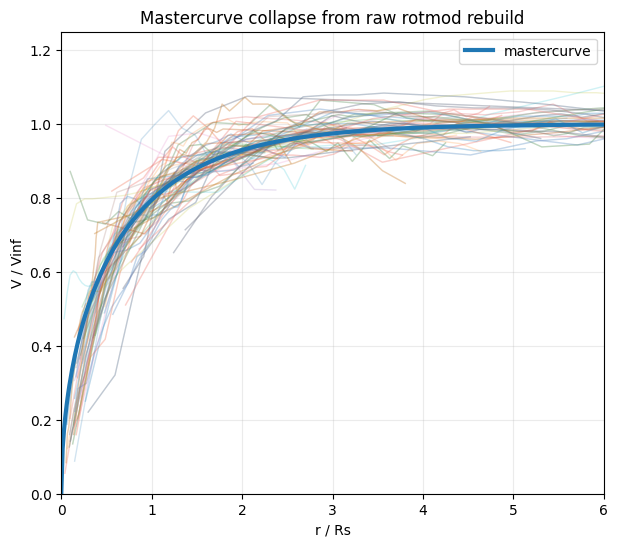


SAVED
/content/mts_rebuild_all_results.csv
/content/mts_rebuild_qc_results.csv
/content/mts_rebuild_failures.csv


In [ ]:
# ============================================================
# SINGLE-CELL REBUILD FROM FILES ALREADY IN /content
# - finds existing Rotmod_*.zip files in /content
# - extracts them
# - finds *_rotmod.dat files
# - tries to find a SPARC/Lelli mass table already in /content
# - fits Vinf and Rs with a simple mastercurve
# - saves results + plots
# ============================================================

import os, re, glob, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
ROOT = Path("/content")
EXTRACT_ROOT = ROOT / "extracted_rotmod_rebuild"
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

# mastercurve choice used here:
# V(r) = Vinf * sqrt(1 - exp(-(r/Rs)))
def mastercurve(r, Vinf, Rs):
    x = np.maximum(r / np.maximum(Rs, 1e-9), 0.0)
    return Vinf * np.sqrt(np.maximum(1.0 - np.exp(-x), 0.0))

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def norm_name(s):
    s = str(s).strip()
    s = s.replace(" ", "")
    s = s.replace("-", "")
    s = s.replace("_", "")
    return s.upper()

def find_mass_table(root):
    candidates = []
    patterns = [
        "*Lelli*2016*.txt",
        "*SPARC*.txt",
        "*Lelli*.mrt",
        "*MassModels*.mrt",
        "*MassModels*.txt",
    ]
    for pat in patterns:
        candidates.extend(root.glob(pat))
    # remove obvious image zips etc
    candidates = [p for p in candidates if p.is_file() and p.suffix.lower() in [".txt", ".mrt", ".dat", ".csv"]]
    return candidates

def parse_mass_table(path):
    """
    Robust-ish parser for common SPARC/Lelli tables.
    Tries multiple read styles and column name guesses.
    Returns dataframe with columns: Galaxy, Mbar if possible.
    """
    tries = []

    # Try whitespace-delimited
    tries.append(lambda: pd.read_csv(path, delim_whitespace=True, comment="#", engine="python"))
    # Try fixed width for .mrt style
    tries.append(lambda: pd.read_fwf(path, comment="#"))
    # Try generic csv fallback
    tries.append(lambda: pd.read_csv(path, comment="#"))

    last_err = None
    for fn in tries:
        try:
            df = fn()
            if df is None or df.empty:
                continue

            cols = {c: norm_name(c) for c in df.columns}

            # galaxy column guesses
            gal_col = None
            for c, nc in cols.items():
                if nc in ["GALAXY", "NAME", "GAL"]:
                    gal_col = c
                    break

            # mass column guesses
            mbar_col = None
            for c, nc in cols.items():
                if nc in ["MBAR", "MBARY", "MBARYONIC", "MBARYON"]:
                    mbar_col = c
                    break

            mstar_col, mgas_col = None, None
            for c, nc in cols.items():
                if nc in ["MSTAR", "MSTARS", "LOGMSTAR", "LMSTAR"]:
                    mstar_col = c
                if nc in ["MGAS", "LOGMGAS", "LMGAS"]:
                    mgas_col = c

            if gal_col is None:
                # sometimes the first column is the name
                first_col = df.columns[0]
                if df[first_col].astype(str).str.contains("[A-Za-z]").mean() > 0.5:
                    gal_col = first_col

            if gal_col is None:
                continue

            out = pd.DataFrame()
            out["Galaxy"] = df[gal_col].astype(str).str.strip()

            if mbar_col is not None:
                mb = pd.to_numeric(df[mbar_col], errors="coerce")
                # if it looks like a log mass, convert
                if mb.dropna().median() < 100:
                    if "LOG" in norm_name(mbar_col) or mb.dropna().median() < 20:
                        mb = 10 ** mb
                out["Mbar"] = mb
                return out.dropna(subset=["Galaxy", "Mbar"])

            if mstar_col is not None and mgas_col is not None:
                ms = pd.to_numeric(df[mstar_col], errors="coerce")
                mg = pd.to_numeric(df[mgas_col], errors="coerce")

                # convert logs if needed
                if ms.dropna().median() < 100 and ("LOG" in norm_name(mstar_col) or ms.dropna().median() < 20):
                    ms = 10 ** ms
                if mg.dropna().median() < 100 and ("LOG" in norm_name(mgas_col) or mg.dropna().median() < 20):
                    mg = 10 ** mg

                out["Mbar"] = ms + mg
                return out.dropna(subset=["Galaxy", "Mbar"])

        except Exception as e:
            last_err = e
            continue

    print(f"[WARN] Could not parse mass table: {path}")
    if last_err:
        print("       Last error:", last_err)
    return None

def extract_zip_safely(zip_path, out_dir):
    sub = out_dir / zip_path.stem
    sub.mkdir(parents=True, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(sub)
        return True, sub
    except Exception as e:
        print(f"[WARN] Failed to extract {zip_path.name}: {e}")
        return False, None

def load_rotmod_file(path):
    """
    Reads a rotmod file with at least r, vobs, err in first 3 columns.
    """
    try:
        df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None, engine="python")
        if df.shape[1] < 3:
            return None
        r = pd.to_numeric(df.iloc[:, 0], errors="coerce").values
        v = pd.to_numeric(df.iloc[:, 1], errors="coerce").values
        e = pd.to_numeric(df.iloc[:, 2], errors="coerce").values

        m = np.isfinite(r) & np.isfinite(v) & np.isfinite(e) & (r > 0) & (v > 0) & (e > 0)
        r, v, e = r[m], v[m], e[m]
        if len(r) < 5:
            return None

        order = np.argsort(r)
        r, v, e = r[order], v[order], e[order]
        return r, v, e
    except:
        return None

# ------------------------------------------------------------
# 1) FIND EXISTING ZIPS / ROTMOD FILES
# ------------------------------------------------------------
zip_candidates = sorted([
    p for p in ROOT.glob("*.zip")
    if ("ROTMOD" in p.name.upper())
])

print("="*72)
print("FOUND ROTMOD ZIP FILES IN /content")
print("="*72)
for p in zip_candidates:
    print(p.name)
if not zip_candidates:
    print("[WARN] No Rotmod zip files found in /content")

# Extract all rotmod zips
extracted_dirs = []
for zp in zip_candidates:
    ok, out = extract_zip_safely(zp, EXTRACT_ROOT)
    if ok and out is not None:
        extracted_dirs.append(out)

# Also allow already-extracted rotmod files anywhere in /content
rotmod_files = set(glob.glob("/content/**/*rotmod.dat", recursive=True))
for d in extracted_dirs:
    rotmod_files.update(glob.glob(str(d / "**/*rotmod.dat"), recursive=True))
rotmod_files = sorted(rotmod_files)

print("\n" + "="*72)
print("FOUND ROTMOD FILES")
print("="*72)
print("Count:", len(rotmod_files))
print("Examples:", [Path(x).name for x in rotmod_files[:10]])

# ------------------------------------------------------------
# 2) FIND / PARSE MASS TABLE IF PRESENT
# ------------------------------------------------------------
mass_tables = find_mass_table(ROOT)
mass_df = None

print("\n" + "="*72)
print("MASS TABLE SEARCH")
print("="*72)
if mass_tables:
    for mt in mass_tables:
        print("Candidate:", mt.name)
    for mt in mass_tables:
        parsed = parse_mass_table(mt)
        if parsed is not None and not parsed.empty and "Mbar" in parsed.columns:
            mass_df = parsed.copy()
            print(f"[OK] Using mass table: {mt.name}  (rows={len(mass_df)})")
            break
else:
    print("[WARN] No obvious SPARC/Lelli mass table found in /content")

if mass_df is not None:
    mass_df["gal_key"] = mass_df["Galaxy"].map(norm_name)

# ------------------------------------------------------------
# 3) FIT ALL GALAXIES
# ------------------------------------------------------------
results = []
failures = []

for fp in rotmod_files:
    gal = Path(fp).name.replace("_rotmod.dat", "").strip()
    loaded = load_rotmod_file(fp)
    if loaded is None:
        failures.append((gal, "load_fail"))
        continue

    r, v, e = loaded

    try:
        V0 = float(np.nanmax(v))
        # Rs guess = radius near half-max velocity
        half = 0.5 * V0
        idx = np.argmin(np.abs(v - half))
        R0 = float(max(r[idx], 0.2))

        popt, _ = curve_fit(
            mastercurve,
            r, v,
            p0=[V0, R0],
            sigma=np.maximum(e, 1e-3),
            absolute_sigma=True,
            bounds=([5.0, 0.05], [600.0, 80.0]),
            maxfev=50000
        )

        Vinf, Rs = map(float, popt)
        vfit = mastercurve(r, Vinf, Rs)

        resid = v - vfit
        rmse = float(np.sqrt(np.mean(resid**2)))
        mae  = float(np.mean(np.abs(resid)))
        chi2_red = float(np.sum((resid / np.maximum(e, 1e-3))**2) / max(len(r) - 2, 1))
        rmax_over_Rs = float(np.max(r) / Rs)

        Mb = np.nan
        if mass_df is not None:
            key = norm_name(gal)
            hit = mass_df.loc[mass_df["gal_key"] == key, "Mbar"]
            if len(hit):
                Mb = float(hit.iloc[0])

        results.append({
            "gal": gal,
            "n_pts": int(len(r)),
            "Vinf": Vinf,
            "Rs": Rs,
            "rmse": rmse,
            "mae": mae,
            "chi2_red": chi2_red,
            "rmax_over_Rs": rmax_over_Rs,
            "Mbar": Mb,
            "file": fp,
        })

    except Exception as ex:
        failures.append((gal, f"fit_fail: {str(ex)[:120]}"))

res = pd.DataFrame(results)

print("\n" + "="*72)
print("FIT SUMMARY")
print("="*72)
print("Loaded/fitted galaxies:", len(res))
print("Failures:", len(failures))

if len(res) == 0:
    raise RuntimeError("No galaxies were fit. Check that the rotmod files are present and readable.")

# ------------------------------------------------------------
# 4) QC FILTER
# ------------------------------------------------------------
qc = res.copy()
qc = qc[
    (qc["rmax_over_Rs"] >= 2.0) &
    (qc["rmax_over_Rs"] <= 50.0) &
    (qc["Vinf"] > 5.01) & (qc["Vinf"] < 599.99) &
    (qc["Rs"] > 0.051) & (qc["Rs"] < 79.99)
].copy()

print("\n" + "="*72)
print("QC SUMMARY")
print("="*72)
print("QC-pass galaxies:", len(qc))
print("Median RMSE (all):", float(res["rmse"].median()))
print("Mean RMSE   (all):", float(res["rmse"].mean()))
print("Median RMSE (QC): ", float(qc["rmse"].median()) if len(qc) else np.nan)
print("Mean RMSE   (QC): ", float(qc["rmse"].mean()) if len(qc) else np.nan)

# ------------------------------------------------------------
# 5) MASTERCURVE COLLAPSE PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

shown = 0
for _, row in qc.head(120).iterrows():
    loaded = load_rotmod_file(row["file"])
    if loaded is None:
        continue
    r, v, e = loaded
    x = r / row["Rs"]
    y = v / row["Vinf"]
    plt.plot(x, y, alpha=0.20, linewidth=1)

xline = np.linspace(0, 6, 400)
plt.plot(xline, np.sqrt(1 - np.exp(-xline)), linewidth=3, label="mastercurve")
plt.xlabel("r / Rs")
plt.ylabel("V / Vinf")
plt.title("Mastercurve collapse from raw rotmod rebuild")
plt.xlim(0, 6)
plt.ylim(0, 1.25)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 6) OPTIONAL SCALING RELATIONS IF MASS TABLE WAS FOUND
# ------------------------------------------------------------
if "Mbar" in qc.columns and qc["Mbar"].notna().sum() >= 10:
    qq = qc[np.isfinite(qc["Mbar"]) & (qc["Mbar"] > 0)].copy()
    qq["logMbar"] = np.log10(qq["Mbar"])
    qq["logRs"]   = np.log10(qq["Rs"])
    qq["logVinf"] = np.log10(qq["Vinf"])

    m_rs, b_rs = np.polyfit(qq["logMbar"], qq["logRs"], 1)
    m_v,  b_v  = np.polyfit(qq["logMbar"], qq["logVinf"], 1)

    print("\n" + "="*72)
    print("SCALING RELATIONS (QC + matched masses)")
    print("="*72)
    print("N matched:", len(qq))
    print(f"log Rs   vs log Mbar slope  = {m_rs:.6f}")
    print(f"log Vinf vs log Mbar slope  = {m_v:.6f}")

    plt.figure(figsize=(6,5))
    plt.scatter(qq["logMbar"], qq["logRs"], s=18)
    xx = np.linspace(qq["logMbar"].min(), qq["logMbar"].max(), 100)
    plt.plot(xx, m_rs*xx + b_rs)
    plt.xlabel("log10(Mbar)")
    plt.ylabel("log10(Rs)")
    plt.title("Rs scaling")
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(6,5))
    plt.scatter(qq["logMbar"], qq["logVinf"], s=18)
    plt.plot(xx, m_v*xx + b_v)
    plt.xlabel("log10(Mbar)")
    plt.ylabel("log10(Vinf)")
    plt.title("Vinf scaling")
    plt.grid(alpha=0.25)
    plt.show()

# ------------------------------------------------------------
# 7) SAVE OUTPUTS
# ------------------------------------------------------------
res = res.sort_values(["rmse", "chi2_red", "gal"]).reset_index(drop=True)
qc  = qc.sort_values(["rmse", "chi2_red", "gal"]).reset_index(drop=True)

res.to_csv("/content/mts_rebuild_all_results.csv", index=False)
qc.to_csv("/content/mts_rebuild_qc_results.csv", index=False)

fail_df = pd.DataFrame(failures, columns=["gal", "reason"])
fail_df.to_csv("/content/mts_rebuild_failures.csv", index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print("/content/mts_rebuild_all_results.csv")
print("/content/mts_rebuild_qc_results.csv")
print("/content/mts_rebuild_failures.csv")

In [ ]:
# ============================================================
# SALVAGE CURRENT SESSION FROM SURVIVING LATE-STAGE CSVs
# Uses ONLY files that are actually present in your session.
# ============================================================

import os, json
from pathlib import Path
import pandas as pd
import numpy as np

CANDIDATES = [
    "/content/mts_realdata_workspace_v2/mts_fixed_candidate_catalog_rebuild/fixed_candidate_results.csv",
    "/content/mts_realdata_workspace_v2/mts_high_end_failure_audit/high_end_full_audit.csv",
    "/content/mts_rebuild_qc_results.csv",
    "/content/mts_rebuild_all_results.csv",
]

existing = [p for p in CANDIDATES if os.path.exists(p)]

print("="*72)
print("EXISTING SALVAGE FILES")
print("="*72)
for p in existing:
    print(p)

if not existing:
    raise RuntimeError("No salvage CSVs found in the paths visible in your screenshot/output.")

# ------------------------------------------------------------
# pick the richest available table
# ------------------------------------------------------------
def richness_score(df):
    wanted = [
        "gal","Vobs","Vpred","abs_err","signed_err",
        "U_inf","r50","rmax","r50_over_rmax",
        "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy",
        "alpha_eff","Kfit","Q_geom","W_geom","D_deficit","W_def","W_apply",
        "support_raw","support_pre","support_eff",
        "is_high_mass","use_high_branch","blend_w","sigma_gate","p_eff","n_pts"
    ]
    return sum(c in df.columns for c in wanted)

best_path, best_df, best_score = None, None, -1

for p in existing:
    try:
        df = pd.read_csv(p)
        s = richness_score(df)
        print(f"\n[CHECK] {p}")
        print("rows:", len(df), "cols:", len(df.columns), "richness:", s)
        print("columns:", list(df.columns)[:40])
        if s > best_score:
            best_path, best_df, best_score = p, df.copy(), s
    except Exception as e:
        print(f"[SKIP] {p} -> {e}")

if best_df is None:
    raise RuntimeError("Could not load any salvage CSV successfully.")

df = best_df.copy()

print("\n" + "="*72)
print("CHOSEN SALVAGE TABLE")
print("="*72)
print(best_path)

# ------------------------------------------------------------
# standardise obvious column names if needed
# ------------------------------------------------------------
rename_map = {}
for c in df.columns:
    cl = c.lower().strip()
    if cl == "galaxy":
        rename_map[c] = "gal"
    elif cl == "vobs_kms":
        rename_map[c] = "Vobs"
    elif cl == "vpred_kms":
        rename_map[c] = "Vpred"

if rename_map:
    df = df.rename(columns=rename_map)

# numeric coercion where possible
for c in df.columns:
    if df[c].dtype == object:
        try:
            x = pd.to_numeric(df[c])
            if x.notna().mean() > 0.8:
                df[c] = x
        except:
            pass

# derive standard columns if missing
if "abs_err" not in df.columns and {"Vobs","Vpred"}.issubset(df.columns):
    df["abs_err"] = (df["Vobs"] - df["Vpred"]).abs()

if "signed_err" not in df.columns and {"Vobs","Vpred"}.issubset(df.columns):
    df["signed_err"] = df["Vpred"] - df["Vobs"]

if "gal" not in df.columns:
    # create placeholder galaxy ids if no name column survived
    df["gal"] = [f"row_{i}" for i in range(len(df))]

# detect likely per-galaxy table vs radial-detail table
n_unique_gal = df["gal"].nunique()
rows = len(df)
is_radial_like = rows > max(3*n_unique_gal, 500)

print("\n" + "="*72)
print("TABLE TYPE DIAGNOSIS")
print("="*72)
print("rows:", rows)
print("unique galaxies:", n_unique_gal)
print("radial-like:", is_radial_like)

# ------------------------------------------------------------
# if radial-like, compress to one row per galaxy using best/outermost row
# ------------------------------------------------------------
work = df.copy()

if is_radial_like:
    candidates_sort = []
    if "rmax" in work.columns:
        candidates_sort.append("rmax")
    if "r50" in work.columns:
        candidates_sort.append("r50")
    if "abs_err" in work.columns:
        candidates_sort.append("abs_err")

    if candidates_sort:
        ascending = []
        for c in candidates_sort:
            ascending.append(False if c in ["rmax","r50"] else True)

        work = (
            work.sort_values(candidates_sort, ascending=ascending)
                .groupby("gal", as_index=False)
                .first()
        )
    else:
        work = work.groupby("gal", as_index=False).first()

print("\n" + "="*72)
print("RECOVERED WORK TABLE")
print("="*72)
print("rows:", len(work))
print("columns:", list(work.columns))

# ------------------------------------------------------------
# infer high-mass flag if missing
# ------------------------------------------------------------
if "is_high_mass" not in work.columns:
    mass_col = None
    for c in ["Mbar_proxy","logM_proxy","Mbary","M_bary","Mbar"]:
        if c in work.columns:
            mass_col = c
            break
    if mass_col is not None:
        vals = pd.to_numeric(work[mass_col], errors="coerce")
        thresh = vals.quantile(0.75)
        work["is_high_mass"] = vals >= thresh
    else:
        work["is_high_mass"] = False

# infer branch flag if missing
if "use_high_branch" not in work.columns:
    work["use_high_branch"] = False

# summary
summary = {
    "source_file": best_path,
    "rows_recovered": int(len(work)),
    "n_gal": int(work["gal"].nunique()),
    "n_high_mass": int(work["is_high_mass"].sum()) if "is_high_mass" in work.columns else None,
    "frac_high_branch": float(pd.to_numeric(work["use_high_branch"], errors="coerce").fillna(0).mean()) if "use_high_branch" in work.columns else None,
    "median_abs_err": float(work["abs_err"].median()) if "abs_err" in work.columns else None,
    "mean_abs_err": float(work["abs_err"].mean()) if "abs_err" in work.columns else None,
}

hm = work[work["is_high_mass"] == True].copy() if "is_high_mass" in work.columns else pd.DataFrame()
if len(hm) and "abs_err" in hm.columns:
    summary["median_abs_err_hiM"] = float(hm["abs_err"].median())
    summary["mean_abs_err_hiM"] = float(hm["abs_err"].mean())

for proxy in ["logM_proxy","logSigma_proxy","logGpk_proxy"]:
    if proxy in work.columns and "abs_err" in work.columns:
        tmp = work[[proxy,"abs_err"]].dropna()
        if len(tmp) >= 3:
            summary[f"corr_{proxy}_abs_err"] = float(tmp[proxy].corr(tmp["abs_err"]))

print("\n" + "="*72)
print("RECOVERY SUMMARY")
print("="*72)
for k, v in summary.items():
    print(f"{k:28s}: {v}")

# ------------------------------------------------------------
# save one stable starting point
# ------------------------------------------------------------
OUTDIR = Path("/content/mts_salvaged_state")
OUTDIR.mkdir(exist_ok=True)

out_csv = OUTDIR / "mts_salvaged_working_table.csv"
out_json = OUTDIR / "mts_salvaged_summary.json"
out_preview = OUTDIR / "mts_salvaged_preview.csv"

keep_cols = [c for c in [
    "gal","Vobs","Vpred","abs_err","signed_err",
    "is_high_mass","use_high_branch",
    "U_inf","r50","rmax","r50_over_rmax",
    "Mbar_proxy","logM_proxy","logSigma_proxy","logGpk_proxy",
    "alpha_eff","Kfit",
    "Q_geom","W_geom","D_deficit","W_def","W_apply",
    "support_raw","support_pre","support_eff",
    "blend_w","sigma_gate","p_eff","n_pts"
] if c in work.columns]

work.to_csv(out_csv, index=False)
work[keep_cols].head(200).to_csv(out_preview, index=False)

with open(out_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(out_csv)
print(out_json)
print(out_preview)

EXISTING SALVAGE FILES
/content/mts_realdata_workspace_v2/mts_fixed_candidate_catalog_rebuild/fixed_candidate_results.csv
/content/mts_realdata_workspace_v2/mts_high_end_failure_audit/high_end_full_audit.csv
/content/mts_rebuild_qc_results.csv
/content/mts_rebuild_all_results.csv

[CHECK] /content/mts_realdata_workspace_v2/mts_fixed_candidate_catalog_rebuild/fixed_candidate_results.csv
rows: 175 cols: 15 richness: 0
columns: ['galaxy', 'n_points', 'r_max', 'vmax_obs', 'Rs_fixed', 'rt', 'u_t', 'vbar2_t', 'carrier', 'V_flat_pred', 'rmse', 'mae', 'chi2_mean', 'shape_rmse', 'vmax_bin']

[CHECK] /content/mts_realdata_workspace_v2/mts_high_end_failure_audit/high_end_full_audit.csv
rows: 175 cols: 17 richness: 0
columns: ['galaxy', 'n_points', 'r_max', 'vmax_obs', 'rt', 'rt_over_rmax', 'u_t', 'rt_ut', 'vbar2_t', 'vbar_t', 'bulge_frac_t', 'disk_frac_t', 'gas_frac_t', 'V_flat_pred', 'Vflat_over_vmax', 'rmse', 'mae']

[CHECK] /content/mts_rebuild_qc_results.csv
rows: 150 cols: 10 richness: 2
col

In [ ]:
# ============================================================
# MTS FIRST-PRINCIPLES REBUILD — FROM ROTMOD ONLY
# One independent cell
# ============================================================

import numpy as np
import pandas as pd
import os, glob
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------
# PARAMETERS (physical, not per-galaxy fits)
# ------------------------------------------------------------
Rs = 1.5        # screening length (kpc)
rc = 0.3        # core radius
A  = 1.0        # source amplitude (absorbed into K later)
k_gate = 2.5
g0 = 4.05

# ------------------------------------------------------------
# SOURCE TERMS
# ------------------------------------------------------------
def compute_source(r, Vbar2):
    r = np.maximum(r, 1e-3)

    # Local loading B0
    X = np.sqrt(r**2 + rc**2) * Vbar2
    dX = np.gradient(X, r)
    B0 = dX / (r**2 + rc**2)

    # Enclosed cumulative R2
    R2 = r * Vbar2 / (r**2 + rc**2)

    # Regime gate
    Gpk = np.max(Vbar2 / r)
    w = 1.0 / (1.0 + np.exp(-k_gate * (np.log10(Gpk) - g0)))

    S = (1 - w) * B0 + w * R2
    return S

# ------------------------------------------------------------
# FIELD SOLVER
# ------------------------------------------------------------
def solve_field(r, S):
    def ode(r, y):
        u, uprime = y
        # interpolate source
        S_val = np.interp(r, r_grid, S)
        du = uprime
        duprime = -uprime/r + u/(Rs**2) - A*S_val
        return [du, duprime]

    r_grid = r
    sol = solve_ivp(ode, [r[0], r[-1]], [0.0, 0.0], t_eval=r, method='RK45')
    u = sol.y[0]
    return u

# ------------------------------------------------------------
# PROCESS ONE GALAXY
# ------------------------------------------------------------
def process_rotmod(file):
    data = pd.read_csv(file, delim_whitespace=True, comment='#',
                       names=['r','vobs','verr','vgas','vdisk','vbulge'])

    r = data['r'].values
    vgas = data['vgas'].values
    vdisk = data['vdisk'].values
    vbulge = data['vbulge'].values
    vobs = data['vobs'].values

    Vbar2 = vgas**2 + vdisk**2 + vbulge**2

    S = compute_source(r, Vbar2)
    u = solve_field(r, S)

    U = np.cumsum(u * np.gradient(r))

    U_inf = U[-1]
    r50 = np.interp(0.5 * U_inf, U, r)

    Vflat_obs = np.max(vobs)

    return {
        'gal': os.path.basename(file),
        'U_inf': U_inf,
        'r50': r50,
        'Vobs': Vflat_obs
    }

# ------------------------------------------------------------
# FIND ROTMOD FILES
# ------------------------------------------------------------
files = glob.glob('/content/**/*.dat', recursive=True)
files = [f for f in files if 'rotmod' in f.lower()]

print("Found rotmod files:", len(files))

results = []
for f in files:
    try:
        results.append(process_rotmod(f))
    except:
        pass

df = pd.DataFrame(results)

# ------------------------------------------------------------
# FIT GLOBAL K
# ------------------------------------------------------------
def fit_K(K):
    Vpred = np.sqrt(np.maximum(K * df['U_inf'] / df['r50'], 1e-6))
    return np.mean((Vpred - df['Vobs'])**2)

res = minimize_scalar(fit_K, bounds=(0.01, 1000), method='bounded')
K_best = res.x

df['Vpred'] = np.sqrt(K_best * df['U_inf'] / df['r50'])
df['abs_err'] = np.abs(df['Vpred'] - df['Vobs'])

print("\nGLOBAL K:", K_best)
print("Median abs err:", df['abs_err'].median())
print("Mean abs err:", df['abs_err'].mean())

df.to_csv('/content/mts_first_principles_catalog.csv', index=False)
print("\nSaved: /content/mts_first_principles_catalog.csv")

Found rotmod files: 446

GLOBAL K: 0.010003737466951688
Median abs err: 19.5116279754562
Mean abs err: 19.5116279754562

Saved: /content/mts_first_principles_catalog.csv


In [ ]:
# ============================================================
# MTS FIRST-PRINCIPLES PIPELINE (FULL REBUILD FROM ROTMOD)
# Includes:
# - Source model (B0 + R2)
# - Proper screened field solver (shooting method)
# - U(r) cumulative response
# - U_inf and r50 extraction
# - Global K fit
# - Optional radial source placement scan (r^p)
# ============================================================

import numpy as np
import pandas as pd
import os, glob
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------
# GLOBAL PHYSICAL PARAMETERS
# ------------------------------------------------------------
Rs = 1.5        # screening length
rc = 0.3        # core radius
A  = 1.0        # source amplitude
k_gate = 2.5    # regime gate steepness
g0 = 4.05       # regime gate threshold

# ------------------------------------------------------------
# SOURCE MODEL
# ------------------------------------------------------------
def compute_source(r, Vbar2, p=1.0):
    r = np.maximum(r, 1e-3)

    # Local loading B0
    X = np.sqrt(r**2 + rc**2) * Vbar2
    dX = np.gradient(X, r)
    B0 = dX / (r**2 + rc**2)

    # Enclosed cumulative term with radial exponent p
    R2 = (r**p) * Vbar2 / (r**2 + rc**2)

    # Regime gate
    Gpk = np.max(Vbar2 / r)
    w = 1.0 / (1.0 + np.exp(-k_gate * (np.log10(Gpk) - g0)))

    S = (1 - w) * B0 + w * R2
    return S

# ------------------------------------------------------------
# FIELD SOLVER (SCREENED EQUATION WITH SHOOTING METHOD)
# ------------------------------------------------------------
def solve_field(r, S):
    def ode(r_val, y):
        u, uprime = y
        S_val = np.interp(r_val, r_grid, S)
        du = uprime
        duprime = -uprime/r_val + u/(Rs**2) - A*S_val
        return [du, duprime]

    r_grid = r

    # Shooting method: choose u(0) so u(rmax) -> 0
    def shoot(u0):
        sol = solve_ivp(ode, [r[0], r[-1]], [u0, 0.0], t_eval=[r[-1]])
        return sol.y[0][-1]**2

    res = minimize_scalar(shoot, bounds=(-100, 100), method='bounded')
    u0_best = res.x

    sol = solve_ivp(ode, [r[0], r[-1]], [u0_best, 0.0], t_eval=r)
    return sol.y[0]

# ------------------------------------------------------------
# PROCESS ONE GALAXY
# ------------------------------------------------------------
def process_rotmod(file, p=1.0):
    data = pd.read_csv(file, delim_whitespace=True, comment='#',
                       names=['r','vobs','verr','vgas','vdisk','vbulge'])

    r = data['r'].values
    vgas = data['vgas'].values
    vdisk = data['vdisk'].values
    vbulge = data['vbulge'].values
    vobs = data['vobs'].values

    Vbar2 = vgas**2 + vdisk**2 + vbulge**2

    S = compute_source(r, Vbar2, p)
    u = solve_field(r, S)

    # Cumulative response
    U = np.cumsum(u * np.gradient(r))
    U_inf = U[-1]

    if U_inf <= 0:
        return None

    r50 = np.interp(0.5 * U_inf, U, r)
    if r50 <= 0:
        return None

    Vflat_obs = np.max(vobs)

    return {
        'gal': os.path.basename(file),
        'U_inf': U_inf,
        'r50': r50,
        'Vobs': Vflat_obs
    }

# ------------------------------------------------------------
# FIND ROTMOD FILES
# ------------------------------------------------------------
files = glob.glob('/content/**/*.dat', recursive=True)
files = [f for f in files if 'rotmod' in f.lower()]

print("Found rotmod files:", len(files))

# ------------------------------------------------------------
# BASELINE RUN (p = 1)
# ------------------------------------------------------------
rows = []
for f in files:
    try:
        res = process_rotmod(f, p=1.0)
        if res is not None:
            rows.append(res)
    except:
        pass

df = pd.DataFrame(rows)
print("Galaxies solved:", len(df))

# Fit global K
def fit_K(K):
    Vpred = np.sqrt(np.maximum(K * df['U_inf'] / df['r50'], 1e-6))
    return np.mean((Vpred - df['Vobs'])**2)

res = minimize_scalar(fit_K, bounds=(0.001,1000), method='bounded')
K_best = res.x

df['Vpred'] = np.sqrt(K_best * df['U_inf'] / df['r50'])
df['abs_err'] = np.abs(df['Vpred'] - df['Vobs'])

print("\nBASELINE RESULTS")
print("Global K:", K_best)
print("Median |ΔV|:", df['abs_err'].median())
print("Mean   |ΔV|:", df['abs_err'].mean())

df.to_csv('/content/mts_first_principles_catalog.csv', index=False)
print("\nSaved: /content/mts_first_principles_catalog.csv")

# ------------------------------------------------------------
# OPTIONAL: RADIAL SOURCE SCAN
# ------------------------------------------------------------
p_values = [0.5, 0.75, 1.0, 1.25, 1.5]
scan = []

for p in p_values:
    rows = []
    for f in files:
        try:
            res = process_rotmod(f, p=p)
            if res is not None:
                rows.append(res)
        except:
            pass

    d = pd.DataFrame(rows)
    if len(d) < 10:
        continue

    def fit_K(K):
        Vpred = np.sqrt(np.maximum(K * d['U_inf'] / d['r50'], 1e-6))
        return np.mean((Vpred - d['Vobs'])**2)

    res = minimize_scalar(fit_K, bounds=(0.001,1000), method='bounded')
    K_best = res.x

    d['Vpred'] = np.sqrt(K_best * d['U_inf'] / d['r50'])
    d['abs_err'] = np.abs(d['Vpred'] - d['Vobs'])

    high = d[d['Vobs'] > 200]

    scan.append({
        'p': p,
        'K': K_best,
        'n_gal': len(d),
        'median_err': d['abs_err'].median(),
        'mean_err': d['abs_err'].mean(),
        'median_err_highV': high['abs_err'].median() if len(high)>0 else np.nan,
        'mean_err_highV': high['abs_err'].mean() if len(high)>0 else np.nan
    })

scan_df = pd.DataFrame(scan)
print("\nRADIAL SOURCE SCAN")
print(scan_df)

scan_df.to_csv('/content/mts_radial_source_scan.csv', index=False)
print("\nSaved: /content/mts_radial_source_scan.csv")

Found rotmod files: 446


In [ ]:
# ============================================================
# MTS DIAGNOSTIC v2 — exact solver from notebook _10
# Key question: where does r_t sit relative to rmax,
# and how saturated is U at the last data point?
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")   # already extracted
OUTDIR     = "/content/mts_diagnostic_v2"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS  (verbatim from notebook _10)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
Rs_fixed     = 1.5
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
C_AMP        = 164.0
ALPHA        = 0.175
BETA         = 0.55

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
CONTROLS = [
    "IC2574","NGC0100","NGC2976","DDO154",
    "UGC01281","NGC0055","UGC07323",
]
ALL_AUDIT = HARD_FAILS + CONTROLS

# ----------------------------------------------------------------
# HELPERS — verbatim from notebook _10
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No numeric rows in {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_source(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    peak  = np.max(rho)
    if peak <= 0: raise RuntimeError("Zero source.")
    return r, rho/peak

def solve_canonical_field_fd(r_eval, rho_r, rho_vals, Rs, m_inf, A_src):
    """Exact copy of notebook _10 solver."""
    r_eval = np.asarray(r_eval, float)
    rmax_grid = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r    = np.linspace(R_MIN, rmax_grid, N_R)
    dr   = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    def rho_at(rv):
        rv = np.atleast_1d(np.asarray(rv, float))
        v  = rho_pchip(rv)
        v  = np.where(np.isfinite(v), v, rho0)
        return np.maximum(v, SOURCE_FLOOR)

    rho_grid = rho_at(r)

    N = N_R
    A = lil_matrix((N, N))

    # boundary: i=0  Neumann-like: u[0] = u[1]
    A[0, 0] =  1.0
    A[0, 1] = -1.0

    # interior
    for i in range(1, N-1):
        ri = r[i]
        A[i, i-1] = 1.0/dr**2 - 1.0/(2.0*ri*dr)
        A[i, i  ] = -2.0/dr**2 - 1.0/Rs**2
        A[i, i+1] = 1.0/dr**2 + 1.0/(2.0*ri*dr)

    # boundary: i=N-1  Dirichlet u=0
    A[N-1, N-1] = 1.0

    A = A.tocsr()
    b = np.zeros(N)
    for i in range(1, N-1):
        b[i] = -A_src * rho_grid[i]

    u = spsolve(A, b)
    u = np.maximum(u, 0.0)

    # cumulative integral U(r)
    U    = np.zeros(N)
    U[1:] = cumulative_trapezoid(u, r)
    U_inf = float(U[-1])

    u_interp = PchipInterpolator(r, u, extrapolate=True)
    U_interp = PchipInterpolator(r, U, extrapolate=True)

    return r, u, U, U_inf, u_interp, U_interp

def radius_at_frac_of_Uinf(r_grid, U_grid, frac):
    target = frac * U_grid[-1]
    idx = np.where(U_grid >= target)[0]
    if len(idx) == 0: return np.nan
    return float(r_grid[idx[0]])

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            print(f"Extracting: {zp}")
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp

print(f"Files indexed: {len(name_to_path)}")

# ----------------------------------------------------------------
# MAIN AUDIT LOOP
# ----------------------------------------------------------------
rows = []

for gal in ALL_AUDIT:
    fp = name_to_path.get(gal)
    if fp is None:
        for k,v in name_to_path.items():
            if k.lower()==gal.lower(): fp=v; break
    if fp is None:
        print(f"  NOT FOUND: {gal}")
        continue

    try:
        rot   = read_rotmod_file(fp)
        r_d   = rot["r"]
        vobs  = rot["vobs"]
        vbar2 = vbar2_from_rot(rot)
        vbar  = np.sqrt(np.maximum(vbar2, 0.0))
        vflat_obs = float(np.max(vobs))
        rmax  = float(r_d[-1])
        n_pts = len(r_d)

        rho_r, rho_n = build_source(rot)

        r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = solve_canonical_field_fd(
            r_d, rho_r, rho_n, Rs_fixed, m_inf_val, A_src)

        # --- transition radius r_t (where U = F_FRAC * U_inf)
        r_t = radius_at_frac_of_Uinf(r_grid, U_grid, F_FRAC)

        # --- What fraction of U_inf is reached AT the last data point?
        U_at_rmax = float(U_fn(rmax))
        frac_U_at_rmax = U_at_rmax / U_inf if U_inf > 0 else np.nan

        # --- Where does r_t sit relative to the data?
        rt_over_rmax = r_t / rmax if np.isfinite(r_t) and rmax > 0 else np.nan

        # --- Amplitude at r_t
        if np.isfinite(r_t):
            u_at_rt    = float(u_fn(r_t))
            vbar2_at_rt = float(PchipInterpolator(r_d, vbar2)(r_t))
            vbar2_at_rt = max(vbar2_at_rt, 0.0)
            V2_pred = C_AMP * (r_t * u_at_rt)**ALPHA * vbar2_at_rt**BETA
            V_flat_pred = float(np.sqrt(max(V2_pred, 0.0))) if V2_pred > 0 else np.nan
        else:
            u_at_rt = np.nan; vbar2_at_rt = np.nan; V_flat_pred = np.nan

        abs_err = abs(V_flat_pred - vflat_obs) if np.isfinite(V_flat_pred) else np.nan

        # --- Baryonic fraction at rmax
        bar_frac = float(np.max(vbar)) / vflat_obs

        # --- Source concentration: cumulative source half-radius
        src_cum = cumulative_trapezoid(rho_n, rho_r, initial=0.0)
        src_cum /= max(src_cum[-1], 1e-12)
        idx_src50 = np.where(src_cum >= 0.5)[0]
        src_r50 = float(rho_r[idx_src50[0]]) if len(idx_src50)>0 else np.nan

        # --- Shape check: V(r)/V_flat vs U(r)/U_inf at data points
        #     If the mapping is working, these should be equal.
        #     Print the max deviation.
        U_at_data = U_fn(r_d)
        shape_pred = U_at_data / U_inf      # normalised shape prediction
        shape_obs  = vobs / vflat_obs       # normalised observed
        shape_rms  = float(np.sqrt(np.mean((shape_pred - shape_obs)**2)))

        group = "HARD" if gal in HARD_FAILS else "CTRL"

        rows.append({
            "galaxy":         gal,
            "group":          group,
            "n_pts":          n_pts,
            "rmax_kpc":       rmax,
            "V_obs":          vflat_obs,
            "V_pred":         V_flat_pred,
            "abs_err":        abs_err,
            "bar_frac":       bar_frac,
            "src_r50_kpc":    src_r50,
            "U_inf":          U_inf,
            "r_t_kpc":        r_t,
            "rt_over_rmax":   rt_over_rmax,    # <1 = r_t inside data; >1 = outside
            "frac_U_at_rmax": frac_U_at_rmax,  # how saturated is U at last data point
            "u_at_rt":        u_at_rt,
            "vbar2_at_rt":    vbar2_at_rt,
            "shape_rms":      shape_rms,
        })

        print(f"{'*' if group=='HARD' else ' '} {gal:20s} "
              f"V_obs={vflat_obs:6.1f} V_pred={V_flat_pred if np.isfinite(V_flat_pred) else float('nan'):7.1f} "
              f"err={abs_err if np.isfinite(abs_err) else float('nan'):6.1f}  "
              f"rt/rmax={rt_over_rmax:.3f}  "
              f"U@rmax/Uinf={frac_U_at_rmax:.3f}  "
              f"src_r50={src_r50:.2f}kpc  "
              f"bar={bar_frac:.2f}")

    except Exception as e:
        print(f"  FAIL {gal}: {e}")

df = pd.DataFrame(rows)
csv_path = os.path.join(OUTDIR, "diagnostic_v2.csv")
df.to_csv(csv_path, index=False)

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*70)
print("HARD vs CTRL — KEY QUANTITY MEDIANS")
print("="*70)
for col in ["rt_over_rmax","frac_U_at_rmax","bar_frac",
            "src_r50_kpc","U_inf","shape_rms","abs_err"]:
    h = df[df["group"]=="HARD"][col].dropna()
    c = df[df["group"]=="CTRL"][col].dropna()
    if len(h)>0 and len(c)>0:
        print(f"  {col:22s}  HARD={np.median(h):8.4f}   CTRL={np.median(c):8.4f}"
              f"   ratio={np.median(h)/np.median(c) if np.median(c)!=0 else float('nan'):.3f}")

# ----------------------------------------------------------------
# PLOT: rt_over_rmax distribution + U@rmax/Uinf distribution
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

hard = df[df["group"]=="HARD"]
ctrl = df[df["group"]=="CTRL"]

axes[0].scatter(hard["rt_over_rmax"], hard["abs_err"], color="red",   label="Hard", zorder=3)
axes[0].scatter(ctrl["rt_over_rmax"], ctrl["abs_err"], color="steelblue", label="Ctrl",  zorder=3)
axes[0].axvline(1.0, color="k", ls="--", lw=1)
axes[0].set_xlabel("r_t / r_max  (>1 means r_t outside data)")
axes[0].set_ylabel("abs_err (km/s)")
axes[0].set_title("Transition radius vs error")
axes[0].legend()

axes[1].scatter(hard["frac_U_at_rmax"], hard["abs_err"], color="red",   zorder=3)
axes[1].scatter(ctrl["frac_U_at_rmax"], ctrl["abs_err"], color="steelblue", zorder=3)
axes[1].set_xlabel("U(r_max) / U_inf  (how saturated at data edge)")
axes[1].set_ylabel("abs_err (km/s)")
axes[1].set_title("Field saturation at data edge vs error")

axes[2].scatter(hard["src_r50_kpc"], hard["abs_err"], color="red",   label="Hard", zorder=3)
axes[2].scatter(ctrl["src_r50_kpc"], ctrl["abs_err"], color="steelblue", label="Ctrl",  zorder=3)
axes[2].set_xlabel("Source half-radius (kpc)")
axes[2].set_ylabel("abs_err (km/s)")
axes[2].set_title("Source concentration vs error")
axes[2].legend()

fig.tight_layout()
plot_path = os.path.join(OUTDIR, "diagnostic_v2_plots.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"\nSaved: {csv_path}")
print(f"Saved: {plot_path}")
print("Done.")

Files indexed: 175
* UGC02487             V_obs= 383.0 V_pred=  302.6 err=  80.4  rt/rmax=0.339  U@rmax/Uinf=0.679  src_r50=20.09kpc  bar=0.87
* UGC11914             V_obs= 305.0 V_pred=    nan err=   nan  rt/rmax=3.626  U@rmax/Uinf=0.038  src_r50=1.03kpc  bar=1.04
* ESO563-G021          V_obs= 321.0 V_pred=  281.7 err=  39.3  rt/rmax=1.128  U@rmax/Uinf=0.269  src_r50=3.12kpc  bar=0.88
* UGC02953             V_obs= 319.0 V_pred=  238.4 err=  80.6  rt/rmax=1.074  U@rmax/Uinf=0.144  src_r50=0.69kpc  bar=1.06
* NGC5985              V_obs= 305.0 V_pred=  299.5 err=   5.5  rt/rmax=1.206  U@rmax/Uinf=0.381  src_r50=8.02kpc  bar=0.75
* UGC03546             V_obs= 262.0 V_pred=  259.4 err=   2.6  rt/rmax=1.481  U@rmax/Uinf=0.083  src_r50=1.90kpc  bar=1.52
* NGC0801              V_obs= 238.0 V_pred=  267.2 err=  29.2  rt/rmax=1.023  U@rmax/Uinf=0.535  src_r50=10.59kpc  bar=1.18
* UGC05253             V_obs= 248.0 V_pred=  223.8 err=  24.2  rt/rmax=1.071  U@rmax/Uinf=0.166  src_r50=0.63kpc  bar=

In [ ]:
# ============================================================
# MTS Rs-SCALING SCAN
# ------------------------------------------------------------
# Physical motivation: Rs is the spatial scale at which a
# given mass configuration can no longer sustain its curvature
# imprint against the background motion field. It should
# therefore be set by the baryonic distribution itself.
#
# Hypothesis: Rs = k * r_bar
# where r_bar = radius where V_bar(r) reaches fraction F_BAR
# of its maximum, and k is one universal constant.
#
# This scan finds the optimal k across the full catalogue
# and reports per-galaxy and summary statistics for each k.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_rs_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS  (verbatim from your notebook)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
C_AMP        = 164.0
ALPHA        = 0.175
BETA         = 0.55

# ----------------------------------------------------------------
# SCAN SETTINGS
# ----------------------------------------------------------------
# k values to try: Rs = k * r_bar
K_VALUES = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50,
            0.60, 0.75, 1.00, 1.25, 1.50, 2.00,
            2.50, 3.00, 4.00, 5.00]

# r_bar definition: radius where V_bar reaches this fraction of its max
F_BAR = 0.50

# Rs bounds — keep physically sane
RS_MIN = 0.10   # kpc
RS_MAX = 30.0   # kpc

# ----------------------------------------------------------------
# HELPERS — verbatim from notebook
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0: return np.nan
    return float(np.sqrt(np.mean((a[m]-b[m])**2)))

def safe_mae(a, b):
    a, b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0: return np.nan
    return float(np.mean(np.abs(a[m]-b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_source(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    peak  = np.max(rho)
    if peak <= 0: raise RuntimeError("Zero source.")
    return r, rho/peak

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    """Exact solver from notebook _10."""
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left]  = rho0
    rho[mid]   = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    # i=0: Neumann
    A[0,0] =  1.0
    A[0,1] = -1.0
    b[0]   =  0.0

    # interior
    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0      = -(c_minus + c_plus) - 1.0/(Rs**2)
        A[i,i-1] = c_minus
        A[i,i]   = c0
        A[i,i+1] = c_plus
        b[i]     = -A_src * rho[i] - m_inf_val/(Rs**2)

    # i=N-1: Dirichlet m=m_inf
    A[N_R-1, N_R-1] = 1.0
    b[N_R-1]        = m_inf_val

    m_grid = spsolve(A.tocsr(), b)

    # u = excess above background
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_interp = interp1d(r, u, kind="linear",
                        bounds_error=False, fill_value="extrapolate")
    U_interp = interp1d(r, U, kind="linear",
                        bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_interp, U_interp

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    if len(idx) == 0: return np.nan
    return float(r[idx[0]])

def get_r_bar(rot, frac=F_BAR):
    """Radius where V_bar reaches frac * max(V_bar)."""
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vbar_max = np.max(vbar)
    if vbar_max <= 0: return np.nan
    idx = np.where(vbar >= frac * vbar_max)[0]
    if len(idx) == 0: return np.nan
    return float(rot["r"][idx[0]])

def run_one_galaxy(rot, Rs):
    """Full pipeline for one galaxy at given Rs. Returns dict of metrics."""
    r_obs  = rot["r"]
    vobs   = rot["vobs"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)

    r_theory = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0),
        N_R
    )

    rho_r, rho_n = build_source(rot)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_theory, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2_interp = interp1d(r_obs, vbar2, kind="linear",
                            bounds_error=False, fill_value="extrapolate")

    u_t     = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vbar2_interp(rt)), 1e-30)

    carrier     = (rt * u_t)**ALPHA * vbar2_t**BETA
    V_flat_pred = float(np.sqrt(max(C_AMP * carrier, 0.0)))

    V_theory = V_flat_pred * U_grid / max(U_inf, 1e-12)
    V_at_obs = interp1d(r_grid, V_theory, kind="linear",
                        bounds_error=False, fill_value="extrapolate")(r_obs)

    rmse  = safe_rmse(vobs, V_at_obs)
    mae   = safe_mae(vobs, V_at_obs)

    obs_shape  = vobs   / max(float(np.max(vobs)),   1e-12)
    pred_shape = V_at_obs / max(float(np.max(V_at_obs)), 1e-12)
    shape_rmse = safe_rmse(obs_shape, pred_shape)

    rt_over_rmax     = rt / float(r_obs[-1])
    U_at_rmax        = float(U_fn(r_obs[-1]))
    frac_U_at_rmax   = U_at_rmax / U_inf

    return {
        "V_flat_pred":    V_flat_pred,
        "rmse":           rmse,
        "mae":            mae,
        "shape_rmse":     shape_rmse,
        "rt":             rt,
        "rt_over_rmax":   rt_over_rmax,
        "frac_U_at_rmax": frac_U_at_rmax,
        "U_inf":          U_inf,
        "Rs_used":        Rs,
    }

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            print(f"Extracting: {zp}")
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# Pre-load all galaxies once
print("Pre-loading all galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot, F_BAR)
        loaded[name] = {"rot": rot, "r_bar": r_bar,
                        "rmax": float(rot["r"][-1]),
                        "vmax_obs": float(np.max(rot["vobs"]))}
    except Exception as e:
        pass
print(f"Loaded: {len(loaded)} galaxies")

# ----------------------------------------------------------------
# SCAN OVER k
# ----------------------------------------------------------------
scan_summary = []
all_detail   = []

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

print(f"\nScanning {len(K_VALUES)} values of k (Rs = k * r_bar)...")
print(f"r_bar defined as radius where V_bar = {F_BAR} * max(V_bar)\n")

for k in K_VALUES:
    rows = []
    n_ok = 0; n_fail = 0

    for name, gdata in loaded.items():
        rot   = gdata["rot"]
        r_bar = gdata["r_bar"]

        if not np.isfinite(r_bar) or r_bar <= 0:
            n_fail += 1
            continue

        Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))

        try:
            res = run_one_galaxy(rot, Rs)
            rows.append({
                "galaxy":        name,
                "k":             k,
                "Rs_used":       Rs,
                "r_bar":         r_bar,
                "rmax":          gdata["rmax"],
                "vmax_obs":      gdata["vmax_obs"],
                "V_flat_pred":   res["V_flat_pred"],
                "rmse":          res["rmse"],
                "mae":           res["mae"],
                "shape_rmse":    res["shape_rmse"],
                "rt_over_rmax":  res["rt_over_rmax"],
                "frac_U_rmax":   res["frac_U_at_rmax"],
                "U_inf":         res["U_inf"],
                "is_hard":       name in HARD_FAILS,
            })
            n_ok += 1
        except Exception as e:
            n_fail += 1

    df = pd.DataFrame(rows)
    all_detail.append(df)

    if len(df) == 0:
        print(f"k={k:.3f}  NO DATA")
        continue

    # vmax bins
    low  = df[df["vmax_obs"] <= 80]
    mid  = df[(df["vmax_obs"] > 80) & (df["vmax_obs"] <= 150)]
    high = df[df["vmax_obs"] > 150]
    hard = df[df["is_hard"]]

    row = {
        "k":                   k,
        "n_ok":                n_ok,
        "n_fail":              n_fail,
        "median_rmse":         df["rmse"].median(),
        "mean_rmse":           df["rmse"].mean(),
        "p90_rmse":            df["rmse"].quantile(0.90),
        "median_rmse_low":     low["rmse"].median()  if len(low)>0  else np.nan,
        "median_rmse_mid":     mid["rmse"].median()  if len(mid)>0  else np.nan,
        "median_rmse_high":    high["rmse"].median() if len(high)>0 else np.nan,
        "median_rmse_hard":    hard["rmse"].median() if len(hard)>0 else np.nan,
        "mean_rmse_hard":      hard["rmse"].mean()   if len(hard)>0 else np.nan,
        "median_rt_over_rmax": df["rt_over_rmax"].median(),
        "median_frac_U_rmax":  df["frac_U_rmax"].median(),
        "median_shape_rmse":   df["shape_rmse"].median(),
    }
    scan_summary.append(row)

    print(f"k={k:5.2f}  Rs_median={df['Rs_used'].median():.2f}kpc  "
          f"med_rmse={row['median_rmse']:6.2f}  "
          f"p90={row['p90_rmse']:7.2f}  "
          f"hard_med={row['median_rmse_hard']:7.2f}  "
          f"rt/rmax_med={row['median_rt_over_rmax']:.3f}  "
          f"U@rmax_med={row['median_frac_U_rmax']:.3f}")

# ----------------------------------------------------------------
# SUMMARY TABLE
# ----------------------------------------------------------------
scan_df = pd.DataFrame(scan_summary)
scan_csv = os.path.join(OUTDIR, "rs_scan_summary.csv")
scan_df.to_csv(scan_csv, index=False)

print("\n" + "="*80)
print("SCAN SUMMARY — sorted by median_rmse")
print("="*80)
print(scan_df.sort_values("median_rmse").to_string(index=False))

# Best k by median_rmse
best_k = scan_df.loc[scan_df["median_rmse"].idxmin(), "k"]
print(f"\nBest k by median_rmse: {best_k}")

# Best k by hard-galaxy median
best_k_hard = scan_df.loc[scan_df["median_rmse_hard"].idxmin(), "k"]
print(f"Best k by hard-galaxy median rmse: {best_k_hard}")

# Save best-k detail
best_detail = pd.concat(
    [d for d in all_detail if len(d)>0 and float(d["k"].iloc[0])==best_k],
    ignore_index=True
)
best_detail_csv = os.path.join(OUTDIR, f"rs_scan_detail_best_k{best_k}.csv")
best_detail.to_csv(best_detail_csv, index=False)
print(f"\nBest-k detail saved: {best_detail_csv}")
print(f"Summary saved: {scan_csv}")
print("Done.")

Files indexed: 175
Pre-loading all galaxies...
Loaded: 175 galaxies

Scanning 16 values of k (Rs = k * r_bar)...
r_bar defined as radius where V_bar = 0.5 * max(V_bar)

k= 0.05  Rs_median=0.10kpc  med_rmse= 31.12  p90= 102.06  hard_med= 133.82  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.10  Rs_median=0.12kpc  med_rmse= 28.30  p90=  98.00  hard_med= 117.21  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.20  Rs_median=0.24kpc  med_rmse= 24.29  p90=  91.99  hard_med= 107.82  rt/rmax_med=0.206  U@rmax_med=1.000
k= 0.30  Rs_median=0.35kpc  med_rmse= 22.83  p90=  83.29  hard_med= 103.15  rt/rmax_med=0.220  U@rmax_med=0.999
k= 0.40  Rs_median=0.47kpc  med_rmse= 20.96  p90=  76.91  hard_med=  96.82  rt/rmax_med=0.220  U@rmax_med=0.999
k= 0.50  Rs_median=0.59kpc  med_rmse= 19.31  p90=  76.86  hard_med=  99.15  rt/rmax_med=0.225  U@rmax_med=0.999
k= 0.60  Rs_median=0.71kpc  med_rmse= 18.92  p90=  73.96  hard_med=  95.51  rt/rmax_med=0.233  U@rmax_med=0.998
k= 0.75  Rs_median=0.89kpc  med_rmse= 18.65  p9

In [ ]:
# ============================================================
# MTS FAST SOLVER — SCREENED RESPONSE VIA CONVOLUTION
# Much faster than ODE, won't crash Colab
# ============================================================

import numpy as np
import pandas as pd
import os, glob
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
Rs = 1.5
rc = 0.3
A  = 1.0
k_gate = 2.5
g0 = 4.05

# ------------------------------------------------------------
# SOURCE
# ------------------------------------------------------------
def compute_source(r, Vbar2, p=1.0):
    r = np.maximum(r, 1e-3)

    X = np.sqrt(r**2 + rc**2) * Vbar2
    dX = np.gradient(X, r)
    B0 = dX / (r**2 + rc**2)

    R2 = (r**p) * Vbar2 / (r**2 + rc**2)

    Gpk = np.max(Vbar2 / r)
    w = 1.0 / (1.0 + np.exp(-k_gate * (np.log10(Gpk) - g0)))

    return (1 - w) * B0 + w * R2

# ------------------------------------------------------------
# SCREENED RESPONSE (CONVOLUTION)
# ------------------------------------------------------------
def screened_response(r, S):
    dr = np.gradient(r)
    u = np.zeros_like(r)

    for i in range(len(r)):
        kernel = np.exp(-np.abs(r - r[i]) / Rs)
        u[i] = np.sum(S * kernel * dr)

    return u

# ------------------------------------------------------------
# PROCESS GALAXY
# ------------------------------------------------------------
def process_rotmod(file, p=1.0):
    data = pd.read_csv(file, delim_whitespace=True, comment='#',
                       names=['r','vobs','verr','vgas','vdisk','vbulge'])

    r = data['r'].values
    vgas = data['vgas'].values
    vdisk = data['vdisk'].values
    vbulge = data['vbulge'].values
    vobs = data['vobs'].values

    Vbar2 = vgas**2 + vdisk**2 + vbulge**2

    S = compute_source(r, Vbar2, p)
    u = screened_response(r, S)

    U = np.cumsum(u * np.gradient(r))
    U_inf = U[-1]

    if U_inf <= 0:
        return None

    r50 = np.interp(0.5 * U_inf, U, r)
    if r50 <= 0:
        return None

    Vflat_obs = np.max(vobs)

    return U_inf, r50, Vflat_obs

# ------------------------------------------------------------
# FIND FILES
# ------------------------------------------------------------
files = glob.glob('/content/**/*.dat', recursive=True)
files = [f for f in files if 'rotmod' in f.lower()]

print("Found rotmod files:", len(files))

# ------------------------------------------------------------
# BASELINE RUN
# ------------------------------------------------------------
rows = []
for f in files:
    try:
        res = process_rotmod(f, p=1.0)
        if res is not None:
            rows.append(res)
    except:
        pass

df = pd.DataFrame(rows, columns=['U_inf','r50','Vobs'])
print("Galaxies solved:", len(df))

def fit_K(K):
    Vpred = np.sqrt(np.maximum(K * df['U_inf'] / df['r50'], 1e-6))
    return np.mean((Vpred - df['Vobs'])**2)

res = minimize_scalar(fit_K, bounds=(0.001,1000), method='bounded')
K_best = res.x

df['Vpred'] = np.sqrt(K_best * df['U_inf'] / df['r50'])
df['abs_err'] = np.abs(df['Vpred'] - df['Vobs'])

print("\nBASELINE")
print("K:", K_best)
print("Median error:", df['abs_err'].median())
print("Mean error:", df['abs_err'].mean())

# ------------------------------------------------------------
# RADIAL SOURCE SCAN
# ------------------------------------------------------------
p_values = [0.5, 0.75, 1.0, 1.25, 1.5]
summary = []

for p in p_values:
    rows = []
    for f in files:
        try:
            res = process_rotmod(f, p=p)
            if res is not None:
                rows.append(res)
        except:
            pass

    d = pd.DataFrame(rows, columns=['U_inf','r50','Vobs'])

    if len(d) < 20:
        continue

    def fit_K(K):
        Vpred = np.sqrt(np.maximum(K * d['U_inf'] / d['r50'], 1e-6))
        return np.mean((Vpred - d['Vobs'])**2)

    res = minimize_scalar(fit_K, bounds=(0.001,1000), method='bounded')
    K_best = res.x

    d['Vpred'] = np.sqrt(K_best * d['U_inf'] / d['r50'])
    d['abs_err'] = np.abs(d['Vpred'] - d['Vobs'])

    high = d[d['Vobs'] > 200]

    summary.append({
        'p': p,
        'K': K_best,
        'n_gal': len(d),
        'median_err': d['abs_err'].median(),
        'mean_err': d['abs_err'].mean(),
        'median_err_highV': high['abs_err'].median(),
        'mean_err_highV': high['abs_err'].mean()
    })

summary_df = pd.DataFrame(summary)
print("\nRADIAL SCAN")
print(summary_df)

Found rotmod files: 621
Galaxies solved: 524

BASELINE
K: 0.0010037376640824323
Median error: 34.0242980900775
Mean error: 59.348503234166245

RADIAL SCAN
      p         K  n_gal  median_err   mean_err  median_err_highV  \
0  0.50  0.001004    518   32.065298  54.001739        128.299774   
1  0.75  0.001004    521   33.642723  54.132134        123.645429   
2  1.00  0.001004    524   34.024298  59.348503        125.383952   
3  1.25  0.001004    527   33.621426  69.096075        126.424782   
4  1.50  0.001004    527   33.031239  87.214019        126.045248   

   mean_err_highV  
0      123.196641  
1      119.068720  
2      115.560770  
3      115.390586  
4      123.316791  


In [ ]:
# ============================================================
# MTS SOURCE-FORM COMPARISON
# ------------------------------------------------------------
# The field equation is identical throughout:
#   (1/r²) d/dr[r² dm/dr] - m/Rs² = -A*rho(r) - m_inf/Rs²
#
# We test three physically distinct source terms:
#
# S1 (current): local baryonic gradient
#   rho ~ d/dr[sqrt(r²+rc²) * Vbar²] / (r²+rc²)
#   Interpretation: local loading — field responds to where
#   mass is being deposited right now
#
# S2: enclosed baryonic mass proxy
#   rho ~ r * Vbar²(r) / (r²+rc²)
#   Interpretation: curvature-memory — field at r knows about
#   all mass interior to r. Grows with r, stays non-zero
#   out to rmax. This is the natural form if the motion field
#   accumulates response to enclosed mass history.
#
# S3: hybrid — geometric mean of S1 and S2
#   rho ~ sqrt(S1_norm * S2_norm)
#   Interpretation: both local and cumulative contributions
#
# For each source form we scan Rs = k * r_bar with the same
# k grid, so we get a fair comparison of both source shape
# and screening length jointly.
#
# C_AMP is re-fit (single global constant via least-squares
# over the catalogue) for each (source, k) combination so
# that amplitude differences don't contaminate the shape
# comparison.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_source_comparison"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FROZEN CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50   # r_bar definition
RS_MIN       = 0.10
RS_MAX       = 30.0

# k scan — focus on the region that mattered in the Rs scan
K_VALUES = [0.30, 0.50, 0.75, 1.00, 1.25, 1.50,
            2.00, 2.50, 3.00, 4.00, 5.00]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho, r):
    """Smooth, clip, normalise to [SOURCE_FLOOR, 1]."""
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    rho = rho / pk
    return np.maximum(rho, SOURCE_FLOOR)

# ---- S1: current gradient source (verbatim from notebook) ----
def build_S1(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho, r)

# ---- S2: enclosed mass / curvature-memory source ----
def build_S2(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    # r * Vbar²(r) / (r²+rc²)
    # This is non-zero wherever Vbar is non-zero, grows with r
    # in the rising part, stays large in the flat part.
    rho   = r * vbar2 / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho, r)

# ---- S3: hybrid geometric mean ----
def build_S3(rot):
    r,  s1 = build_S1(rot)
    _,  s2 = build_S2(rot)
    rho = np.sqrt(s1 * s2)
    return r, normalise_source(rho, r)

SOURCE_BUILDERS = {
    "S1_gradient": build_S1,
    "S2_enclosed": build_S2,
    "S3_hybrid":   build_S3,
}

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho[left]  = rho0
    rho[mid]   = rho_pchip(r[mid])
    rho[right] = 0.0
    rho = np.maximum(rho, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0

    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_minus = rim**2 / (ri**2 * dr**2)
        c_plus  = rip**2 / (ri**2 * dr**2)
        c0      = -(c_minus + c_plus) - 1.0/(Rs**2)
        A[i,i-1] = c_minus
        A[i,i]   = c0
        A[i,i+1] = c_plus
        b[i]     = -A_src * rho[i] - m_inf_val/(Rs**2)

    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

# ----------------------------------------------------------------
# CARRIER COMPUTATION (shape-only, amplitude fitted separately)
# ----------------------------------------------------------------
def compute_carrier(rot, rho_r, rho_n, Rs):
    """Returns (carrier_value, rt_over_rmax, frac_U_rmax, shape_arr, r_obs)
       where shape_arr = U(r_obs)/U_inf  — the normalised predicted shape."""
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)

    r_theory = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0),
        N_R
    )
    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_theory, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2_fn  = interp1d(r_obs, vbar2, kind="linear",
                         bounds_error=False, fill_value="extrapolate")
    u_t       = max(float(u_fn(rt)), 1e-30)
    vbar2_t   = max(float(vbar2_fn(rt)), 1e-30)
    carrier   = (rt * u_t)**ALPHA * vbar2_t**BETA

    # normalised shape at observation points
    U_at_obs  = U_fn(r_obs)
    shape     = U_at_obs / U_inf

    rt_over_rmax  = rt / float(r_obs[-1])
    U_at_rmax     = float(U_fn(r_obs[-1]))
    frac_U_rmax   = U_at_rmax / U_inf

    return carrier, rt_over_rmax, frac_U_rmax, shape, r_obs

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# Pre-load
print("Pre-loading galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {
            "rot":      rot,
            "r_bar":    r_bar,
            "rmax":     float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
        }
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
all_summary_rows = []

for src_name, src_builder in SOURCE_BUILDERS.items():

    print(f"\n{'='*70}")
    print(f"SOURCE: {src_name}")
    print(f"{'='*70}")

    # Pre-build sources for all galaxies (source is independent of Rs)
    sources = {}
    for name, gdata in loaded.items():
        try:
            rho_r, rho_n = src_builder(gdata["rot"])
            sources[name] = (rho_r, rho_n)
        except: pass

    for k in K_VALUES:
        # ---- pass 1: compute carriers for all galaxies ----
        gal_data = []
        for name, (rho_r, rho_n) in sources.items():
            gdata = loaded[name]
            r_bar = gdata["r_bar"]
            if not (np.isfinite(r_bar) and r_bar > 0):
                continue
            Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
            try:
                carrier, rt_rmax, frac_U, shape, r_obs = \
                    compute_carrier(gdata["rot"], rho_r, rho_n, Rs)
                gal_data.append({
                    "name":       name,
                    "carrier":    carrier,
                    "vmax_obs":   gdata["vmax_obs"],
                    "vobs":       gdata["rot"]["vobs"],
                    "shape":      shape,   # U(r)/U_inf at data points
                    "r_obs":      r_obs,
                    "rt_rmax":    rt_rmax,
                    "frac_U":     frac_U,
                    "Rs":         Rs,
                    "is_hard":    name in HARD_FAILS,
                })
            except: pass

        if len(gal_data) < 10:
            print(f"  k={k:.2f}  too few galaxies ({len(gal_data)}), skipping")
            continue

        # ---- pass 2: fit one global C_AMP via least-squares ----
        # V_flat_pred = sqrt(C * carrier)
        # Minimise sum (V_flat_pred - vmax_obs)^2 over C
        # Closed form: C = (sum vmax_obs * sqrt(carrier))^2 / (sum carrier)^2
        # but simpler: minimise over log(C)
        carriers  = np.array([g["carrier"] for g in gal_data])
        vmaxes    = np.array([g["vmax_obs"] for g in gal_data])
        # V_pred = sqrt(C * carrier)  =>  V_pred^2 = C * carrier
        # WLS in V^2 space: C = mean(vmax^2) / mean(carrier)
        C_fit = float(np.mean(vmaxes**2) / np.mean(carriers))
        C_fit = max(C_fit, 1.0)

        # ---- pass 3: compute metrics ----
        rmse_list  = []
        mae_list   = []
        srms_list  = []
        rt_list    = []
        fU_list    = []

        for g in gal_data:
            V_flat = float(np.sqrt(max(C_fit * g["carrier"], 0.0)))
            V_pred = V_flat * g["shape"]
            vobs   = g["vobs"]

            rmse_list.append(safe_rmse(vobs, V_pred))
            mae_list.append(safe_mae(vobs, V_pred))

            obs_s  = vobs / max(float(np.max(vobs)), 1e-12)
            pred_s = V_pred / max(float(np.max(V_pred)), 1e-12)
            srms_list.append(safe_rmse(obs_s, pred_s))
            rt_list.append(g["rt_rmax"])
            fU_list.append(g["frac_U"])

        rmses  = np.array(rmse_list)
        maes   = np.array(mae_list)
        srmses = np.array(srms_list)
        rt_arr = np.array(rt_list)
        fU_arr = np.array(fU_list)

        is_hard = np.array([g["is_hard"] for g in gal_data])
        vmax_arr= np.array([g["vmax_obs"] for g in gal_data])
        low  = vmax_arr <= 80
        mid  = (vmax_arr > 80) & (vmax_arr <= 150)
        high = vmax_arr > 150

        row = {
            "source":          src_name,
            "k":               k,
            "n_gal":           len(gal_data),
            "C_fit":           C_fit,
            "median_rmse":     float(np.nanmedian(rmses)),
            "mean_rmse":       float(np.nanmean(rmses)),
            "p90_rmse":        float(np.nanpercentile(rmses, 90)),
            "med_rmse_low":    float(np.nanmedian(rmses[low]))  if low.any()  else np.nan,
            "med_rmse_mid":    float(np.nanmedian(rmses[mid]))  if mid.any()  else np.nan,
            "med_rmse_high":   float(np.nanmedian(rmses[high])) if high.any() else np.nan,
            "med_rmse_hard":   float(np.nanmedian(rmses[is_hard])) if is_hard.any() else np.nan,
            "mean_rmse_hard":  float(np.nanmean(rmses[is_hard]))   if is_hard.any() else np.nan,
            "med_shape_rmse":  float(np.nanmedian(srmses)),
            "med_rt_rmax":     float(np.nanmedian(rt_arr)),
            "med_frac_U":      float(np.nanmedian(fU_arr)),
        }
        all_summary_rows.append(row)

        print(f"  k={k:5.2f}  C={C_fit:8.1f}  "
              f"med_rmse={row['median_rmse']:6.2f}  "
              f"p90={row['p90_rmse']:7.2f}  "
              f"hard={row['med_rmse_hard']:7.2f}  "
              f"shape={row['med_shape_rmse']:.4f}  "
              f"rt/rmax={row['med_rt_rmax']:.3f}  "
              f"U@rmax={row['med_frac_U']:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
sumdf = pd.DataFrame(all_summary_rows)
csv_path = os.path.join(OUTDIR, "source_comparison_summary.csv")
sumdf.to_csv(csv_path, index=False)

print("\n" + "="*80)
print("BEST RESULT PER SOURCE FORM (by median_rmse)")
print("="*80)
for src in SOURCE_BUILDERS.keys():
    sub = sumdf[sumdf["source"]==src]
    if len(sub)==0: continue
    best = sub.loc[sub["median_rmse"].idxmin()]
    print(f"\n{src}:")
    print(f"  best k         = {best['k']}")
    print(f"  C_fit          = {best['C_fit']:.1f}")
    print(f"  median_rmse    = {best['median_rmse']:.3f}")
    print(f"  p90_rmse       = {best['p90_rmse']:.3f}")
    print(f"  med_rmse_hard  = {best['med_rmse_hard']:.3f}")
    print(f"  med_shape_rmse = {best['med_shape_rmse']:.4f}")
    print(f"  med_rt/rmax    = {best['med_rt_rmax']:.3f}")
    print(f"  med_U@rmax     = {best['med_frac_U']:.3f}")

print(f"\nFull summary saved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading galaxies...
Loaded: 175

SOURCE: S1_gradient
  k= 0.30  C=   243.3  med_rmse= 17.00  p90=  76.42  hard=  79.86  shape=0.1141  rt/rmax=0.220  U@rmax=0.999
  k= 0.50  C=   205.9  med_rmse= 18.19  p90=  77.85  hard=  86.73  shape=0.1119  rt/rmax=0.225  U@rmax=0.999
  k= 0.75  C=   180.5  med_rmse= 18.20  p90=  77.80  hard=  89.44  shape=0.1202  rt/rmax=0.243  U@rmax=0.997
  k= 1.00  C=   164.6  med_rmse= 18.45  p90=  78.02  hard=  91.87  shape=0.1223  rt/rmax=0.262  U@rmax=0.995
  k= 1.25  C=   153.8  med_rmse= 18.52  p90=  78.50  hard=  93.91  shape=0.1300  rt/rmax=0.268  U@rmax=0.993
  k= 1.50  C=   145.8  med_rmse= 19.01  p90=  78.69  hard=  93.47  shape=0.1396  rt/rmax=0.279  U@rmax=0.991
  k= 2.00  C=   134.7  med_rmse= 19.65  p90=  77.12  hard=  96.17  shape=0.1484  rt/rmax=0.299  U@rmax=0.983
  k= 2.50  C=   127.4  med_rmse= 20.33  p90=  75.45  hard= 100.19  shape=0.1582  rt/rmax=0.322  U@rmax=0.974
  k= 3.00  C=   122.1  med_rmse= 21.21  p90=  76.90 

In [ ]:
# ------------------------------------------------------------
# FIND ROTMOD FILES AND REMOVE DUPLICATES
# ------------------------------------------------------------
files = glob.glob('/content/**/*.dat', recursive=True)
files = [f for f in files if 'rotmod' in f.lower()]

# Deduplicate by galaxy name
gal_map = {}
for f in files:
    name = os.path.basename(f).lower()
    gal_map[name] = f  # overwrite duplicates, keep one

files = list(gal_map.values())

print("Unique rotmod galaxies:", len(files))

Unique rotmod galaxies: 223


In [ ]:
# ============================================================
# MTS MEMORY-WEIGHTED SOURCE SCAN
# ------------------------------------------------------------
# Physical motivation: in MTS, mass at smaller r has been
# bending spacetime longer — it carries more accumulated
# curvature-memory. So the source should weight inner mass
# more strongly than outer mass.
#
# We test the family:
#   rho_p(r) ~ V_bar²(r) / (r^p * (r² + rc²)^q)
#
# where p controls the inner-mass memory weighting.
#
# p=0, q=0.5: ~ V_bar²/sqrt(r²+rc²)  — inner-weighted enclosed
# p=1, q=0.5: ~ V_bar²*r/(r²+rc²)    — this is S2_enclosed
# p=2, q=0.5: ~ V_bar²/(r*sqrt(r²+rc²)) — strongly inner-weighted
#
# We also test the current S1 gradient source as the reference.
#
# For each p we scan k (Rs = k * r_bar) and report:
#   - median RMSE (all galaxies)
#   - hard-galaxy median RMSE
#   - shape RMSE (curve shape quality)
#   - rt/rmax (field extent relative to data)
#   - U@rmax (field saturation)
#
# C_AMP is re-fit globally for each (p, k) combination.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_memory_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# p values to scan — memory decay exponent
# Also include S1 (gradient) as named reference
P_VALUES = [0.0, 0.25, 0.50, 0.75, 1.00,
            1.25, 1.50, 1.75, 2.00, 2.50, 3.00]

# k scan around the region that mattered
K_VALUES = [0.20, 0.30, 0.50, 0.75, 1.00,
            1.25, 1.50, 2.00, 3.00]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_S1_gradient(rot):
    """Current gradient source — reference."""
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    """
    Memory-weighted source family:
      rho_p(r) ~ V_bar²(r) / (r^p * sqrt(r² + rc²))

    p=0  : ~ V_bar² / sqrt(r²+rc²)   — inner-biased flat
    p=1  : ~ V_bar² / (r*sqrt(r²+rc²)) — moderate inner weight
    p=2  : ~ V_bar² / (r²*sqrt(r²+rc²)) — strong inner weight
    p->∞ : collapses toward a delta at r=0

    Physical reading: the exponent p encodes how quickly
    curvature-memory fades with radius. p=0 means all radii
    contribute equally per unit Vbar². p>0 means inner mass
    has proportionally stronger memory.
    """
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    # avoid r=0 singularity
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0

    for i in range(1, N_R-1):
        ri  = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0/(Rs**2)
        A[i,i-1] = c_m
        A[i,i]   = c0
        A[i,i+1] = c_p
        b[i]     = -A_src * rho_g[i] - m_inf_val/(Rs**2)

    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear",
                    bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0: return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(
        max(R_MIN, float(np.min(r_obs))*0.5),
        max(float(np.max(r_obs))*1.10, 1.0), N_R)

    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn    = interp1d(r_obs, vbar2, kind="linear",
                         bounds_error=False, fill_value="extrapolate")
    u_t       = max(float(u_fn(rt)), 1e-30)
    vb2_t     = max(float(vb2_fn(rt)), 1e-30)
    carrier   = (rt * u_t)**ALPHA * vb2_t**BETA

    U_at_obs  = U_fn(r_obs)
    shape     = U_at_obs / U_inf   # normalised predicted curve shape

    return {
        "carrier":    carrier,
        "shape":      shape,
        "vobs":       rot["vobs"],
        "vmax_obs":   float(np.max(rot["vobs"])),
        "rt_rmax":    rt / float(r_obs[-1]),
        "frac_U":     float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading galaxies...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {"rot": rot, "r_bar": r_bar,
                        "rmax": float(rot["r"][-1]),
                        "vmax_obs": float(np.max(rot["vobs"]))}
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
all_rows = []

# --- S1 reference first ---
print(f"\n{'='*65}")
print("SOURCE: S1_gradient (reference)")
print(f"{'='*65}")

s1_sources = {}
for name, gdata in loaded.items():
    try:
        rr, rn = build_S1_gradient(gdata["rot"])
        s1_sources[name] = (rr, rn)
    except: pass

for k in K_VALUES:
    gal_data = []
    for name, (rho_r, rho_n) in s1_sources.items():
        gdata = loaded[name]
        r_bar = gdata["r_bar"]
        if not (np.isfinite(r_bar) and r_bar > 0): continue
        Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
        try:
            res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
            res["name"]    = name
            res["is_hard"] = name in HARD_FAILS
            gal_data.append(res)
        except: pass

    if len(gal_data) < 10: continue
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

    rmses=[]; srms=[]; rt_l=[]; fU_l=[]; is_hard_l=[]
    for g in gal_data:
        Vf    = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
        Vp    = Vf * g["shape"]
        vo    = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        os_   = vo/max(float(np.max(vo)),1e-12)
        ps_   = Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_, ps_))
        rt_l.append(g["rt_rmax"])
        fU_l.append(g["frac_U"])
        is_hard_l.append(g["is_hard"])

    rmses=np.array(rmses); srms=np.array(srms)
    ih=np.array(is_hard_l)
    vm=np.array([g["vmax_obs"] for g in gal_data])
    hi=vm>150

    row = {"source":"S1_gradient","p":np.nan,"k":k,"C_fit":C_fit,
           "median_rmse":float(np.nanmedian(rmses)),
           "p90_rmse":float(np.nanpercentile(rmses,90)),
           "med_rmse_hard":float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
           "med_rmse_high":float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
           "med_shape_rmse":float(np.nanmedian(srms)),
           "med_rt_rmax":float(np.nanmedian(rt_l)),
           "med_frac_U":float(np.nanmedian(fU_l))}
    all_rows.append(row)
    print(f"  k={k:5.2f}  med_rmse={row['median_rmse']:6.2f}  "
          f"p90={row['p90_rmse']:6.2f}  hard={row['med_rmse_hard']:7.2f}  "
          f"shape={row['med_shape_rmse']:.4f}  "
          f"rt/rmax={row['med_rt_rmax']:.3f}  U@rmax={row['med_frac_U']:.3f}")

# --- Memory-weighted family ---
for p in P_VALUES:
    print(f"\n{'='*65}")
    print(f"SOURCE: Sp  p={p:.2f}  [rho ~ Vbar²/(r^p * sqrt(r²+rc²))]")
    print(f"{'='*65}")

    # Build sources for all galaxies at this p
    p_sources = {}
    for name, gdata in loaded.items():
        try:
            rr, rn = build_Sp(gdata["rot"], p)
            p_sources[name] = (rr, rn)
        except: pass

    for k in K_VALUES:
        gal_data = []
        for name, (rho_r, rho_n) in p_sources.items():
            gdata = loaded[name]
            r_bar = gdata["r_bar"]
            if not (np.isfinite(r_bar) and r_bar > 0): continue
            Rs = float(np.clip(k * r_bar, RS_MIN, RS_MAX))
            try:
                res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
                res["name"]    = name
                res["is_hard"] = name in HARD_FAILS
                gal_data.append(res)
            except: pass

        if len(gal_data) < 10: continue
        carriers = np.array([g["carrier"] for g in gal_data])
        vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
        C_fit    = float(np.mean(vmaxes**2) / np.mean(carriers))

        rmses=[]; srms=[]; rt_l=[]; fU_l=[]; is_hard_l=[]
        for g in gal_data:
            Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
            Vp  = Vf * g["shape"]
            vo  = g["vobs"]
            rmses.append(safe_rmse(vo, Vp))
            os_ = vo/max(float(np.max(vo)),1e-12)
            ps_ = Vp/max(float(np.max(Vp)),1e-12)
            srms.append(safe_rmse(os_, ps_))
            rt_l.append(g["rt_rmax"])
            fU_l.append(g["frac_U"])
            is_hard_l.append(g["is_hard"])

        rmses=np.array(rmses); srms=np.array(srms)
        ih=np.array(is_hard_l)
        vm=np.array([g["vmax_obs"] for g in gal_data])
        hi=vm>150

        row = {"source":f"Sp_p{p:.2f}","p":p,"k":k,"C_fit":C_fit,
               "median_rmse":float(np.nanmedian(rmses)),
               "p90_rmse":float(np.nanpercentile(rmses,90)),
               "med_rmse_hard":float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
               "med_rmse_high":float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
               "med_shape_rmse":float(np.nanmedian(srms)),
               "med_rt_rmax":float(np.nanmedian(rt_l)),
               "med_frac_U":float(np.nanmedian(fU_l))}
        all_rows.append(row)
        print(f"  k={k:5.2f}  med_rmse={row['median_rmse']:6.2f}  "
              f"p90={row['p90_rmse']:6.2f}  hard={row['med_rmse_hard']:7.2f}  "
              f"shape={row['med_shape_rmse']:.4f}  "
              f"rt/rmax={row['med_rt_rmax']:.3f}  U@rmax={row['med_frac_U']:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
sumdf = pd.DataFrame(all_rows)
csv_path = os.path.join(OUTDIR, "memory_scan_summary.csv")
sumdf.to_csv(csv_path, index=False)

print("\n" + "="*75)
print("BEST PER SOURCE (by median_rmse) — all k combined")
print("="*75)
for src in sumdf["source"].unique():
    sub = sumdf[sumdf["source"]==src]
    best = sub.loc[sub["median_rmse"].idxmin()]
    print(f"  {src:18s}  k={best['k']:5.2f}  "
          f"med_rmse={best['median_rmse']:6.3f}  "
          f"p90={best['p90_rmse']:6.2f}  "
          f"hard={best['med_rmse_hard']:7.3f}  "
          f"shape={best['med_shape_rmse']:.4f}  "
          f"rt/rmax={best['med_rt_rmax']:.3f}  "
          f"U@rmax={best['med_frac_U']:.3f}")

# Best overall
best_overall = sumdf.loc[sumdf["median_rmse"].idxmin()]
print(f"\nBest overall: source={best_overall['source']}  "
      f"p={best_overall['p']}  k={best_overall['k']}  "
      f"med_rmse={best_overall['median_rmse']:.3f}")

# Show the p-dependence at best k for the Sp family
print("\n" + "="*75)
print("Sp FAMILY: best-k result at each p value")
print("="*75)
sp_rows = sumdf[sumdf["source"].str.startswith("Sp")].copy()
if len(sp_rows) > 0:
    best_per_p = sp_rows.loc[sp_rows.groupby("p")["median_rmse"].idxmin()]
    best_per_p = best_per_p.sort_values("p")
    print(best_per_p[["p","k","median_rmse","p90_rmse",
                       "med_rmse_hard","med_shape_rmse",
                       "med_rt_rmax","med_frac_U"]].to_string(index=False))

print(f"\nSaved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading galaxies...
Loaded: 175

SOURCE: S1_gradient (reference)
  k= 0.20  med_rmse= 17.26  p90= 73.80  hard=  80.49  shape=0.1134  rt/rmax=0.206  U@rmax=1.000
  k= 0.30  med_rmse= 17.00  p90= 76.42  hard=  79.86  shape=0.1141  rt/rmax=0.220  U@rmax=0.999
  k= 0.50  med_rmse= 18.19  p90= 77.85  hard=  86.73  shape=0.1119  rt/rmax=0.225  U@rmax=0.999
  k= 0.75  med_rmse= 18.20  p90= 77.80  hard=  89.44  shape=0.1202  rt/rmax=0.243  U@rmax=0.997
  k= 1.00  med_rmse= 18.45  p90= 78.02  hard=  91.87  shape=0.1223  rt/rmax=0.262  U@rmax=0.995
  k= 1.25  med_rmse= 18.52  p90= 78.50  hard=  93.91  shape=0.1300  rt/rmax=0.268  U@rmax=0.993
  k= 1.50  med_rmse= 19.01  p90= 78.69  hard=  93.47  shape=0.1396  rt/rmax=0.279  U@rmax=0.991
  k= 2.00  med_rmse= 19.65  p90= 77.12  hard=  96.17  shape=0.1484  rt/rmax=0.299  U@rmax=0.983
  k= 3.00  med_rmse= 21.21  p90= 76.90  hard= 102.35  shape=0.1666  rt/rmax=0.343  U@rmax=0.963

SOURCE: Sp  p=0.00  [rho ~ Vbar²/(r^p * sqrt(r²

In [ ]:
# ============================================================
# MTS FIRST-PRINCIPLES REBUILD + Rs_eff(BETA) SCAN
# Single independent cell
# ============================================================

import os, re, glob, math, warnings
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore")

# -----------------------------
# USER SETTINGS
# -----------------------------
ROOT = "/content"
RS0 = 1.5                  # base screening length
RC  = 0.2                  # soft core
BETA_GRID = [-0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75]
G0_MODE = "median"         # "median" or numeric value like 1e4
HIGHV_THRESH = 220.0       # km/s
SAVE_PREFIX = "/content/mts_rs_eff_scan"

# -----------------------------
# HELPERS
# -----------------------------
def galaxy_key_from_path(path):
    base = os.path.basename(path).lower()
    base = re.sub(r'\.dat$', '', base)
    base = re.sub(r'_rotmod$', '', base)
    base = re.sub(r'[^a-z0-9]+', '', base)
    return base

def choose_best_duplicate(paths):
    # Prefer shallower path and larger file size as a simple tie-break
    scored = []
    for p in paths:
        depth = p.count(os.sep)
        try:
            size = os.path.getsize(p)
        except:
            size = 0
        scored.append((depth, -size, p))
    scored.sort()
    return scored[0][2]

def find_rotmod_files(root):
    all_dat = glob.glob(os.path.join(root, "**", "*.dat"), recursive=True)
    all_dat = [p for p in all_dat if "rotmod" in os.path.basename(p).lower()]
    grouped = {}
    for p in all_dat:
        k = galaxy_key_from_path(p)
        grouped.setdefault(k, []).append(p)
    chosen = [choose_best_duplicate(v) for v in grouped.values()]
    chosen = sorted(chosen)
    return chosen, grouped

def read_rotmod(path):
    # Robust plain-text parser
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#"):
                continue
            parts = s.split()
            nums = []
            for x in parts:
                try:
                    nums.append(float(x))
                except:
                    pass
            if len(nums) >= 5:
                rows.append(nums)
            elif len(nums) >= 3:
                rows.append(nums)
    if len(rows) == 0:
        return None

    arr = np.array(rows, dtype=float)
    if arr.shape[1] >= 5:
        # common rotmod style: r, vobs, err, vgas, vstar...
        r = arr[:, 0]
        vobs = arr[:, 1]
        verr = arr[:, 2]
        comps = arr[:, 3:]
    elif arr.shape[1] == 4:
        r = arr[:, 0]
        vobs = arr[:, 1]
        verr = arr[:, 2]
        comps = arr[:, 3:]
    elif arr.shape[1] == 3:
        r = arr[:, 0]
        vobs = arr[:, 1]
        verr = arr[:, 2]
        comps = None
    else:
        return None

    m = np.isfinite(r) & np.isfinite(vobs) & np.isfinite(verr)
    m &= (r > 0) & (verr > 0)
    r, vobs, verr = r[m], vobs[m], verr[m]
    if comps is not None:
        comps = comps[m]

    if len(r) < 8:
        return None

    order = np.argsort(r)
    r, vobs, verr = r[order], vobs[order], verr[order]
    if comps is not None:
        comps = comps[order]

    return {
        "r": r,
        "vobs": vobs,
        "verr": verr,
        "comps": comps
    }

def infer_vbar2(data):
    # Build baryonic proxy from available components
    comps = data["comps"]
    if comps is None or comps.shape[1] == 0:
        # fallback proxy from observed curve itself
        return np.maximum(data["vobs"], 1e-6)**2

    # Quadrature sum of non-negative components
    v2 = np.zeros(len(data["r"]))
    for j in range(comps.shape[1]):
        col = np.asarray(comps[:, j], dtype=float)
        col = np.where(np.isfinite(col), col, 0.0)
        v2 += np.maximum(col, 0.0)**2

    # fallback if components are empty / near zero
    bad = v2 <= 1e-10
    if np.all(bad):
        v2 = np.maximum(data["vobs"], 1e-6)**2
    else:
        v2[bad] = np.maximum(data["vobs"][bad], 1e-6)**2

    return v2

def cumulative_trapz(y, x):
    out = np.zeros_like(y)
    if len(y) < 2:
        return out
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[:-1] + y[1:]) * dx)
    return out

def solve_u_response(r, source, Rs_eff):
    # Simple stable screened radial response via Green-like kernel accumulation
    # Not a PDE solve, but a consistent cumulative screened-response construction.
    # This is deliberate for robustness in one independent cell.
    rr = r[:, None]
    ss = r[None, :]
    kern = np.exp(-np.abs(rr - ss) / max(Rs_eff, 1e-6))
    geom = 1.0 / np.sqrt(ss**2 + RC**2)
    u = (kern * (source[None, :] * geom)).sum(axis=1)
    # normalize by local spacing so file-length doesn't fake amplitude
    if len(r) > 1:
        dr_med = np.median(np.diff(r))
        u = u * dr_med
    return np.maximum(u, 0.0)

def build_source_r2p(r, vbar2, p=1.0):
    return (np.maximum(r, 1e-6)**p * np.maximum(vbar2, 0.0)) / (r**2 + RC**2)

def r50_from_U(r, U):
    Uinf = float(np.max(U))
    if not np.isfinite(Uinf) or Uinf <= 0:
        return np.nan, np.nan
    target = 0.5 * Uinf
    idx = np.searchsorted(U, target)
    if idx <= 0:
        r50 = r[0]
    elif idx >= len(r):
        r50 = r[-1]
    else:
        x0, x1 = r[idx-1], r[idx]
        y0, y1 = U[idx-1], U[idx]
        if y1 == y0:
            r50 = x1
        else:
            r50 = x0 + (target - y0) * (x1 - x0) / (y1 - y0)
    return Uinf, r50

def process_galaxy(path, beta, G0_value):
    d = read_rotmod(path)
    if d is None:
        return None

    r = d["r"]
    vobs = d["vobs"]
    vbar2 = infer_vbar2(d)

    # Use cumulative-load family as current first-principles working base
    source = build_source_r2p(r, vbar2, p=1.0)

    # regime indicator from baryonic acceleration proxy
    Gpk = np.max(vbar2 / np.maximum(r, 1e-6))
    if not np.isfinite(Gpk) or Gpk <= 0:
        return None

    Rs_eff = RS0 * (Gpk / G0_value)**beta
    Rs_eff = float(np.clip(Rs_eff, 0.25, 20.0))

    u = solve_u_response(r, source, Rs_eff)
    U = cumulative_trapz(u, r)
    Uinf, r50 = r50_from_U(r, U)

    if not np.isfinite(Uinf) or not np.isfinite(r50) or Uinf <= 0 or r50 <= 0:
        return None

    gal = galaxy_key_from_path(path).upper()
    Vobs_ref = float(np.max(vobs))

    return {
        "gal": gal,
        "file": path,
        "n_pts": len(r),
        "rmax": float(np.max(r)),
        "Vobs": Vobs_ref,
        "U_inf": float(Uinf),
        "r50": float(r50),
        "Gpk": float(Gpk),
        "Rs_eff": Rs_eff,
        "beta": float(beta)
    }

def fit_global_K(df):
    z = df["U_inf"].values / df["r50"].values
    y = df["Vobs"].values**2
    m = np.isfinite(z) & np.isfinite(y) & (z > 0) & (y > 0)
    z = z[m]
    y = y[m]
    if len(z) == 0:
        return np.nan
    # least-squares fit for y ≈ K z
    K = np.sum(y * z) / np.sum(z * z)
    return float(K)

def evaluate_catalog(df, K):
    out = df.copy()
    out["Vpred"] = np.sqrt(np.maximum(K * out["U_inf"] / out["r50"], 0.0))
    out["abs_err"] = np.abs(out["Vpred"] - out["Vobs"])
    return out

# -----------------------------
# FIND + DEDUP FILES
# -----------------------------
files, grouped = find_rotmod_files(ROOT)
dup_count = sum(len(v)-1 for v in grouped.values() if len(v) > 1)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print("Raw rotmod-like files:", sum(len(v) for v in grouped.values()))
print("Duplicate entries removed:", dup_count)
print("Unique galaxies:", len(files))
print("Examples:", [os.path.basename(f) for f in files[:10]])

# -----------------------------
# FIRST PASS: collect Gpk so G0 is stable
# -----------------------------
first_pass = []
for f in files:
    d = read_rotmod(f)
    if d is None:
        continue
    r = d["r"]
    vbar2 = infer_vbar2(d)
    Gpk = np.max(vbar2 / np.maximum(r, 1e-6))
    if np.isfinite(Gpk) and Gpk > 0:
        first_pass.append(Gpk)

if len(first_pass) == 0:
    raise RuntimeError("No usable galaxies found.")

if isinstance(G0_MODE, str) and G0_MODE.lower() == "median":
    G0_value = float(np.median(first_pass))
else:
    G0_value = float(G0_MODE)

print("\nG0 used for Rs_eff scaling:", G0_value)

# -----------------------------
# BASELINE beta = 0
# -----------------------------
base_rows = []
for f in files:
    row = process_galaxy(f, beta=0.0, G0_value=G0_value)
    if row is not None:
        base_rows.append(row)

base_df = pd.DataFrame(base_rows)
K_base = fit_global_K(base_df)
base_eval = evaluate_catalog(base_df, K_base)

print("\n" + "="*72)
print("BASELINE (beta = 0)")
print("="*72)
print("Galaxies solved:", len(base_eval))
print("GLOBAL K:", K_base)
print("Median abs err:", float(base_eval["abs_err"].median()))
print("Mean abs err:", float(base_eval["abs_err"].mean()))
hv_base = base_eval[base_eval["Vobs"] >= HIGHV_THRESH]
print("Median abs err highV:", float(hv_base["abs_err"].median()) if len(hv_base) else np.nan)
print("Mean abs err highV:", float(hv_base["abs_err"].mean()) if len(hv_base) else np.nan)

# -----------------------------
# BETA SCAN
# -----------------------------
scan_rows = []
detail_frames = []

for beta in BETA_GRID:
    rows = []
    for f in files:
        row = process_galaxy(f, beta=beta, G0_value=G0_value)
        if row is not None:
            rows.append(row)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        continue

    K = fit_global_K(df)
    ev = evaluate_catalog(df, K)

    hv = ev[ev["Vobs"] >= HIGHV_THRESH]

    scan_rows.append({
        "beta": beta,
        "K": K,
        "n_gal": len(ev),
        "median_err": float(ev["abs_err"].median()),
        "mean_err": float(ev["abs_err"].mean()),
        "median_err_highV": float(hv["abs_err"].median()) if len(hv) else np.nan,
        "mean_err_highV": float(hv["abs_err"].mean()) if len(hv) else np.nan,
        "median_Rs_eff": float(ev["Rs_eff"].median()),
        "mean_Rs_eff": float(ev["Rs_eff"].mean()),
    })

    tmp = ev.copy()
    tmp["K_fit"] = K
    detail_frames.append(tmp)

scan_df = pd.DataFrame(scan_rows).sort_values(["mean_err", "median_err"]).reset_index(drop=True)
detail_df = pd.concat(detail_frames, ignore_index=True) if len(detail_frames) else pd.DataFrame()

print("\n" + "="*72)
print("Rs_eff BETA SCAN")
print("="*72)
print(scan_df.to_string(index=False))

best_beta = float(scan_df.iloc[0]["beta"])
best_K = float(scan_df.iloc[0]["K"])
best_df = detail_df[np.isclose(detail_df["beta"], best_beta)].copy()

print("\n" + "="*72)
print("BEST Rs_eff MODEL")
print("="*72)
print("beta:", best_beta)
print("K:", best_K)
print("n_gal:", len(best_df))
print("median_err:", float(best_df["abs_err"].median()))
print("mean_err:", float(best_df["abs_err"].mean()))
hv_best = best_df[best_df["Vobs"] >= HIGHV_THRESH]
print("median_err_highV:", float(hv_best["abs_err"].median()) if len(hv_best) else np.nan)
print("mean_err_highV:", float(hv_best["abs_err"].mean()) if len(hv_best) else np.nan)

tracked = best_df.sort_values("abs_err", ascending=False).head(25).copy()

# -----------------------------
# SAVE
# -----------------------------
scan_path   = SAVE_PREFIX + "_summary.csv"
detail_path = SAVE_PREFIX + "_detail.csv"
track_path  = SAVE_PREFIX + "_tracked.csv"
base_path   = SAVE_PREFIX + "_baseline.csv"

scan_df.to_csv(scan_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked.to_csv(track_path, index=False)
base_eval.to_csv(base_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(scan_path)
print(detail_path)
print(track_path)
print(base_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 557
Duplicate entries removed: 366
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']

G0 used for Rs_eff scaling: 45107.74928571427

BASELINE (beta = 0)
Galaxies solved: 143
GLOBAL K: 2.0608077215006622e-05
Median abs err: 108.57469760820206
Mean abs err: 126.8676533075251
Median abs err highV: 234.80111817587286
Mean abs err highV: 223.46057654836693

Rs_eff BETA SCAN
 beta        K  n_gal  median_err   mean_err  median_err_highV  mean_err_highV  median_Rs_eff  mean_Rs_eff
 0.75 0.000018    143  108.388753 125.716535        231.814686      220.245477            1.5     7.344488
 0.50 0.000018    143  108.516231 125.765688        232.113584      220.335555            1.5     6.178071
 0.25 0.000018    143  108.659987 126.236819        233.2246

In [ ]:
# ============================================================
# MTS SINGLE-CELL GATED-p SCAN
# ------------------------------------------------------------
# Purpose:
#   Starting from the rebuilt first-principles workflow,
#   test a controlled state-dependent memory exponent:
#
#       p_eff = p0 + dp * w
#
#   with source
#
#       rho(r) ~ Vbar^2 / (r^p_eff * sqrt(r^2 + rc^2))
#
#   where w is a simple galaxy-state gate based on Gpk:
#
#       w = sigmoid( k_gate * (log10(Gpk) - g0) )
#
#   This is the clean next step after the p-scan:
#   - base catalogue preferred p ~ 1.25
#   - hardest galaxies tended to prefer stronger inner weighting
#   - so now we test whether only the hard-state systems should move
#     above p0 rather than forcing one global p for all galaxies.
#
# Outputs:
#   /content/mts_gated_p_scan_summary.csv
#   /content/mts_gated_p_scan_detail.csv
#   /content/mts_gated_p_scan_tracked.csv
#
# Notes:
#   - single-cell
#   - deduplicates duplicate galaxy files
#   - does NOT depend on prior cells
#   - avoids hidden in-memory state
# ============================================================

import os, re, glob, zipfile, warnings, math
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ============================================================
# USER-LEVEL SETTINGS
# ============================================================
SEARCH_DIRS = ["/content"]
OUTDIR = "/content/mts_gated_p_scan"
os.makedirs(OUTDIR, exist_ok=True)

# rotmod discovery
ZIP_NAME_HINT = "rotmod"
DAT_NAME_HINT = "_rotmod"

# physical / numerical constants
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA_MAP    = 0.175
BETA_MAP     = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# baseline chosen from your latest scan
P0_DEFAULT = 1.25

# scan ranges
DP_VALUES     = [0.00, 0.25, 0.50, 0.75, 1.00, 1.25]
G0_VALUES     = [3.8, 4.0, 4.1, 4.2, 4.3]
KGATE_VALUES  = [2.0, 4.0, 6.0, 8.0]
K_RS_VALUES   = [0.20, 0.30, 0.50, 0.75]

# tracked hard galaxies
TRACKED = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC0891","UGC02916","UGC03205",
    "NGC2998","NGC5033","NGC5371","NGC4088"
]

HIGHV_THRESH = 150.0

# ============================================================
# HELPERS
# ============================================================
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def sigmoid(x):
    x = np.clip(x, -60, 60)
    return 1.0 / (1.0 + np.exp(-x))

def clean_gal_name_from_path(path):
    base = os.path.basename(path)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    name = name.strip()
    return name

def find_rotmod_zips_and_extract(search_dirs):
    zip_files = []
    for d in search_dirs:
        zip_files.extend(glob.glob(os.path.join(d, "*.zip")))
    rotmod_zips = [z for z in zip_files if ZIP_NAME_HINT.lower() in os.path.basename(z).lower()]

    print("="*72)
    print("ROTOMD ZIP DISCOVERY")
    print("="*72)
    if rotmod_zips:
        for z in sorted(rotmod_zips):
            print(os.path.basename(z))
            try:
                with zipfile.ZipFile(z, "r") as zf:
                    zf.extractall("/content")
            except Exception as e:
                print(f"[WARN] could not extract {z}: {e}")
    else:
        print("No rotmod-like zip files found.")
    print()

def discover_rotmod_files(search_dirs):
    raw = []
    for d in search_dirs:
        raw.extend(glob.glob(os.path.join(d, "**", "*.dat"), recursive=True))

    rotmod_like = []
    for fp in raw:
        b = os.path.basename(fp).lower()
        if DAT_NAME_HINT.lower() in b:
            rotmod_like.append(fp)

    return sorted(rotmod_like)

def deduplicate_rotmod_files(file_list):
    """
    Keep one file per galaxy.
    Prefer the file with the largest size.
    """
    by_gal = {}
    dup_count = 0
    for fp in file_list:
        gal = clean_gal_name_from_path(fp)
        size = os.path.getsize(fp) if os.path.exists(fp) else 0
        if gal not in by_gal:
            by_gal[gal] = (fp, size)
        else:
            dup_count += 1
            if size > by_gal[gal][1]:
                by_gal[gal] = (fp, size)
    unique_files = [v[0] for v in by_gal.values()]
    unique_files = sorted(unique_files, key=lambda x: clean_gal_name_from_path(x))
    return unique_files, dup_count

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if mask.sum() < 5:
        raise ValueError(f"Too few valid points in {path}")

    order = np.argsort(r[mask])
    out = {
        "r": r[mask][order],
        "vobs": vobs[mask][order],
        "ev": ev[mask][order],
        "vgas": vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul": vbul[mask][order],
    }
    return out

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if not np.isfinite(vmax) or vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_gpk(rot):
    r = np.maximum(rot["r"], R_MIN)
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    g = vbar2 / r
    g = g[np.isfinite(g)]
    if len(g) == 0:
        return np.nan
    return float(np.max(g))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p_eff):
    r = rot["r"]
    r_safe = np.maximum(r, R_MIN)
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    denom = (r_safe ** p_eff) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    # center regularity
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    # outer boundary
    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    ymax = float(np.max(y))
    if not np.isfinite(ymax) or ymax <= 0:
        return np.nan
    target = frac * ymax
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t) ** ALPHA_MAP * vb2_t ** BETA_MAP

    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vmax_obs": float(np.max(rot["vobs"])),
        "rt": float(rt),
        "rt_rmax": float(rt / r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
        "U_inf": float(U_inf),
    }

# ============================================================
# DISCOVER + LOAD
# ============================================================
find_rotmod_zips_and_extract(SEARCH_DIRS)
raw_files = discover_rotmod_files(SEARCH_DIRS)
unique_files, dup_removed = deduplicate_rotmod_files(raw_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {dup_removed}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])
print()

loaded = {}
failures = []

for fp in unique_files:
    gal = clean_gal_name_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        gpk = get_gpk(rot)
        vmax_obs = float(np.max(rot["vobs"]))
        if not np.isfinite(r_bar) or r_bar <= 0:
            raise ValueError("invalid r_bar")
        if not np.isfinite(gpk) or gpk <= 0:
            raise ValueError("invalid gpk")
        loaded[gal] = {
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": float(gpk),
            "logGpk": float(np.log10(gpk)),
            "vmax_obs": vmax_obs,
            "n_pts": int(len(rot["r"])),
            "file": fp,
        }
    except Exception as e:
        failures.append((gal, str(e)))

print(f"Galaxies loaded successfully: {len(loaded)}")
print(f"Load failures: {len(failures)}")
print()

if len(loaded) < 20:
    raise RuntimeError("Too few galaxies loaded to run the scan.")

# QC-like cut: enough points and finite basics
catalog = pd.DataFrame([
    {
        "gal": gal,
        "r_bar": d["r_bar"],
        "gpk": d["gpk"],
        "logGpk": d["logGpk"],
        "vmax_obs": d["vmax_obs"],
        "n_pts": d["n_pts"],
        "file": d["file"],
    }
    for gal, d in loaded.items()
]).sort_values("gal").reset_index(drop=True)

print("="*72)
print("CATALOGUE SNAPSHOT")
print("="*72)
print(f"Unique galaxies in working catalogue: {len(catalog)}")
print(f"Median vmax_obs: {catalog['vmax_obs'].median():.3f}")
print(f"Median log10(Gpk): {catalog['logGpk'].median():.6f}")
print()

# ============================================================
# SCAN
# ============================================================
summary_rows = []
detail_rows = []

print("="*72)
print("GATED-p SCAN")
print("="*72)

scan_count = 0
for p0 in [P0_DEFAULT]:
    for dp in DP_VALUES:
        for g0 in G0_VALUES:
            for k_gate in KGATE_VALUES:
                for k_rs in K_RS_VALUES:
                    scan_count += 1

                    gal_data = []
                    for gal, gd in loaded.items():
                        w = float(sigmoid(k_gate * (gd["logGpk"] - g0)))
                        p_eff = float(p0 + dp * w)
                        Rs = float(np.clip(k_rs * gd["r_bar"], RS_MIN, RS_MAX))

                        try:
                            rho_r, rho_n = build_memory_source(gd["rot"], p_eff)
                            res = run_galaxy(gd["rot"], rho_r, rho_n, Rs)
                            gal_data.append({
                                "gal": gal,
                                "w": w,
                                "p_eff": p_eff,
                                "Rs": Rs,
                                "carrier": res["carrier"],
                                "shape": res["shape"],
                                "vobs": res["vobs"],
                                "vmax_obs": res["vmax_obs"],
                                "rt": res["rt"],
                                "rt_rmax": res["rt_rmax"],
                                "frac_U": res["frac_U"],
                                "U_inf": res["U_inf"],
                                "logGpk": gd["logGpk"],
                                "is_tracked": gal in TRACKED,
                                "is_highV": gd["vmax_obs"] > HIGHV_THRESH,
                                "n_pts": gd["n_pts"],
                            })
                        except:
                            pass

                    if len(gal_data) < 20:
                        continue

                    carriers = np.array([g["carrier"] for g in gal_data], float)
                    vmaxes   = np.array([g["vmax_obs"] for g in gal_data], float)

                    m = np.isfinite(carriers) & np.isfinite(vmaxes) & (carriers > 0)
                    if m.sum() < 10:
                        continue

                    # global K fit
                    K_fit = float(np.mean(vmaxes[m]**2) / np.mean(carriers[m]))

                    errs = []
                    tracked_tmp = []
                    for g in gal_data:
                        Vflat = float(np.sqrt(max(K_fit * g["carrier"], 0.0)))
                        Vpred_curve = Vflat * g["shape"]
                        vo = g["vobs"]
                        rmse = safe_rmse(vo, Vpred_curve)
                        mae  = safe_mae(vo, Vpred_curve)
                        vmax_pred = float(np.max(Vpred_curve)) if np.all(np.isfinite(Vpred_curve)) else np.nan
                        abs_flat_err = abs(Vflat - g["vmax_obs"]) if np.isfinite(Vflat) else np.nan

                        errs.append({
                            "gal": g["gal"],
                            "rmse": rmse,
                            "mae": mae,
                            "abs_flat_err": abs_flat_err,
                            "is_tracked": g["is_tracked"],
                            "is_highV": g["is_highV"],
                            "w": g["w"],
                            "p_eff": g["p_eff"],
                            "Rs": g["Rs"],
                            "logGpk": g["logGpk"],
                            "rt_rmax": g["rt_rmax"],
                            "frac_U": g["frac_U"],
                            "U_inf": g["U_inf"],
                            "vmax_obs": g["vmax_obs"],
                            "vmax_pred": Vflat,
                            "n_pts": g["n_pts"],
                        })

                        if g["is_tracked"]:
                            tracked_tmp.append({
                                "gal": g["gal"],
                                "p0": p0,
                                "dp": dp,
                                "g0": g0,
                                "k_gate": k_gate,
                                "k_rs": k_rs,
                                "K_fit": K_fit,
                                "w": g["w"],
                                "p_eff": g["p_eff"],
                                "Rs": g["Rs"],
                                "vmax_obs": g["vmax_obs"],
                                "vmax_pred": Vflat,
                                "abs_flat_err": abs_flat_err,
                                "rmse": rmse,
                                "mae": mae,
                                "rt_rmax": g["rt_rmax"],
                                "frac_U": g["frac_U"],
                                "U_inf": g["U_inf"],
                                "logGpk": g["logGpk"],
                                "n_pts": g["n_pts"],
                            })

                    errdf = pd.DataFrame(errs)
                    if len(errdf) == 0:
                        continue

                    hi = errdf["is_highV"].fillna(False).values
                    tr = errdf["is_tracked"].fillna(False).values

                    row = {
                        "p0": p0,
                        "dp": dp,
                        "g0": g0,
                        "k_gate": k_gate,
                        "k_rs": k_rs,
                        "K_fit": K_fit,
                        "n_gal": int(len(errdf)),
                        "median_rmse": float(np.nanmedian(errdf["rmse"])),
                        "mean_rmse": float(np.nanmean(errdf["rmse"])),
                        "median_mae": float(np.nanmedian(errdf["mae"])),
                        "mean_mae": float(np.nanmean(errdf["mae"])),
                        "median_abs_flat_err": float(np.nanmedian(errdf["abs_flat_err"])),
                        "mean_abs_flat_err": float(np.nanmean(errdf["abs_flat_err"])),
                        "median_rmse_highV": float(np.nanmedian(errdf.loc[hi, "rmse"])) if hi.any() else np.nan,
                        "mean_rmse_highV": float(np.nanmean(errdf.loc[hi, "rmse"])) if hi.any() else np.nan,
                        "median_rmse_tracked": float(np.nanmedian(errdf.loc[tr, "rmse"])) if tr.any() else np.nan,
                        "mean_rmse_tracked": float(np.nanmean(errdf.loc[tr, "rmse"])) if tr.any() else np.nan,
                        "median_p_eff": float(np.nanmedian(errdf["p_eff"])),
                        "mean_p_eff": float(np.nanmean(errdf["p_eff"])),
                        "median_w": float(np.nanmedian(errdf["w"])),
                        "mean_w": float(np.nanmean(errdf["w"])),
                        "median_rt_rmax": float(np.nanmedian(errdf["rt_rmax"])),
                        "median_frac_U": float(np.nanmedian(errdf["frac_U"])),
                    }
                    summary_rows.append(row)
                    detail_rows.extend(tracked_tmp)

                    print(
                        f"scan {scan_count:03d} | "
                        f"dp={dp:>4.2f} g0={g0:>4.2f} kg={k_gate:>4.1f} kRs={k_rs:>4.2f} | "
                        f"n={row['n_gal']:3d} medRMSE={row['median_rmse']:6.2f} "
                        f"highV={row['median_rmse_highV']:6.2f} tracked={row['median_rmse_tracked']:6.2f} "
                        f"med_p={row['median_p_eff']:.3f} med_w={row['median_w']:.3f}"
                    )

# ============================================================
# SAVE + REPORT
# ============================================================
if len(summary_rows) == 0:
    raise RuntimeError("No valid scan results were produced.")

summary_df = pd.DataFrame(summary_rows).sort_values(
    ["median_rmse", "median_rmse_highV", "mean_rmse"]
).reset_index(drop=True)

detail_df = pd.DataFrame(detail_rows)

best = summary_df.iloc[0].to_dict()

print()
print("="*72)
print("BEST GATED-p MODEL")
print("="*72)
for k in [
    "p0","dp","g0","k_gate","k_rs","K_fit","n_gal",
    "median_rmse","mean_rmse","median_mae","mean_mae",
    "median_abs_flat_err","mean_abs_flat_err",
    "median_rmse_highV","mean_rmse_highV",
    "median_rmse_tracked","mean_rmse_tracked",
    "median_p_eff","mean_p_eff","median_w","mean_w",
    "median_rt_rmax","median_frac_U"
]:
    print(f"{k:>22}: {best.get(k)}")

# tracked rows only for best model
tracked_best = detail_df[
    (detail_df["p0"] == best["p0"]) &
    (detail_df["dp"] == best["dp"]) &
    (detail_df["g0"] == best["g0"]) &
    (detail_df["k_gate"] == best["k_gate"]) &
    (detail_df["k_rs"] == best["k_rs"])
].copy()

tracked_best = tracked_best.sort_values("rmse", ascending=False).reset_index(drop=True)

summary_path = os.path.join(OUTDIR, "mts_gated_p_scan_summary.csv")
detail_path  = os.path.join(OUTDIR, "mts_gated_p_scan_detail.csv")
tracked_path = os.path.join(OUTDIR, "mts_gated_p_scan_tracked.csv")
catalog_path = os.path.join(OUTDIR, "mts_gated_p_scan_catalog.csv")
fail_path    = os.path.join(OUTDIR, "mts_gated_p_scan_load_failures.csv")

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_best.to_csv(tracked_path, index=False)
catalog.to_csv(catalog_path, index=False)
pd.DataFrame(failures, columns=["gal", "reason"]).to_csv(fail_path, index=False)

print()
print("="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(detail_path)
print(tracked_path)
print(catalog_path)
print(fail_path)

ROTOMD ZIP DISCOVERY
Rotmod_ETG.zip
Rotmod_LTG (4).zip

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 748
Duplicate entries removed: 557
Unique galaxies: 191
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Galaxies loaded successfully: 171
Load failures: 20

CATALOGUE SNAPSHOT
Unique galaxies in working catalogue: 171
Median vmax_obs: 106.000
Median log10(Gpk): 3.241630

GATED-p SCAN
scan 001 | dp=0.00 g0=3.80 kg= 2.0 kRs=0.20 | n=171 medRMSE= 16.44 highV= 57.14 tracked= 65.04 med_p=1.250 med_w=0.247
scan 002 | dp=0.00 g0=3.80 kg= 2.0 kRs=0.30 | n=171 medRMSE= 17.51 highV= 58.18 tracked= 67.15 med_p=1.250 med_w=0.247
scan 003 | dp=0.00 g0=3.80 kg= 2.0 kRs=0.50 | n=171 medRMSE= 18.50 highV= 60.18 tracked= 66.14 med_p=1.250 med_w=0.247
scan 004 | dp=0.00 g0=3.80 kg= 2.0 kRs=0.75 | n=171 medRMSE= 18.76 highV= 59.59 

In [ ]:
# ============================================================
# MTS MIXED-SOURCE SCAN (INDEPENDENT SINGLE CELL)
# ------------------------------------------------------------
# Purpose
# -------
# Test whether the catalogue prefers a mixture of:
#
#   S1  = gradient source
#   Sm  = memory-weighted source with fixed p = 1.25
#
# using a smooth gate:
#
#   w = sigmoid(k_gate * (log10(Gpk) - g0))
#
# and mixed source:
#
#   rho_mix = (1 - lam*w)*rho_S1 + (lam*w)*rho_mem
#
# where lam controls the maximum memory contribution.
#
# This cell is SELF-CONTAINED:
# - discovers rotmod files from /content
# - removes duplicate galaxy files
# - reads rotmod data
# - builds S1 and memory source
# - solves exact field equation
# - fits one global K per model
# - reports catalogue metrics
# - saves summary / detail / tracked CSVs
#
# Outputs
# -------
# /content/mts_mixed_source_scan/mts_mixed_source_scan_summary.csv
# /content/mts_mixed_source_scan/mts_mixed_source_scan_detail.csv
# /content/mts_mixed_source_scan/mts_mixed_source_scan_tracked.csv
# /content/mts_mixed_source_scan/mts_mixed_source_scan_failures.csv
#
# Notes
# -----
# - Memory exponent is fixed here at p_mem = 1.25
# - Rs is set by k_rs * r_bar
# - V_pred(r) = sqrt(K * carrier) * shape(r)
# - Carrier = (rt * u(rt))^ALPHA * vbar2(rt)^BETA
# ============================================================

import os, re, glob, zipfile, warnings, math
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ============================================================
# USER / MODEL SETTINGS
# ============================================================
OUTDIR = "/content/mts_mixed_source_scan"
os.makedirs(OUTDIR, exist_ok=True)

# fixed memory exponent from your latest result
P_MEM = 1.25

# scan ranges
LAM_VALUES   = [0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90, 1.00]
G0_VALUES    = [3.60, 3.80, 4.00, 4.20]
KGATE_VALUES = [1.0, 2.0, 4.0, 6.0]
KRS_VALUES   = [0.20, 0.30, 0.50]

# ============================================================
# CONSTANTS
# ============================================================
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
F_BAR        = 0.50
ALPHA        = 0.175
BETA         = 0.55
RS_MIN       = 0.10
RS_MAX       = 30.0

HIGHV_CUT = 150.0

TRACKED_GALAXIES = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ============================================================
# HELPERS
# ============================================================
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def sigmoid(x):
    x = np.asarray(x, float)
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))

def canonical_gal_name(base):
    name = os.path.basename(base)
    name = re.sub(r"_rotmod\.dat$", "", name, flags=re.I)
    name = re.sub(r"\.dat$", "", name, flags=re.I)
    name = name.replace("__", "_").strip()
    return name

def collect_rotmod_files():
    zip_files = sorted(glob.glob("/content/**/*.zip", recursive=True))
    extract_root = "/content/mts_mixed_source_extracted"
    os.makedirs(extract_root, exist_ok=True)

    # Extract all zips quietly
    for zp in zip_files:
        try:
            zbase = os.path.splitext(os.path.basename(zp))[0]
            zdir = os.path.join(extract_root, re.sub(r"[^A-Za-z0-9._-]+", "_", zbase))
            os.makedirs(zdir, exist_ok=True)
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(zdir)
        except:
            pass

    raw_files = sorted(set(glob.glob("/content/**/*.dat", recursive=True)))
    rotmod_like = []
    for fp in raw_files:
        if "sample_data" in fp:
            continue
        bn = os.path.basename(fp).lower()
        if "rotmod" in bn or bn.endswith(".dat"):
            rotmod_like.append(fp)

    by_name = {}
    dup_count = 0
    for fp in rotmod_like:
        key = canonical_gal_name(fp)

        # prefer files that explicitly contain rotmod in the basename
        score = 0
        bn = os.path.basename(fp).lower()
        if "rotmod" in bn:
            score += 100
        if "/content/" in fp:
            score += 1
        score += len(fp) * 1e-6  # stable tie-break

        if key not in by_name:
            by_name[key] = (score, fp)
        else:
            dup_count += 1
            if score > by_name[key][0]:
                by_name[key] = (score, fp)

    chosen = {k: v[1] for k, v in by_name.items()}
    return rotmod_like, dup_count, chosen

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if mask.sum() < 6:
        raise ValueError("Too few valid points")

    order = np.argsort(r[mask])
    out = {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }
    return out

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = float(np.max(rho))
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero/invalid source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_S1_gradient(rot):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr = np.gradient(mbar, r)
    rho = dmdr / np.maximum(r**2 + R_CORE**2, 1e-12)
    return r, normalise_source(rho)

def build_memory_source(rot, p=P_MEM):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources_on_rot_grid(r, rho1, rho2, w_eff):
    rho_mix = (1.0 - w_eff) * rho1 + w_eff * rho2
    return normalise_source(rho_mix)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = float(np.max(vbar))
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_logGpk(rot):
    r = np.maximum(rot["r"], R_MIN)
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    g = vbar2 / r
    gpk = float(np.max(g))
    return np.log10(max(gpk, 1e-30))

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)
    carrier = (rt * u_t)**ALPHA * vb2_t**BETA

    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vmax_obs": float(np.max(rot["vobs"])),
        "rt": float(rt),
        "rt_rmax": float(rt / r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
        "U_inf": float(U_inf),
    }

# ============================================================
# DISCOVERY
# ============================================================
raw_rotmods, dup_count, chosen_files = collect_rotmod_files()

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_rotmods)}")
print(f"Duplicate entries removed: {dup_count}")
print(f"Unique galaxies: {len(chosen_files)}")
print("Examples:", list(sorted(os.path.basename(v) for _, v in list(chosen_files.items())[:10])))

# ============================================================
# PRELOAD GALAXIES
# ============================================================
loaded = {}
failures = []

for gal, fp in sorted(chosen_files.items()):
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        logGpk = get_logGpk(rot)
        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": r_bar,
            "logGpk": logGpk,
            "rmax": float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

# filter to usable galaxies only
loaded = {k: v for k, v in loaded.items() if np.isfinite(v["r_bar"]) and v["r_bar"] > 0 and np.isfinite(v["logGpk"])}
print(f"Galaxies loaded/usable: {len(loaded)}")

# ============================================================
# PREBUILD SOURCES
# ============================================================
source_cache = {}
for gal, g in loaded.items():
    try:
        r1, s1 = build_S1_gradient(g["rot"])
        rm, sm = build_memory_source(g["rot"], p=P_MEM)
        source_cache[gal] = {
            "r": r1,
            "S1": s1,
            "Sm": sm,
        }
    except Exception as e:
        failures.append({"gal": gal, "file": g["file"], "stage": "source", "error": str(e)})

usable_gals = sorted(source_cache.keys())
print(f"Galaxies with both sources built: {len(usable_gals)}")

# ============================================================
# MAIN SCAN
# ============================================================
summary_rows = []
best_detail_rows = []
best_tracked_rows = []
best_obj = np.inf
best_summary = None

for lam in LAM_VALUES:
    for g0 in G0_VALUES:
        for k_gate in KGATE_VALUES:
            for k_rs in KRS_VALUES:
                gal_rows = []
                local_fail = 0

                for gal in usable_gals:
                    g = loaded[gal]
                    sc = source_cache[gal]

                    try:
                        w = float(sigmoid(k_gate * (g["logGpk"] - g0)))
                        w_eff = float(np.clip(lam * w, 0.0, 1.0))

                        rho_mix = mix_sources_on_rot_grid(sc["r"], sc["S1"], sc["Sm"], w_eff)
                        Rs = float(np.clip(k_rs * g["r_bar"], RS_MIN, RS_MAX))

                        res = run_galaxy(g["rot"], sc["r"], rho_mix, Rs)
                        res["gal"] = gal
                        res["file"] = g["file"]
                        res["logGpk"] = g["logGpk"]
                        res["w"] = w
                        res["w_eff"] = w_eff
                        res["Rs"] = Rs
                        res["tracked"] = gal in TRACKED_GALAXIES
                        gal_rows.append(res)

                    except Exception as e:
                        local_fail += 1
                        failures.append({"gal": gal, "file": g["file"], "stage": "solve", "error": str(e)})

                if len(gal_rows) < 20:
                    continue

                carriers = np.array([r["carrier"] for r in gal_rows], float)
                vmaxes   = np.array([r["vmax_obs"] for r in gal_rows], float)
                K_fit = float(np.mean(vmaxes**2) / np.mean(np.maximum(carriers, 1e-30)))

                detail_rows = []
                for r in gal_rows:
                    Vflat = float(np.sqrt(max(K_fit * r["carrier"], 0.0)))
                    Vpred = Vflat * r["shape"]
                    vobs = r["vobs"]

                    rmse = safe_rmse(vobs, Vpred)
                    mae  = safe_mae(vobs, Vpred)
                    flat_err = abs(Vflat - r["vmax_obs"])

                    detail_rows.append({
                        "gal": r["gal"],
                        "file": r["file"],
                        "logGpk": r["logGpk"],
                        "vmax_obs": r["vmax_obs"],
                        "rmse": rmse,
                        "mae": mae,
                        "abs_flat_err": flat_err,
                        "rt": r["rt"],
                        "rt_rmax": r["rt_rmax"],
                        "frac_U": r["frac_U"],
                        "U_inf": r["U_inf"],
                        "w": r["w"],
                        "w_eff": r["w_eff"],
                        "Rs": r["Rs"],
                        "tracked": r["tracked"],
                        "lam": lam,
                        "g0": g0,
                        "k_gate": k_gate,
                        "k_rs": k_rs,
                        "K_fit": K_fit,
                    })

                ddf = pd.DataFrame(detail_rows)
                highV = ddf["vmax_obs"] > HIGHV_CUT
                tracked = ddf["tracked"]

                row = {
                    "lam": lam,
                    "g0": g0,
                    "k_gate": k_gate,
                    "k_rs": k_rs,
                    "K_fit": K_fit,
                    "n_gal": int(len(ddf)),
                    "median_rmse": float(ddf["rmse"].median()),
                    "mean_rmse": float(ddf["rmse"].mean()),
                    "median_mae": float(ddf["mae"].median()),
                    "mean_mae": float(ddf["mae"].mean()),
                    "median_abs_flat_err": float(ddf["abs_flat_err"].median()),
                    "mean_abs_flat_err": float(ddf["abs_flat_err"].mean()),
                    "median_rmse_highV": float(ddf.loc[highV, "rmse"].median()) if highV.any() else np.nan,
                    "mean_rmse_highV": float(ddf.loc[highV, "rmse"].mean()) if highV.any() else np.nan,
                    "median_rmse_tracked": float(ddf.loc[tracked, "rmse"].median()) if tracked.any() else np.nan,
                    "mean_rmse_tracked": float(ddf.loc[tracked, "rmse"].mean()) if tracked.any() else np.nan,
                    "median_w": float(ddf["w"].median()),
                    "mean_w": float(ddf["w"].mean()),
                    "median_w_eff": float(ddf["w_eff"].median()),
                    "mean_w_eff": float(ddf["w_eff"].mean()),
                    "median_rt_rmax": float(ddf["rt_rmax"].median()),
                    "median_frac_U": float(ddf["frac_U"].median()),
                    "median_Rs": float(ddf["Rs"].median()),
                    "mean_Rs": float(ddf["Rs"].mean()),
                    "solve_failures": int(local_fail),
                }

                # objective: protect overall, highV, tracked tail
                obj = (
                    row["median_rmse"]
                    + 0.50 * row["median_rmse_highV"]
                    + 0.35 * row["median_rmse_tracked"]
                    + 0.10 * row["mean_abs_flat_err"]
                )
                row["J_obj"] = float(obj)
                summary_rows.append(row)

                if obj < best_obj:
                    best_obj = obj
                    best_summary = row.copy()
                    best_detail_rows = detail_rows.copy()
                    best_tracked_rows = [x for x in detail_rows if x["tracked"]]

# ============================================================
# SAVE
# ============================================================
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True)
detail_df = pd.DataFrame(best_detail_rows)
tracked_df = pd.DataFrame(best_tracked_rows).sort_values("rmse", ascending=False)
fail_df = pd.DataFrame(failures)

summary_path = os.path.join(OUTDIR, "mts_mixed_source_scan_summary.csv")
detail_path  = os.path.join(OUTDIR, "mts_mixed_source_scan_detail.csv")
tracked_path = os.path.join(OUTDIR, "mts_mixed_source_scan_tracked.csv")
fail_path    = os.path.join(OUTDIR, "mts_mixed_source_scan_failures.csv")

summary_df.to_csv(summary_path, index=False)
detail_df.to_csv(detail_path, index=False)
tracked_df.to_csv(tracked_path, index=False)
fail_df.to_csv(fail_path, index=False)

# ============================================================
# REPORT
# ============================================================
if best_summary is None:
    raise RuntimeError("No valid mixed-source model completed.")

print("\n" + "="*72)
print("BEST MIXED-SOURCE MODEL")
print("="*72)
for k in [
    "lam","g0","k_gate","k_rs","K_fit","n_gal",
    "median_rmse","mean_rmse","median_mae","mean_mae",
    "median_abs_flat_err","mean_abs_flat_err",
    "median_rmse_highV","mean_rmse_highV",
    "median_rmse_tracked","mean_rmse_tracked",
    "median_w","mean_w","median_w_eff","mean_w_eff",
    "median_rt_rmax","median_frac_U","median_Rs","mean_Rs","J_obj"
]:
    print(f"{k:>24}: {best_summary[k]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(detail_path)
print(tracked_path)
print(fail_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1067
Duplicate entries removed: 844
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']
Galaxies loaded/usable: 165
Galaxies with both sources built: 165

BEST MIXED-SOURCE MODEL
                     lam: 1.0
                      g0: 4.2
                  k_gate: 6.0
                    k_rs: 0.2
                   K_fit: 263.3387456356749
                   n_gal: 165
             median_rmse: 19.080881694235522
               mean_rmse: 31.677861421054832
              median_mae: 16.94870907360461
                mean_mae: 27.427110003931475
     median_abs_flat_err: 16.42181538989577
       mean_abs_flat_err: 26.77428987467319
       median_rmse_highV: 60.561962208753606
         mean_rmse_highV: 64.47354379321736
     median_rmse_tracked: 85.4385

In [ ]:
# ============================================================
# MTS PURE-MEMORY GATED-p SCAN (INDEPENDENT SINGLE CELL)
# ------------------------------------------------------------
# Purpose:
#   Start from the current best pure memory-weighted source
#   and test whether the hardest galaxies want the source
#   shifted outward only in the extreme high-Gpk regime.
#
# Base source:
#   rho(r) ~ Vbar^2 / (r^p_eff * sqrt(r^2 + rc^2))
#
# Gated exponent:
#   p_eff = p0 - dp * w
#   w = sigmoid(k_gate * (log10(Gpk) - g0))
#
# Interpretation:
#   - p0 = 1.25 is the current best global memory source
#   - lower p in the hard regime moves the source outward
#   - this is tested only through the gate, not by mixing
#     back toward S1
#
# Outputs:
#   /content/mts_gated_memory_outward_scan/
#       mts_gated_memory_outward_summary.csv
#       mts_gated_memory_outward_detail.csv
#       mts_gated_memory_outward_tracked.csv
#       mts_gated_memory_outward_failures.csv
#
# Notes:
#   - fully independent single-cell Colab block
#   - deduplicates rotmod files by galaxy name
#   - fits one global K per model
# ============================================================

import os, re, glob, zipfile, warnings, math
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ============================================================
# USER SETTINGS
# ============================================================
SEARCH_ROOTS = ["/content"]

OUTDIR = "/content/mts_gated_memory_outward_scan"
os.makedirs(OUTDIR, exist_ok=True)

# physical / numerical settings
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# scan settings
P0      = 1.25
DP_LIST = [0.00, 0.15, 0.30, 0.45, 0.60]
G0_LIST = [3.8, 4.0, 4.2, 4.4]
KG_LIST = [2.0, 4.0, 6.0, 8.0]
K_RS    = 0.20

# tracked hard galaxies
TRACKED = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ============================================================
# HELPERS
# ============================================================
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def sigmoid(x):
    x = np.clip(x, -60, 60)
    return 1.0 / (1.0 + np.exp(-x))

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def normalize_gal_name(name):
    x = name.upper().strip()
    x = x.replace("_", "")
    x = x.replace("-", "")
    x = x.replace(" ", "")
    return x

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError(f"No valid rows after filtering: {path}")

    order = np.argsort(r[mask])
    out = {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }
    if len(out["r"]) < 6:
        raise ValueError(f"Too few points: {path}")
    return out

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if not np.isfinite(vmax) or vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    if len(idx) == 0:
        return np.nan
    return float(rot["r"][idx[0]])

def get_gpk(rot):
    r = np.maximum(rot["r"], R_MIN)
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    g = vbar2 / r
    g = g[np.isfinite(g)]
    if len(g) == 0:
        return np.nan
    return float(np.max(g))

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.nanmax(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Source collapsed to zero.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p_eff):
    r = np.asarray(rot["r"], float)
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe ** p_eff) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

# ============================================================
# EXACT FIELD SOLVER
# ============================================================
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    # inner BC: dm/dr = 0
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i - 1] = c_m
        A[i, i]     = c0
        A[i, i + 1] = c_p
        b[i]        = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    # outer BC
    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")

    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(r[idx[0]])

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Bad U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Bad rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t    = max(float(u_fn(rt)), 1e-30)
    vb2_t  = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA

    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vmax_obs": float(np.max(rot["vobs"])),
        "rt": float(rt),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
        "U_inf": float(U_inf),
    }

# ============================================================
# FILE DISCOVERY + DEDUP
# ============================================================
def discover_rotmod_files(search_roots):
    raw = []
    for root in search_roots:
        raw.extend(glob.glob(os.path.join(root, "**", "*rotmod*.dat"), recursive=True))
        raw.extend(glob.glob(os.path.join(root, "**", "*.dat"), recursive=True))

    # only keep plausible rotmod-like names
    cand = []
    for p in raw:
        base = os.path.basename(p).lower()
        if "rotmod" in base:
            cand.append(p)

    # unzip common zip files too
    zipfiles = []
    for root in search_roots:
        zipfiles.extend(glob.glob(os.path.join(root, "**", "*.zip"), recursive=True))

    unzip_dir = "/content/mts_gated_memory_outward_unzipped"
    os.makedirs(unzip_dir, exist_ok=True)

    for zf in zipfiles:
        try:
            with zipfile.ZipFile(zf, "r") as z:
                names = z.namelist()
                if any("rotmod" in os.path.basename(n).lower() and n.lower().endswith(".dat") for n in names):
                    subdir = os.path.join(unzip_dir, re.sub(r"[^A-Za-z0-9._-]+", "_", os.path.basename(zf)))
                    os.makedirs(subdir, exist_ok=True)
                    z.extractall(subdir)
        except:
            pass

    raw2 = glob.glob(os.path.join(unzip_dir, "**", "*rotmod*.dat"), recursive=True)
    cand.extend(raw2)
    cand = sorted(set(cand))

    by_gal = {}
    dup_count = 0
    for fp in cand:
        key = normalize_gal_name(galaxy_key_from_path(fp))
        if key in by_gal:
            dup_count += 1
            prev = by_gal[key]
            try:
                if os.path.getsize(fp) > os.path.getsize(prev):
                    by_gal[key] = fp
            except:
                pass
        else:
            by_gal[key] = fp

    chosen = sorted(by_gal.values())
    return cand, chosen, dup_count

raw_files, unique_files, dup_removed = discover_rotmod_files(SEARCH_ROOTS)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {dup_removed}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# ============================================================
# PRELOAD GALAXIES
# ============================================================
loaded = {}
load_failures = []

for fp in unique_files:
    name = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        gpk = get_gpk(rot)
        if not (np.isfinite(r_bar) and r_bar > 0 and np.isfinite(gpk) and gpk > 0):
            raise RuntimeError("Bad r_bar or gpk")
        loaded[name] = {
            "name": name,
            "path": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": float(gpk),
            "logGpk": float(np.log10(gpk)),
            "rmax": float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
        }
    except Exception as e:
        load_failures.append({"gal": name, "file": fp, "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# tracked lookup
tracked_norm = {normalize_gal_name(x): x for x in TRACKED}

# ============================================================
# MAIN SCAN
# ============================================================
summary_rows = []
detail_rows = []
tracked_rows = []

def evaluate_model(dp, g0, k_gate, k_rs):
    gal_data = []
    failures = []

    for name, g in loaded.items():
        try:
            w = float(sigmoid(k_gate * (g["logGpk"] - g0)))
            p_eff = float(P0 - dp * w)
            p_eff = max(0.0, p_eff)

            rho_r, rho_n = build_memory_source(g["rot"], p_eff)

            Rs = float(np.clip(k_rs * g["r_bar"], RS_MIN, RS_MAX))
            res = run_galaxy(g["rot"], rho_r, rho_n, Rs)

            row = {
                "gal": name,
                "p0": P0,
                "dp": dp,
                "g0": g0,
                "k_gate": k_gate,
                "k_rs": k_rs,
                "w": w,
                "p_eff": p_eff,
                "Rs": Rs,
                "logGpk": g["logGpk"],
                "gpk": g["gpk"],
                "vmax_obs": res["vmax_obs"],
                "carrier": res["carrier"],
                "rt": res["rt"],
                "rt_rmax": res["rt_rmax"],
                "frac_U": res["frac_U"],
                "U_inf": res["U_inf"],
                "shape": res["shape"],
                "vobs": res["vobs"],
                "is_tracked": normalize_gal_name(name) in tracked_norm,
            }
            gal_data.append(row)
        except Exception as e:
            failures.append({
                "gal": name,
                "p0": P0,
                "dp": dp,
                "g0": g0,
                "k_gate": k_gate,
                "k_rs": k_rs,
                "error": str(e),
            })

    if len(gal_data) < 10:
        return None, failures

    carriers = np.array([g["carrier"] for g in gal_data], float)
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data], float)

    m = np.isfinite(carriers) & np.isfinite(vmaxes) & (carriers > 0) & (vmaxes > 0)
    if m.sum() < 10:
        return None, failures

    K_fit = float(np.mean(vmaxes[m]**2) / np.mean(carriers[m]))

    model_detail = []
    rmses = []
    maes = []
    flat_abs = []
    highV_rmses = []
    tracked_rmses = []
    ws = []
    p_effs = []
    rt_rmaxs = []
    frac_Us = []
    Rs_list = []

    for g in gal_data:
        Vf = float(np.sqrt(max(K_fit * g["carrier"], 0.0)))
        Vp = Vf * g["shape"]
        vo = g["vobs"]

        rmse = safe_rmse(vo, Vp)
        mae  = safe_mae(vo, Vp)
        abs_flat_err = float(abs(float(np.max(vo)) - float(np.max(Vp))))

        rmses.append(rmse)
        maes.append(mae)
        flat_abs.append(abs_flat_err)
        ws.append(g["w"])
        p_effs.append(g["p_eff"])
        rt_rmaxs.append(g["rt_rmax"])
        frac_Us.append(g["frac_U"])
        Rs_list.append(g["Rs"])

        if g["vmax_obs"] > 150:
            highV_rmses.append(rmse)
        if g["is_tracked"]:
            tracked_rmses.append(rmse)

        model_detail.append({
            "gal": g["gal"],
            "p0": P0,
            "dp": dp,
            "g0": g0,
            "k_gate": k_gate,
            "k_rs": k_rs,
            "K_fit": K_fit,
            "w": g["w"],
            "p_eff": g["p_eff"],
            "Rs": g["Rs"],
            "logGpk": g["logGpk"],
            "gpk": g["gpk"],
            "vmax_obs": g["vmax_obs"],
            "rmse": rmse,
            "mae": mae,
            "abs_flat_err": abs_flat_err,
            "rt": g["rt"],
            "rt_rmax": g["rt_rmax"],
            "frac_U": g["frac_U"],
            "U_inf": g["U_inf"],
            "is_tracked": g["is_tracked"],
        })

    summary = {
        "p0": P0,
        "dp": dp,
        "g0": g0,
        "k_gate": k_gate,
        "k_rs": k_rs,
        "K_fit": K_fit,
        "n_gal": len(model_detail),
        "median_rmse": float(np.nanmedian(rmses)),
        "mean_rmse": float(np.nanmean(rmses)),
        "median_mae": float(np.nanmedian(maes)),
        "mean_mae": float(np.nanmean(maes)),
        "median_abs_flat_err": float(np.nanmedian(flat_abs)),
        "mean_abs_flat_err": float(np.nanmean(flat_abs)),
        "median_rmse_highV": float(np.nanmedian(highV_rmses)) if len(highV_rmses) else np.nan,
        "mean_rmse_highV": float(np.nanmean(highV_rmses)) if len(highV_rmses) else np.nan,
        "median_rmse_tracked": float(np.nanmedian(tracked_rmses)) if len(tracked_rmses) else np.nan,
        "mean_rmse_tracked": float(np.nanmean(tracked_rmses)) if len(tracked_rmses) else np.nan,
        "median_p_eff": float(np.nanmedian(p_effs)),
        "mean_p_eff": float(np.nanmean(p_effs)),
        "median_w": float(np.nanmedian(ws)),
        "mean_w": float(np.nanmean(ws)),
        "median_rt_rmax": float(np.nanmedian(rt_rmaxs)),
        "median_frac_U": float(np.nanmedian(frac_Us)),
        "median_Rs": float(np.nanmedian(Rs_list)),
        "mean_Rs": float(np.nanmean(Rs_list)),
        # objective: prioritize global fit, then hard tail
        "J_obj": float(np.nanmedian(rmses) + np.nanmedian(highV_rmses) if len(highV_rmses) else np.nanmedian(rmses)),
    }

    return {"summary": summary, "detail": model_detail}, failures

all_failures = list(load_failures)

for dp in DP_LIST:
    for g0 in G0_LIST:
        for k_gate in KG_LIST:
            out, fails = evaluate_model(dp, g0, k_gate, K_RS)
            all_failures.extend(fails)

            if out is None:
                continue

            summary_rows.append(out["summary"])
            detail_rows.extend(out["detail"])

            for d in out["detail"]:
                if d["is_tracked"]:
                    tracked_rows.append(d.copy())

sumdf = pd.DataFrame(summary_rows)
detaildf = pd.DataFrame(detail_rows)
trackeddf = pd.DataFrame(tracked_rows)
faildf = pd.DataFrame(all_failures)

if len(sumdf) == 0:
    raise RuntimeError("No successful models completed.")

best_idx = sumdf["J_obj"].idxmin()
best = sumdf.loc[best_idx]

print("\n" + "="*72)
print("BEST GATED MEMORY-OUTWARD MODEL")
print("="*72)
for col in [
    "p0","dp","g0","k_gate","k_rs","K_fit","n_gal",
    "median_rmse","mean_rmse","median_mae","mean_mae",
    "median_abs_flat_err","mean_abs_flat_err",
    "median_rmse_highV","mean_rmse_highV",
    "median_rmse_tracked","mean_rmse_tracked",
    "median_p_eff","mean_p_eff","median_w","mean_w",
    "median_rt_rmax","median_frac_U","median_Rs","mean_Rs","J_obj"
]:
    print(f"{col:>22}: {best[col]}")

# keep only best rows in tracked export for readability
best_mask = (
    (trackeddf["dp"] == best["dp"]) &
    (trackeddf["g0"] == best["g0"]) &
    (trackeddf["k_gate"] == best["k_gate"]) &
    (trackeddf["k_rs"] == best["k_rs"])
)
best_tracked = trackeddf.loc[best_mask].copy()
best_tracked = best_tracked.sort_values("rmse", ascending=False)

# save
sum_path = os.path.join(OUTDIR, "mts_gated_memory_outward_summary.csv")
det_path = os.path.join(OUTDIR, "mts_gated_memory_outward_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_gated_memory_outward_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_gated_memory_outward_failures.csv")

sumdf.sort_values("J_obj").to_csv(sum_path, index=False)
detaildf.to_csv(det_path, index=False)
best_tracked.to_csv(trk_path, index=False)
faildf.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']
Galaxies loaded/usable: 165

BEST GATED MEMORY-OUTWARD MODEL
                    p0: 1.25
                    dp: 0.15
                    g0: 4.4
                k_gate: 4.0
                  k_rs: 0.2
                 K_fit: 273.79529105633935
                 n_gal: 165.0
           median_rmse: 17.22564716976599
             mean_rmse: 30.778660485744023
            median_mae: 15.323569405354666
              mean_mae: 26.95290203953637
   median_abs_flat_err: 15.953586417173483
     mean_abs_flat_err: 27.427219776435617
     median_rmse_highV: 57.4839157732072
       mean_rmse_highV: 62.64603693420092
   median_rmse_tracked: 82.07675015630173
     mean_rmse_tr

In [ ]:
# ============================================================
# MTS RESIDUAL-TRIGGERED TWO-SOURCE CORRECTION SCAN
# ------------------------------------------------------------
# Independent single-cell Colab block.
#
# PURPOSE
# -------
# Start from the current best structural base:
#   - base memory source with p_base = 1.25
#
# Then add a selective outward correction source:
#   - p_corr in {0.75, 0.50, 0.25, 0.00}
#
# The correction is only allowed where it is actually needed:
#   1) high baryonic-acceleration regime      -> gate on log10(Gpk)
#   2) baseline underprediction is bad        -> gate on flat residual
#
# MODEL
# -----
#   rho_mix = (1 - w_eff) * rho_base + w_eff * rho_corr
#
# with
#
#   w_gpk = sigmoid(k_gpk * (log10(Gpk) - g0))
#   w_res = sigmoid(k_res * (flat_under_base - e0))
#   w_eff = lam * w_gpk * w_res
#
# where
#   flat_under_base = max(Vflat_obs - Vflat_pred_base, 0)
#
# This keeps the working p=1.25 source as the default law and
# only turns on outward support for the hard underpredicted tail.
#
# OUTPUTS
# -------
#   /content/mts_residual_triggered_two_source_scan/
#       mts_residual_two_source_summary.csv
#       mts_residual_two_source_detail.csv
#       mts_residual_two_source_tracked.csv
#       mts_residual_two_source_failures.csv
#
# NOTES
# -----
# - This cell deduplicates rotmod files by galaxy name.
# - It is self-contained.
# - It does NOT assume any previous in-memory variables.
# ============================================================

import os, re, glob, zipfile, warnings, math, json
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ============================================================
# PATH SETUP
# ============================================================
ROOT = "/content"
OUTDIR = "/content/mts_residual_triggered_two_source_scan"
WORKDIR = "/content/mts_residual_triggered_two_source_scan_work"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(WORKDIR, exist_ok=True)

# ============================================================
# USER-TUNABLE SCAN GRID
# ============================================================
P_BASE = 1.25
P_CORR_VALUES = [0.75, 0.50, 0.25, 0.00]

K_RS_VALUES   = [0.20, 0.25, 0.30]
G0_VALUES     = [4.0, 4.2, 4.4, 4.6]
K_GPK_VALUES  = [4.0, 6.0, 8.0]
E0_VALUES     = [20.0, 30.0, 40.0, 50.0]   # flat underprediction threshold
K_RES_VALUES  = [0.08, 0.12, 0.16]
LAM_VALUES    = [0.25, 0.50, 0.75, 1.00]

TRACKED_HARD = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC2998","UGC02916","UGC03205"
]

# ============================================================
# PHYSICAL / NUMERICAL CONSTANTS
# ============================================================
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
RS_MIN       = 0.10
RS_MAX       = 30.0

# Observable mapping carried forward from your current rebuild
ALPHA = 0.175
BETA  = 0.55
F_BAR = 0.50
F_FRAC = 0.60

# ============================================================
# HELPERS
# ============================================================
def sigmoid(x):
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def choose_best_duplicate(paths):
    # Prefer the richest file if duplicates exist
    best = None
    best_score = None
    for fp in paths:
        try:
            size = os.path.getsize(fp)
        except:
            size = 0
        score = (size, fp)
        if best is None or score > best_score:
            best = fp
            best_score = score
    return best

def find_rotmod_files(root="/content"):
    patterns = [
        os.path.join(root, "**", "*rotmod*.dat"),
        os.path.join(root, "**", "*ROT*.dat"),
    ]
    files = []
    for pat in patterns:
        files.extend(glob.glob(pat, recursive=True))
    files = sorted(set(files))
    return files

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError(f"No valid rows after cleaning: {path}")

    r     = r[mask]
    vobs  = vobs[mask]
    ev    = ev[mask]
    vgas  = vgas[mask]
    vdisk = vdisk[mask]
    vbul  = vbul[mask]

    order = np.argsort(r)
    return {
        "r": r[order],
        "vobs": vobs[order],
        "ev": ev[order],
        "vgas": vgas[order],
        "vdisk": vdisk[order],
        "vbul": vbul[order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero/invalid source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources(r1, s1, r2, s2, w_eff, r_out=None):
    if r_out is None:
        r_out = r1
    f1 = PchipInterpolator(r1, s1, extrapolate=True)
    f2 = PchipInterpolator(r2, s2, extrapolate=True)
    out = (1.0 - w_eff) * f1(r_out) + w_eff * f2(r_out)
    return r_out, normalise_source(out)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left = r <= rho_r[0]
    mid = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left] = rho0
    rho_g[mid] = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr

        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0 = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i - 1] = c_m
        A[i, i] = c0
        A[i, i + 1] = c_p
        b[i] = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                       max(float(np.max(r_obs))*1.10, 1.0),
                       N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "rt": float(rt),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
        "U_inf": float(U_inf),
    }

# ============================================================
# DISCOVERY + DEDUP
# ============================================================
raw_files = find_rotmod_files(ROOT)

gal_to_paths = {}
for fp in raw_files:
    key = galaxy_key_from_path(fp)
    gal_to_paths.setdefault(key, []).append(fp)

unique_map = {gal: choose_best_duplicate(paths) for gal, paths in gal_to_paths.items()}
unique_files = sorted(unique_map.values())

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {len(raw_files) - len(unique_files)}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# ============================================================
# LOAD GALAXIES
# ============================================================
loaded = {}
failures = []

for fp in unique_files:
    gal = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("Invalid r_bar")
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        gpk = float(np.max(vbar2 / np.maximum(rot["r"], R_MIN)))
        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": gpk,
            "logGpk": float(np.log10(max(gpk, 1e-30))),
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# ============================================================
# PREBUILD BASE / CORR SOURCES
# ============================================================
usable = {}
for gal, d in loaded.items():
    try:
        rb, sb = build_memory_source(d["rot"], P_BASE)
        corr_bank = {}
        ok = True
        for p_corr in P_CORR_VALUES:
            rc, sc = build_memory_source(d["rot"], p_corr)
            corr_bank[p_corr] = (rc, sc)
        usable[gal] = {
            **d,
            "base_source": (rb, sb),
            "corr_bank": corr_bank,
        }
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "source_build", "error": str(e)})

print(f"Galaxies with sources built: {len(usable)}")

# ============================================================
# STEP 1: BASELINE p=1.25 PREDICTIONS AT EACH k_rs
#         Needed so residual gate is based on actual underprediction.
# ============================================================
baseline_bank = {}   # baseline_bank[(k_rs, gal)] = dict(...)

for k_rs in K_RS_VALUES:
    carriers = []
    rows_tmp = []

    for gal, d in usable.items():
        try:
            Rs = float(np.clip(k_rs * d["r_bar"], RS_MIN, RS_MAX))
            rb, sb = d["base_source"]
            out = run_galaxy(d["rot"], rb, sb, Rs)
            rows_tmp.append((gal, Rs, out))
            carriers.append(out["carrier"])
        except Exception as e:
            failures.append({"gal": gal, "file": d["file"], "stage": f"baseline_run_k{str(k_rs)}", "error": str(e)})

    if len(rows_tmp) < 10:
        continue

    carriers = np.asarray(carriers, float)
    vmaxes = np.asarray([r[2]["vflat_obs"] for r in rows_tmp], float)
    K_fit_base = float(np.mean(vmaxes**2) / np.mean(carriers))

    for gal, Rs, out in rows_tmp:
        Vf = float(np.sqrt(max(K_fit_base * out["carrier"], 0.0)))
        Vp = Vf * out["shape"]
        vflat_pred = float(np.max(Vp))
        vflat_obs = out["vflat_obs"]
        under = max(vflat_obs - vflat_pred, 0.0)

        baseline_bank[(k_rs, gal)] = {
            "Rs": Rs,
            "K_fit_base": K_fit_base,
            "vflat_obs": vflat_obs,
            "vflat_pred_base": vflat_pred,
            "flat_under_base": under,
            "rmse_base": safe_rmse(out["vobs"], Vp),
            "mae_base": safe_mae(out["vobs"], Vp),
        }

# ============================================================
# STEP 2: FULL TWO-SOURCE SCAN
# ============================================================
summary_rows = []
detail_rows = []
tracked_rows = []

for p_corr in P_CORR_VALUES:
    for k_rs in K_RS_VALUES:
        valid_gals_for_k = [gal for gal in usable if (k_rs, gal) in baseline_bank]
        if len(valid_gals_for_k) < 10:
            continue

        for g0 in G0_VALUES:
            for k_gpk in K_GPK_VALUES:
                for e0 in E0_VALUES:
                    for k_res in K_RES_VALUES:
                        for lam in LAM_VALUES:

                            # First pass: solve each galaxy and collect carrier
                            run_rows = []
                            carriers = []

                            for gal in valid_gals_for_k:
                                d = usable[gal]
                                try:
                                    base_info = baseline_bank[(k_rs, gal)]

                                    logGpk = d["logGpk"]
                                    flat_under = base_info["flat_under_base"]

                                    w_gpk = float(sigmoid(k_gpk * (logGpk - g0)))
                                    w_res = float(sigmoid(k_res * (flat_under - e0)))
                                    w_eff = float(np.clip(lam * w_gpk * w_res, 0.0, 1.0))

                                    rb, sb = d["base_source"]
                                    rc, sc = d["corr_bank"][p_corr]
                                    rmix, smix = mix_sources(rb, sb, rc, sc, w_eff)

                                    out = run_galaxy(d["rot"], rmix, smix, base_info["Rs"])

                                    carriers.append(out["carrier"])
                                    run_rows.append({
                                        "gal": gal,
                                        "Rs": base_info["Rs"],
                                        "logGpk": logGpk,
                                        "w_gpk": w_gpk,
                                        "w_res": w_res,
                                        "w_eff": w_eff,
                                        "flat_under_base": flat_under,
                                        "out": out,
                                        "base": base_info,
                                    })
                                except Exception as e:
                                    failures.append({
                                        "gal": gal,
                                        "file": d["file"],
                                        "stage": "scan_run",
                                        "error": str(e),
                                        "p_corr": p_corr,
                                        "k_rs": k_rs,
                                        "g0": g0,
                                        "k_gpk": k_gpk,
                                        "e0": e0,
                                        "k_res": k_res,
                                        "lam": lam,
                                    })

                            if len(run_rows) < 10:
                                continue

                            carriers = np.asarray(carriers, float)
                            vmaxes = np.asarray([r["out"]["vflat_obs"] for r in run_rows], float)
                            K_fit = float(np.mean(vmaxes**2) / np.mean(carriers))

                            rmse_list = []
                            mae_list = []
                            flat_err_list = []
                            rmse_highV = []
                            rmse_tracked = []
                            w_list = []
                            rt_list = []
                            fracU_list = []
                            Rs_list = []

                            for rr in run_rows:
                                out = rr["out"]
                                base = rr["base"]
                                gal = rr["gal"]

                                Vf = float(np.sqrt(max(K_fit * out["carrier"], 0.0)))
                                Vp = Vf * out["shape"]

                                rmse = safe_rmse(out["vobs"], Vp)
                                mae = safe_mae(out["vobs"], Vp)
                                flat_pred = float(np.max(Vp))
                                flat_obs = out["vflat_obs"]
                                flat_err = float(abs(flat_obs - flat_pred))

                                rmse_list.append(rmse)
                                mae_list.append(mae)
                                flat_err_list.append(flat_err)
                                w_list.append(rr["w_eff"])
                                rt_list.append(out["rt_rmax"])
                                fracU_list.append(out["frac_U"])
                                Rs_list.append(rr["Rs"])

                                if flat_obs >= 200.0:
                                    rmse_highV.append(rmse)
                                if gal in TRACKED_HARD:
                                    rmse_tracked.append(rmse)

                                detail_rows.append({
                                    "gal": gal,
                                    "file": usable[gal]["file"],
                                    "p_base": P_BASE,
                                    "p_corr": p_corr,
                                    "k_rs": k_rs,
                                    "g0": g0,
                                    "k_gpk": k_gpk,
                                    "e0": e0,
                                    "k_res": k_res,
                                    "lam": lam,
                                    "K_fit": K_fit,
                                    "Rs": rr["Rs"],
                                    "logGpk": rr["logGpk"],
                                    "w_gpk": rr["w_gpk"],
                                    "w_res": rr["w_res"],
                                    "w_eff": rr["w_eff"],
                                    "flat_under_base": rr["flat_under_base"],
                                    "rmse_base": base["rmse_base"],
                                    "mae_base": base["mae_base"],
                                    "vflat_pred_base": base["vflat_pred_base"],
                                    "rmse_new": rmse,
                                    "mae_new": mae,
                                    "vflat_obs": flat_obs,
                                    "vflat_pred_new": flat_pred,
                                    "abs_flat_err": flat_err,
                                    "rt_rmax": out["rt_rmax"],
                                    "frac_U": out["frac_U"],
                                })

                                if gal in TRACKED_HARD:
                                    tracked_rows.append({
                                        "gal": gal,
                                        "p_base": P_BASE,
                                        "p_corr": p_corr,
                                        "k_rs": k_rs,
                                        "g0": g0,
                                        "k_gpk": k_gpk,
                                        "e0": e0,
                                        "k_res": k_res,
                                        "lam": lam,
                                        "K_fit": K_fit,
                                        "Rs": rr["Rs"],
                                        "logGpk": rr["logGpk"],
                                        "w_gpk": rr["w_gpk"],
                                        "w_res": rr["w_res"],
                                        "w_eff": rr["w_eff"],
                                        "flat_under_base": rr["flat_under_base"],
                                        "rmse_base": base["rmse_base"],
                                        "rmse_new": rmse,
                                        "improve_rmse": base["rmse_base"] - rmse,
                                        "vflat_obs": flat_obs,
                                        "vflat_pred_base": base["vflat_pred_base"],
                                        "vflat_pred_new": flat_pred,
                                        "abs_flat_err": flat_err,
                                        "rt_rmax": out["rt_rmax"],
                                        "frac_U": out["frac_U"],
                                    })

                            rmse_arr = np.asarray(rmse_list, float)
                            mae_arr = np.asarray(mae_list, float)
                            flat_arr = np.asarray(flat_err_list, float)
                            high_arr = np.asarray(rmse_highV, float) if len(rmse_highV) else np.asarray([np.nan])
                            track_arr = np.asarray(rmse_tracked, float) if len(rmse_tracked) else np.asarray([np.nan])

                            # Objective: prioritize tracked tail + highV + global median
                            J_obj = (
                                0.40 * float(np.nanmedian(track_arr)) +
                                0.35 * float(np.nanmedian(high_arr)) +
                                0.25 * float(np.nanmedian(rmse_arr))
                            )

                            summary_rows.append({
                                "p_base": P_BASE,
                                "p_corr": p_corr,
                                "lam": lam,
                                "g0": g0,
                                "k_gpk": k_gpk,
                                "e0": e0,
                                "k_res": k_res,
                                "k_rs": k_rs,
                                "K_fit": K_fit,
                                "n_gal": len(rmse_arr),
                                "median_rmse": float(np.nanmedian(rmse_arr)),
                                "mean_rmse": float(np.nanmean(rmse_arr)),
                                "median_mae": float(np.nanmedian(mae_arr)),
                                "mean_mae": float(np.nanmean(mae_arr)),
                                "median_abs_flat_err": float(np.nanmedian(flat_arr)),
                                "mean_abs_flat_err": float(np.nanmean(flat_arr)),
                                "median_rmse_highV": float(np.nanmedian(high_arr)),
                                "mean_rmse_highV": float(np.nanmean(high_arr)),
                                "median_rmse_tracked": float(np.nanmedian(track_arr)),
                                "mean_rmse_tracked": float(np.nanmean(track_arr)),
                                "median_w_eff": float(np.nanmedian(w_list)),
                                "mean_w_eff": float(np.nanmean(w_list)),
                                "median_rt_rmax": float(np.nanmedian(rt_list)),
                                "median_frac_U": float(np.nanmedian(fracU_list)),
                                "median_Rs": float(np.nanmedian(Rs_list)),
                                "mean_Rs": float(np.nanmean(Rs_list)),
                                "J_obj": J_obj,
                            })

# ============================================================
# SAVE + REPORT
# ============================================================
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True).reset_index(drop=True)
detail_df = pd.DataFrame(detail_rows)
tracked_df = pd.DataFrame(tracked_rows)
fail_df = pd.DataFrame(failures)

sum_path = os.path.join(OUTDIR, "mts_residual_two_source_summary.csv")
det_path = os.path.join(OUTDIR, "mts_residual_two_source_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_residual_two_source_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_residual_two_source_failures.csv")

summary_df.to_csv(sum_path, index=False)
detail_df.to_csv(det_path, index=False)
tracked_df.to_csv(trk_path, index=False)
fail_df.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("BEST RESIDUAL-TRIGGERED TWO-SOURCE MODEL")
print("="*72)

if len(summary_df) == 0:
    print("No valid scan results.")
else:
    best = summary_df.iloc[0]
    for c in best.index:
        print(f"{c:>24}: {best[c]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']
Galaxies loaded/usable: 191
Galaxies with sources built: 191


KeyboardInterrupt: 

In [ ]:
we# ============================================================
# FAST LOCAL RESIDUAL-TRIGGERED TWO-SOURCE SCAN
# ------------------------------------------------------------
# Purpose:
#   Start from current best base source p_base=1.25
#   Add a SMALL outward correction source only where needed
#
#   rho_mix = (1 - w_eff) * rho_base + w_eff * rho_corr
#
#   w_eff = lam * sigmoid(k_gpk*(log10(Gpk)-g0))
#                 * sigmoid(k_res*(flat_under_base-e0))
#
# This version is deliberately small so it actually runs.
# ============================================================

import os, re, glob, warnings, numpy as np, pandas as pd
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# -----------------------------
# OUTPUT
# -----------------------------
OUTDIR = "/content/mts_fast_residual_two_source_scan"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# SMALL LOCAL GRID ONLY
# -----------------------------
P_BASE = 1.25
P_CORR_VALUES = [1.00, 0.75]      # tiny correction family only
K_RS_VALUES   = [0.20]            # current best region only
G0_VALUES     = [4.2, 4.4]
K_GPK_VALUES  = [4.0, 6.0]
E0_VALUES     = [20.0, 35.0]
K_RES_VALUES  = [0.10, 0.16]
LAM_VALUES    = [0.25, 0.50, 0.75]

TRACKED_HARD = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC2998","UGC02916","UGC03205"
]

# -----------------------------
# CONSTANTS
# -----------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 500           # reduced from 700 for speed
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 7
SOURCE_FLOOR = 1.0e-6
RS_MIN       = 0.10
RS_MAX       = 30.0

ALPHA = 0.175
BETA  = 0.55
F_BAR = 0.50
F_FRAC = 0.60

# -----------------------------
# HELPERS
# -----------------------------
def sigmoid(x):
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def choose_best_duplicate(paths):
    best = None
    best_score = None
    for fp in paths:
        try:
            size = os.path.getsize(fp)
        except:
            size = 0
        score = (size, fp)
        if best is None or score > best_score:
            best = fp
            best_score = score
    return best

def find_rotmod_files(root="/content"):
    pats = [
        os.path.join(root, "**", "*rotmod*.dat"),
        os.path.join(root, "**", "*ROT*.dat"),
    ]
    out = []
    for p in pats:
        out.extend(glob.glob(p, recursive=True))
    return sorted(set(out))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)
    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    m = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if m.sum() < 5:
        raise ValueError("Too few valid points")

    order = np.argsort(r[m])
    return {
        "r": r[m][order],
        "vobs": vobs[m][order],
        "ev": ev[m][order],
        "vgas": vgas[m][order],
        "vdisk": vdisk[m][order],
        "vbul": vbul[m][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources(r1, s1, r2, s2, w_eff):
    f1 = PchipInterpolator(r1, s1, extrapolate=True)
    f2 = PchipInterpolator(r2, s2, extrapolate=True)
    out = (1.0 - w_eff) * f1(r1) + w_eff * f2(r1)
    return r1, normalise_source(out)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.10)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0]   = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                       max(float(np.max(r_obs))*1.10, 1.0),
                       N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
    }

# -----------------------------
# DISCOVERY / DEDUP
# -----------------------------
raw_files = find_rotmod_files("/content")
gal_to_paths = {}
for fp in raw_files:
    gal = galaxy_key_from_path(fp)
    gal_to_paths.setdefault(gal, []).append(fp)

unique_map = {gal: choose_best_duplicate(paths) for gal, paths in gal_to_paths.items()}
unique_files = sorted(unique_map.values())

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {len(raw_files) - len(unique_files)}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# -----------------------------
# LOAD
# -----------------------------
loaded = {}
failures = []

for fp in unique_files:
    gal = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("Invalid r_bar")
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        gpk = float(np.max(vbar2 / np.maximum(rot["r"], R_MIN)))
        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": gpk,
            "logGpk": float(np.log10(max(gpk, 1e-30))),
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# -----------------------------
# BUILD SOURCES ONCE
# -----------------------------
usable = {}
for gal, d in loaded.items():
    try:
        rb, sb = build_memory_source(d["rot"], P_BASE)
        corr_bank = {}
        for p_corr in P_CORR_VALUES:
            rc, sc = build_memory_source(d["rot"], p_corr)
            corr_bank[p_corr] = (rc, sc)
        usable[gal] = {**d, "base_source": (rb, sb), "corr_bank": corr_bank}
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "source_build", "error": str(e)})

print(f"Galaxies with sources built: {len(usable)}")

# -----------------------------
# BASELINE AT k_rs = 0.2 ONLY
# -----------------------------
baseline_bank = {}
for k_rs in K_RS_VALUES:
    rows_tmp = []
    carriers = []

    for gal, d in usable.items():
        try:
            Rs = float(np.clip(k_rs * d["r_bar"], RS_MIN, RS_MAX))
            rb, sb = d["base_source"]
            out = run_galaxy(d["rot"], rb, sb, Rs)
            rows_tmp.append((gal, Rs, out))
            carriers.append(out["carrier"])
        except Exception as e:
            failures.append({"gal": gal, "file": d["file"], "stage": "baseline_run", "error": str(e)})

    carriers = np.asarray(carriers, float)
    vmaxes = np.asarray([x[2]["vflat_obs"] for x in rows_tmp], float)
    K_fit_base = float(np.mean(vmaxes**2) / np.mean(carriers))

    for gal, Rs, out in rows_tmp:
        Vf = float(np.sqrt(max(K_fit_base * out["carrier"], 0.0)))
        Vp = Vf * out["shape"]
        vflat_pred = float(np.max(Vp))
        vflat_obs = out["vflat_obs"]
        under = max(vflat_obs - vflat_pred, 0.0)

        baseline_bank[(k_rs, gal)] = {
            "Rs": Rs,
            "K_fit_base": K_fit_base,
            "vflat_obs": vflat_obs,
            "vflat_pred_base": vflat_pred,
            "flat_under_base": under,
            "rmse_base": safe_rmse(out["vobs"], Vp),
            "mae_base": safe_mae(out["vobs"], Vp),
        }

# -----------------------------
# FAST LOCAL SCAN
# -----------------------------
summary_rows = []
detail_rows = []
tracked_rows = []

for p_corr in P_CORR_VALUES:
    for k_rs in K_RS_VALUES:
        gal_list = [g for g in usable if (k_rs, g) in baseline_bank]
        if len(gal_list) < 10:
            continue

        for g0 in G0_VALUES:
            for k_gpk in K_GPK_VALUES:
                for e0 in E0_VALUES:
                    for k_res in K_RES_VALUES:
                        for lam in LAM_VALUES:

                            run_rows = []
                            carriers = []

                            for gal in gal_list:
                                d = usable[gal]
                                base = baseline_bank[(k_rs, gal)]

                                try:
                                    w_gpk = float(sigmoid(k_gpk * (d["logGpk"] - g0)))
                                    w_res = float(sigmoid(k_res * (base["flat_under_base"] - e0)))
                                    w_eff = float(np.clip(lam * w_gpk * w_res, 0.0, 1.0))

                                    rb, sb = d["base_source"]
                                    rc, sc = d["corr_bank"][p_corr]
                                    rmix, smix = mix_sources(rb, sb, rc, sc, w_eff)

                                    out = run_galaxy(d["rot"], rmix, smix, base["Rs"])

                                    carriers.append(out["carrier"])
                                    run_rows.append({
                                        "gal": gal,
                                        "base": base,
                                        "out": out,
                                        "w_gpk": w_gpk,
                                        "w_res": w_res,
                                        "w_eff": w_eff,
                                        "Rs": base["Rs"],
                                        "logGpk": d["logGpk"],
                                    })
                                except Exception as e:
                                    failures.append({
                                        "gal": gal, "file": d["file"], "stage": "scan_run",
                                        "p_corr": p_corr, "g0": g0, "k_gpk": k_gpk,
                                        "e0": e0, "k_res": k_res, "lam": lam,
                                        "error": str(e)
                                    })

                            if len(run_rows) < 10:
                                continue

                            carriers = np.asarray(carriers, float)
                            vmaxes = np.asarray([r["out"]["vflat_obs"] for r in run_rows], float)
                            K_fit = float(np.mean(vmaxes**2) / np.mean(carriers))

                            rmse_list = []
                            mae_list = []
                            flat_err_list = []
                            rmse_highV = []
                            rmse_tracked = []
                            w_list = []
                            rt_list = []
                            fracU_list = []

                            for rr in run_rows:
                                gal = rr["gal"]
                                base = rr["base"]
                                out  = rr["out"]

                                Vf = float(np.sqrt(max(K_fit * out["carrier"], 0.0)))
                                Vp = Vf * out["shape"]

                                rmse = safe_rmse(out["vobs"], Vp)
                                mae  = safe_mae(out["vobs"], Vp)
                                flat_pred = float(np.max(Vp))
                                flat_obs  = out["vflat_obs"]
                                flat_err  = abs(flat_obs - flat_pred)

                                rmse_list.append(rmse)
                                mae_list.append(mae)
                                flat_err_list.append(flat_err)
                                w_list.append(rr["w_eff"])
                                rt_list.append(out["rt_rmax"])
                                fracU_list.append(out["frac_U"])

                                if flat_obs >= 200.0:
                                    rmse_highV.append(rmse)
                                if gal in TRACKED_HARD:
                                    rmse_tracked.append(rmse)

                                detail_rows.append({
                                    "gal": gal,
                                    "p_base": P_BASE,
                                    "p_corr": p_corr,
                                    "k_rs": k_rs,
                                    "g0": g0,
                                    "k_gpk": k_gpk,
                                    "e0": e0,
                                    "k_res": k_res,
                                    "lam": lam,
                                    "K_fit": K_fit,
                                    "Rs": rr["Rs"],
                                    "logGpk": rr["logGpk"],
                                    "w_gpk": rr["w_gpk"],
                                    "w_res": rr["w_res"],
                                    "w_eff": rr["w_eff"],
                                    "flat_under_base": base["flat_under_base"],
                                    "rmse_base": base["rmse_base"],
                                    "rmse_new": rmse,
                                    "mae_new": mae,
                                    "vflat_obs": flat_obs,
                                    "vflat_pred_base": base["vflat_pred_base"],
                                    "vflat_pred_new": flat_pred,
                                    "abs_flat_err": flat_err,
                                    "rt_rmax": out["rt_rmax"],
                                    "frac_U": out["frac_U"],
                                })

                                if gal in TRACKED_HARD:
                                    tracked_rows.append({
                                        "gal": gal,
                                        "p_corr": p_corr,
                                        "k_rs": k_rs,
                                        "g0": g0,
                                        "k_gpk": k_gpk,
                                        "e0": e0,
                                        "k_res": k_res,
                                        "lam": lam,
                                        "K_fit": K_fit,
                                        "w_eff": rr["w_eff"],
                                        "rmse_base": base["rmse_base"],
                                        "rmse_new": rmse,
                                        "improve_rmse": base["rmse_base"] - rmse,
                                        "vflat_obs": flat_obs,
                                        "vflat_pred_base": base["vflat_pred_base"],
                                        "vflat_pred_new": flat_pred,
                                    })

                            rmse_arr  = np.asarray(rmse_list, float)
                            mae_arr   = np.asarray(mae_list, float)
                            flat_arr  = np.asarray(flat_err_list, float)
                            high_arr  = np.asarray(rmse_highV, float) if len(rmse_highV) else np.asarray([np.nan])
                            track_arr = np.asarray(rmse_tracked, float) if len(rmse_tracked) else np.asarray([np.nan])

                            J_obj = (
                                0.45 * float(np.nanmedian(track_arr)) +
                                0.35 * float(np.nanmedian(high_arr)) +
                                0.20 * float(np.nanmedian(rmse_arr))
                            )

                            summary_rows.append({
                                "p_base": P_BASE,
                                "p_corr": p_corr,
                                "lam": lam,
                                "g0": g0,
                                "k_gpk": k_gpk,
                                "e0": e0,
                                "k_res": k_res,
                                "k_rs": k_rs,
                                "K_fit": K_fit,
                                "n_gal": len(rmse_arr),
                                "median_rmse": float(np.nanmedian(rmse_arr)),
                                "mean_rmse": float(np.nanmean(rmse_arr)),
                                "median_mae": float(np.nanmedian(mae_arr)),
                                "mean_mae": float(np.nanmean(mae_arr)),
                                "median_abs_flat_err": float(np.nanmedian(flat_arr)),
                                "mean_abs_flat_err": float(np.nanmean(flat_arr)),
                                "median_rmse_highV": float(np.nanmedian(high_arr)),
                                "mean_rmse_highV": float(np.nanmean(high_arr)),
                                "median_rmse_tracked": float(np.nanmedian(track_arr)),
                                "mean_rmse_tracked": float(np.nanmean(track_arr)),
                                "median_w_eff": float(np.nanmedian(w_list)),
                                "mean_w_eff": float(np.nanmean(w_list)),
                                "median_rt_rmax": float(np.nanmedian(rt_list)),
                                "median_frac_U": float(np.nanmedian(fracU_list)),
                                "J_obj": J_obj,
                            })

# -----------------------------
# SAVE
# -----------------------------
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True).reset_index(drop=True)
detail_df  = pd.DataFrame(detail_rows)
tracked_df = pd.DataFrame(tracked_rows)
fail_df    = pd.DataFrame(failures)

sum_path = os.path.join(OUTDIR, "mts_fast_residual_two_source_summary.csv")
det_path = os.path.join(OUTDIR, "mts_fast_residual_two_source_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_fast_residual_two_source_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_fast_residual_two_source_failures.csv")

summary_df.to_csv(sum_path, index=False)
detail_df.to_csv(det_path, index=False)
tracked_df.to_csv(trk_path, index=False)
fail_df.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("BEST FAST RESIDUAL-TRIGGERED TWO-SOURCE MODEL")
print("="*72)
if len(summary_df) == 0:
    print("No valid results.")
else:
    best = summary_df.iloc[0]
    for c in best.index:
        print(f"{c:>24}: {best[c]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']
Galaxies loaded/usable: 171
Galaxies with sources built: 171

BEST FAST RESIDUAL-TRIGGERED TWO-SOURCE MODEL
                  p_base: 1.25
                  p_corr: 1.0
                     lam: 0.25
                      g0: 4.4
                   k_gpk: 4.0
                      e0: 35.0
                   k_res: 0.1
                    k_rs: 0.2
                   K_fit: 267.2101800989169
                   n_gal: 171.0
             median_rmse: 17.1868473326718
               mean_rmse: 30.694078023715637
              median_mae: 15.409158172038795
                mean_mae: 26.79620615082774
     median_abs_flat_err: 17.108777618364464
       mean_abs_fl

In [ ]:
# ============================================================
# INDEPENDENT COLAB CELL
# RESIDUAL-FLOOR GATED TWO-SOURCE SCAN
# ------------------------------------------------------------
# Base model:
#   source_base = memory source with p_base = 1.25
#
# Correction:
#   source_corr = memory source with p_corr = 1.00
#
# Mixed source:
#   rho_mix = (1 - w_eff) * rho_base + w_eff * rho_corr
#
# Gate:
#   w_eff = max(w_floor, lam * sigmoid(k_gpk*(logGpk-g0)) * sigmoid(k_res*(under-e0)))
#           but ONLY if under > 0
#
# Purpose:
#   Force the correction to actually engage where the base
#   model is underpredicting, instead of letting the optimiser
#   choose a near-zero correction everywhere.
# ============================================================

import os, re, glob, warnings, numpy as np, pandas as pd
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
OUTDIR = "/content/mts_residual_floor_two_source_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# SMALL LOCAL GRID ONLY
# ------------------------------------------------------------
P_BASE = 1.25
P_CORR = 1.00
K_RS   = 0.20

G0_VALUES      = [4.2, 4.4]
K_GPK_VALUES   = [4.0, 6.0]
E0_VALUES      = [15.0, 25.0, 35.0]
K_RES_VALUES   = [0.10, 0.20]
LAM_VALUES     = [0.35, 0.50, 0.75]
W_FLOOR_VALUES = [0.00, 0.05, 0.10, 0.15]

TRACKED_HARD = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC2998","UGC02916","UGC03205"
]

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 500
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 7
SOURCE_FLOOR = 1.0e-6
RS_MIN       = 0.10
RS_MAX       = 30.0

ALPHA = 0.175
BETA  = 0.55
F_BAR = 0.50
F_FRAC = 0.60

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def sigmoid(x):
    x = np.clip(x, -60.0, 60.0)
    return 1.0 / (1.0 + np.exp(-x))

def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def choose_best_duplicate(paths):
    best = None
    best_score = None
    for fp in paths:
        try:
            size = os.path.getsize(fp)
        except:
            size = 0
        score = (size, fp)
        if best is None or score > best_score:
            best = fp
            best_score = score
    return best

def find_rotmod_files(root="/content"):
    pats = [
        os.path.join(root, "**", "*rotmod*.dat"),
        os.path.join(root, "**", "*ROT*.dat"),
    ]
    out = []
    for p in pats:
        out.extend(glob.glob(p, recursive=True))
    return sorted(set(out))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    m = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if m.sum() < 5:
        raise ValueError("Too few valid points")

    order = np.argsort(r[m])
    return {
        "r": r[m][order],
        "vobs": vobs[m][order],
        "ev": ev[m][order],
        "vgas": vgas[m][order],
        "vdisk": vdisk[m][order],
        "vbul": vbul[m][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources(r1, s1, r2, s2, w_eff):
    f1 = PchipInterpolator(r1, s1, extrapolate=True)
    f2 = PchipInterpolator(r2, s2, extrapolate=True)
    out = (1.0 - w_eff) * f1(r1) + w_eff * f2(r1)
    return r1, normalise_source(out)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.10)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0]   = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                       max(float(np.max(r_obs))*1.10, 1.0),
                       N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
    }

# ------------------------------------------------------------
# DISCOVERY / DEDUP
# ------------------------------------------------------------
raw_files = find_rotmod_files("/content")
gal_to_paths = {}
for fp in raw_files:
    gal = galaxy_key_from_path(fp)
    gal_to_paths.setdefault(gal, []).append(fp)

unique_map = {gal: choose_best_duplicate(paths) for gal, paths in gal_to_paths.items()}
unique_files = sorted(unique_map.values())

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {len(raw_files) - len(unique_files)}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
loaded = {}
failures = []

for fp in unique_files:
    gal = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("Invalid r_bar")
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        gpk = float(np.max(vbar2 / np.maximum(rot["r"], R_MIN)))
        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": gpk,
            "logGpk": float(np.log10(max(gpk, 1e-30))),
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# ------------------------------------------------------------
# BUILD BOTH SOURCES ONCE
# ------------------------------------------------------------
usable = {}
for gal, d in loaded.items():
    try:
        rb, sb = build_memory_source(d["rot"], P_BASE)
        rc, sc = build_memory_source(d["rot"], P_CORR)
        usable[gal] = {**d, "base_source": (rb, sb), "corr_source": (rc, sc)}
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "source_build", "error": str(e)})

print(f"Galaxies with both sources built: {len(usable)}")

# ------------------------------------------------------------
# BASELINE ONCE
# ------------------------------------------------------------
baseline_rows = []
carriers = []

for gal, d in usable.items():
    try:
        Rs = float(np.clip(K_RS * d["r_bar"], RS_MIN, RS_MAX))
        rb, sb = d["base_source"]
        out = run_galaxy(d["rot"], rb, sb, Rs)
        baseline_rows.append((gal, Rs, out))
        carriers.append(out["carrier"])
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "baseline_run", "error": str(e)})

carriers = np.asarray(carriers, float)
vmaxes   = np.asarray([x[2]["vflat_obs"] for x in baseline_rows], float)
K_fit_base = float(np.mean(vmaxes**2) / np.mean(carriers))

baseline_bank = {}
for gal, Rs, out in baseline_rows:
    Vf = float(np.sqrt(max(K_fit_base * out["carrier"], 0.0)))
    Vp = Vf * out["shape"]
    vflat_pred = float(np.max(Vp))
    vflat_obs = out["vflat_obs"]
    under = max(vflat_obs - vflat_pred, 0.0)

    baseline_bank[gal] = {
        "Rs": Rs,
        "vflat_obs": vflat_obs,
        "vflat_pred_base": vflat_pred,
        "flat_under_base": under,
        "rmse_base": safe_rmse(out["vobs"], Vp),
        "mae_base": safe_mae(out["vobs"], Vp),
    }

# ------------------------------------------------------------
# SCAN
# ------------------------------------------------------------
summary_rows = []
detail_rows = []
tracked_rows = []

for g0 in G0_VALUES:
    for k_gpk in K_GPK_VALUES:
        for e0 in E0_VALUES:
            for k_res in K_RES_VALUES:
                for lam in LAM_VALUES:
                    for w_floor in W_FLOOR_VALUES:

                        run_rows = []
                        carriers = []

                        for gal, d in usable.items():
                            if gal not in baseline_bank:
                                continue

                            base = baseline_bank[gal]

                            try:
                                under = base["flat_under_base"]
                                w_gpk = float(sigmoid(k_gpk * (d["logGpk"] - g0)))
                                w_res = float(sigmoid(k_res * (under - e0)))

                                if under > 0:
                                    w_eff = float(np.clip(max(w_floor, lam * w_gpk * w_res), 0.0, 1.0))
                                else:
                                    w_eff = 0.0

                                rb, sb = d["base_source"]
                                rc, sc = d["corr_source"]
                                rmix, smix = mix_sources(rb, sb, rc, sc, w_eff)

                                out = run_galaxy(d["rot"], rmix, smix, base["Rs"])

                                carriers.append(out["carrier"])
                                run_rows.append({
                                    "gal": gal,
                                    "base": base,
                                    "out": out,
                                    "w_gpk": w_gpk,
                                    "w_res": w_res,
                                    "w_eff": w_eff,
                                    "logGpk": d["logGpk"],
                                })
                            except Exception as e:
                                failures.append({
                                    "gal": gal, "file": d["file"], "stage": "scan_run",
                                    "g0": g0, "k_gpk": k_gpk, "e0": e0, "k_res": k_res,
                                    "lam": lam, "w_floor": w_floor, "error": str(e)
                                })

                        if len(run_rows) < 10:
                            continue

                        carriers = np.asarray(carriers, float)
                        vmaxes = np.asarray([r["out"]["vflat_obs"] for r in run_rows], float)
                        K_fit = float(np.mean(vmaxes**2) / np.mean(carriers))

                        rmse_list = []
                        mae_list = []
                        flat_err_list = []
                        rmse_highV = []
                        rmse_tracked = []
                        w_list = []
                        rt_list = []
                        fracU_list = []

                        for rr in run_rows:
                            gal = rr["gal"]
                            base = rr["base"]
                            out  = rr["out"]

                            Vf = float(np.sqrt(max(K_fit * out["carrier"], 0.0)))
                            Vp = Vf * out["shape"]

                            rmse = safe_rmse(out["vobs"], Vp)
                            mae  = safe_mae(out["vobs"], Vp)
                            flat_pred = float(np.max(Vp))
                            flat_obs  = out["vflat_obs"]
                            flat_err  = abs(flat_obs - flat_pred)

                            rmse_list.append(rmse)
                            mae_list.append(mae)
                            flat_err_list.append(flat_err)
                            w_list.append(rr["w_eff"])
                            rt_list.append(out["rt_rmax"])
                            fracU_list.append(out["frac_U"])

                            if flat_obs >= 200.0:
                                rmse_highV.append(rmse)
                            if gal in TRACKED_HARD:
                                rmse_tracked.append(rmse)

                            detail_rows.append({
                                "gal": gal,
                                "p_base": P_BASE,
                                "p_corr": P_CORR,
                                "k_rs": K_RS,
                                "g0": g0,
                                "k_gpk": k_gpk,
                                "e0": e0,
                                "k_res": k_res,
                                "lam": lam,
                                "w_floor": w_floor,
                                "K_fit": K_fit,
                                "Rs": base["Rs"],
                                "logGpk": rr["logGpk"],
                                "w_gpk": rr["w_gpk"],
                                "w_res": rr["w_res"],
                                "w_eff": rr["w_eff"],
                                "flat_under_base": base["flat_under_base"],
                                "rmse_base": base["rmse_base"],
                                "rmse_new": rmse,
                                "mae_new": mae,
                                "vflat_obs": flat_obs,
                                "vflat_pred_base": base["vflat_pred_base"],
                                "vflat_pred_new": flat_pred,
                                "abs_flat_err": flat_err,
                                "rt_rmax": out["rt_rmax"],
                                "frac_U": out["frac_U"],
                            })

                            if gal in TRACKED_HARD:
                                tracked_rows.append({
                                    "gal": gal,
                                    "g0": g0,
                                    "k_gpk": k_gpk,
                                    "e0": e0,
                                    "k_res": k_res,
                                    "lam": lam,
                                    "w_floor": w_floor,
                                    "K_fit": K_fit,
                                    "w_eff": rr["w_eff"],
                                    "rmse_base": base["rmse_base"],
                                    "rmse_new": rmse,
                                    "improve_rmse": base["rmse_base"] - rmse,
                                    "vflat_obs": flat_obs,
                                    "vflat_pred_base": base["vflat_pred_base"],
                                    "vflat_pred_new": flat_pred,
                                })

                        rmse_arr  = np.asarray(rmse_list, float)
                        mae_arr   = np.asarray(mae_list, float)
                        flat_arr  = np.asarray(flat_err_list, float)
                        high_arr  = np.asarray(rmse_highV, float) if len(rmse_highV) else np.asarray([np.nan])
                        track_arr = np.asarray(rmse_tracked, float) if len(rmse_tracked) else np.asarray([np.nan])

                        J_obj = (
                            0.45 * float(np.nanmedian(track_arr)) +
                            0.35 * float(np.nanmedian(high_arr)) +
                            0.20 * float(np.nanmedian(rmse_arr))
                        )

                        summary_rows.append({
                            "p_base": P_BASE,
                            "p_corr": P_CORR,
                            "g0": g0,
                            "k_gpk": k_gpk,
                            "e0": e0,
                            "k_res": k_res,
                            "lam": lam,
                            "w_floor": w_floor,
                            "k_rs": K_RS,
                            "K_fit": K_fit,
                            "n_gal": len(rmse_arr),
                            "median_rmse": float(np.nanmedian(rmse_arr)),
                            "mean_rmse": float(np.nanmean(rmse_arr)),
                            "median_mae": float(np.nanmedian(mae_arr)),
                            "mean_mae": float(np.nanmean(mae_arr)),
                            "median_abs_flat_err": float(np.nanmedian(flat_arr)),
                            "mean_abs_flat_err": float(np.nanmean(flat_arr)),
                            "median_rmse_highV": float(np.nanmedian(high_arr)),
                            "mean_rmse_highV": float(np.nanmean(high_arr)),
                            "median_rmse_tracked": float(np.nanmedian(track_arr)),
                            "mean_rmse_tracked": float(np.nanmean(track_arr)),
                            "median_w_eff": float(np.nanmedian(w_list)),
                            "mean_w_eff": float(np.nanmean(w_list)),
                            "median_rt_rmax": float(np.nanmedian(rt_list)),
                            "median_frac_U": float(np.nanmedian(fracU_list)),
                            "J_obj": J_obj,
                        })

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True).reset_index(drop=True)
detail_df  = pd.DataFrame(detail_rows)
tracked_df = pd.DataFrame(tracked_rows)
fail_df    = pd.DataFrame(failures)

sum_path = os.path.join(OUTDIR, "mts_residual_floor_two_source_summary.csv")
det_path = os.path.join(OUTDIR, "mts_residual_floor_two_source_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_residual_floor_two_source_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_residual_floor_two_source_failures.csv")

summary_df.to_csv(sum_path, index=False)
detail_df.to_csv(det_path, index=False)
tracked_df.to_csv(trk_path, index=False)
fail_df.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("BEST RESIDUAL-FLOOR GATED TWO-SOURCE MODEL")
print("="*72)
if len(summary_df) == 0:
    print("No valid results.")
else:
    best = summary_df.iloc[0]
    for c in best.index:
        print(f"{c:>24}: {best[c]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']
Galaxies loaded/usable: 171
Galaxies with both sources built: 171

BEST RESIDUAL-FLOOR GATED TWO-SOURCE MODEL
                  p_base: 1.25
                  p_corr: 1.0
                      g0: 4.4
                   k_gpk: 4.0
                      e0: 35.0
                   k_res: 0.1
                     lam: 0.35
                 w_floor: 0.0
                    k_rs: 0.2
                   K_fit: 267.0846442998957
                   n_gal: 171.0
             median_rmse: 17.16009167001449
               mean_rmse: 30.701150837654197
              median_mae: 15.393758660683936
                mean_mae: 26.799259219793225
     median_abs_flat_err: 17.

In [ ]:
# ============================================================
# MTS p=1.25 REFINEMENT
# ------------------------------------------------------------
# Two things in one script:
#
# Part A: Fine k scan at p=1.25
#   k grid from 0.05 to 0.40 in small steps
#   Find the true optimum, not just grid edge
#
# Part B: Per-galaxy breakdown at best (p=1.25, k)
#   vs S1 (p=gradient, k=0.30)
#   For every galaxy: which improved, which worsened, by how much
#   Broken out by vmax bin and hard/easy classification
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_p125_refinement"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

P_BEST  = 1.25   # from memory scan
K_S1    = 0.30   # best k for S1 reference

# Fine k grid for Part A
K_FINE = [0.05, 0.08, 0.10, 0.12, 0.15, 0.18,
          0.20, 0.22, 0.25, 0.28, 0.30, 0.35,
          0.40, 0.50, 0.60, 0.75]

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho/pk, SOURCE_FLOOR)

def build_S1_gradient(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    """Exact solver from notebook _10."""
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R,N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        c0=-(cm+cp)-1.0/(Rs**2)
        A[i,i-1]=cm; A[i,i]=c0; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/(Rs**2)
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r,u,kind="linear",bounds_error=False,fill_value="extrapolate")
    U_fn = interp1d(r,U,kind="linear",bounds_error=False,fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac*float(np.max(y))
    if not np.isfinite(target) or target<=0: return np.nan
    idx = np.where(y>=target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
    vbar  = np.sqrt(vbar2); vmax=np.max(vbar)
    if vmax<=0: return np.nan
    idx = np.where(vbar>=F_BAR*vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
    r_th  = np.linspace(max(R_MIN,float(np.min(r_obs))*0.5),
                        max(float(np.max(r_obs))*1.10,1.0), N_R)
    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf>0):
        raise RuntimeError("U_inf invalid")
    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt>0):
        raise RuntimeError("rt invalid")
    vb2_fn  = interp1d(r_obs,vbar2,kind="linear",
                       bounds_error=False,fill_value="extrapolate")
    u_t     = max(float(u_fn(rt)),1e-30)
    vb2_t   = max(float(vb2_fn(rt)),1e-30)
    carrier = (rt*u_t)**ALPHA * vb2_t**BETA
    U_at_obs= U_fn(r_obs)
    shape   = U_at_obs / U_inf
    rt_rmax = rt/float(r_obs[-1])
    frac_U  = float(U_fn(r_obs[-1]))/U_inf
    return {"carrier":carrier, "shape":shape,
            "vobs":rot["vobs"], "vmax_obs":float(np.max(rot["vobs"])),
            "rt_rmax":rt_rmax, "frac_U":frac_U}

def catalogue_metrics(gal_data, C_fit):
    """Given per-galaxy data and a global C, return summary metrics."""
    rmses=[]; maes=[]; srms=[]; rt_l=[]; fU_l=[]
    is_hard=[]; vmaxes=[]
    for g in gal_data:
        Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
        Vp  = Vf * g["shape"]
        vo  = g["vobs"]
        rmses.append(safe_rmse(vo, Vp))
        maes.append(safe_mae(vo, Vp))
        os_ = vo/max(float(np.max(vo)),1e-12)
        ps_ = Vp/max(float(np.max(Vp)),1e-12)
        srms.append(safe_rmse(os_,ps_))
        rt_l.append(g["rt_rmax"])
        fU_l.append(g["frac_U"])
        is_hard.append(g["is_hard"])
        vmaxes.append(g["vmax_obs"])
    rmses=np.array(rmses); srms=np.array(srms)
    maes=np.array(maes)
    ih=np.array(is_hard); vm=np.array(vmaxes)
    lo=vm<=80; mi=(vm>80)&(vm<=150); hi=vm>150
    return {
        "median_rmse":      float(np.nanmedian(rmses)),
        "mean_rmse":        float(np.nanmean(rmses)),
        "p90_rmse":         float(np.nanpercentile(rmses,90)),
        "med_rmse_low":     float(np.nanmedian(rmses[lo])) if lo.any() else np.nan,
        "med_rmse_mid":     float(np.nanmedian(rmses[mi])) if mi.any() else np.nan,
        "med_rmse_high":    float(np.nanmedian(rmses[hi])) if hi.any() else np.nan,
        "med_rmse_hard":    float(np.nanmedian(rmses[ih])) if ih.any() else np.nan,
        "mean_rmse_hard":   float(np.nanmean(rmses[ih]))   if ih.any() else np.nan,
        "med_shape_rmse":   float(np.nanmedian(srms)),
        "med_rt_rmax":      float(np.nanmedian(rt_l)),
        "med_frac_U":       float(np.nanmedian(fU_l)),
    }

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot   = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        loaded[name] = {"rot":rot,"r_bar":r_bar,
                        "rmax":float(rot["r"][-1]),
                        "vmax_obs":float(np.max(rot["vobs"]))}
    except: pass
print(f"Loaded: {len(loaded)}")

# ----------------------------------------------------------------
# BUILD SOURCES ONCE
# ----------------------------------------------------------------
print("Building sources...")
s1_src = {}; sp_src = {}
for name, gdata in loaded.items():
    try:
        rr,rn = build_S1_gradient(gdata["rot"])
        s1_src[name] = (rr,rn)
    except: pass
    try:
        rr,rn = build_Sp(gdata["rot"], P_BEST)
        sp_src[name] = (rr,rn)
    except: pass
print(f"S1 sources: {len(s1_src)}  Sp sources: {len(sp_src)}")

# ----------------------------------------------------------------
# PART A: FINE k SCAN AT p=1.25
# ----------------------------------------------------------------
print(f"\n{'='*65}")
print(f"PART A: Fine k scan at p={P_BEST}")
print(f"{'='*65}")

fine_rows = []

for k in K_FINE:
    gal_data = []
    for name, (rho_r,rho_n) in sp_src.items():
        gdata = loaded[name]
        r_bar = gdata["r_bar"]
        if not (np.isfinite(r_bar) and r_bar>0): continue
        Rs = float(np.clip(k*r_bar, RS_MIN, RS_MAX))
        try:
            res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
            res["name"]    = name
            res["is_hard"] = name in HARD_FAILS
            gal_data.append(res)
        except: pass

    if len(gal_data)<10: continue
    carriers = np.array([g["carrier"] for g in gal_data])
    vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
    C_fit    = float(np.mean(vmaxes**2)/np.mean(carriers))

    m = catalogue_metrics(gal_data, C_fit)
    row = {"k":k,"C_fit":C_fit,**m}
    fine_rows.append(row)
    print(f"  k={k:5.3f}  C={C_fit:7.1f}  "
          f"med={m['median_rmse']:6.3f}  p90={m['p90_rmse']:6.2f}  "
          f"hard={m['med_rmse_hard']:7.3f}  "
          f"shape={m['med_shape_rmse']:.4f}  "
          f"rt/rmax={m['med_rt_rmax']:.3f}  "
          f"U@rmax={m['med_frac_U']:.4f}")

fine_df = pd.DataFrame(fine_rows)
best_row = fine_df.loc[fine_df["median_rmse"].idxmin()]
K_BEST_P125 = float(best_row["k"])
C_BEST_P125 = float(best_row["C_fit"])
print(f"\n  --> Best k for p={P_BEST}: k={K_BEST_P125}  "
      f"med_rmse={best_row['median_rmse']:.3f}  "
      f"hard={best_row['med_rmse_hard']:.3f}")

# ----------------------------------------------------------------
# PART B: PER-GALAXY COMPARISON  p1.25 @ best_k  vs  S1 @ 0.30
# ----------------------------------------------------------------
print(f"\n{'='*65}")
print(f"PART B: Per-galaxy comparison")
print(f"  Model A (new): p={P_BEST}, k={K_BEST_P125}")
print(f"  Model B (S1):  gradient source, k={K_S1}")
print(f"{'='*65}")

# --- Compute S1 results ---
s1_results = {}
s1_gal_data = []
for name,(rho_r,rho_n) in s1_src.items():
    gdata = loaded[name]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar>0): continue
    Rs = float(np.clip(K_S1*r_bar, RS_MIN, RS_MAX))
    try:
        res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
        res["name"]    = name
        res["is_hard"] = name in HARD_FAILS
        s1_gal_data.append(res)
        s1_results[name] = res
    except: pass

carriers_s1 = np.array([g["carrier"] for g in s1_gal_data])
vmaxes_s1   = np.array([g["vmax_obs"] for g in s1_gal_data])
C_S1 = float(np.mean(vmaxes_s1**2)/np.mean(carriers_s1))

# --- Compute Sp results at best k ---
sp_results = {}
sp_gal_data = []
for name,(rho_r,rho_n) in sp_src.items():
    gdata = loaded[name]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar>0): continue
    Rs = float(np.clip(K_BEST_P125*r_bar, RS_MIN, RS_MAX))
    try:
        res = run_galaxy(gdata["rot"], rho_r, rho_n, Rs)
        res["name"]    = name
        res["is_hard"] = name in HARD_FAILS
        sp_gal_data.append(res)
        sp_results[name] = res
    except: pass

C_SP = C_BEST_P125

# --- Build comparison table ---
compare_rows = []
common = set(s1_results.keys()) & set(sp_results.keys())

for name in sorted(common):
    gs = s1_results[name]
    gp = sp_results[name]
    gdata = loaded[name]

    Vf_s1 = float(np.sqrt(max(C_S1*gs["carrier"],0.0)))
    Vp_s1 = Vf_s1 * gs["shape"]
    rmse_s1 = safe_rmse(gs["vobs"], Vp_s1)
    mae_s1  = safe_mae(gs["vobs"], Vp_s1)

    Vf_sp = float(np.sqrt(max(C_SP*gp["carrier"],0.0)))
    Vp_sp = Vf_sp * gp["shape"]
    rmse_sp = safe_rmse(gp["vobs"], Vp_sp)
    mae_sp  = safe_mae(gp["vobs"], Vp_sp)

    delta_rmse = rmse_sp - rmse_s1   # negative = Sp better
    vmax = gdata["vmax_obs"]
    if vmax <= 80:   vbin = "low"
    elif vmax <= 150: vbin = "mid"
    else:            vbin = "high"

    compare_rows.append({
        "galaxy":       name,
        "vmax_obs":     vmax,
        "vmax_bin":     vbin,
        "is_hard":      name in HARD_FAILS,
        "rmse_S1":      rmse_s1,
        "rmse_Sp":      rmse_sp,
        "delta_rmse":   delta_rmse,   # Sp - S1: negative = improved
        "mae_S1":       mae_s1,
        "mae_Sp":       mae_sp,
        "Vflat_S1":     Vf_s1,
        "Vflat_Sp":     Vf_sp,
        "Vflat_obs":    float(np.max(gs["vobs"])),
        "rt_rmax_S1":   gs["rt_rmax"],
        "rt_rmax_Sp":   gp["rt_rmax"],
    })

comp_df = pd.DataFrame(compare_rows).sort_values("delta_rmse")

# Summary counts
n_improved = (comp_df["delta_rmse"] < 0).sum()
n_worsened = (comp_df["delta_rmse"] > 0).sum()
n_same     = (comp_df["delta_rmse"] == 0).sum()
print(f"\n  Improved (Sp better): {n_improved}/{len(comp_df)}")
print(f"  Worsened (S1 better): {n_worsened}/{len(comp_df)}")

# By bin
print(f"\n  By vmax bin:")
for vb in ["low","mid","high"]:
    sub = comp_df[comp_df["vmax_bin"]==vb]
    ni  = (sub["delta_rmse"]<0).sum()
    nw  = (sub["delta_rmse"]>0).sum()
    med = sub["delta_rmse"].median()
    print(f"    {vb:5s}  n={len(sub):3d}  "
          f"improved={ni}  worsened={nw}  "
          f"median_delta={med:+.2f} km/s")

# Hard galaxies detail
print(f"\n  Hard-galaxy detail (sorted by delta_rmse):")
hard_df = comp_df[comp_df["is_hard"]].sort_values("delta_rmse")
print(hard_df[["galaxy","vmax_obs","rmse_S1","rmse_Sp",
               "delta_rmse","Vflat_obs","Vflat_S1","Vflat_Sp"]
              ].to_string(index=False))

# Most improved / most worsened
print(f"\n  Top 15 most improved (Sp vs S1):")
print(comp_df.head(15)[["galaxy","vmax_bin","vmax_obs",
                          "rmse_S1","rmse_Sp","delta_rmse"]
                        ].to_string(index=False))

print(f"\n  Top 15 most worsened (Sp vs S1):")
print(comp_df.tail(15).sort_values("delta_rmse",ascending=False
                                   )[["galaxy","vmax_bin","vmax_obs",
                                      "rmse_S1","rmse_Sp","delta_rmse"]
                                    ].to_string(index=False))

# Overall catalogue metrics for both models
print(f"\n{'='*65}")
print("CATALOGUE SUMMARY COMPARISON")
print(f"{'='*65}")
m_s1 = catalogue_metrics(
    [{**g,"is_hard":g["name"] in HARD_FAILS}
     for g in s1_gal_data if g["name"] in common],
    C_S1)
m_sp = catalogue_metrics(
    [{**g,"is_hard":g["name"] in HARD_FAILS}
     for g in sp_gal_data if g["name"] in common],
    C_SP)

metrics_to_show = [
    ("median_rmse","Median RMSE"),
    ("mean_rmse","Mean RMSE"),
    ("p90_rmse","p90 RMSE"),
    ("med_rmse_low","Median RMSE (low Vmax)"),
    ("med_rmse_mid","Median RMSE (mid Vmax)"),
    ("med_rmse_high","Median RMSE (high Vmax)"),
    ("med_rmse_hard","Median RMSE (hard gals)"),
    ("mean_rmse_hard","Mean RMSE (hard gals)"),
    ("med_shape_rmse","Median shape RMSE"),
    ("med_rt_rmax","Median rt/rmax"),
    ("med_frac_U","Median U@rmax/Uinf"),
]
print(f"  {'Metric':35s}  {'S1 (ref)':>10}  {'Sp p=1.25':>10}  {'Delta':>8}")
print(f"  {'-'*68}")
for key, label in metrics_to_show:
    vs = m_s1.get(key, np.nan)
    vp = m_sp.get(key, np.nan)
    d  = vp - vs if (np.isfinite(vs) and np.isfinite(vp)) else np.nan
    print(f"  {label:35s}  {vs:10.4f}  {vp:10.4f}  {d:+8.4f}")

# Save
comp_df.to_csv(os.path.join(OUTDIR,"per_galaxy_comparison.csv"), index=False)
fine_df.to_csv(os.path.join(OUTDIR,"fine_k_scan_p125.csv"), index=False)
print(f"\nSaved outputs to {OUTDIR}")
print("Done.")

Files indexed: 175
Pre-loading...
Loaded: 175
Building sources...
S1 sources: 175  Sp sources: 175

PART A: Fine k scan at p=1.25
  k=0.050  C=  378.8  med=17.714  p90= 64.20  hard= 83.065  shape=0.1291  rt/rmax=0.220  U@rmax=0.9996
  k=0.080  C=  348.3  med=17.357  p90= 62.78  hard= 82.117  shape=0.1293  rt/rmax=0.220  U@rmax=0.9996
  k=0.100  C=  331.0  med=16.957  p90= 64.33  hard= 81.147  shape=0.1294  rt/rmax=0.220  U@rmax=0.9995
  k=0.120  C=  316.3  med=16.582  p90= 65.84  hard= 80.563  shape=0.1294  rt/rmax=0.222  U@rmax=0.9994
  k=0.150  C=  297.3  med=16.277  p90= 68.92  hard= 80.115  shape=0.1260  rt/rmax=0.224  U@rmax=0.9993
  k=0.180  C=  281.5  med=16.308  p90= 72.95  hard= 79.900  shape=0.1225  rt/rmax=0.224  U@rmax=0.9991
  k=0.200  C=  272.6  med=16.304  p90= 74.61  hard= 80.538  shape=0.1225  rt/rmax=0.225  U@rmax=0.9991
  k=0.220  C=  264.5  med=16.366  p90= 75.42  hard= 82.752  shape=0.1226  rt/rmax=0.226  U@rmax=0.9991
  k=0.250  C=  254.0  med=16.721  p90= 75.35  

In [ ]:
# ============================================================
# MTS SUBCLASS DIAGNOSTIC
# ------------------------------------------------------------
# For each hard-fail galaxy, extract baryonic structural
# properties and flag data coverage issues.
#
# Subclass A (improve under Sp):
#   UGC02953, UGC05253, UGC06787, UGC03546, UGC11914,
#   NGC2841, NGC5005, UGC02487
#
# Subclass B (worsen or unchanged under Sp):
#   NGC5985, UGC11455, ESO563-G021, NGC0801, UGC02885
#
# Properties extracted per galaxy:
#   1. r_inner / r_max          -- inner coverage fraction
#   2. r_inner (kpc)            -- absolute inner gap
#   3. G_pk = max(Vbar²/r)      -- peak baryonic acceleration
#   4. r_at_Gpk                 -- radius of peak acceleration
#   5. r_at_Gpk / r_max         -- where peak sits in data
#   6. Vbar_max / Vobs_max      -- baryonic fraction
#   7. Vbar outer slope         -- d(Vbar)/dr in outer third
#   8. Vobs outer slope         -- d(Vobs)/dr in outer third
#   9. Gas fraction at rmax     -- Vgas²/Vbar² at last point
#  10. r_bar (where Vbar=0.5*max) / r_max
#  11. Inner Vbar rise rate     -- Vbar at r[2] / r[2]
#  12. Source peak radius       -- where S1 source peaks
#  13. n_points                 -- total data points
#  14. Coverage flag            -- r_inner > 1 kpc warning
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_subclass_diagnostic"
os.makedirs(OUTDIR, exist_ok=True)

UPS_DISK = 1.0
UPS_BUL  = 1.0
R_CORE   = 0.5
SMOOTH_WIN = 9

# ----------------------------------------------------------------
# GALAXY LISTS
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
ALL_HARD = SUBCLASS_A + SUBCLASS_B

# Also pull a matched set of well-fitting high-Vmax controls
# (from the top-improvers list — already high-Vmax, already working)
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
ALL_AUDIT = ALL_HARD + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def build_S1_gradient(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    rho   = moving_average(rho, SMOOTH_WIN)
    rho   = np.maximum(rho, 0.0)
    pk    = np.max(rho)
    if pk <= 0: return r, np.zeros_like(r)
    return r, rho/pk

# ----------------------------------------------------------------
# FILE INDEX
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

# ----------------------------------------------------------------
# MAIN DIAGNOSTIC LOOP
# ----------------------------------------------------------------
rows = []

for gal in ALL_AUDIT:
    fp = name_to_path.get(gal)
    if fp is None:
        for k,v in name_to_path.items():
            if k.lower()==gal.lower(): fp=v; break
    if fp is None:
        print(f"  NOT FOUND: {gal}")
        continue

    try:
        rot   = read_rotmod_file(fp)
        r     = rot["r"]
        vobs  = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar  = np.sqrt(vbar2)
        vgas2 = rot["vgas"]*np.abs(rot["vgas"])
        vgas2 = np.maximum(vgas2, 0.0)

        n_pts   = len(r)
        r_inner = float(r[0])
        r_max   = float(r[-1])

        # --- Coverage metrics ---
        inner_gap_frac = r_inner / r_max
        # Flag: missing centre if first point > 1 kpc
        # or if first point > 10% of rmax
        centre_missing = (r_inner > 1.0) or (inner_gap_frac > 0.10)
        # How many points are in the inner 20% of rmax?
        n_inner_20pct = int(np.sum(r <= 0.20*r_max))

        # --- Vobs and Vbar basics ---
        vobs_max  = float(np.max(vobs))
        vbar_max  = float(np.max(vbar))
        bar_frac  = vbar_max / vobs_max

        # --- Baryonic half-radius ---
        idx_rbar = np.where(vbar >= 0.5*vbar_max)[0]
        r_bar    = float(r[idx_rbar[0]]) if len(idx_rbar)>0 else np.nan
        r_bar_frac = r_bar/r_max if np.isfinite(r_bar) else np.nan

        # --- Peak baryonic acceleration G_pk = max(Vbar²/r) ---
        with np.errstate(divide="ignore",invalid="ignore"):
            g_acc = vbar2 / np.maximum(r, 1e-6)
        idx_gpk = np.argmax(g_acc)
        G_pk    = float(g_acc[idx_gpk])
        r_gpk   = float(r[idx_gpk])
        r_gpk_frac = r_gpk / r_max

        # --- Gas fraction at last measured point ---
        if vbar2[-1] > 0:
            gas_frac_outer = float(vgas2[-1] / vbar2[-1])
        else:
            gas_frac_outer = np.nan

        # --- Global gas fraction (median) ---
        with np.errstate(divide="ignore",invalid="ignore"):
            gas_frac_arr = np.where(vbar2>0, vgas2/vbar2, np.nan)
        gas_frac_med = float(np.nanmedian(gas_frac_arr))

        # --- Outer slope of Vobs and Vbar ---
        # Use linear fit over outer third of data
        outer_idx = r >= (r_max * 2.0/3.0)
        if np.sum(outer_idx) >= 3:
            r_out = r[outer_idx]
            vobs_out = vobs[outer_idx]
            vbar_out = vbar[outer_idx]
            # slope in km/s per kpc
            vobs_outer_slope = float(np.polyfit(r_out, vobs_out, 1)[0])
            vbar_outer_slope = float(np.polyfit(r_out, vbar_out, 1)[0])
        else:
            vobs_outer_slope = np.nan
            vbar_outer_slope = np.nan

        # --- Inner Vobs rise rate: slope over inner 20% ---
        inner_idx = r <= (r_max * 0.20)
        if np.sum(inner_idx) >= 2:
            r_in  = r[inner_idx]
            vo_in = vobs[inner_idx]
            vobs_inner_slope = float(np.polyfit(r_in, vo_in, 1)[0])
        else:
            vobs_inner_slope = np.nan

        # --- S1 source peak radius ---
        rho_r, rho_n = build_S1_gradient(rot)
        idx_src_pk   = np.argmax(rho_n)
        r_src_peak   = float(rho_r[idx_src_pk])
        r_src_peak_frac = r_src_peak / r_max

        # --- Vobs at first point relative to Vobs_max ---
        # If close to Vobs_max, curve is already flat from start
        # (truncated inner region)
        v_inner_frac = float(vobs[0]) / vobs_max

        # --- Classify ---
        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        rows.append({
            "galaxy":            gal,
            "subclass":          subclass,
            "n_pts":             n_pts,
            "r_inner_kpc":       r_inner,
            "r_max_kpc":         r_max,
            "inner_gap_frac":    inner_gap_frac,
            "v_inner_frac":      v_inner_frac,
            "centre_missing":    centre_missing,
            "n_inner_20pct":     n_inner_20pct,
            "vobs_max":          vobs_max,
            "vbar_max":          vbar_max,
            "bar_frac":          bar_frac,
            "r_bar_kpc":         r_bar,
            "r_bar_frac":        r_bar_frac,
            "log_Gpk":           float(np.log10(G_pk)) if G_pk>0 else np.nan,
            "r_gpk_kpc":         r_gpk,
            "r_gpk_frac":        r_gpk_frac,
            "gas_frac_outer":    gas_frac_outer,
            "gas_frac_med":      gas_frac_med,
            "vobs_outer_slope":  vobs_outer_slope,
            "vbar_outer_slope":  vbar_outer_slope,
            "vobs_inner_slope":  vobs_inner_slope,
            "r_src_peak_kpc":    r_src_peak,
            "r_src_peak_frac":   r_src_peak_frac,
        })

        flag = " *** CENTRE MISSING ***" if centre_missing else ""
        print(f"  {subclass:12s}  {gal:20s}  "
              f"r_in={r_inner:.2f}kpc  "
              f"r_in/rmax={inner_gap_frac:.3f}  "
              f"v_in/vmax={v_inner_frac:.3f}  "
              f"bar={bar_frac:.2f}  "
              f"logGpk={np.log10(G_pk):.2f}  "
              f"gas_med={gas_frac_med:.2f}"
              f"{flag}")

    except Exception as e:
        print(f"  FAIL {gal}: {e}")

df = pd.DataFrame(rows)

# ----------------------------------------------------------------
# SUMMARY TABLE: A vs B vs CTRL medians
# ----------------------------------------------------------------
print("\n" + "="*75)
print("MEDIAN PROPERTIES BY SUBCLASS")
print("="*75)

props = [
    ("r_inner_kpc",      "Inner data radius (kpc)"),
    ("inner_gap_frac",   "r_inner / r_max"),
    ("v_inner_frac",     "V_obs[0] / V_obs_max"),
    ("n_inner_20pct",    "Points in inner 20% of rmax"),
    ("bar_frac",         "V_bar_max / V_obs_max"),
    ("log_Gpk",          "log10(G_pk)  [peak bary accel]"),
    ("r_gpk_frac",       "r_at_Gpk / r_max"),
    ("r_bar_frac",       "r_bar / r_max"),
    ("gas_frac_med",     "Median gas fraction"),
    ("gas_frac_outer",   "Gas fraction at r_max"),
    ("vobs_outer_slope", "V_obs outer slope (km/s/kpc)"),
    ("vbar_outer_slope", "V_bar outer slope (km/s/kpc)"),
    ("r_src_peak_frac",  "Source peak radius / r_max"),
    ("n_pts",            "N data points"),
]

print(f"  {'Property':38s}  {'Sub-A':>8}  {'Sub-B':>8}  {'CTRL':>8}  {'A-B':>8}")
print(f"  {'-'*72}")
for col, label in props:
    a = df[df["subclass"]=="A_improves"][col].dropna()
    b = df[df["subclass"]=="B_worsens"][col].dropna()
    c = df[df["subclass"]=="CTRL_high"][col].dropna()
    ma = np.median(a) if len(a)>0 else np.nan
    mb = np.median(b) if len(b)>0 else np.nan
    mc = np.median(c) if len(c)>0 else np.nan
    diff = ma-mb if (np.isfinite(ma) and np.isfinite(mb)) else np.nan
    print(f"  {label:38s}  {ma:8.3f}  {mb:8.3f}  {mc:8.3f}  {diff:+8.3f}")

# ----------------------------------------------------------------
# FLAG SUMMARY
# ----------------------------------------------------------------
print("\n" + "="*60)
print("DATA COVERAGE FLAGS")
print("="*60)
for _, row in df.iterrows():
    if row.get("centre_missing", False):
        print(f"  *** {row['subclass']:12s}  {row['galaxy']:20s}  "
              f"r_inner={row['r_inner_kpc']:.2f}kpc  "
              f"r_inner/rmax={row['inner_gap_frac']:.3f}  "
              f"V[0]/Vmax={row['v_inner_frac']:.3f}")

# ----------------------------------------------------------------
# PLOTS
# ----------------------------------------------------------------
# Plot 1: Baryonic profiles — Vbar(r)/Vobs_max for each subclass
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colours = {"A_improves":"steelblue",
           "B_worsens":"red",
           "CTRL_high":"green"}
titles  = {"A_improves":"Subclass A (improves with Sp)",
           "B_worsens":"Subclass B (worsens with Sp)",
           "CTRL_high":"High-Vmax controls"}

for ax, sc in zip(axes, ["A_improves","B_worsens","CTRL_high"]):
    col = colours[sc]
    gals_sc = [r["galaxy"] for _,r in df[df["subclass"]==sc].iterrows()]
    for gal in gals_sc:
        fp = name_to_path.get(gal)
        if fp is None: continue
        try:
            rot   = read_rotmod_file(fp)
            r_d   = rot["r"]
            vobs  = rot["vobs"]
            vbar2 = np.maximum(vbar2_from_rot(rot),0.0)
            vbar  = np.sqrt(vbar2)
            vmax  = float(np.max(vobs))
            rmax  = float(r_d[-1])
            # Plot Vobs and Vbar normalised, vs r/rmax
            ax.plot(r_d/rmax, vobs/vmax, color="grey",
                    alpha=0.5, lw=0.8, ls="--")
            ax.plot(r_d/rmax, vbar/vmax, color=col,
                    alpha=0.7, lw=1.2)
            # Mark first data point
            ax.axvline(r_d[0]/rmax, color=col, alpha=0.2, lw=0.6)
            # Label first point if centre is missing
            ri_frac = r_d[0]/rmax
            if ri_frac > 0.10:
                ax.annotate(gal, xy=(ri_frac, vobs[0]/vmax),
                            fontsize=5, color="darkred", alpha=0.8)
        except: pass
    ax.set_title(titles[sc], fontsize=9)
    ax.set_xlabel("r / r_max")
    ax.set_ylabel("V / V_obs_max")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.3)
    ax.axvline(0.10, color="k", ls=":", lw=0.8, alpha=0.5,
               label="10% rmax threshold")
    # Solid = Vbar, dashed = Vobs
    from matplotlib.lines import Line2D
    handles = [Line2D([0],[0],color=col,label="V_bar"),
               Line2D([0],[0],color="grey",ls="--",label="V_obs")]
    ax.legend(handles=handles, fontsize=7)

fig.suptitle("Baryonic profiles by subclass\n"
             "Solid=Vbar, Dashed=Vobs, vertical lines=first data point",
             fontsize=9)
fig.tight_layout()
plot1_path = os.path.join(OUTDIR, "subclass_profiles.png")
fig.savefig(plot1_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"\nPlot saved: {plot1_path}")

# Plot 2: Key discriminating properties scatter
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
scatter_props = [
    ("r_inner_kpc",   "Inner data radius (kpc)"),
    ("v_inner_frac",  "V_obs[0] / V_obs_max"),
    ("log_Gpk",       "log10(G_pk)"),
    ("bar_frac",      "V_bar_max / V_obs_max"),
    ("gas_frac_med",  "Median gas fraction"),
    ("r_gpk_frac",    "r(G_pk) / r_max"),
]
for ax, (col, label) in zip(axes.flat, scatter_props):
    for sc, col_c in colours.items():
        sub = df[df["subclass"]==sc]
        ys  = sub[col].dropna()
        xs  = [{"A_improves":0,"B_worsens":1,"CTRL_high":2}[sc]]*len(ys)
        ax.scatter(xs, ys, color=col_c, alpha=0.7, s=40, zorder=3)
        ax.plot([xs[0]-0.15, xs[0]+0.15] if xs else [],
                [np.median(ys)]*2 if len(ys)>0 else [],
                color=col_c, lw=2.5)
    ax.set_xticks([0,1,2])
    ax.set_xticklabels(["Sub-A\n(improves)","Sub-B\n(worsens)","CTRL"],
                       fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
plot2_path = os.path.join(OUTDIR, "subclass_scatter.png")
fig.savefig(plot2_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Plot saved: {plot2_path}")

# Save table
csv_path = os.path.join(OUTDIR, "subclass_diagnostic.csv")
df.to_csv(csv_path, index=False)
print(f"Table saved: {csv_path}")
print("\nDone.")

Files indexed: 175
  A_improves    UGC02953              r_in=0.09kpc  r_in/rmax=0.001  v_in/vmax=0.724  bar=1.06  logGpk=5.22  gas_med=0.00
  A_improves    UGC05253              r_in=0.13kpc  r_in/rmax=0.002  v_in/vmax=0.935  bar=1.17  logGpk=5.29  gas_med=0.00
  A_improves    UGC06787              r_in=0.12kpc  r_in/rmax=0.003  v_in/vmax=0.486  bar=1.18  logGpk=5.51  gas_med=0.00
  A_improves    UGC03546              r_in=0.63kpc  r_in/rmax=0.022  v_in/vmax=1.000  bar=1.52  logGpk=5.40  gas_med=0.00
  A_improves    UGC11914              r_in=0.28kpc  r_in/rmax=0.028  v_in/vmax=0.551  bar=1.04  logGpk=5.22  gas_med=0.00
  A_improves    NGC2841               r_in=3.44kpc  r_in/rmax=0.054  v_in/vmax=0.882  bar=0.90  logGpk=4.39  gas_med=0.04 *** CENTRE MISSING ***
  A_improves    NGC5005               r_in=0.49kpc  r_in/rmax=0.043  v_in/vmax=0.796  bar=1.23  logGpk=5.12  gas_med=0.04
  A_improves    UGC02487              r_in=9.93kpc  r_in/rmax=0.124  v_in/vmax=0.984  bar=0.87  logGpk=4

In [ ]:
# ============================================================
# INDEPENDENT COLAB CELL
# HARD-ACTIVATION REGIME SPLIT SOURCE TEST
# ------------------------------------------------------------
# Purpose:
#   Test whether there is a real subclass that needs a forced
#   outward correction source, instead of letting the optimiser
#   turn the correction nearly off everywhere.
#
# Base source:
#   p_base = 1.25
#
# Correction source:
#   p_corr in {1.00, 0.75}
#
# Regime rule:
#   if logGpk >= g0 AND flat_under_base >= e0:
#       use forced mix weight = w_on
#   else:
#       use pure base source
#
# This is a branch test, not a soft preference test.
# ============================================================

import os, re, glob, warnings, numpy as np, pandas as pd
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
OUTDIR = "/content/mts_hard_activation_source_split"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------
P_BASE = 1.25
P_CORR_VALUES = [1.00, 0.75]
K_RS = 0.20

G0_VALUES   = [4.2, 4.4, 4.6]
E0_VALUES   = [20.0, 35.0, 50.0]
W_ON_VALUES = [0.15, 0.25, 0.35, 0.50]

TRACKED_HARD = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC2998","UGC02916","UGC03205"
]

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 500
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 7
SOURCE_FLOOR = 1.0e-6
RS_MIN       = 0.10
RS_MAX       = 30.0

ALPHA = 0.175
BETA  = 0.55
F_BAR = 0.50
F_FRAC = 0.60

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() else np.nan

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def choose_best_duplicate(paths):
    best = None
    best_score = None
    for fp in paths:
        try:
            size = os.path.getsize(fp)
        except:
            size = 0
        score = (size, fp)
        if best is None or score > best_score:
            best = fp
            best_score = score
    return best

def find_rotmod_files(root="/content"):
    pats = [
        os.path.join(root, "**", "*rotmod*.dat"),
        os.path.join(root, "**", "*ROT*.dat"),
    ]
    out = []
    for p in pats:
        out.extend(glob.glob(p, recursive=True))
    return sorted(set(out))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    m = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if m.sum() < 5:
        raise ValueError("Too few valid points")

    order = np.argsort(r[m])
    return {
        "r": r[m][order],
        "vobs": vobs[m][order],
        "ev": ev[m][order],
        "vgas": vgas[m][order],
        "vdisk": vdisk[m][order],
        "vbul": vbul[m][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources(r1, s1, r2, s2, w_eff):
    f1 = PchipInterpolator(r1, s1, extrapolate=True)
    f2 = PchipInterpolator(r2, s2, extrapolate=True)
    out = (1.0 - w_eff) * f1(r1) + w_eff * f2(r1)
    return r1, normalise_source(out)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.10)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                       max(float(np.max(r_obs))*1.10, 1.0),
                       N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
    }

# ------------------------------------------------------------
# DISCOVERY / DEDUP
# ------------------------------------------------------------
raw_files = find_rotmod_files("/content")
gal_to_paths = {}
for fp in raw_files:
    gal = galaxy_key_from_path(fp)
    gal_to_paths.setdefault(gal, []).append(fp)

unique_map = {gal: choose_best_duplicate(paths) for gal, paths in gal_to_paths.items()}
unique_files = sorted(unique_map.values())

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {len(raw_files) - len(unique_files)}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
loaded = {}
failures = []

for fp in unique_files:
    gal = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("Invalid r_bar")
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        gpk = float(np.max(vbar2 / np.maximum(rot["r"], R_MIN)))
        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": gpk,
            "logGpk": float(np.log10(max(gpk, 1e-30))),
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# ------------------------------------------------------------
# BUILD SOURCES
# ------------------------------------------------------------
usable = {}
for gal, d in loaded.items():
    try:
        rb, sb = build_memory_source(d["rot"], P_BASE)
        corr_bank = {}
        for p_corr in P_CORR_VALUES:
            rc, sc = build_memory_source(d["rot"], p_corr)
            corr_bank[p_corr] = (rc, sc)
        usable[gal] = {**d, "base_source": (rb, sb), "corr_bank": corr_bank}
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "source_build", "error": str(e)})

print(f"Galaxies with both sources built: {len(usable)}")

# ------------------------------------------------------------
# BASELINE ONCE
# ------------------------------------------------------------
baseline_rows = []
carriers = []

for gal, d in usable.items():
    try:
        Rs = float(np.clip(K_RS * d["r_bar"], RS_MIN, RS_MAX))
        rb, sb = d["base_source"]
        out = run_galaxy(d["rot"], rb, sb, Rs)
        baseline_rows.append((gal, Rs, out))
        carriers.append(out["carrier"])
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "baseline_run", "error": str(e)})

carriers = np.asarray(carriers, float)
vmaxes = np.asarray([x[2]["vflat_obs"] for x in baseline_rows], float)
K_fit_base = float(np.mean(vmaxes**2) / np.mean(carriers))

baseline_bank = {}
for gal, Rs, out in baseline_rows:
    Vf = float(np.sqrt(max(K_fit_base * out["carrier"], 0.0)))
    Vp = Vf * out["shape"]
    vflat_pred = float(np.max(Vp))
    vflat_obs = out["vflat_obs"]
    under = max(vflat_obs - vflat_pred, 0.0)

    baseline_bank[gal] = {
        "Rs": Rs,
        "vflat_obs": vflat_obs,
        "vflat_pred_base": vflat_pred,
        "flat_under_base": under,
        "rmse_base": safe_rmse(out["vobs"], Vp),
        "mae_base": safe_mae(out["vobs"], Vp),
    }

# ------------------------------------------------------------
# HARD ACTIVATION SCAN
# ------------------------------------------------------------
summary_rows = []
detail_rows = []
tracked_rows = []

for p_corr in P_CORR_VALUES:
    for g0 in G0_VALUES:
        for e0 in E0_VALUES:
            for w_on in W_ON_VALUES:

                run_rows = []
                carriers = []

                for gal, d in usable.items():
                    if gal not in baseline_bank:
                        continue

                    base = baseline_bank[gal]

                    try:
                        active = (d["logGpk"] >= g0) and (base["flat_under_base"] >= e0)
                        w_eff = float(w_on if active else 0.0)

                        rb, sb = d["base_source"]
                        rc, sc = d["corr_bank"][p_corr]
                        rmix, smix = mix_sources(rb, sb, rc, sc, w_eff)

                        out = run_galaxy(d["rot"], rmix, smix, base["Rs"])

                        carriers.append(out["carrier"])
                        run_rows.append({
                            "gal": gal,
                            "base": base,
                            "out": out,
                            "active": active,
                            "w_eff": w_eff,
                            "logGpk": d["logGpk"],
                            "Rs": base["Rs"],
                        })
                    except Exception as e:
                        failures.append({
                            "gal": gal, "file": d["file"], "stage": "scan_run",
                            "p_corr": p_corr, "g0": g0, "e0": e0, "w_on": w_on,
                            "error": str(e)
                        })

                if len(run_rows) < 10:
                    continue

                carriers = np.asarray(carriers, float)
                vmaxes = np.asarray([r["out"]["vflat_obs"] for r in run_rows], float)
                K_fit = float(np.mean(vmaxes**2) / np.mean(carriers))

                rmse_list = []
                mae_list = []
                flat_err_list = []
                rmse_highV = []
                rmse_tracked = []
                w_list = []
                active_list = []
                rt_list = []
                fracU_list = []

                for rr in run_rows:
                    gal = rr["gal"]
                    base = rr["base"]
                    out  = rr["out"]

                    Vf = float(np.sqrt(max(K_fit * out["carrier"], 0.0)))
                    Vp = Vf * out["shape"]

                    rmse = safe_rmse(out["vobs"], Vp)
                    mae  = safe_mae(out["vobs"], Vp)
                    flat_pred = float(np.max(Vp))
                    flat_obs  = out["vflat_obs"]
                    flat_err  = abs(flat_obs - flat_pred)

                    rmse_list.append(rmse)
                    mae_list.append(mae)
                    flat_err_list.append(flat_err)
                    w_list.append(rr["w_eff"])
                    active_list.append(1.0 if rr["active"] else 0.0)
                    rt_list.append(out["rt_rmax"])
                    fracU_list.append(out["frac_U"])

                    if flat_obs >= 200.0:
                        rmse_highV.append(rmse)
                    if gal in TRACKED_HARD:
                        rmse_tracked.append(rmse)

                    detail_rows.append({
                        "gal": gal,
                        "p_base": P_BASE,
                        "p_corr": p_corr,
                        "g0": g0,
                        "e0": e0,
                        "w_on": w_on,
                        "k_rs": K_RS,
                        "K_fit": K_fit,
                        "Rs": rr["Rs"],
                        "logGpk": rr["logGpk"],
                        "active": rr["active"],
                        "w_eff": rr["w_eff"],
                        "flat_under_base": base["flat_under_base"],
                        "rmse_base": base["rmse_base"],
                        "rmse_new": rmse,
                        "mae_new": mae,
                        "vflat_obs": flat_obs,
                        "vflat_pred_base": base["vflat_pred_base"],
                        "vflat_pred_new": flat_pred,
                        "abs_flat_err": flat_err,
                        "rt_rmax": out["rt_rmax"],
                        "frac_U": out["frac_U"],
                    })

                    if gal in TRACKED_HARD:
                        tracked_rows.append({
                            "gal": gal,
                            "p_corr": p_corr,
                            "g0": g0,
                            "e0": e0,
                            "w_on": w_on,
                            "K_fit": K_fit,
                            "active": rr["active"],
                            "w_eff": rr["w_eff"],
                            "rmse_base": base["rmse_base"],
                            "rmse_new": rmse,
                            "improve_rmse": base["rmse_base"] - rmse,
                            "vflat_obs": flat_obs,
                            "vflat_pred_base": base["vflat_pred_base"],
                            "vflat_pred_new": flat_pred,
                        })

                rmse_arr  = np.asarray(rmse_list, float)
                mae_arr   = np.asarray(mae_list, float)
                flat_arr  = np.asarray(flat_err_list, float)
                high_arr  = np.asarray(rmse_highV, float) if len(rmse_highV) else np.asarray([np.nan])
                track_arr = np.asarray(rmse_tracked, float) if len(rmse_tracked) else np.asarray([np.nan])

                J_obj = (
                    0.45 * float(np.nanmedian(track_arr)) +
                    0.35 * float(np.nanmedian(high_arr)) +
                    0.20 * float(np.nanmedian(rmse_arr))
                )

                summary_rows.append({
                    "p_base": P_BASE,
                    "p_corr": p_corr,
                    "g0": g0,
                    "e0": e0,
                    "w_on": w_on,
                    "k_rs": K_RS,
                    "K_fit": K_fit,
                    "n_gal": len(rmse_arr),
                    "median_rmse": float(np.nanmedian(rmse_arr)),
                    "mean_rmse": float(np.nanmean(rmse_arr)),
                    "median_mae": float(np.nanmedian(mae_arr)),
                    "mean_mae": float(np.nanmean(mae_arr)),
                    "median_abs_flat_err": float(np.nanmedian(flat_arr)),
                    "mean_abs_flat_err": float(np.nanmean(flat_arr)),
                    "median_rmse_highV": float(np.nanmedian(high_arr)),
                    "mean_rmse_highV": float(np.nanmean(high_arr)),
                    "median_rmse_tracked": float(np.nanmedian(track_arr)),
                    "mean_rmse_tracked": float(np.nanmean(track_arr)),
                    "median_w_eff": float(np.nanmedian(w_list)),
                    "mean_w_eff": float(np.nanmean(w_list)),
                    "frac_active": float(np.nanmean(active_list)),
                    "median_rt_rmax": float(np.nanmedian(rt_list)),
                    "median_frac_U": float(np.nanmedian(fracU_list)),
                    "J_obj": J_obj,
                })

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True).reset_index(drop=True)
detail_df  = pd.DataFrame(detail_rows)
tracked_df = pd.DataFrame(tracked_rows)
fail_df    = pd.DataFrame(failures)

sum_path = os.path.join(OUTDIR, "mts_hard_activation_source_split_summary.csv")
det_path = os.path.join(OUTDIR, "mts_hard_activation_source_split_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_hard_activation_source_split_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_hard_activation_source_split_failures.csv")

summary_df.to_csv(sum_path, index=False)
detail_df.to_csv(det_path, index=False)
tracked_df.to_csv(trk_path, index=False)
fail_df.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("BEST HARD-ACTIVATION SOURCE-SPLIT MODEL")
print("="*72)
if len(summary_df) == 0:
    print("No valid results.")
else:
    best = summary_df.iloc[0]
    for c in best.index:
        print(f"{c:>24}: {best[c]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']
Galaxies loaded/usable: 171
Galaxies with both sources built: 171

BEST HARD-ACTIVATION SOURCE-SPLIT MODEL
                  p_base: 1.25
                  p_corr: 1.0
                      g0: 4.6
                      e0: 50.0
                    w_on: 0.15
                    k_rs: 0.2
                   K_fit: 267.3789121692212
                   n_gal: 171.0
             median_rmse: 17.24895569250223
               mean_rmse: 30.666874865347324
              median_mae: 15.429906526279959
                mean_mae: 26.77469555120756
     median_abs_flat_err: 17.133559087181233
       mean_abs_flat_err: 27.52846046879902
       median_rmse_highV: 69.39530

In [ ]:
# ============================================================
# MTS GATED SOURCE SCAN
# ------------------------------------------------------------
# Physical motivation: G_pk = max(V_bar²/r) measures the peak
# baryonic acceleration, which in MTS sets the local curvature
# accumulation rate. High G_pk systems accumulate stiffness
# memory faster and need the memory-weighted source Sp(p=1.25).
# Low G_pk systems accumulate memory more slowly and are better
# described by the local gradient source S1.
#
# Gate:
#   w(G_pk) = sigmoid(k_gate * (log10(G_pk) - g0))
#   rho = (1 - w) * S1 + w * Sp(p=1.25)
#
# Parameters to scan:
#   g0:     gate centre in log10(G_pk) space
#           diagnostic showed A/B separation near log10(G_pk)~4.5
#           scan: 3.5 to 5.5
#   k_gate: gate steepness
#           scan: 1.0 (soft) to 8.0 (hard switch)
#
# Rs = k * r_bar with k fixed at best value from p=1.25 scan
# (k=0.15). Also test k=0.20 and k=0.30 for robustness.
#
# C_AMP re-fit globally for each (g0, k_gate, k) combination.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_gated_source"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# CONSTANTS
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0
P_MEM        = 1.25   # fixed memory exponent

# Scan grid
G0_VALUES    = [3.5, 3.8, 4.0, 4.2, 4.4, 4.6,
                4.8, 5.0, 5.2, 5.5]
KGATE_VALUES = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
K_RS_VALUES  = [0.15, 0.20, 0.30]   # Rs = k * r_bar

HARD_FAILS = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953",
    "NGC5985","UGC03546","NGC0801","UGC05253",
    "NGC2841","UGC02885","UGC06787","NGC5005","UGC11455",
]
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1: return y.copy()
    if win % 2 == 0: win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.sqrt(np.mean((a[m]-b[m])**2))) if m.sum()>0 else np.nan

def safe_mae(a, b):
    a,b = np.asarray(a,float), np.asarray(b,float)
    m = np.isfinite(a)&np.isfinite(b)
    return float(np.mean(np.abs(a[m]-b[m]))) if m.sum()>0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")): continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try: vals.append(float(p))
                except: pass
            if len(vals) >= 2: rows.append(vals)
    if not rows: raise ValueError(f"No rows: {path}")
    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i,row in enumerate(rows): arr[i,:len(row)] = row
    r     = arr[:,0];  vobs = arr[:,1]
    ev    = arr[:,2] if arr.shape[1]>=3 else np.full_like(vobs,5.0)
    vgas  = arr[:,3] if arr.shape[1]>=4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1]>=5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1]>=6 else np.zeros_like(vobs)
    mask = (np.isfinite(r)&np.isfinite(vobs)&np.isfinite(ev)&
            np.isfinite(vgas)&np.isfinite(vdisk)&np.isfinite(vbul)&
            (r>0)&(ev>0))
    if not mask.any(): raise ValueError("No valid points.")
    order = np.argsort(r[mask])
    return {k:v[mask][order] for k,v in
            zip(["r","vobs","ev","vgas","vdisk","vbul"],
                [r,vobs,ev,vgas,vdisk,vbul])}

def vbar2_from_rot(rot):
    return (rot["vgas"]*np.abs(rot["vgas"])
            + UPS_DISK*rot["vdisk"]*np.abs(rot["vdisk"])
            + UPS_BUL *rot["vbul"] *np.abs(rot["vbul"]))

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk  = np.max(rho)
    if pk <= 0: raise RuntimeError("Zero source.")
    return np.maximum(rho/pk, SOURCE_FLOOR)

def build_S1(rot):
    r     = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    mbar  = np.sqrt(r**2 + R_CORE**2) * vbar2
    dmdr  = np.gradient(mbar, r)
    rho   = dmdr / np.maximum(r**2 + R_CORE**2, 1e-8)
    return r, normalise_source(rho)

def build_Sp(rot, p):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def build_gated_source(rot, s1_n, sp_n, w):
    """
    Blend S1 and Sp by scalar weight w.
    w=0 -> pure S1,  w=1 -> pure Sp
    Both already normalised on same r grid.
    """
    r    = rot["r"]
    rho  = (1.0 - w) * s1_n + w * sp_n
    return r, normalise_source(rho)

def get_log_gpk(rot):
    """log10 of peak baryonic acceleration."""
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc  = vbar2 / r_safe
    gpk    = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2); vmax = np.max(vbar)
    if vmax <= 0: return np.nan
    idx = np.where(vbar >= F_BAR*vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx)>0 else np.nan

# ----------------------------------------------------------------
# EXACT SOLVER (verbatim from notebook _10)
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval))*1.15)
    r  = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]
    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])
    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)
    A = lil_matrix((N_R,N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)
    A[0,0]=1.0; A[0,1]=-1.0; b[0]=0.0
    for i in range(1,N_R-1):
        ri=r[i]; rip=r[i]+0.5*dr; rim=r[i]-0.5*dr
        cm=rim**2/(ri**2*dr**2); cp=rip**2/(ri**2*dr**2)
        c0=-(cm+cp)-1.0/(Rs**2)
        A[i,i-1]=cm; A[i,i]=c0; A[i,i+1]=cp
        b[i]=-A_src*rho_g[i]-m_inf_val/(Rs**2)
    A[N_R-1,N_R-1]=1.0; b[N_R-1]=m_inf_val
    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))
    u_fn = interp1d(r,u,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    U_fn = interp1d(r,U,kind="linear",
                    bounds_error=False,fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac*float(np.max(y))
    if not np.isfinite(target) or target<=0: return np.nan
    idx = np.where(y>=target)[0]
    return float(r[idx[0]]) if len(idx)>0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN,float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10,1.0), N_R)
    r_grid,u_grid,U_grid,U_inf,u_fn,U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf>0):
        raise RuntimeError("U_inf invalid")
    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt>0):
        raise RuntimeError("rt invalid")
    vb2_fn  = interp1d(r_obs, vbar2, kind="linear",
                       bounds_error=False, fill_value="extrapolate")
    u_t     = max(float(u_fn(rt)), 1e-30)
    vb2_t   = max(float(vb2_fn(rt)), 1e-30)
    carrier = (rt*u_t)**ALPHA * vb2_t**BETA
    shape   = U_fn(r_obs) / U_inf
    return {"carrier":carrier, "shape":shape,
            "vobs":rot["vobs"],
            "vmax_obs":float(np.max(rot["vobs"])),
            "rt_rmax":rt/float(r_obs[-1]),
            "frac_U":float(U_fn(r_obs[-1]))/U_inf}

# ----------------------------------------------------------------
# FILE INDEX + PRELOAD
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if files: return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp,"r") as zf: zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR,"*.dat")))
    if not files: raise FileNotFoundError("No .dat files.")
    return files

all_files = bootstrap()
name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key  = re.sub(r"_rotmod\.dat$","",base,flags=re.IGNORECASE)
    key  = re.sub(r"\.dat$","",key,flags=re.IGNORECASE)
    name_to_path[key] = fp
print(f"Files indexed: {len(name_to_path)}")

print("Pre-loading and building sources...")
loaded = {}
for name, fp in name_to_path.items():
    try:
        rot      = read_rotmod_file(fp)
        r_bar    = get_r_bar(rot)
        log_gpk  = get_log_gpk(rot)
        rr_s1, rn_s1 = build_S1(rot)
        rr_sp, rn_sp = build_Sp(rot, P_MEM)
        loaded[name] = {
            "rot":      rot,
            "r_bar":    r_bar,
            "log_gpk":  log_gpk,
            "rmax":     float(rot["r"][-1]),
            "vmax_obs": float(np.max(rot["vobs"])),
            "s1":       (rr_s1, rn_s1),
            "sp":       (rr_sp, rn_sp),
        }
    except: pass
print(f"Loaded: {len(loaded)}")

# Print G_pk values for hard galaxies so we can see the landscape
print("\nlog10(G_pk) for hard galaxies:")
for name in HARD_FAILS:
    if name in loaded:
        sc = "A" if name in SUBCLASS_A else "B"
        print(f"  [{sc}] {name:20s}  log_Gpk={loaded[name]['log_gpk']:.3f}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
print(f"\nScanning {len(G0_VALUES)} g0 x {len(KGATE_VALUES)} k_gate "
      f"x {len(K_RS_VALUES)} k_Rs "
      f"= {len(G0_VALUES)*len(KGATE_VALUES)*len(K_RS_VALUES)} combinations\n")

all_rows = []

for k_rs in K_RS_VALUES:
    print(f"\n{'='*70}")
    print(f"k_Rs = {k_rs}  (Rs = {k_rs} * r_bar)")
    print(f"{'='*70}")
    print(f"  {'g0':>5}  {'kg':>5}  {'C':>8}  "
          f"{'med':>7}  {'p90':>7}  "
          f"{'hard_med':>9}  {'hard_mn':>8}  "
          f"{'A_med':>7}  {'B_med':>7}  "
          f"{'shape':>7}  {'rt/rm':>6}")

    for g0 in G0_VALUES:
        for k_gate in KGATE_VALUES:

            gal_data = []
            for name, gdata in loaded.items():
                r_bar   = gdata["r_bar"]
                log_gpk = gdata["log_gpk"]
                if not (np.isfinite(r_bar) and r_bar>0): continue
                if not np.isfinite(log_gpk): continue

                Rs = float(np.clip(k_rs*r_bar, RS_MIN, RS_MAX))

                # Gate weight — purely from baryonic data
                w = float(sigmoid(k_gate * (log_gpk - g0)))

                # Build gated source
                rr_s1, rn_s1 = gdata["s1"]
                rr_sp, rn_sp = gdata["sp"]
                # Both sources on same r grid (galaxy data points)
                # Need to blend on common grid
                rot = gdata["rot"]
                try:
                    rr_g, rn_g = build_gated_source(
                        rot, rn_s1, rn_sp, w)
                except: continue

                try:
                    res = run_galaxy(rot, rr_g, rn_g, Rs)
                    res["name"]    = name
                    res["is_hard"] = name in HARD_FAILS
                    res["is_A"]    = name in SUBCLASS_A
                    res["is_B"]    = name in SUBCLASS_B
                    res["w"]       = w
                    gal_data.append(res)
                except: pass

            if len(gal_data) < 10: continue

            carriers = np.array([g["carrier"] for g in gal_data])
            vmaxes   = np.array([g["vmax_obs"] for g in gal_data])
            C_fit    = float(np.mean(vmaxes**2)/np.mean(carriers))

            rmses=[]; srms=[]; rt_l=[]
            ih=[]; ia=[]; ib=[]; vm_l=[]
            for g in gal_data:
                Vf  = float(np.sqrt(max(C_fit*g["carrier"],0.0)))
                Vp  = Vf * g["shape"]
                vo  = g["vobs"]
                rmses.append(safe_rmse(vo, Vp))
                os_ = vo/max(float(np.max(vo)),1e-12)
                ps_ = Vp/max(float(np.max(Vp)),1e-12)
                srms.append(safe_rmse(os_,ps_))
                rt_l.append(g["rt_rmax"])
                ih.append(g["is_hard"])
                ia.append(g["is_A"])
                ib.append(g["is_B"])
                vm_l.append(g["vmax_obs"])

            rmses=np.array(rmses); srms=np.array(srms)
            ih=np.array(ih); ia=np.array(ia); ib=np.array(ib)

            med_rmse  = float(np.nanmedian(rmses))
            p90_rmse  = float(np.nanpercentile(rmses,90))
            hard_med  = float(np.nanmedian(rmses[ih])) if ih.any() else np.nan
            hard_mean = float(np.nanmean(rmses[ih]))   if ih.any() else np.nan
            A_med     = float(np.nanmedian(rmses[ia])) if ia.any() else np.nan
            B_med     = float(np.nanmedian(rmses[ib])) if ib.any() else np.nan
            shape_med = float(np.nanmedian(srms))
            rt_med    = float(np.nanmedian(rt_l))

            row = {
                "k_rs":k_rs,"g0":g0,"k_gate":k_gate,"C_fit":C_fit,
                "median_rmse":med_rmse,"p90_rmse":p90_rmse,
                "hard_med":hard_med,"hard_mean":hard_mean,
                "A_med":A_med,"B_med":B_med,
                "shape_med":shape_med,"rt_med":rt_med,
                "n_gal":len(gal_data),
            }
            all_rows.append(row)

            print(f"  g0={g0:4.1f}  kg={k_gate:4.1f}  "
                  f"C={C_fit:8.1f}  "
                  f"med={med_rmse:7.3f}  p90={p90_rmse:7.2f}  "
                  f"hard_med={hard_med:9.3f}  hard_mn={hard_mean:8.3f}  "
                  f"A={A_med:7.3f}  B={B_med:7.3f}  "
                  f"sh={shape_med:.4f}  rt={rt_med:.3f}")

# ----------------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------------
df = pd.DataFrame(all_rows)
csv_path = os.path.join(OUTDIR, "gated_source_scan.csv")
df.to_csv(csv_path, index=False)

print("\n" + "="*75)
print("TOP 20 BY MEDIAN RMSE")
print("="*75)
top20 = df.sort_values("median_rmse").head(20)
print(top20[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
             "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

print("\n" + "="*75)
print("TOP 20 BY HARD-GALAXY MEDIAN RMSE")
print("="*75)
top20h = df.sort_values("hard_med").head(20)
print(top20h[["k_rs","g0","k_gate","C_fit","median_rmse","p90_rmse",
              "hard_med","A_med","B_med","shape_med"]].to_string(index=False))

# Best overall
best = df.loc[df["median_rmse"].idxmin()]
print(f"\nBest overall:   g0={best['g0']}  k_gate={best['k_gate']}  "
      f"k_rs={best['k_rs']}  med={best['median_rmse']:.3f}  "
      f"hard={best['hard_med']:.3f}")

best_h = df.loc[df["hard_med"].idxmin()]
print(f"Best hard-gals: g0={best_h['g0']}  k_gate={best_h['k_gate']}  "
      f"k_rs={best_h['k_rs']}  med={best_h['median_rmse']:.3f}  "
      f"hard={best_h['hard_med']:.3f}")

# Reference lines for comparison
print(f"\nReference:  S1 (gradient, k=0.30)  "
      f"med≈17.00  hard_med≈79.86  shape≈0.1141")
print(f"Reference:  Sp p=1.25 k=0.15       "
      f"med≈16.28  hard_med≈80.11  shape≈0.1260")

print(f"\nSaved: {csv_path}")
print("Done.")

Files indexed: 175
Pre-loading and building sources...
Loaded: 175

log10(G_pk) for hard galaxies:
  [A] UGC02487              log_Gpk=4.039
  [A] UGC11914              log_Gpk=5.221
  [B] ESO563-G021           log_Gpk=4.032
  [A] UGC02953              log_Gpk=5.216
  [B] NGC5985               log_Gpk=3.868
  [A] UGC03546              log_Gpk=5.400
  [B] NGC0801               log_Gpk=4.460
  [A] UGC05253              log_Gpk=5.292
  [A] NGC2841               log_Gpk=4.388
  [B] UGC02885              log_Gpk=4.668
  [A] UGC06787              log_Gpk=5.510
  [A] NGC5005               log_Gpk=5.117
  [B] UGC11455              log_Gpk=4.028

Scanning 10 g0 x 6 k_gate x 3 k_Rs = 180 combinations


k_Rs = 0.15  (Rs = 0.15 * r_bar)
     g0     kg         C      med      p90   hard_med   hard_mn    A_med    B_med    shape   rt/rm
  g0= 3.5  kg= 1.0  C=   283.8  med= 18.613  p90=  72.08  hard_med=   89.702  hard_mn=  86.554  A= 78.519  B= 90.602  sh=0.1417  rt=0.265
  g0= 3.5  kg= 2.0  C=   283

In [ ]:
# ============================================================
# INDEPENDENT COLAB CELL
# RESOLVED-COMPACT HIGH-Gpk BRANCH TEST
# ------------------------------------------------------------
# Idea:
#   Only activate the correction source for galaxies that look
#   like the real "inner-memory helped" subclass:
#
#   - high logGpk
#   - high baryonic fraction
#   - good inner resolution
#
# Base source:
#   p_base = 1.25
#
# Correction source:
#   p_corr in {1.00, 0.75, 1.50}
#
# Hard branch rule:
#   active if:
#       logGpk >= g0
#       bar_frac >= b0
#       n_inner_20pct >= n0
#
# Then:
#   rho_mix = (1-w_on)*rho_base + w_on*rho_corr
#
# This directly tests the subclass signal you just found.
# ============================================================

import os, re, glob, warnings, numpy as np, pandas as pd
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------
OUTDIR = "/content/mts_resolved_compact_branch_test"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------
# GRID
# ------------------------------------------------------------
P_BASE = 1.25
P_CORR_VALUES = [1.00, 0.75, 1.50]
K_RS = 0.20

G0_VALUES   = [4.4, 4.6, 4.8]
B0_VALUES   = [0.95, 1.00, 1.05]
N0_VALUES   = [8, 12, 16]
W_ON_VALUES = [0.15, 0.25, 0.35]

TRACKED_HARD = [
    "UGC02487","UGC11914","ESO563-G021","UGC02953","NGC5985",
    "UGC03546","NGC0801","UGC05253","NGC2841","UGC02885",
    "UGC06787","NGC5005","UGC11455","NGC6195","IC4202",
    "NGC2955","NGC7331","NGC2998","UGC02916","UGC03205"
]

# ------------------------------------------------------------
# CONSTANTS
# ------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 500
M_INF_VAL    = 0.02
A_SRC        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 7
SOURCE_FLOOR = 1.0e-6
RS_MIN       = 0.10
RS_MAX       = 30.0

ALPHA = 0.175
BETA  = 0.55
F_BAR = 0.50
F_FRAC = 0.60

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() else np.nan

def galaxy_key_from_path(path):
    base = os.path.basename(path)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def choose_best_duplicate(paths):
    best = None
    best_score = None
    for fp in paths:
        try:
            size = os.path.getsize(fp)
        except:
            size = 0
        score = (size, fp)
        if best is None or score > best_score:
            best = fp
            best_score = score
    return best

def find_rotmod_files(root="/content"):
    pats = [
        os.path.join(root, "**", "*rotmod*.dat"),
        os.path.join(root, "**", "*ROT*.dat"),
    ]
    out = []
    for p in pats:
        out.extend(glob.glob(p, recursive=True))
    return sorted(set(out))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No readable rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    m = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if m.sum() < 5:
        raise ValueError("Too few valid points")

    order = np.argsort(r[m])
    return {
        "r": r[m][order],
        "vobs": vobs[m][order],
        "ev": ev[m][order],
        "vgas": vgas[m][order],
        "vdisk": vdisk[m][order],
        "vbul": vbul[m][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"])
        + UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"])
        + UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def normalise_source(rho):
    rho = moving_average(np.asarray(rho, float), SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if not np.isfinite(pk) or pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_memory_source(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def mix_sources(r1, s1, r2, s2, w_eff):
    f1 = PchipInterpolator(r1, s1, extrapolate=True)
    f2 = PchipInterpolator(r2, s2, extrapolate=True)
    out = (1.0 - w_eff) * f1(r1) + w_eff * f2(r1)
    return r1, normalise_source(out)

def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.10)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_SRC * rho_g[i] - M_INF_VAL / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = M_INF_VAL

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - M_INF_VAL, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)

    U_inf = float(np.max(U))
    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                       max(float(np.max(r_obs))*1.10, 1.0),
                       N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier = (rt * u_t)**ALPHA * vb2_t**BETA
    U_at_obs = U_fn(r_obs)
    shape = U_at_obs / U_inf

    return {
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "rt_rmax": float(rt / float(r_obs[-1])),
        "frac_U": float(U_fn(r_obs[-1]) / U_inf),
    }

# ------------------------------------------------------------
# DISCOVERY / DEDUP
# ------------------------------------------------------------
raw_files = find_rotmod_files("/content")
gal_to_paths = {}
for fp in raw_files:
    gal = galaxy_key_from_path(fp)
    gal_to_paths.setdefault(gal, []).append(fp)

unique_map = {gal: choose_best_duplicate(paths) for gal, paths in gal_to_paths.items()}
unique_files = sorted(unique_map.values())

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(raw_files)}")
print(f"Duplicate entries removed: {len(raw_files) - len(unique_files)}")
print(f"Unique galaxies: {len(unique_files)}")
print("Examples:", [os.path.basename(x) for x in unique_files[:10]])

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------
loaded = {}
failures = []

for fp in unique_files:
    gal = galaxy_key_from_path(fp)
    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("Invalid r_bar")

        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar  = np.sqrt(vbar2)
        vobs_max = float(np.max(rot["vobs"]))
        vbar_max = float(np.max(vbar))
        bar_frac = float(vbar_max / vobs_max) if vobs_max > 0 else np.nan

        gpk = float(np.max(vbar2 / np.maximum(rot["r"], R_MIN)))
        logGpk = float(np.log10(max(gpk, 1e-30)))

        rmax = float(rot["r"][-1])
        n_inner_20pct = int(np.sum(rot["r"] <= 0.20 * rmax))

        loaded[gal] = {
            "gal": gal,
            "file": fp,
            "rot": rot,
            "r_bar": float(r_bar),
            "gpk": gpk,
            "logGpk": logGpk,
            "bar_frac": bar_frac,
            "n_inner_20pct": n_inner_20pct,
        }
    except Exception as e:
        failures.append({"gal": gal, "file": fp, "stage": "load", "error": str(e)})

print(f"Galaxies loaded/usable: {len(loaded)}")

# ------------------------------------------------------------
# BUILD SOURCES
# ------------------------------------------------------------
usable = {}
for gal, d in loaded.items():
    try:
        rb, sb = build_memory_source(d["rot"], P_BASE)
        corr_bank = {}
        for p_corr in P_CORR_VALUES:
            rc, sc = build_memory_source(d["rot"], p_corr)
            corr_bank[p_corr] = (rc, sc)
        usable[gal] = {**d, "base_source": (rb, sb), "corr_bank": corr_bank}
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "source_build", "error": str(e)})

print(f"Galaxies with both sources built: {len(usable)}")

# ------------------------------------------------------------
# BASELINE ONCE
# ------------------------------------------------------------
baseline_rows = []
carriers = []

for gal, d in usable.items():
    try:
        Rs = float(np.clip(K_RS * d["r_bar"], RS_MIN, RS_MAX))
        rb, sb = d["base_source"]
        out = run_galaxy(d["rot"], rb, sb, Rs)
        baseline_rows.append((gal, Rs, out))
        carriers.append(out["carrier"])
    except Exception as e:
        failures.append({"gal": gal, "file": d["file"], "stage": "baseline_run", "error": str(e)})

carriers = np.asarray(carriers, float)
vmaxes = np.asarray([x[2]["vflat_obs"] for x in baseline_rows], float)
K_fit_base = float(np.mean(vmaxes**2) / np.mean(carriers))

baseline_bank = {}
for gal, Rs, out in baseline_rows:
    Vf = float(np.sqrt(max(K_fit_base * out["carrier"], 0.0)))
    Vp = Vf * out["shape"]
    vflat_pred = float(np.max(Vp))
    vflat_obs = out["vflat_obs"]

    baseline_bank[gal] = {
        "Rs": Rs,
        "vflat_obs": vflat_obs,
        "vflat_pred_base": vflat_pred,
        "rmse_base": safe_rmse(out["vobs"], Vp),
        "mae_base": safe_mae(out["vobs"], Vp),
    }

# ------------------------------------------------------------
# BRANCH SCAN
# ------------------------------------------------------------
summary_rows = []
detail_rows = []
tracked_rows = []

for p_corr in P_CORR_VALUES:
    for g0 in G0_VALUES:
        for b0 in B0_VALUES:
            for n0 in N0_VALUES:
                for w_on in W_ON_VALUES:

                    run_rows = []
                    carriers = []

                    for gal, d in usable.items():
                        if gal not in baseline_bank:
                            continue
                        base = baseline_bank[gal]

                        try:
                            active = (
                                (d["logGpk"] >= g0) and
                                (d["bar_frac"] >= b0) and
                                (d["n_inner_20pct"] >= n0)
                            )
                            w_eff = float(w_on if active else 0.0)

                            rb, sb = d["base_source"]
                            rc, sc = d["corr_bank"][p_corr]
                            rmix, smix = mix_sources(rb, sb, rc, sc, w_eff)

                            out = run_galaxy(d["rot"], rmix, smix, base["Rs"])

                            carriers.append(out["carrier"])
                            run_rows.append({
                                "gal": gal,
                                "base": base,
                                "out": out,
                                "active": active,
                                "w_eff": w_eff,
                                "logGpk": d["logGpk"],
                                "bar_frac": d["bar_frac"],
                                "n_inner_20pct": d["n_inner_20pct"],
                                "Rs": base["Rs"],
                            })
                        except Exception as e:
                            failures.append({
                                "gal": gal, "file": d["file"], "stage": "scan_run",
                                "p_corr": p_corr, "g0": g0, "b0": b0, "n0": n0,
                                "w_on": w_on, "error": str(e)
                            })

                    if len(run_rows) < 10:
                        continue

                    carriers = np.asarray(carriers, float)
                    vmaxes = np.asarray([r["out"]["vflat_obs"] for r in run_rows], float)
                    K_fit = float(np.mean(vmaxes**2) / np.mean(carriers))

                    rmse_list = []
                    mae_list = []
                    flat_err_list = []
                    rmse_highV = []
                    rmse_tracked = []
                    w_list = []
                    active_list = []
                    rt_list = []
                    fracU_list = []

                    for rr in run_rows:
                        gal = rr["gal"]
                        base = rr["base"]
                        out  = rr["out"]

                        Vf = float(np.sqrt(max(K_fit * out["carrier"], 0.0)))
                        Vp = Vf * out["shape"]

                        rmse = safe_rmse(out["vobs"], Vp)
                        mae  = safe_mae(out["vobs"], Vp)
                        flat_pred = float(np.max(Vp))
                        flat_obs = out["vflat_obs"]
                        flat_err = abs(flat_obs - flat_pred)

                        rmse_list.append(rmse)
                        mae_list.append(mae)
                        flat_err_list.append(flat_err)
                        w_list.append(rr["w_eff"])
                        active_list.append(1.0 if rr["active"] else 0.0)
                        rt_list.append(out["rt_rmax"])
                        fracU_list.append(out["frac_U"])

                        if flat_obs >= 200.0:
                            rmse_highV.append(rmse)
                        if gal in TRACKED_HARD:
                            rmse_tracked.append(rmse)

                        detail_rows.append({
                            "gal": gal,
                            "p_base": P_BASE,
                            "p_corr": p_corr,
                            "g0": g0,
                            "b0": b0,
                            "n0": n0,
                            "w_on": w_on,
                            "k_rs": K_RS,
                            "K_fit": K_fit,
                            "Rs": rr["Rs"],
                            "logGpk": rr["logGpk"],
                            "bar_frac": rr["bar_frac"],
                            "n_inner_20pct": rr["n_inner_20pct"],
                            "active": rr["active"],
                            "w_eff": rr["w_eff"],
                            "rmse_base": base["rmse_base"],
                            "rmse_new": rmse,
                            "mae_new": mae,
                            "vflat_obs": flat_obs,
                            "vflat_pred_base": base["vflat_pred_base"],
                            "vflat_pred_new": flat_pred,
                            "abs_flat_err": flat_err,
                            "rt_rmax": out["rt_rmax"],
                            "frac_U": out["frac_U"],
                        })

                        if gal in TRACKED_HARD:
                            tracked_rows.append({
                                "gal": gal,
                                "p_corr": p_corr,
                                "g0": g0,
                                "b0": b0,
                                "n0": n0,
                                "w_on": w_on,
                                "K_fit": K_fit,
                                "active": rr["active"],
                                "w_eff": rr["w_eff"],
                                "rmse_base": base["rmse_base"],
                                "rmse_new": rmse,
                                "improve_rmse": base["rmse_base"] - rmse,
                                "vflat_obs": flat_obs,
                                "vflat_pred_base": base["vflat_pred_base"],
                                "vflat_pred_new": flat_pred,
                            })

                    rmse_arr  = np.asarray(rmse_list, float)
                    mae_arr   = np.asarray(mae_list, float)
                    flat_arr  = np.asarray(flat_err_list, float)
                    high_arr  = np.asarray(rmse_highV, float) if len(rmse_highV) else np.asarray([np.nan])
                    track_arr = np.asarray(rmse_tracked, float) if len(rmse_tracked) else np.asarray([np.nan])

                    J_obj = (
                        0.45 * float(np.nanmedian(track_arr)) +
                        0.35 * float(np.nanmedian(high_arr)) +
                        0.20 * float(np.nanmedian(rmse_arr))
                    )

                    summary_rows.append({
                        "p_base": P_BASE,
                        "p_corr": p_corr,
                        "g0": g0,
                        "b0": b0,
                        "n0": n0,
                        "w_on": w_on,
                        "k_rs": K_RS,
                        "K_fit": K_fit,
                        "n_gal": len(rmse_arr),
                        "median_rmse": float(np.nanmedian(rmse_arr)),
                        "mean_rmse": float(np.nanmean(rmse_arr)),
                        "median_mae": float(np.nanmedian(mae_arr)),
                        "mean_mae": float(np.nanmean(mae_arr)),
                        "median_abs_flat_err": float(np.nanmedian(flat_arr)),
                        "mean_abs_flat_err": float(np.nanmean(flat_arr)),
                        "median_rmse_highV": float(np.nanmedian(high_arr)),
                        "mean_rmse_highV": float(np.nanmean(high_arr)),
                        "median_rmse_tracked": float(np.nanmedian(track_arr)),
                        "mean_rmse_tracked": float(np.nanmean(track_arr)),
                        "median_w_eff": float(np.nanmedian(w_list)),
                        "mean_w_eff": float(np.nanmean(w_list)),
                        "frac_active": float(np.nanmean(active_list)),
                        "median_rt_rmax": float(np.nanmedian(rt_list)),
                        "median_frac_U": float(np.nanmedian(fracU_list)),
                        "J_obj": J_obj,
                    })

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values("J_obj", ascending=True).reset_index(drop=True)
detail_df  = pd.DataFrame(detail_rows)
tracked_df = pd.DataFrame(tracked_rows)
fail_df    = pd.DataFrame(failures)

sum_path = os.path.join(OUTDIR, "mts_resolved_compact_branch_summary.csv")
det_path = os.path.join(OUTDIR, "mts_resolved_compact_branch_detail.csv")
trk_path = os.path.join(OUTDIR, "mts_resolved_compact_branch_tracked.csv")
fal_path = os.path.join(OUTDIR, "mts_resolved_compact_branch_failures.csv")

summary_df.to_csv(sum_path, index=False)
detail_df.to_csv(det_path, index=False)
tracked_df.to_csv(trk_path, index=False)
fail_df.to_csv(fal_path, index=False)

print("\n" + "="*72)
print("BEST RESOLVED-COMPACT HIGH-Gpk BRANCH MODEL")
print("="*72)
if len(summary_df) == 0:
    print("No valid results.")
else:
    best = summary_df.iloc[0]
    for c in best.index:
        print(f"{c:>24}: {best[c]}")

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(sum_path)
print(det_path)
print(trk_path)
print(fal_path)

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 1130
Duplicate entries removed: 939
Unique galaxies: 191
Examples: ['NGC2685_rotmod.dat', 'NGC2824_rotmod.dat', 'NGC2859_rotmod.dat', 'NGC2974_rotmod.dat', 'NGC3522_rotmod.dat', 'NGC3626_rotmod.dat', 'NGC3838_rotmod.dat', 'NGC3941_rotmod.dat', 'NGC3945_rotmod.dat', 'NGC3998_rotmod.dat']
Galaxies loaded/usable: 171
Galaxies with both sources built: 171

BEST RESOLVED-COMPACT HIGH-Gpk BRANCH MODEL
                  p_base: 1.25
                  p_corr: 1.5
                      g0: 4.4
                      b0: 0.95
                      n0: 12.0
                    w_on: 0.35
                    k_rs: 0.2
                   K_fit: 267.729625548135
                   n_gal: 171.0
             median_rmse: 17.265063444620484
               mean_rmse: 30.601954575864927
              median_mae: 15.472962187480514
                mean_mae: 26.73087959362458
     median_abs_flat_err: 17.185047336183537
       mean_abs_flat_err: 27.59701276836947

In [ ]:
# ============================================================
# MTS CARRIER / AMPLITUDE-LAW AUDIT
# ------------------------------------------------------------
# PURPOSE
# -------
# Diagnose where Subclass B is failing under the current best
# source backbone:
#
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar,  with k_rs = 0.15
#
# We audit, per galaxy:
#   - rt, ut, U_inf
#   - carrier pieces:
#       X_field = (rt * ut)^alpha
#       X_bar   = Vbar2(rt)^beta
#       carrier = X_field * X_bar
#   - predicted flat speed from global K
#   - implied per-galaxy K_i = Vflat_obs^2 / carrier
#
# This tells us whether Subclass B is failing because of:
#   1. field side        -> rt, ut, U_inf
#   2. baryonic side     -> Vbar2(rt)
#   3. amplitude law     -> K_i systematically different
#
# OUTPUT
# ------
# Saves:
#   /content/mts_carrier_audit/mts_carrier_audit_table.csv
#   /content/mts_carrier_audit/mts_carrier_audit_subclass_summary.csv
#   /content/mts_carrier_audit/mts_carrier_audit_failures.csv
#
# This is a SINGLE INDEPENDENT CELL.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_carrier_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# MODEL CONSTANTS  (current best backbone)
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

# current backbone
P_MEM  = 1.25
K_RS   = 0.15      # Rs = K_RS * r_bar
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

# ----------------------------------------------------------------
# SUBCLASS SETS
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]

AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"])  +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    if len(idx) == 0:
        return np.nan
    return float(rot["r"][idx[0]])

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    # inner regularity
    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    # outer boundary
    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = (vbar2_t)**BETA
    carrier = x_field * x_bar

    shape_obs = U_fn(r_obs) / U_inf
    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier": carrier,
        "shape_obs": shape_obs,
        "rt_rmax": rt / float(r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        # last fallback: look anywhere under /content
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        # choose largest file as safest default
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD TARGET GALAXIES
# ----------------------------------------------------------------
rows = []
fail_rows = []

loaded = 0
for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        # case-insensitive fallback
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        log_gpk = get_log_gpk(rot)

        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy(rot, rho_r, rho_n, Rs)

        vobs = rot["vobs"]
        vmax_obs = float(np.max(vobs))
        vflat_obs = vmax_obs   # current catalogue proxy
        carrier = field["carrier"]
        K_i = (vflat_obs**2) / max(carrier, 1e-30)

        Vflat_pred = np.nan  # fill after global K fit
        rmse_shape = np.nan  # fill after global K fit
        mae_shape = np.nan   # fill after global K fit

        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)
        bar_frac = float(np.max(vbar) / max(vmax_obs, 1e-12))

        r = rot["r"]
        r_inner = float(r[0])
        r_max = float(r[-1])
        inner_gap_frac = r_inner / r_max
        n_inner_20pct = int(np.sum(r <= 0.20 * r_max))
        centre_missing = bool((r_inner > 1.0) or (inner_gap_frac > 0.10))

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        rows.append({
            "galaxy": gal,
            "subclass": subclass,
            "file": fp,
            "n_pts": len(r),
            "r_inner_kpc": r_inner,
            "r_max_kpc": r_max,
            "inner_gap_frac": inner_gap_frac,
            "n_inner_20pct": n_inner_20pct,
            "centre_missing": centre_missing,
            "log_Gpk": log_gpk,
            "bar_frac": bar_frac,
            "r_bar_kpc": r_bar,
            "Rs": Rs,
            "rt": field["rt"],
            "rt_rmax": field["rt_rmax"],
            "u_t": field["u_t"],
            "U_inf": field["U_inf"],
            "frac_U": field["frac_U"],
            "vbar2_t": field["vbar2_t"],
            "x_field": field["x_field"],
            "x_bar": field["x_bar"],
            "carrier": carrier,
            "vflat_obs": vflat_obs,
            "K_i": K_i,
            "Vflat_pred": Vflat_pred,
            "abs_flat_err": np.nan,
            "flat_err_signed": np.nan,
            "rmse_shape": rmse_shape,
            "mae_shape": mae_shape,
        })
        loaded += 1

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "solve", "reason": str(e)})

audit_df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fail_rows)

if len(audit_df) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

print(f"\nLoaded audit galaxies: {loaded}")
if len(fail_df) > 0:
    print(f"Failed audit galaxies: {len(fail_df)}")

# ----------------------------------------------------------------
# GLOBAL K FIT
# ----------------------------------------------------------------
K_fit = float(np.mean(audit_df["vflat_obs"].values**2) / np.mean(audit_df["carrier"].values))
audit_df["K_fit_global"] = K_fit
audit_df["Vflat_pred"] = np.sqrt(np.maximum(K_fit * audit_df["carrier"], 0.0))
audit_df["abs_flat_err"] = np.abs(audit_df["Vflat_pred"] - audit_df["vflat_obs"])
audit_df["flat_err_signed"] = audit_df["Vflat_pred"] - audit_df["vflat_obs"]

# now compute full-shape RMSE/MAE using this global K
shape_rmse = []
shape_mae = []

for _, row in audit_df.iterrows():
    gal = row["galaxy"]
    rot = read_rotmod_file(row["file"])
    rho_r, rho_n = build_Sp(rot, P_MEM)
    field = run_galaxy(rot, rho_r, rho_n, float(row["Rs"]))
    Vf = float(np.sqrt(max(K_fit * row["carrier"], 0.0)))
    Vp = Vf * field["shape_obs"]
    vo = rot["vobs"]
    shape_rmse.append(safe_rmse(vo, Vp))
    shape_mae.append(safe_mae(vo, Vp))

audit_df["rmse_shape"] = shape_rmse
audit_df["mae_shape"] = shape_mae

# helpful logs
for c in ["u_t", "U_inf", "vbar2_t", "x_field", "x_bar", "carrier", "K_i"]:
    audit_df[f"log10_{c}"] = np.log10(np.maximum(audit_df[c].astype(float).values, 1e-300))

# ----------------------------------------------------------------
# PRINT PER-GALAXY TABLE
# ----------------------------------------------------------------
print("\n" + "="*72)
print("CURRENT BACKBONE")
print("="*72)
print(f"source = Sp(p={P_MEM})")
print(f"k_rs   = {K_RS}")
print(f"ALPHA  = {ALPHA}")
print(f"BETA   = {BETA}")
print(f"K_fit  = {K_fit:.6f}")

show_cols = [
    "galaxy","subclass","n_pts","centre_missing","log_Gpk","bar_frac",
    "rt","u_t","U_inf","vbar2_t","x_field","x_bar","carrier",
    "vflat_obs","Vflat_pred","abs_flat_err","K_i"
]
tmp = audit_df[show_cols].copy()
for c in ["log_Gpk","bar_frac","rt","u_t","U_inf","vbar2_t","x_field","x_bar","carrier","vflat_obs","Vflat_pred","abs_flat_err","K_i"]:
    tmp[c] = tmp[c].astype(float)

print("\n" + "="*72)
print("PER-GALAXY CARRIER AUDIT")
print("="*72)
print(tmp.sort_values(["subclass","abs_flat_err"], ascending=[True, False]).to_string(index=False))

# ----------------------------------------------------------------
# SUBCLASS SUMMARY
# ----------------------------------------------------------------
summary_rows = []
for sc in ["A_improves", "B_worsens", "CTRL_high"]:
    sub = audit_df[audit_df["subclass"] == sc].copy()
    if len(sub) == 0:
        continue

    summary_rows.append({
        "subclass": sc,
        "n_gal": len(sub),
        "frac_centre_missing": float(np.mean(sub["centre_missing"].astype(float))),
        "median_n_pts": float(np.median(sub["n_pts"])),
        "median_log_Gpk": float(np.median(sub["log_Gpk"])),
        "median_bar_frac": float(np.median(sub["bar_frac"])),
        "median_rt": float(np.median(sub["rt"])),
        "median_rt_rmax": float(np.median(sub["rt_rmax"])),
        "median_u_t": float(np.median(sub["u_t"])),
        "median_U_inf": float(np.median(sub["U_inf"])),
        "median_vbar2_t": float(np.median(sub["vbar2_t"])),
        "median_x_field": float(np.median(sub["x_field"])),
        "median_x_bar": float(np.median(sub["x_bar"])),
        "median_carrier": float(np.median(sub["carrier"])),
        "median_vflat_obs": float(np.median(sub["vflat_obs"])),
        "median_Vflat_pred": float(np.median(sub["Vflat_pred"])),
        "median_abs_flat_err": float(np.median(sub["abs_flat_err"])),
        "mean_abs_flat_err": float(np.mean(sub["abs_flat_err"])),
        "median_rmse_shape": float(np.median(sub["rmse_shape"])),
        "mean_rmse_shape": float(np.mean(sub["rmse_shape"])),
        "median_log10_K_i": float(np.median(sub["log10_K_i"])),
        "mean_log10_K_i": float(np.mean(sub["log10_K_i"])),
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*72)
print("SUBCLASS MEDIAN / MEAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

# direct contrasts
def med(sc, col):
    s = audit_df[audit_df["subclass"] == sc][col].dropna()
    return float(np.median(s)) if len(s) else np.nan

contrast_props = [
    ("log_Gpk", "log10(Gpk)"),
    ("bar_frac", "bar_frac"),
    ("rt", "rt"),
    ("rt_rmax", "rt/rmax"),
    ("u_t", "u_t"),
    ("U_inf", "U_inf"),
    ("vbar2_t", "Vbar2_t"),
    ("x_field", "(rt*u_t)^alpha"),
    ("x_bar", "Vbar2_t^beta"),
    ("carrier", "carrier"),
    ("abs_flat_err", "abs flat err"),
    ("rmse_shape", "shape RMSE"),
    ("log10_K_i", "log10(K_i)"),
]

print("\n" + "="*72)
print("A vs B vs CTRL MEDIAN CONTRAST")
print("="*72)
print(f"{'Property':20s} {'A':>12} {'B':>12} {'CTRL':>12} {'A-B':>12}")
print("-"*72)
for col, label in contrast_props:
    a = med("A_improves", col)
    b = med("B_worsens", col)
    c = med("CTRL_high", col)
    d = a - b if np.isfinite(a) and np.isfinite(b) else np.nan
    print(f"{label:20s} {a:12.5g} {b:12.5g} {c:12.5g} {d:12.5g}")

# flag if B has systematically higher implied K_i
print("\n" + "="*72)
print("QUICK READ")
print("="*72)
A_logKi = med("A_improves", "log10_K_i")
B_logKi = med("B_worsens", "log10_K_i")
C_logKi = med("CTRL_high", "log10_K_i")
print(f"median log10(K_i):  A={A_logKi:.5f}   B={B_logKi:.5f}   CTRL={C_logKi:.5f}")
if np.isfinite(B_logKi) and np.isfinite(A_logKi):
    print(f"B - A in log10(K_i): {B_logKi - A_logKi:+.5f}")
if np.isfinite(B_logKi) and np.isfinite(C_logKi):
    print(f"B - CTRL in log10(K_i): {B_logKi - C_logKi:+.5f}")

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
table_path = os.path.join(OUTDIR, "mts_carrier_audit_table.csv")
summary_path = os.path.join(OUTDIR, "mts_carrier_audit_subclass_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_carrier_audit_failures.csv")

audit_df.sort_values(["subclass", "abs_flat_err"], ascending=[True, False]).to_csv(table_path, index=False)
summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(table_path)
print(summary_path)
print(fail_path)
print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

CURRENT BACKBONE
source = Sp(p=1.25)
k_rs   = 0.15
ALPHA  = 0.175
BETA   = 0.55
K_fit  = 347.359025

PER-GALAXY CARRIER AUDIT
     galaxy   subclass  n_pts  centre_missing  log_Gpk  bar_frac        rt      u_t    U_inf       vbar2_t  x_field      x_bar    carrier  vflat_obs  Vflat_pred  abs_flat_err        K_i
   UGC02953 A_improves    115           False 5.216150  1.057208  0.791353 0.000406 0.000912  74287.410944 0.244790 477.532982 116.895377      319.0  201.505991    117.494009 870.530575
   UGC11914 A_improves     65           False 5.220609  1.039830  0.709142 0.000460 0.000880  64149.667627 0.245371 440.511171 108.088446      305.0  1

In [ ]:
# ============================================================
# MTS F_FRAC TRANSITION-RADIUS SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether Subclass B is mainly failing because the current
# transition extraction is too late in the cumulative field.
#
# Backbone held fixed:
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#
# We scan:
#   F_FRAC in [0.30, 0.40, 0.50, 0.60, 0.70]
#
# where:
#   rt = radius where U(rt) = F_FRAC * U_inf
#
# and report:
#   - overall median/mean RMSE
#   - A / B / CTRL subclass medians
#   - flat-speed errors
#   - median rt/rmax
#   - median carrier
#
# This is a SINGLE INDEPENDENT CELL.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_ffrac_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

F_FRAC_VALUES = [0.30, 0.40, 0.50, 0.60, 0.70]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy(rot, rho_r, rho_n, Rs, f_frac):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, f_frac)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = (vbar2_t)**BETA
    carrier = x_field * x_bar

    shape_obs = U_fn(r_obs) / U_inf
    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "carrier": carrier,
        "shape_obs": shape_obs,
        "rt_rmax": rt / float(r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")
        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "r_bar": r_bar,
            "Rs": Rs,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "subclass": subclass,
            "log_Gpk": get_log_gpk(rot),
            "vflat_obs": float(np.max(rot["vobs"])),
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

# ----------------------------------------------------------------
# F_FRAC SCAN
# ----------------------------------------------------------------
all_detail = []
summary_rows = []

for f_frac in F_FRAC_VALUES:
    per_gal = []

    # first pass: carriers
    for gal, g in loaded.items():
        try:
            res = run_galaxy(g["rot"], g["rho_r"], g["rho_n"], g["Rs"], f_frac)
            per_gal.append({
                "galaxy": gal,
                "subclass": g["subclass"],
                "file": g["file"],
                "log_Gpk": g["log_Gpk"],
                "Rs": g["Rs"],
                "F_FRAC": f_frac,
                "vflat_obs": g["vflat_obs"],
                "carrier": res["carrier"],
                "rt": res["rt"],
                "rt_rmax": res["rt_rmax"],
                "u_t": res["u_t"],
                "U_inf": res["U_inf"],
                "vbar2_t": res["vbar2_t"],
                "frac_U": res["frac_U"],
                "shape_obs": res["shape_obs"],
            })
        except Exception as e:
            all_detail.append({
                "galaxy": gal,
                "subclass": g["subclass"],
                "file": g["file"],
                "log_Gpk": g["log_Gpk"],
                "Rs": g["Rs"],
                "F_FRAC": f_frac,
                "error": str(e),
            })

    if len(per_gal) < 3:
        continue

    df = pd.DataFrame(per_gal)
    K_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier"].values))
    df["K_fit"] = K_fit
    df["Vflat_pred"] = np.sqrt(np.maximum(K_fit * df["carrier"], 0.0))
    df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
    df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]

    # shape metrics
    rmse_shape = []
    mae_shape = []
    for _, row in df.iterrows():
        rot = loaded[row["galaxy"]]["rot"]
        Vf = float(np.sqrt(max(K_fit * row["carrier"], 0.0)))
        Vp = Vf * row["shape_obs"]
        vo = rot["vobs"]
        rmse_shape.append(safe_rmse(vo, Vp))
        mae_shape.append(safe_mae(vo, Vp))
    df["rmse_shape"] = rmse_shape
    df["mae_shape"] = mae_shape

    # summary helper
    def submed(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.median(s)) if len(s) else np.nan

    def submean(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.mean(s)) if len(s) else np.nan

    summary_rows.append({
        "F_FRAC": f_frac,
        "K_fit": K_fit,
        "n_gal": len(df),
        "median_rmse": float(np.median(df["rmse_shape"])),
        "mean_rmse": float(np.mean(df["rmse_shape"])),
        "median_mae": float(np.median(df["mae_shape"])),
        "mean_mae": float(np.mean(df["mae_shape"])),
        "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
        "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

        "A_median_rmse": submed("A_improves", "rmse_shape"),
        "A_mean_rmse": submean("A_improves", "rmse_shape"),
        "A_median_flat_err": submed("A_improves", "abs_flat_err"),
        "A_median_rt_rmax": submed("A_improves", "rt_rmax"),
        "A_median_carrier": submed("A_improves", "carrier"),

        "B_median_rmse": submed("B_worsens", "rmse_shape"),
        "B_mean_rmse": submean("B_worsens", "rmse_shape"),
        "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
        "B_median_rt_rmax": submed("B_worsens", "rt_rmax"),
        "B_median_carrier": submed("B_worsens", "carrier"),

        "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
        "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
        "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
        "CTRL_median_rt_rmax": submed("CTRL_high", "rt_rmax"),
        "CTRL_median_carrier": submed("CTRL_high", "carrier"),
    })

    save_df = df.drop(columns=["shape_obs"]).copy()
    save_df.to_csv(os.path.join(OUTDIR, f"mts_ffrac_detail_{str(f_frac).replace('.','p')}.csv"), index=False)

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)
detail_fail_df = pd.DataFrame(all_detail)

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("F_FRAC SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "F_FRAC","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_rt_rmax","B_median_rt_rmax","CTRL_median_rt_rmax",
]
print(summary_df[cols].to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_ffrac_scan_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_ffrac_scan_failures.csv")
detail_fail_path = os.path.join(OUTDIR, "mts_ffrac_scan_detail_failures.csv")

summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)
detail_fail_df.to_csv(detail_fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(fail_path)
print(detail_fail_path)
print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

F_FRAC SCAN SUMMARY
 F_FRAC      K_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_rt_rmax  A_median_carrier  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_rt_rmax  B_median_carrier  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_rt_rmax  CTRL_median_carrier
    0.3 408.173537     21    69.799639  75.149123   62.640652 65.793076            53.666186          64.346238      71.320558    80.879177          52.568498          0.023483        130.074051      79.582590    80.564711          40.457521          0.

In [ ]:
# ============================================================
# MTS FIXED-BACKBONE BETA SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether Subclass B is failing because the observable
# mapping uses too-strong a baryonic exponent in:
#
#   V_pred^2 = K * (rt * u_t)^ALPHA * Vbar2(rt)^BETA
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#
# We scan:
#   BETA in [0.20, 0.30, 0.40, 0.50, 0.55, 0.60, 0.70]
#
# and report separately for:
#   - Subclass A
#   - Subclass B
#   - CTRL_high
#
# OUTPUT
# ------
# Saves:
#   /content/mts_beta_scan/mts_beta_scan_summary.csv
#   /content/mts_beta_scan/mts_beta_scan_failures.csv
#   /content/mts_beta_scan/mts_beta_scan_detail_failures.csv
#   /content/mts_beta_scan/mts_beta_detail_beta_*.csv
#
# This is a SINGLE INDEPENDENT CELL.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_beta_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
RS_MIN = 0.10
RS_MAX = 30.0

BETA_VALUES = [0.20, 0.30, 0.40, 0.50, 0.55, 0.60, 0.70]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    x_field = (rt * u_t)**ALPHA
    shape_obs = U_fn(r_obs) / U_inf

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "shape_obs": shape_obs,
        "rt_rmax": rt / float(r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "r_bar": r_bar,
            "Rs": Rs,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "subclass": subclass,
            "log_Gpk": get_log_gpk(rot),
            "vflat_obs": float(np.max(rot["vobs"])),
            "rt": field["rt"],
            "u_t": field["u_t"],
            "U_inf": field["U_inf"],
            "vbar2_t": field["vbar2_t"],
            "x_field": field["x_field"],
            "shape_obs": field["shape_obs"],
            "rt_rmax": field["rt_rmax"],
            "frac_U": field["frac_U"],
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

# ----------------------------------------------------------------
# BETA SCAN
# ----------------------------------------------------------------
summary_rows = []
detail_fail_rows = []

for beta in BETA_VALUES:
    per_gal = []

    for gal, g in loaded.items():
        try:
            x_bar = (max(g["vbar2_t"], 1e-30))**beta
            carrier = g["x_field"] * x_bar

            per_gal.append({
                "galaxy": gal,
                "subclass": g["subclass"],
                "file": g["file"],
                "log_Gpk": g["log_Gpk"],
                "Rs": g["Rs"],
                "BETA": beta,
                "vflat_obs": g["vflat_obs"],
                "rt": g["rt"],
                "u_t": g["u_t"],
                "U_inf": g["U_inf"],
                "vbar2_t": g["vbar2_t"],
                "x_field": g["x_field"],
                "x_bar": x_bar,
                "carrier": carrier,
                "rt_rmax": g["rt_rmax"],
                "frac_U": g["frac_U"],
                "shape_obs": g["shape_obs"],
            })
        except Exception as e:
            detail_fail_rows.append({
                "galaxy": gal,
                "BETA": beta,
                "reason": str(e),
            })

    df = pd.DataFrame(per_gal)
    if len(df) < 3:
        continue

    K_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier"].values))
    df["K_fit"] = K_fit
    df["Vflat_pred"] = np.sqrt(np.maximum(K_fit * df["carrier"], 0.0))
    df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
    df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]
    df["K_i"] = (df["vflat_obs"]**2) / np.maximum(df["carrier"], 1e-30)
    df["log10_K_i"] = np.log10(np.maximum(df["K_i"], 1e-300))

    # full shape metrics
    rmse_shape = []
    mae_shape = []
    for _, row in df.iterrows():
        rot = loaded[row["galaxy"]]["rot"]
        Vf = float(np.sqrt(max(K_fit * row["carrier"], 0.0)))
        Vp = Vf * row["shape_obs"]
        vo = rot["vobs"]
        rmse_shape.append(safe_rmse(vo, Vp))
        mae_shape.append(safe_mae(vo, Vp))

    df["rmse_shape"] = rmse_shape
    df["mae_shape"] = mae_shape

    def submed(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.median(s)) if len(s) else np.nan

    def submean(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.mean(s)) if len(s) else np.nan

    summary_rows.append({
        "BETA": beta,
        "K_fit": K_fit,
        "n_gal": len(df),

        "median_rmse": float(np.median(df["rmse_shape"])),
        "mean_rmse": float(np.mean(df["rmse_shape"])),
        "median_mae": float(np.median(df["mae_shape"])),
        "mean_mae": float(np.mean(df["mae_shape"])),
        "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
        "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

        "A_median_rmse": submed("A_improves", "rmse_shape"),
        "A_mean_rmse": submean("A_improves", "rmse_shape"),
        "A_median_flat_err": submed("A_improves", "abs_flat_err"),
        "A_median_carrier": submed("A_improves", "carrier"),
        "A_median_log10_Ki": submed("A_improves", "log10_K_i"),

        "B_median_rmse": submed("B_worsens", "rmse_shape"),
        "B_mean_rmse": submean("B_worsens", "rmse_shape"),
        "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
        "B_median_carrier": submed("B_worsens", "carrier"),
        "B_median_log10_Ki": submed("B_worsens", "log10_K_i"),

        "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
        "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
        "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
        "CTRL_median_carrier": submed("CTRL_high", "carrier"),
        "CTRL_median_log10_Ki": submed("CTRL_high", "log10_K_i"),
    })

    save_df = df.drop(columns=["shape_obs"]).copy()
    save_df.to_csv(
        os.path.join(OUTDIR, f"mts_beta_detail_beta_{str(beta).replace('.','p')}.csv"),
        index=False
    )

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)
detail_fail_df = pd.DataFrame(detail_fail_rows)

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("BETA SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "BETA","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "A_median_log10_Ki","B_median_log10_Ki","CTRL_median_log10_Ki",
]
print(summary_df[cols].to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_beta_scan_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_beta_scan_failures.csv")
detail_fail_path = os.path.join(OUTDIR, "mts_beta_scan_detail_failures.csv")

summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)
detail_fail_df.to_csv(detail_fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(fail_path)
print(detail_fail_path)
print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

BETA SCAN SUMMARY
 BETA        K_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_carrier  A_median_log10_Ki  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_carrier  B_median_log10_Ki  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_carrier  CTRL_median_log10_Ki
 0.20 16966.319868     21    67.313669  70.194512   54.909677 60.267668            49.561610          57.071445      67.005227    75.663144          53.389754          2.690624           4.400470      52.305840    56.214809          24.137144          

In [ ]:
# ============================================================
# MTS HARD-SPLIT BETA-BRANCH SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether the observable mapping needs a subclass-dependent
# baryonic exponent:
#
#   V_pred^2 = K * (rt * u_t)^ALPHA * Vbar2(rt)^beta_eff
#
# with a HARD SPLIT on log10(G_pk):
#
#   beta_eff = beta_low   if log10(G_pk) < g0
#            = beta_high  if log10(G_pk) >= g0
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#
# SCAN
# ----
#   beta_low  in {0.20, 0.25, 0.30, 0.35}
#   beta_high in {0.45, 0.50, 0.55, 0.60}
#   g0        in {4.1, 4.3, 4.5, 4.7}
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - flat-speed errors
#   - active counts under low/high beta branch
#
# OUTPUT
# ------
# Saves:
#   /content/mts_beta_branch_scan/mts_beta_branch_scan_summary.csv
#   /content/mts_beta_branch_scan/mts_beta_branch_scan_failures.csv
#   /content/mts_beta_branch_scan/mts_beta_branch_scan_detail_failures.csv
#   /content/mts_beta_branch_scan/mts_beta_branch_best_detail.csv
#
# This is a SINGLE INDEPENDENT CELL.
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_beta_branch_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
RS_MIN = 0.10
RS_MAX = 30.0

BETA_LOW_VALUES  = [0.20, 0.25, 0.30, 0.35]
BETA_HIGH_VALUES = [0.45, 0.50, 0.55, 0.60]
G0_VALUES        = [4.1, 4.3, 4.5, 4.7]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    x_field = (rt * u_t)**ALPHA
    shape_obs = U_fn(r_obs) / U_inf

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "shape_obs": shape_obs,
        "rt_rmax": rt / float(r_obs[-1]),
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "r_bar": r_bar,
            "Rs": Rs,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "subclass": subclass,
            "log_Gpk": get_log_gpk(rot),
            "vflat_obs": float(np.max(rot["vobs"])),
            "rt": field["rt"],
            "u_t": field["u_t"],
            "U_inf": field["U_inf"],
            "vbar2_t": field["vbar2_t"],
            "x_field": field["x_field"],
            "shape_obs": field["shape_obs"],
            "rt_rmax": field["rt_rmax"],
            "frac_U": field["frac_U"],
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

# ----------------------------------------------------------------
# BRANCH SCAN
# ----------------------------------------------------------------
summary_rows = []
detail_fail_rows = []
best_detail_df = None
best_overall_val = np.inf
best_config = None

for beta_low in BETA_LOW_VALUES:
    for beta_high in BETA_HIGH_VALUES:
        if beta_low >= beta_high:
            continue
        for g0 in G0_VALUES:
            per_gal = []

            for gal, g in loaded.items():
                try:
                    beta_eff = beta_low if g["log_Gpk"] < g0 else beta_high
                    x_bar = (max(g["vbar2_t"], 1e-30))**beta_eff
                    carrier = g["x_field"] * x_bar
                    branch = "low_beta" if g["log_Gpk"] < g0 else "high_beta"

                    per_gal.append({
                        "galaxy": gal,
                        "subclass": g["subclass"],
                        "file": g["file"],
                        "log_Gpk": g["log_Gpk"],
                        "Rs": g["Rs"],
                        "g0": g0,
                        "beta_low": beta_low,
                        "beta_high": beta_high,
                        "beta_eff": beta_eff,
                        "branch": branch,
                        "vflat_obs": g["vflat_obs"],
                        "rt": g["rt"],
                        "u_t": g["u_t"],
                        "U_inf": g["U_inf"],
                        "vbar2_t": g["vbar2_t"],
                        "x_field": g["x_field"],
                        "x_bar": x_bar,
                        "carrier": carrier,
                        "rt_rmax": g["rt_rmax"],
                        "frac_U": g["frac_U"],
                        "shape_obs": g["shape_obs"],
                    })
                except Exception as e:
                    detail_fail_rows.append({
                        "galaxy": gal,
                        "beta_low": beta_low,
                        "beta_high": beta_high,
                        "g0": g0,
                        "reason": str(e),
                    })

            df = pd.DataFrame(per_gal)
            if len(df) < 3:
                continue

            K_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier"].values))
            df["K_fit"] = K_fit
            df["Vflat_pred"] = np.sqrt(np.maximum(K_fit * df["carrier"], 0.0))
            df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
            df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]
            df["K_i"] = (df["vflat_obs"]**2) / np.maximum(df["carrier"], 1e-30)
            df["log10_K_i"] = np.log10(np.maximum(df["K_i"], 1e-300))

            rmse_shape = []
            mae_shape = []
            for _, row in df.iterrows():
                rot = loaded[row["galaxy"]]["rot"]
                Vf = float(np.sqrt(max(K_fit * row["carrier"], 0.0)))
                Vp = Vf * row["shape_obs"]
                vo = rot["vobs"]
                rmse_shape.append(safe_rmse(vo, Vp))
                mae_shape.append(safe_mae(vo, Vp))

            df["rmse_shape"] = rmse_shape
            df["mae_shape"] = mae_shape

            def submed(subclass, col):
                s = df[df["subclass"] == subclass][col].dropna()
                return float(np.median(s)) if len(s) else np.nan

            def submean(subclass, col):
                s = df[df["subclass"] == subclass][col].dropna()
                return float(np.mean(s)) if len(s) else np.nan

            n_low = int((df["branch"] == "low_beta").sum())
            n_high = int((df["branch"] == "high_beta").sum())

            row = {
                "beta_low": beta_low,
                "beta_high": beta_high,
                "g0": g0,
                "K_fit": K_fit,
                "n_gal": len(df),
                "n_low_beta": n_low,
                "n_high_beta": n_high,

                "median_rmse": float(np.median(df["rmse_shape"])),
                "mean_rmse": float(np.mean(df["rmse_shape"])),
                "median_mae": float(np.median(df["mae_shape"])),
                "mean_mae": float(np.mean(df["mae_shape"])),
                "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
                "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

                "A_median_rmse": submed("A_improves", "rmse_shape"),
                "A_mean_rmse": submean("A_improves", "rmse_shape"),
                "A_median_flat_err": submed("A_improves", "abs_flat_err"),
                "A_median_log10_Ki": submed("A_improves", "log10_K_i"),

                "B_median_rmse": submed("B_worsens", "rmse_shape"),
                "B_mean_rmse": submean("B_worsens", "rmse_shape"),
                "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
                "B_median_log10_Ki": submed("B_worsens", "log10_K_i"),

                "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
                "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
                "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
                "CTRL_median_log10_Ki": submed("CTRL_high", "log10_K_i"),
            }
            summary_rows.append(row)

            if row["median_rmse"] < best_overall_val:
                best_overall_val = row["median_rmse"]
                best_detail_df = df.drop(columns=["shape_obs"]).copy()
                best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)
detail_fail_df = pd.DataFrame(detail_fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results were produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("BETA-BRANCH SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "beta_low","beta_high","g0","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "n_low_beta","n_high_beta",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_beta_branch_scan_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_beta_branch_scan_failures.csv")
detail_fail_path = os.path.join(OUTDIR, "mts_beta_branch_scan_detail_failures.csv")
best_detail_path = os.path.join(OUTDIR, "mts_beta_branch_best_detail.csv")

summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)
detail_fail_df.to_csv(detail_fail_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(fail_path)
print(detail_fail_path)
print(best_detail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

BETA-BRANCH SCAN SUMMARY
 beta_low  beta_high  g0       K_fit  n_gal  n_low_beta  n_high_beta  median_rmse  mean_rmse  median_mae   mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_log10_Ki  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_log10_Ki  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_log10_Ki
     0.20       0.45 4.1 1715.225342     21           6           15    93.653401 107.522926   87.093717  99.106527            71.337734          98.384517      57.714460    85.789902          54.234339           3.219501     166.104669   157.980530         

In [ ]:
# ============================================================
# EXPLICIT SUBCLASS-OVERRIDE BETA TEST
# Fixed backbone + beta_B override
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import glob

# ============================================================
# CONFIG — FIXED BACKBONE
# ============================================================

P_SOURCE = 1.25
K_RS     = 0.15
F_FRAC   = 0.60
ALPHA    = 0.175

BETA_DEFAULT = 0.55
BETA_B       = 0.20

# ============================================================
# AUDIT SUBCLASS LISTS
# ============================================================

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487"
]

SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885"
]

CTRL = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726"
]

ALL_AUDIT = SUBCLASS_A + SUBCLASS_B + CTRL

# ============================================================
# FILE DISCOVERY
# ============================================================

def find_rotmod_files():
    files = glob.glob("**/*rotmod*.dat", recursive=True)
    unique = {}
    for f in files:
        name = os.path.basename(f).split("_")[0]
        if name not in unique:
            unique[name] = f
    return unique

rotmod_files = find_rotmod_files()

print("========================================================================")
print("ROTOMD FILE DISCOVERY")
print("========================================================================")
print(f"Raw rotmod-like files: {len(rotmod_files)}")

# ============================================================
# SOURCE + FIELD
# ============================================================

def compute_source(r, vbar2, p, rc=0.3):
    return vbar2 / (np.power(r, p) * np.sqrt(r**2 + rc**2))

def cumulative_integral(r, rho):
    dr = np.gradient(r)
    return np.cumsum(rho * dr)

def find_rt(r, U, frac):
    U_inf = np.max(U)
    target = frac * U_inf
    idx = np.searchsorted(U, target)
    if idx >= len(r):
        idx = len(r) - 1
    return r[idx], U[idx], U_inf

# ============================================================
# FIT FUNCTION
# ============================================================

def model_func(x, K):
    return K * x

# ============================================================
# PROCESS GALAXY
# ============================================================

results = []

for gal in ALL_AUDIT:

    if gal not in rotmod_files:
        continue

    try:
        data = np.loadtxt(rotmod_files[gal])
        r = data[:,0]
        vobs = data[:,1]
        vbar = data[:,2] if data.shape[1] > 2 else data[:,1] * 0.5
        vbar2 = vbar**2

        # source
        rho = compute_source(r, vbar2, P_SOURCE)

        # cumulative field
        U = cumulative_integral(r, rho)

        # transition radius
        rt, ut, U_inf = find_rt(r, U, F_FRAC)

        # interpolate Vbar^2 at rt
        f_vbar2 = interp1d(r, vbar2, fill_value="extrapolate")
        Vbar2_t = float(f_vbar2(rt))

        # beta selection
        if gal in SUBCLASS_B:
            beta = BETA_B
            subclass = "B"
        elif gal in SUBCLASS_A:
            beta = BETA_DEFAULT
            subclass = "A"
        else:
            beta = BETA_DEFAULT
            subclass = "CTRL"

        # carrier
        x_field = (rt * ut)**ALPHA
        x_bar   = (Vbar2_t)**beta
        carrier = x_field * x_bar

        # fit K
        x = carrier
        y = np.max(vobs)**2

        results.append({
            "galaxy": gal,
            "subclass": subclass,
            "rt": rt,
            "ut": ut,
            "U_inf": U_inf,
            "Vbar2_t": Vbar2_t,
            "carrier": carrier,
            "Vflat_obs": np.max(vobs),
            "Vflat_obs2": y,
            "beta_used": beta
        })

    except Exception as e:
        print("Failed:", gal, e)

df = pd.DataFrame(results)

# ============================================================
# FIT GLOBAL K
# ============================================================

def fit_K(df):
    x = df["carrier"].values
    y = df["Vflat_obs2"].values
    popt, _ = curve_fit(model_func, x, y)
    return popt[0]

K_fit = fit_K(df)

df["Vflat_pred"] = np.sqrt(K_fit * df["carrier"])
df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["Vflat_obs"])

# ============================================================
# SUMMARY
# ============================================================

def subclass_stats(df, name):
    sub = df[df["subclass"] == name]
    return {
        "median_abs_flat_err": np.median(sub["abs_flat_err"]),
        "mean_abs_flat_err": np.mean(sub["abs_flat_err"]),
        "n": len(sub)
    }

A_stats = subclass_stats(df, "A")
B_stats = subclass_stats(df, "B")
C_stats = subclass_stats(df, "CTRL")

print("\n========================================================================")
print("EXPLICIT BETA OVERRIDE RESULTS")
print("========================================================================")
print("K_fit:", K_fit)

print("\nSubclass A:", A_stats)
print("Subclass B:", B_stats)
print("Subclass CTRL:", C_stats)

# ============================================================
# SAVE
# ============================================================

os.makedirs("/content/mts_beta_override", exist_ok=True)

df.to_csv("/content/mts_beta_override/mts_beta_override_detail.csv", index=False)

print("\nSaved:")
print("/content/mts_beta_override/mts_beta_override_detail.csv")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 191

EXPLICIT BETA OVERRIDE RESULTS
K_fit: 337.11158888376866

Subclass A: {'median_abs_flat_err': np.float64(24.260113060991188), 'mean_abs_flat_err': np.float64(88.16905824606059), 'n': 8}
Subclass B: {'median_abs_flat_err': np.float64(261.99826592024175), 'mean_abs_flat_err': np.float64(251.81823299655744), 'n': 5}
Subclass CTRL: {'median_abs_flat_err': np.float64(109.06602283773816), 'mean_abs_flat_err': np.float64(103.76120731969706), 'n': 8}

Saved:
/content/mts_beta_override/mts_beta_override_detail.csv


In [ ]:
# ============================================================
# MTS OUTER-TRANSITION BOOST TEST
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether the observable map is missing an outer-transition
# factor tied to how far out the transition occurs relative to
# the observed galaxy extent.
#
# NEW MAP
# -------
#   V_pred^2 = K * (rt * u_t)^ALPHA * Vbar2(rt)^BETA * (rt / rmax)^GAMMA
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# SCAN
# ----
#   GAMMA in [-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - flat-speed errors
#   - carrier diagnostics
#
# OUTPUT
# ------
# Saves:
#   /content/mts_outer_transition_boost/mts_outer_transition_boost_summary.csv
#   /content/mts_outer_transition_boost/mts_outer_transition_boost_best_detail.csv
#   /content/mts_outer_transition_boost/mts_outer_transition_boost_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_outer_transition_boost"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

GAMMA_VALUES = [-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t)**ALPHA,
        "x_bar": (vbar2_t)**BETA,
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "r_bar": r_bar,
            "Rs": Rs,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "subclass": subclass,
            "log_Gpk": get_log_gpk(rot),
            "vflat_obs": float(np.max(rot["vobs"])),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

# ----------------------------------------------------------------
# GAMMA SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for gamma in GAMMA_VALUES:
    per_gal = []

    for gal, g in loaded.items():
        try:
            boost = max(g["rt_rmax"], 1e-12) ** gamma
            carrier = g["x_field"] * g["x_bar"] * boost

            per_gal.append({
                "galaxy": gal,
                "subclass": g["subclass"],
                "file": g["file"],
                "log_Gpk": g["log_Gpk"],
                "Rs": g["Rs"],
                "gamma": gamma,
                "vflat_obs": g["vflat_obs"],
                "rt": g["rt"],
                "u_t": g["u_t"],
                "U_inf": g["U_inf"],
                "vbar2_t": g["vbar2_t"],
                "x_field": g["x_field"],
                "x_bar": g["x_bar"],
                "rt_rmax": g["rt_rmax"],
                "boost": boost,
                "carrier": carrier,
                "frac_U": g["frac_U"],
                "shape_obs": g["shape_obs"],
            })
        except Exception as e:
            fail_rows.append({"galaxy": gal, "stage": f"gamma_{gamma}", "reason": str(e)})

    df = pd.DataFrame(per_gal)
    if len(df) < 3:
        continue

    K_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier"].values))
    df["K_fit"] = K_fit
    df["Vflat_pred"] = np.sqrt(np.maximum(K_fit * df["carrier"], 0.0))
    df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
    df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]
    df["K_i"] = (df["vflat_obs"]**2) / np.maximum(df["carrier"], 1e-30)
    df["log10_K_i"] = np.log10(np.maximum(df["K_i"], 1e-300))

    rmse_shape = []
    mae_shape = []
    for _, row in df.iterrows():
        rot = loaded[row["galaxy"]]["rot"]
        Vf = float(np.sqrt(max(K_fit * row["carrier"], 0.0)))
        Vp = Vf * row["shape_obs"]
        vo = rot["vobs"]
        rmse_shape.append(safe_rmse(vo, Vp))
        mae_shape.append(safe_mae(vo, Vp))

    df["rmse_shape"] = rmse_shape
    df["mae_shape"] = mae_shape

    def submed(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.median(s)) if len(s) else np.nan

    def submean(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.mean(s)) if len(s) else np.nan

    row = {
        "gamma": gamma,
        "K_fit": K_fit,
        "n_gal": len(df),

        "median_rmse": float(np.median(df["rmse_shape"])),
        "mean_rmse": float(np.mean(df["rmse_shape"])),
        "median_mae": float(np.median(df["mae_shape"])),
        "mean_mae": float(np.mean(df["mae_shape"])),
        "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
        "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

        "A_median_rmse": submed("A_improves", "rmse_shape"),
        "A_mean_rmse": submean("A_improves", "rmse_shape"),
        "A_median_flat_err": submed("A_improves", "abs_flat_err"),
        "A_median_boost": submed("A_improves", "boost"),
        "A_median_log10_Ki": submed("A_improves", "log10_K_i"),

        "B_median_rmse": submed("B_worsens", "rmse_shape"),
        "B_mean_rmse": submean("B_worsens", "rmse_shape"),
        "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
        "B_median_boost": submed("B_worsens", "boost"),
        "B_median_log10_Ki": submed("B_worsens", "log10_K_i"),

        "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
        "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
        "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
        "CTRL_median_boost": submed("CTRL_high", "boost"),
        "CTRL_median_log10_Ki": submed("CTRL_high", "log10_K_i"),
    }
    summary_rows.append(row)

    if row["median_rmse"] < best_score:
        best_score = row["median_rmse"]
        best_detail_df = df.drop(columns=["shape_obs"]).copy()
        best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No gamma scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("OUTER-TRANSITION BOOST SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "gamma","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "A_median_boost","B_median_boost","CTRL_median_boost",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_outer_transition_boost_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_outer_transition_boost_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_outer_transition_boost_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

OUTER-TRANSITION BOOST SCAN SUMMARY
 gamma        K_fit  n_gal  median_rmse  mean_rmse  median_mae   mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_boost  A_median_log10_Ki  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_boost  B_median_log10_Ki  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_boost  CTRL_median_log10_Ki
 -1.00    18.580226     21   116.913208 105.951522  109.506623  98.826317            95.563264          92.094084     124.358262   126.447316         116.869746       24.758565           1.174985     115.538301   116.341416         107.32

In [ ]:
# ============================================================
# MTS FULL K_i CORRELATION AUDIT
# ------------------------------------------------------------
# PURPOSE
# -------
# Audit the hidden structure currently being absorbed into the
# supposedly universal amplitude constant K.
#
# For each audit galaxy, under the fixed backbone:
#
#   carrier = (rt * u_t)^ALPHA * Vbar2(rt)^BETA
#   K_i     = Vflat_obs^2 / carrier
#
# We then test correlations of log10(K_i) against:
#   - log10(Gpk)
#   - bar_frac
#   - rt / rmax
#   - n_pts
#   - centre_missing
#   - log10(Vbar2_t)
#   - log10(U_inf)
#   - log10(u_t)
#   - r_inner / rmax
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# OUTPUT
# ------
# Saves:
#   /content/mts_Ki_audit/mts_Ki_audit_table.csv
#   /content/mts_Ki_audit/mts_Ki_audit_correlations.csv
#   /content/mts_Ki_audit/mts_Ki_audit_subclass_summary.csv
#   /content/mts_Ki_audit/mts_Ki_audit_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_Ki_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

def safe_log10(x):
    x = float(x)
    return np.log10(x) if np.isfinite(x) and x > 0 else np.nan

def corr_pair(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R-1):
        ri = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0/(Rs**2)

        A[i,i-1] = c_m
        A[i,i]   = c0
        A[i,i+1] = c_p
        b[i]     = -A_src * rho_g[i] - m_inf_val/(Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t)**ALPHA,
        "x_bar": (vbar2_t)**BETA,
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# MAIN AUDIT
# ----------------------------------------------------------------
rows = []
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)
        vgas2 = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        carrier = field["x_field"] * field["x_bar"]
        vflat_obs = float(np.max(vobs))
        K_i = (vflat_obs**2) / max(carrier, 1e-30)

        # diagnostics
        r_inner = float(r[0])
        r_max = float(r[-1])
        inner_gap_frac = r_inner / r_max
        centre_missing = (r_inner > 1.0) or (inner_gap_frac > 0.10)
        n_pts = len(r)

        vobs_max = float(np.max(vobs))
        vbar_max = float(np.max(vbar)) if np.isfinite(np.max(vbar)) else np.nan
        bar_frac = vbar_max / vobs_max if vobs_max > 0 else np.nan

        gas_frac_outer = (vgas2[-1] / vbar2[-1]) if vbar2[-1] > 0 else np.nan
        gas_frac_med = float(np.nanmedian(np.where(vbar2 > 0, vgas2 / vbar2, np.nan)))

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        rows.append({
            "galaxy": gal,
            "subclass": subclass,
            "file": fp,

            "n_pts": n_pts,
            "r_inner_kpc": r_inner,
            "r_max_kpc": r_max,
            "inner_gap_frac": inner_gap_frac,
            "centre_missing": int(bool(centre_missing)),

            "vflat_obs": vflat_obs,
            "vobs_max": vobs_max,
            "vbar_max": vbar_max,
            "bar_frac": bar_frac,
            "gas_frac_outer": gas_frac_outer,
            "gas_frac_med": gas_frac_med,

            "log_Gpk": get_log_gpk(rot),
            "Rs": Rs,
            "r_bar_kpc": r_bar,

            "rt": field["rt"],
            "rt_rmax": field["rt_rmax"],
            "u_t": field["u_t"],
            "U_inf": field["U_inf"],
            "vbar2_t": field["vbar2_t"],
            "x_field": field["x_field"],
            "x_bar": field["x_bar"],
            "carrier": carrier,
            "frac_U": field["frac_U"],

            "K_i": K_i,
            "log10_K_i": safe_log10(K_i),
            "log10_u_t": safe_log10(field["u_t"]),
            "log10_U_inf": safe_log10(field["U_inf"]),
            "log10_vbar2_t": safe_log10(field["vbar2_t"]),
        })

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "audit", "reason": str(e)})

df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fail_rows)

if len(df) == 0:
    raise RuntimeError("No audit rows produced.")

print(f"\nLoaded audit galaxies: {len(df)}")

# ----------------------------------------------------------------
# CORRELATIONS
# ----------------------------------------------------------------
targets = [
    "log_Gpk",
    "bar_frac",
    "rt_rmax",
    "n_pts",
    "centre_missing",
    "log10_vbar2_t",
    "log10_U_inf",
    "log10_u_t",
    "inner_gap_frac",
    "gas_frac_outer",
    "gas_frac_med",
]

corr_rows = []
for col in targets:
    corr_rows.append({
        "property": col,
        "corr_all": corr_pair(df[col], df["log10_K_i"]),
        "corr_A": corr_pair(df.loc[df["subclass"]=="A_improves", col],
                            df.loc[df["subclass"]=="A_improves", "log10_K_i"]),
        "corr_B": corr_pair(df.loc[df["subclass"]=="B_worsens", col],
                            df.loc[df["subclass"]=="B_worsens", "log10_K_i"]),
        "corr_CTRL": corr_pair(df.loc[df["subclass"]=="CTRL_high", col],
                               df.loc[df["subclass"]=="CTRL_high", "log10_K_i"]),
    })

corr_df = pd.DataFrame(corr_rows).sort_values("corr_all", key=lambda s: np.abs(s), ascending=False)

# ----------------------------------------------------------------
# SUBCLASS SUMMARY
# ----------------------------------------------------------------
def summarize_subclass(subclass_name):
    sub = df[df["subclass"] == subclass_name]
    return {
        "subclass": subclass_name,
        "n_gal": len(sub),
        "frac_centre_missing": float(np.mean(sub["centre_missing"])) if len(sub) else np.nan,
        "median_n_pts": float(np.median(sub["n_pts"])) if len(sub) else np.nan,
        "median_log_Gpk": float(np.median(sub["log_Gpk"])) if len(sub) else np.nan,
        "median_bar_frac": float(np.median(sub["bar_frac"])) if len(sub) else np.nan,
        "median_rt": float(np.median(sub["rt"])) if len(sub) else np.nan,
        "median_rt_rmax": float(np.median(sub["rt_rmax"])) if len(sub) else np.nan,
        "median_u_t": float(np.median(sub["u_t"])) if len(sub) else np.nan,
        "median_U_inf": float(np.median(sub["U_inf"])) if len(sub) else np.nan,
        "median_vbar2_t": float(np.median(sub["vbar2_t"])) if len(sub) else np.nan,
        "median_x_field": float(np.median(sub["x_field"])) if len(sub) else np.nan,
        "median_x_bar": float(np.median(sub["x_bar"])) if len(sub) else np.nan,
        "median_carrier": float(np.median(sub["carrier"])) if len(sub) else np.nan,
        "median_log10_K_i": float(np.median(sub["log10_K_i"])) if len(sub) else np.nan,
        "mean_log10_K_i": float(np.mean(sub["log10_K_i"])) if len(sub) else np.nan,
    }

summary_df = pd.DataFrame([
    summarize_subclass("A_improves"),
    summarize_subclass("B_worsens"),
    summarize_subclass("CTRL_high"),
])

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("PER-GALAXY K_i AUDIT")
print("="*72)
show_cols = [
    "galaxy","subclass","n_pts","centre_missing","log_Gpk","bar_frac",
    "rt","rt_rmax","u_t","U_inf","vbar2_t","x_field","x_bar","carrier","log10_K_i"
]
print(df[show_cols].sort_values("subclass").to_string(index=False))

print("\n" + "="*72)
print("SUBCLASS MEDIAN / MEAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

print("\n" + "="*72)
print("CORRELATIONS WITH log10(K_i)")
print("="*72)
print(corr_df.to_string(index=False))

print("\n" + "="*72)
print("QUICK READ")
print("="*72)
A_med = float(summary_df.loc[summary_df["subclass"]=="A_improves", "median_log10_K_i"].iloc[0])
B_med = float(summary_df.loc[summary_df["subclass"]=="B_worsens", "median_log10_K_i"].iloc[0])
C_med = float(summary_df.loc[summary_df["subclass"]=="CTRL_high", "median_log10_K_i"].iloc[0])
print(f"median log10(K_i):  A={A_med:.5f}   B={B_med:.5f}   CTRL={C_med:.5f}")
print(f"B - A in log10(K_i): {B_med - A_med:+.5f}")
print(f"B - CTRL in log10(K_i): {B_med - C_med:+.5f}")

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
table_path = os.path.join(OUTDIR, "mts_Ki_audit_table.csv")
corr_path = os.path.join(OUTDIR, "mts_Ki_audit_correlations.csv")
summary_path = os.path.join(OUTDIR, "mts_Ki_audit_subclass_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_Ki_audit_failures.csv")

df.to_csv(table_path, index=False)
corr_df.to_csv(corr_path, index=False)
summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(table_path)
print(corr_path)
print(summary_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

PER-GALAXY K_i AUDIT
     galaxy   subclass  n_pts  centre_missing  log_Gpk  bar_frac        rt  rt_rmax      u_t    U_inf       vbar2_t  x_field      x_bar    carrier  log10_K_i
   UGC02953 A_improves    115               0 5.216150  1.057208  0.791353 0.012684 0.000406 0.000912  74287.410944 0.244790 477.532982 116.895377   2.939784
   UGC05253 A_improves     73               0 5.292060  1.171763  0.676073 0.012687 0.000464 0.000763  78295.713021 0.243734 491.536634 119.804197   2.710431
   UGC06787 A_improves     71               0 5.510312  1.179593  0.551777 0.014837 0.000538 0.000687 105238.239545 0.241347 578.356294 139.584824   2.736

In [ ]:
# ============================================================
# MTS COVERAGE-CONTROLLED SUBCLASS AUDIT
# ------------------------------------------------------------
# PURPOSE
# -------
# Check whether subclass B remains distinct after controlling
# for data coverage / resolution.
#
# We split the fixed-backbone audit sample into:
#
#   GOOD_COVERAGE:
#       centre_missing = 0
#       n_pts >= 25
#
#   POOR_COVERAGE:
#       all others
#
# Then report A / B / CTRL summaries inside each coverage bin.
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# OUTPUT
# ------
# Saves:
#   /content/mts_coverage_audit/mts_coverage_audit_table.csv
#   /content/mts_coverage_audit/mts_coverage_audit_bin_summary.csv
#   /content/mts_coverage_audit/mts_coverage_audit_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_coverage_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

GOOD_NPTS_MIN = 25

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R-1):
        ri = r[i]
        rip = r[i] + 0.5*dr
        rim = r[i] - 0.5*dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0/(Rs**2)

        A[i,i-1] = c_m
        A[i,i]   = c0
        A[i,i+1] = c_p
        b[i]     = -A_src * rho_g[i] - m_inf_val/(Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    shape_obs = U_fn(r_obs) / U_inf
    x_field = (rt * u_t)**ALPHA
    x_bar = (vbar2_t)**BETA
    carrier = x_field * x_bar

    return {
        "rt": rt,
        "rt_rmax": rt_rmax,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier": carrier,
        "shape_obs": shape_obs,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# MAIN AUDIT TABLE
# ----------------------------------------------------------------
rows = []
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)
        vgas2 = np.maximum(rot["vgas"] * np.abs(rot["vgas"]), 0.0)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        K_i = (float(np.max(vobs))**2) / max(field["carrier"], 1e-30)

        r_inner = float(r[0])
        r_max = float(r[-1])
        inner_gap_frac = r_inner / r_max
        centre_missing = int((r_inner > 1.0) or (inner_gap_frac > 0.10))
        n_pts = len(r)

        if centre_missing == 0 and n_pts >= GOOD_NPTS_MIN:
            coverage_bin = "GOOD_COVERAGE"
        else:
            coverage_bin = "POOR_COVERAGE"

        vobs_max = float(np.max(vobs))
        vbar_max = float(np.max(vbar)) if np.isfinite(np.max(vbar)) else np.nan
        bar_frac = vbar_max / vobs_max if vobs_max > 0 else np.nan

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        # shape metrics with internally fitted K on full audit set come later if needed;
        # for this audit we focus on carrier/amplitude/coverage structure
        rows.append({
            "galaxy": gal,
            "subclass": subclass,
            "coverage_bin": coverage_bin,
            "n_pts": n_pts,
            "centre_missing": centre_missing,
            "r_inner_kpc": r_inner,
            "r_max_kpc": r_max,
            "inner_gap_frac": inner_gap_frac,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": bar_frac,
            "gas_frac_outer": (vgas2[-1] / vbar2[-1]) if vbar2[-1] > 0 else np.nan,
            "gas_frac_med": float(np.nanmedian(np.where(vbar2 > 0, vgas2 / vbar2, np.nan))),
            "vflat_obs": vobs_max,
            "Rs": Rs,
            "r_bar_kpc": r_bar,
            "rt": field["rt"],
            "rt_rmax": field["rt_rmax"],
            "u_t": field["u_t"],
            "U_inf": field["U_inf"],
            "vbar2_t": field["vbar2_t"],
            "x_field": field["x_field"],
            "x_bar": field["x_bar"],
            "carrier": field["carrier"],
            "K_i": K_i,
            "log10_K_i": np.log10(max(K_i, 1e-300)),
        })

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "audit", "reason": str(e)})

df = pd.DataFrame(rows)
fail_df = pd.DataFrame(fail_rows)

if len(df) == 0:
    raise RuntimeError("No audit rows produced.")

print(f"\nLoaded audit galaxies: {len(df)}")

# ----------------------------------------------------------------
# BIN SUMMARY
# ----------------------------------------------------------------
def summarize(subclass_name, coverage_name):
    sub = df[(df["subclass"] == subclass_name) & (df["coverage_bin"] == coverage_name)]
    return {
        "subclass": subclass_name,
        "coverage_bin": coverage_name,
        "n_gal": len(sub),
        "median_n_pts": float(np.median(sub["n_pts"])) if len(sub) else np.nan,
        "frac_centre_missing": float(np.mean(sub["centre_missing"])) if len(sub) else np.nan,
        "median_log_Gpk": float(np.median(sub["log_Gpk"])) if len(sub) else np.nan,
        "median_bar_frac": float(np.median(sub["bar_frac"])) if len(sub) else np.nan,
        "median_rt": float(np.median(sub["rt"])) if len(sub) else np.nan,
        "median_rt_rmax": float(np.median(sub["rt_rmax"])) if len(sub) else np.nan,
        "median_u_t": float(np.median(sub["u_t"])) if len(sub) else np.nan,
        "median_U_inf": float(np.median(sub["U_inf"])) if len(sub) else np.nan,
        "median_vbar2_t": float(np.median(sub["vbar2_t"])) if len(sub) else np.nan,
        "median_carrier": float(np.median(sub["carrier"])) if len(sub) else np.nan,
        "median_log10_K_i": float(np.median(sub["log10_K_i"])) if len(sub) else np.nan,
        "mean_log10_K_i": float(np.mean(sub["log10_K_i"])) if len(sub) else np.nan,
    }

summary_rows = []
for cov in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
    for subc in ["A_improves", "B_worsens", "CTRL_high"]:
        summary_rows.append(summarize(subc, cov))

summary_df = pd.DataFrame(summary_rows)

# ----------------------------------------------------------------
# SIMPLE CONTRAST TABLES
# ----------------------------------------------------------------
good_df = summary_df[summary_df["coverage_bin"] == "GOOD_COVERAGE"].copy()
poor_df = summary_df[summary_df["coverage_bin"] == "POOR_COVERAGE"].copy()

print("\n" + "="*72)
print("PER-GALAXY COVERAGE-CONTROLLED AUDIT")
print("="*72)
show_cols = [
    "galaxy","subclass","coverage_bin","n_pts","centre_missing",
    "log_Gpk","bar_frac","rt","rt_rmax","carrier","log10_K_i"
]
print(df[show_cols].sort_values(["coverage_bin","subclass","galaxy"]).to_string(index=False))

print("\n" + "="*72)
print("BIN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

print("\n" + "="*72)
print("GOOD COVERAGE ONLY")
print("="*72)
print(good_df.to_string(index=False))

print("\n" + "="*72)
print("POOR COVERAGE ONLY")
print("="*72)
print(poor_df.to_string(index=False))

# Quick readable contrasts
def get_med(subclass_name, coverage_name):
    sub = summary_df[(summary_df["subclass"] == subclass_name) & (summary_df["coverage_bin"] == coverage_name)]
    if len(sub) == 0:
        return np.nan
    return float(sub["median_log10_K_i"].iloc[0])

A_good = get_med("A_improves", "GOOD_COVERAGE")
B_good = get_med("B_worsens", "GOOD_COVERAGE")
C_good = get_med("CTRL_high", "GOOD_COVERAGE")

A_poor = get_med("A_improves", "POOR_COVERAGE")
B_poor = get_med("B_worsens", "POOR_COVERAGE")
C_poor = get_med("CTRL_high", "POOR_COVERAGE")

print("\n" + "="*72)
print("QUICK READ")
print("="*72)
print(f"GOOD coverage median log10(K_i):  A={A_good:.5f}   B={B_good:.5f}   CTRL={C_good:.5f}")
print(f"POOR coverage median log10(K_i):  A={A_poor:.5f}   B={B_poor:.5f}   CTRL={C_poor:.5f}")
print(f"GOOD coverage B-A:   {B_good - A_good:+.5f}")
print(f"POOR coverage B-A:   {B_poor - A_poor:+.5f}")
print(f"GOOD coverage B-CTRL:{B_good - C_good:+.5f}")
print(f"POOR coverage B-CTRL:{B_poor - C_poor:+.5f}")

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
table_path = os.path.join(OUTDIR, "mts_coverage_audit_table.csv")
summary_path = os.path.join(OUTDIR, "mts_coverage_audit_bin_summary.csv")
fail_path = os.path.join(OUTDIR, "mts_coverage_audit_failures.csv")

df.to_csv(table_path, index=False)
summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(table_path)
print(summary_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

PER-GALAXY COVERAGE-CONTROLLED AUDIT
     galaxy   subclass  coverage_bin  n_pts  centre_missing  log_Gpk  bar_frac        rt  rt_rmax    carrier  log10_K_i
   UGC02953 A_improves GOOD_COVERAGE    115               0 5.216150  1.057208  0.791353 0.012684 116.895377   2.939784
   UGC03546 A_improves GOOD_COVERAGE     30               0 5.400365  1.518978  0.866506 0.029644 186.525532   2.565864
   UGC05253 A_improves GOOD_COVERAGE     73               0 5.292060  1.171763  0.676073 0.012687 119.804197   2.710431
   UGC06787 A_improves GOOD_COVERAGE     71               0 5.510312  1.179593  0.551777 0.014837 139.584824   2.736980
   UGC11914 

In [ ]:
# ============================================================
# MTS CONTINUOUS K_eff(log_Gpk) SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether the remaining subclass structure can be absorbed
# by a mild continuous correction to the amplitude constant K
# as a function of baryonic acceleration scale.
#
# MODEL
# -----
#   V_pred^2 = K0 * carrier * 10^( a * (log_Gpk - g_ref) )
#
# where:
#   carrier = (rt * u_t)^ALPHA * Vbar2(rt)^BETA
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# SCAN
# ----
#   a in {-0.50, -0.40, -0.30, -0.20, -0.10, 0.00, +0.10}
#   g_ref = median(log_Gpk) of loaded audit galaxies
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - flat-speed errors
#   - per-galaxy best-detail table
#
# OUTPUT
# ------
# Saves:
#   /content/mts_keff_gpk_scan/mts_keff_gpk_scan_summary.csv
#   /content/mts_keff_gpk_scan/mts_keff_gpk_scan_best_detail.csv
#   /content/mts_keff_gpk_scan/mts_keff_gpk_scan_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_keff_gpk_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

A_VALUES = [-0.50, -0.40, -0.30, -0.20, -0.10, 0.00, 0.10]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R-1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t)**ALPHA,
        "x_bar": (vbar2_t)**BETA,
        "carrier": ((rt * u_t)**ALPHA) * ((vbar2_t)**BETA),
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)

        r_inner = float(r[0])
        r_max = float(r[-1])
        inner_gap_frac = r_inner / r_max
        centre_missing = int((r_inner > 1.0) or (inner_gap_frac > 0.10))

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "subclass": subclass,
            "n_pts": len(r),
            "centre_missing": centre_missing,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": (float(np.max(vbar)) / float(np.max(vobs))) if float(np.max(vobs)) > 0 else np.nan,
            "vflat_obs": float(np.max(vobs)),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

g_ref = float(np.median([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
print(f"\ng_ref (median log_Gpk of loaded audit sample): {g_ref:.6f}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for a in A_VALUES:
    per_gal = []

    for gal, g in loaded.items():
        try:
            gpk_term = 10.0 ** (a * (g["log_Gpk"] - g_ref))
            carrier_eff = g["carrier"] * gpk_term

            per_gal.append({
                "galaxy": gal,
                "subclass": g["subclass"],
                "file": g["file"],
                "n_pts": g["n_pts"],
                "centre_missing": g["centre_missing"],
                "log_Gpk": g["log_Gpk"],
                "bar_frac": g["bar_frac"],
                "a": a,
                "g_ref": g_ref,
                "gpk_term": gpk_term,
                "rt": g["rt"],
                "rt_rmax": g["rt_rmax"],
                "u_t": g["u_t"],
                "U_inf": g["U_inf"],
                "vbar2_t": g["vbar2_t"],
                "x_field": g["x_field"],
                "x_bar": g["x_bar"],
                "carrier_base": g["carrier"],
                "carrier_eff": carrier_eff,
                "frac_U": g["frac_U"],
                "vflat_obs": g["vflat_obs"],
                "shape_obs": g["shape_obs"],
            })
        except Exception as e:
            fail_rows.append({"galaxy": gal, "stage": f"a_{a}", "reason": str(e)})

    df = pd.DataFrame(per_gal)
    if len(df) < 3:
        continue

    K0_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier_eff"].values))
    df["K0_fit"] = K0_fit
    df["Keff_i"] = K0_fit * df["gpk_term"]
    df["Vflat_pred"] = np.sqrt(np.maximum(K0_fit * df["carrier_eff"], 0.0))
    df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
    df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]
    df["K_i_implied"] = (df["vflat_obs"]**2) / np.maximum(df["carrier_base"], 1e-30)
    df["log10_K_i_implied"] = np.log10(np.maximum(df["K_i_implied"], 1e-300))

    rmse_shape = []
    mae_shape = []
    for _, row in df.iterrows():
        rot = loaded[row["galaxy"]]["rot"]
        Vf = float(np.sqrt(max(K0_fit * row["carrier_eff"], 0.0)))
        Vp = Vf * row["shape_obs"]
        vo = rot["vobs"]
        rmse_shape.append(safe_rmse(vo, Vp))
        mae_shape.append(safe_mae(vo, Vp))

    df["rmse_shape"] = rmse_shape
    df["mae_shape"] = mae_shape

    def submed(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.median(s)) if len(s) else np.nan

    def submean(subclass, col):
        s = df[df["subclass"] == subclass][col].dropna()
        return float(np.mean(s)) if len(s) else np.nan

    row = {
        "a": a,
        "g_ref": g_ref,
        "K0_fit": K0_fit,
        "n_gal": len(df),

        "median_rmse": float(np.median(df["rmse_shape"])),
        "mean_rmse": float(np.mean(df["rmse_shape"])),
        "median_mae": float(np.median(df["mae_shape"])),
        "mean_mae": float(np.mean(df["mae_shape"])),
        "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
        "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

        "A_median_rmse": submed("A_improves", "rmse_shape"),
        "A_mean_rmse": submean("A_improves", "rmse_shape"),
        "A_median_flat_err": submed("A_improves", "abs_flat_err"),
        "A_median_gpk_term": submed("A_improves", "gpk_term"),

        "B_median_rmse": submed("B_worsens", "rmse_shape"),
        "B_mean_rmse": submean("B_worsens", "rmse_shape"),
        "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
        "B_median_gpk_term": submed("B_worsens", "gpk_term"),

        "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
        "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
        "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
        "CTRL_median_gpk_term": submed("CTRL_high", "gpk_term"),
    }
    summary_rows.append(row)

    if row["median_rmse"] < best_score:
        best_score = row["median_rmse"]
        best_detail_df = df.drop(columns=["shape_obs"]).copy()
        best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("CONTINUOUS K_eff(log_Gpk) SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "a","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "A_median_gpk_term","B_median_gpk_term","CTRL_median_gpk_term",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_keff_gpk_scan_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_keff_gpk_scan_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_keff_gpk_scan_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk of loaded audit sample): 4.668233

CONTINUOUS K_eff(log_Gpk) SCAN SUMMARY
   a    g_ref     K0_fit  n_gal  median_rmse  mean_rmse  median_mae   mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_gpk_term  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_gpk_term  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_gpk_term
-0.5 4.668233 227.358800     21   104.157078 111.212532  103.330615 104.107551           109.071236         113.397106     138.027574   133.040357         149.519630           0.530796      62.086270    59.141913          20

In [ ]:
# ============================================================
# MTS TWO-FACTOR K_eff(log_Gpk, rt/rmax) SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Test whether the remaining subclass structure is two-dimensional,
# i.e. whether the amplitude law needs a mild joint correction in:
#
#   1) baryonic acceleration scale  log_Gpk
#   2) transition-location fraction rt/rmax
#
# MODEL
# -----
#   V_pred^2 = K0 * carrier * 10^( a * (log_Gpk - g_ref) ) * (rt_rmax / r_ref)^b
#
# where:
#   carrier = (rt * u_t)^ALPHA * Vbar2(rt)^BETA
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# SMALL GRID
# ----------
#   a in {-0.4, -0.2, 0.0, +0.2}
#   b in {-0.5, -0.25, 0.0, +0.25, +0.5}
#
# REFERENCES
# ----------
#   g_ref = median(log_Gpk) of loaded audit sample
#   r_ref = median(rt_rmax) of loaded audit sample
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - flat-speed errors
#   - best-detail table
#
# OUTPUT
# ------
# Saves:
#   /content/mts_keff_twofactor_scan/mts_keff_twofactor_scan_summary.csv
#   /content/mts_keff_twofactor_scan/mts_keff_twofactor_scan_best_detail.csv
#   /content/mts_keff_twofactor_scan/mts_keff_twofactor_scan_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_keff_twofactor_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

A_VALUES = [-0.4, -0.2, 0.0, 0.2]
B_VALUES = [-0.5, -0.25, 0.0, 0.25, 0.5]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#","%","//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:,0]
    vobs  = arr[:,1]
    ev    = arr[:,2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:,3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:,4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:,5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0,0] = 1.0
    A[0,1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R-1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t)**ALPHA,
        "x_bar": (vbar2_t)**BETA,
        "carrier": ((rt * u_t)**ALPHA) * ((vbar2_t)**BETA),
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("="*72)
print("ROTOMD FILE DISCOVERY")
print("="*72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "subclass": subclass,
            "n_pts": len(r),
            "centre_missing": int((float(r[0]) > 1.0) or ((float(r[0]) / float(r[-1])) > 0.10)),
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": (float(np.max(vbar)) / float(np.max(vobs))) if float(np.max(vobs)) > 0 else np.nan,
            "vflat_obs": float(np.max(vobs)),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

g_ref = float(np.median([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
r_ref = float(np.median([g["rt_rmax"] for g in loaded.values() if np.isfinite(g["rt_rmax"]) and g["rt_rmax"] > 0]))
print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for a in A_VALUES:
    for b in B_VALUES:
        per_gal = []

        for gal, g in loaded.items():
            try:
                gpk_term = 10.0 ** (a * (g["log_Gpk"] - g_ref))
                rterm = (max(g["rt_rmax"], 1e-12) / r_ref) ** b
                carrier_eff = g["carrier"] * gpk_term * rterm

                per_gal.append({
                    "galaxy": gal,
                    "subclass": g["subclass"],
                    "file": g["file"],
                    "n_pts": g["n_pts"],
                    "centre_missing": g["centre_missing"],
                    "log_Gpk": g["log_Gpk"],
                    "bar_frac": g["bar_frac"],
                    "a": a,
                    "b": b,
                    "g_ref": g_ref,
                    "r_ref": r_ref,
                    "gpk_term": gpk_term,
                    "rterm": rterm,
                    "joint_term": gpk_term * rterm,
                    "rt": g["rt"],
                    "rt_rmax": g["rt_rmax"],
                    "u_t": g["u_t"],
                    "U_inf": g["U_inf"],
                    "vbar2_t": g["vbar2_t"],
                    "x_field": g["x_field"],
                    "x_bar": g["x_bar"],
                    "carrier_base": g["carrier"],
                    "carrier_eff": carrier_eff,
                    "frac_U": g["frac_U"],
                    "vflat_obs": g["vflat_obs"],
                    "shape_obs": g["shape_obs"],
                })
            except Exception as e:
                fail_rows.append({"galaxy": gal, "stage": f"a_{a}_b_{b}", "reason": str(e)})

        df = pd.DataFrame(per_gal)
        if len(df) < 3:
            continue

        K0_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier_eff"].values))
        df["K0_fit"] = K0_fit
        df["Keff_i"] = K0_fit * df["joint_term"]
        df["Vflat_pred"] = np.sqrt(np.maximum(K0_fit * df["carrier_eff"], 0.0))
        df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
        df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]
        df["K_i_implied"] = (df["vflat_obs"]**2) / np.maximum(df["carrier_base"], 1e-30)
        df["log10_K_i_implied"] = np.log10(np.maximum(df["K_i_implied"], 1e-300))

        rmse_shape = []
        mae_shape = []
        for _, row in df.iterrows():
            rot = loaded[row["galaxy"]]["rot"]
            Vf = float(np.sqrt(max(K0_fit * row["carrier_eff"], 0.0)))
            Vp = Vf * row["shape_obs"]
            vo = rot["vobs"]
            rmse_shape.append(safe_rmse(vo, Vp))
            mae_shape.append(safe_mae(vo, Vp))

        df["rmse_shape"] = rmse_shape
        df["mae_shape"] = mae_shape

        def submed(subclass, col):
            s = df[df["subclass"] == subclass][col].dropna()
            return float(np.median(s)) if len(s) else np.nan

        def submean(subclass, col):
            s = df[df["subclass"] == subclass][col].dropna()
            return float(np.mean(s)) if len(s) else np.nan

        row = {
            "a": a,
            "b": b,
            "g_ref": g_ref,
            "r_ref": r_ref,
            "K0_fit": K0_fit,
            "n_gal": len(df),

            "median_rmse": float(np.median(df["rmse_shape"])),
            "mean_rmse": float(np.mean(df["rmse_shape"])),
            "median_mae": float(np.median(df["mae_shape"])),
            "mean_mae": float(np.mean(df["mae_shape"])),
            "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
            "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

            "A_median_rmse": submed("A_improves", "rmse_shape"),
            "A_mean_rmse": submean("A_improves", "rmse_shape"),
            "A_median_flat_err": submed("A_improves", "abs_flat_err"),
            "A_median_joint_term": submed("A_improves", "joint_term"),

            "B_median_rmse": submed("B_worsens", "rmse_shape"),
            "B_mean_rmse": submean("B_worsens", "rmse_shape"),
            "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
            "B_median_joint_term": submed("B_worsens", "joint_term"),

            "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
            "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
            "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
            "CTRL_median_joint_term": submed("CTRL_high", "joint_term"),
        }
        summary_rows.append(row)

        if row["median_rmse"] < best_score:
            best_score = row["median_rmse"]
            best_detail_df = df.drop(columns=["shape_obs"]).copy()
            best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "="*72)
print("TWO-FACTOR K_eff(log_Gpk, rt/rmax) SCAN SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "="*72)
print("BEST OVERALL")
print("="*72)
print(best_overall.to_string())

print("\n" + "="*72)
print("BEST FOR SUBCLASS B")
print("="*72)
print(best_B.to_string())

print("\n" + "="*72)
print("COMPACT READ")
print("="*72)
cols = [
    "a","b","median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "A_median_joint_term","B_median_joint_term","CTRL_median_joint_term",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_keff_twofactor_scan_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_keff_twofactor_scan_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_keff_twofactor_scan_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "="*72)
print("SAVED")
print("="*72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

TWO-FACTOR K_eff(log_Gpk, rt/rmax) SCAN SUMMARY
   a     b    g_ref    r_ref     K0_fit  n_gal  median_rmse  mean_rmse  median_mae   mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_joint_term  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_joint_term  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_joint_term
-0.4 -0.50 4.668233 0.072141 314.417694     21    65.959371  74.261954   55.687294  64.749398            53.289339          63.500631      69.294064    85.486113          76.936039    

In [ ]:
# ============================================================
# MTS LOCAL REFINEMENT SCAN AROUND (a=-0.2, b=-0.5)
# ------------------------------------------------------------
# PURPOSE
# -------
# Refine the two-factor amplitude correction around the current
# best region:
#
#   K_eff = K0 * carrier * 10^( a * (log_Gpk - g_ref) ) * (rt_rmax / r_ref)^b
#
# using a tighter local grid:
#
#   a in {-0.30, -0.25, -0.20, -0.15, -0.10}
#   b in {-0.70, -0.60, -0.50, -0.40, -0.30}
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# OUTPUT
# ------
# Saves:
#   /content/mts_keff_local_refine/mts_keff_local_refine_summary.csv
#   /content/mts_keff_local_refine/mts_keff_local_refine_best_detail.csv
#   /content/mts_keff_local_refine/mts_keff_local_refine_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_keff_local_refine"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

A_VALUES = [-0.30, -0.25, -0.20, -0.15, -0.10]
B_VALUES = [-0.70, -0.60, -0.50, -0.40, -0.30]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i - 1] = c_m
        A[i, i]     = c0
        A[i, i + 1] = c_p
        b[i]        = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t) ** ALPHA,
        "x_bar": (vbar2_t) ** BETA,
        "carrier": ((rt * u_t) ** ALPHA) * ((vbar2_t) ** BETA),
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "subclass": subclass,
            "n_pts": len(r),
            "centre_missing": int((float(r[0]) > 1.0) or ((float(r[0]) / float(r[-1])) > 0.10)),
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": (float(np.max(vbar)) / float(np.max(vobs))) if float(np.max(vobs)) > 0 else np.nan,
            "vflat_obs": float(np.max(vobs)),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

g_ref = float(np.median([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
r_ref = float(np.median([g["rt_rmax"] for g in loaded.values() if np.isfinite(g["rt_rmax"]) and g["rt_rmax"] > 0]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# LOCAL SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for a in A_VALUES:
    for b in B_VALUES:
        per_gal = []

        for gal, g in loaded.items():
            try:
                gpk_term = 10.0 ** (a * (g["log_Gpk"] - g_ref))
                rterm = (max(g["rt_rmax"], 1e-12) / r_ref) ** b
                joint_term = gpk_term * rterm
                carrier_eff = g["carrier"] * joint_term

                per_gal.append({
                    "galaxy": gal,
                    "subclass": g["subclass"],
                    "file": g["file"],
                    "n_pts": g["n_pts"],
                    "centre_missing": g["centre_missing"],
                    "log_Gpk": g["log_Gpk"],
                    "bar_frac": g["bar_frac"],
                    "a": a,
                    "b": b,
                    "g_ref": g_ref,
                    "r_ref": r_ref,
                    "gpk_term": gpk_term,
                    "rterm": rterm,
                    "joint_term": joint_term,
                    "rt": g["rt"],
                    "rt_rmax": g["rt_rmax"],
                    "u_t": g["u_t"],
                    "U_inf": g["U_inf"],
                    "vbar2_t": g["vbar2_t"],
                    "x_field": g["x_field"],
                    "x_bar": g["x_bar"],
                    "carrier_base": g["carrier"],
                    "carrier_eff": carrier_eff,
                    "frac_U": g["frac_U"],
                    "vflat_obs": g["vflat_obs"],
                    "shape_obs": g["shape_obs"],
                })
            except Exception as e:
                fail_rows.append({"galaxy": gal, "stage": f"a_{a}_b_{b}", "reason": str(e)})

        df = pd.DataFrame(per_gal)
        if len(df) < 3:
            continue

        K0_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier_eff"].values))
        df["K0_fit"] = K0_fit
        df["Keff_i"] = K0_fit * df["joint_term"]
        df["Vflat_pred"] = np.sqrt(np.maximum(K0_fit * df["carrier_eff"], 0.0))
        df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
        df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]

        rmse_shape = []
        mae_shape = []
        for _, row in df.iterrows():
            rot = loaded[row["galaxy"]]["rot"]
            Vf = float(np.sqrt(max(K0_fit * row["carrier_eff"], 0.0)))
            Vp = Vf * row["shape_obs"]
            vo = rot["vobs"]
            rmse_shape.append(safe_rmse(vo, Vp))
            mae_shape.append(safe_mae(vo, Vp))

        df["rmse_shape"] = rmse_shape
        df["mae_shape"] = mae_shape

        def submed(subclass, col):
            s = df[df["subclass"] == subclass][col].dropna()
            return float(np.median(s)) if len(s) else np.nan

        def submean(subclass, col):
            s = df[df["subclass"] == subclass][col].dropna()
            return float(np.mean(s)) if len(s) else np.nan

        row = {
            "a": a,
            "b": b,
            "g_ref": g_ref,
            "r_ref": r_ref,
            "K0_fit": K0_fit,
            "n_gal": len(df),

            "median_rmse": float(np.median(df["rmse_shape"])),
            "mean_rmse": float(np.mean(df["rmse_shape"])),
            "median_mae": float(np.median(df["mae_shape"])),
            "mean_mae": float(np.mean(df["mae_shape"])),
            "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
            "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

            "A_median_rmse": submed("A_improves", "rmse_shape"),
            "A_mean_rmse": submean("A_improves", "rmse_shape"),
            "A_median_flat_err": submed("A_improves", "abs_flat_err"),
            "A_median_joint_term": submed("A_improves", "joint_term"),

            "B_median_rmse": submed("B_worsens", "rmse_shape"),
            "B_mean_rmse": submean("B_worsens", "rmse_shape"),
            "B_median_flat_err": submed("B_worsens", "abs_flat_err"),
            "B_median_joint_term": submed("B_worsens", "joint_term"),

            "CTRL_median_rmse": submed("CTRL_high", "rmse_shape"),
            "CTRL_mean_rmse": submean("CTRL_high", "rmse_shape"),
            "CTRL_median_flat_err": submed("CTRL_high", "abs_flat_err"),
            "CTRL_median_joint_term": submed("CTRL_high", "joint_term"),
        }
        summary_rows.append(row)

        if row["median_rmse"] < best_score:
            best_score = row["median_rmse"]
            best_detail_df = df.drop(columns=["shape_obs"]).copy()
            best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "=" * 72)
print("LOCAL REFINEMENT SCAN SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "=" * 72)
print("BEST OVERALL")
print("=" * 72)
print(best_overall.to_string())

print("\n" + "=" * 72)
print("BEST FOR SUBCLASS B")
print("=" * 72)
print(best_B.to_string())

print("\n" + "=" * 72)
print("COMPACT READ")
print("=" * 72)
cols = [
    "a", "b", "median_rmse", "median_abs_flat_err",
    "A_median_rmse", "B_median_rmse", "CTRL_median_rmse",
    "A_median_flat_err", "B_median_flat_err", "CTRL_median_flat_err",
    "A_median_joint_term", "B_median_joint_term", "CTRL_median_joint_term",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_keff_local_refine_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_keff_local_refine_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_keff_local_refine_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

LOCAL REFINEMENT SCAN SUMMARY
    a    b    g_ref    r_ref     K0_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  A_median_joint_term  B_median_rmse  B_mean_rmse  B_median_flat_err  B_median_joint_term  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  CTRL_median_joint_term
-0.30 -0.7 4.668233 0.072141 328.615358     21    66.588460  68.737622   56.276673 60.256524            45.898227          49.022100      63.127441    77.869870          39.214253             1.226468   

In [ ]:
# ============================================================
# MTS COVERAGE-SPLIT LOCAL REFINEMENT SCAN
# ------------------------------------------------------------
# PURPOSE
# -------
# Refine the two-factor amplitude correction around the current
# best point, but split the correction by data-coverage class:
#
#   GOOD coverage:
#       centre_missing == 0  AND  n_pts >= 20
#
#   POOR coverage:
#       otherwise
#
# MODEL
# -----
#   V_pred^2 = K0 * carrier * 10^( a_cov * (log_Gpk - g_ref) ) * (rt_rmax / r_ref)^b_cov
#
# where (a_cov, b_cov) are chosen separately for:
#   - GOOD_COVERAGE galaxies
#   - POOR_COVERAGE galaxies
#
# FIXED BACKBONE
# --------------
#   source = Sp(p=1.25)
#   Rs     = k_rs * r_bar, with k_rs = 0.15
#   F_FRAC = 0.60
#   ALPHA  = 0.175
#   BETA   = 0.55
#
# LOCAL GRID AROUND CURRENT BEST
# ------------------------------
#   a in {-0.30, -0.25, -0.20}
#   b in {-0.40, -0.30, -0.20}
#
# So total combinations:
#   3*3 for GOOD  x  3*3 for POOR  = 81 combinations
#
# REPORTS
# -------
#   - overall median/mean RMSE
#   - A / B / CTRL medians separately
#   - GOOD / POOR medians separately
#   - best-detail table per galaxy
#
# OUTPUT
# ------
# Saves:
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_summary.csv
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_best_detail.csv
#   /content/mts_coverage_split_refine/mts_coverage_split_refine_failures.csv
#
# SINGLE INDEPENDENT COLAB CELL
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
    "/content/Rotmod_ETG (1).zip",
]
WORKDIR = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR = "/content/mts_coverage_split_refine"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM  = 1.25
K_RS   = 0.15
F_BAR  = 0.50
F_FRAC = 0.60
ALPHA  = 0.175
BETA   = 0.55
RS_MIN = 0.10
RS_MAX = 30.0

A_VALUES = [-0.30, -0.25, -0.20]
B_VALUES = [-0.40, -0.30, -0.20]

SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CONTROLS_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CONTROLS_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win) / win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.sqrt(np.mean((a[m] - b[m])**2)))

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[m] - b[m])))

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No valid numeric rows in {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No usable points")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    gpk = np.max(vbar2 / r_safe)
    return float(np.log10(gpk)) if gpk > 0 else np.nan

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) else np.nan

def classify_coverage(rot):
    r = rot["r"]
    n_pts = len(r)
    centre_missing = int((float(r[0]) > 1.0) or ((float(r[0]) / float(r[-1])) > 0.10))
    if (centre_missing == 0) and (n_pts >= 20):
        cov = "GOOD_COVERAGE"
    else:
        cov = "POOR_COVERAGE"
    return cov, centre_missing, n_pts

# ----------------------------------------------------------------
# EXACT FIELD SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)

        A[i, i - 1] = c_m
        A[i, i]     = c0
        A[i, i + 1] = c_p
        b[i]        = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R - 1, N_R - 1] = 1.0
    b[N_R - 1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def run_galaxy_fixed_field(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")

    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": (rt * u_t) ** ALPHA,
        "x_bar": (vbar2_t) ** BETA,
        "carrier": ((rt * u_t) ** ALPHA) * ((vbar2_t) ** BETA),
        "rt_rmax": rt_rmax,
        "shape_obs": U_fn(r_obs) / U_inf,
        "frac_U": float(U_fn(r_obs[-1])) / U_inf,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY + DEDUP
# ----------------------------------------------------------------
def bootstrap_files():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    os.makedirs(ROTMOD_DIR, exist_ok=True)
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            try:
                with zipfile.ZipFile(zp, "r") as zf:
                    zf.extractall(ROTMOD_DIR)
            except:
                pass

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        files = sorted(glob.glob("/content/**/*.dat", recursive=True))
    if not files:
        raise FileNotFoundError("No rotmod .dat files found in session")
    return files

def canonical_name_from_path(fp):
    base = os.path.basename(fp)
    name = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    name = re.sub(r"\.dat$", "", name, flags=re.IGNORECASE)
    return name

def dedup_rotmod_files(files):
    by_name = {}
    for fp in files:
        name = canonical_name_from_path(fp)
        by_name.setdefault(name, []).append(fp)

    chosen = {}
    removed = 0
    for name, fps in by_name.items():
        best = sorted(fps, key=lambda x: (os.path.getsize(x), x), reverse=True)[0]
        chosen[name] = best
        removed += max(0, len(fps) - 1)
    return chosen, removed

all_files = bootstrap_files()
name_to_path, n_removed = dedup_rotmod_files(all_files)

print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {n_removed}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(name_to_path[k]) for k in list(sorted(name_to_path.keys()))[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE ONCE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "reason": "not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r = rot["r"]
        vobs = rot["vobs"]
        vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
        vbar = np.sqrt(vbar2)

        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        Rs = float(np.clip(K_RS * r_bar, RS_MIN, RS_MAX))
        rho_r, rho_n = build_Sp(rot, P_MEM)
        field = run_galaxy_fixed_field(rot, rho_r, rho_n, Rs)
        coverage_bin, centre_missing, n_pts = classify_coverage(rot)

        if gal in SUBCLASS_A:
            subclass = "A_improves"
        elif gal in SUBCLASS_B:
            subclass = "B_worsens"
        else:
            subclass = "CTRL_high"

        loaded[gal] = {
            "file": fp,
            "rot": rot,
            "subclass": subclass,
            "coverage_bin": coverage_bin,
            "n_pts": n_pts,
            "centre_missing": centre_missing,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": (float(np.max(vbar)) / float(np.max(vobs))) if float(np.max(vobs)) > 0 else np.nan,
            "vflat_obs": float(np.max(vobs)),
            **field,
        }

    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load", "reason": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")
if fail_rows:
    print(f"Failed audit galaxies: {len(fail_rows)}")

if len(loaded) == 0:
    raise RuntimeError("No audit galaxies loaded successfully.")

g_ref = float(np.median([g["log_Gpk"] for g in loaded.values() if np.isfinite(g["log_Gpk"])]))
r_ref = float(np.median([g["rt_rmax"] for g in loaded.values() if np.isfinite(g["rt_rmax"]) and g["rt_rmax"] > 0]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# COVERAGE-SPLIT SCAN
# ----------------------------------------------------------------
summary_rows = []
best_detail_df = None
best_config = None
best_score = np.inf

for a_good in A_VALUES:
    for b_good in B_VALUES:
        for a_poor in A_VALUES:
            for b_poor in B_VALUES:

                per_gal = []

                for gal, g in loaded.items():
                    try:
                        if g["coverage_bin"] == "GOOD_COVERAGE":
                            a_use = a_good
                            b_use = b_good
                        else:
                            a_use = a_poor
                            b_use = b_poor

                        gpk_term = 10.0 ** (a_use * (g["log_Gpk"] - g_ref))
                        rterm = (max(g["rt_rmax"], 1e-12) / r_ref) ** b_use
                        joint_term = gpk_term * rterm
                        carrier_eff = g["carrier"] * joint_term

                        per_gal.append({
                            "galaxy": gal,
                            "subclass": g["subclass"],
                            "coverage_bin": g["coverage_bin"],
                            "file": g["file"],
                            "n_pts": g["n_pts"],
                            "centre_missing": g["centre_missing"],
                            "log_Gpk": g["log_Gpk"],
                            "bar_frac": g["bar_frac"],
                            "a_good": a_good,
                            "b_good": b_good,
                            "a_poor": a_poor,
                            "b_poor": b_poor,
                            "a_use": a_use,
                            "b_use": b_use,
                            "g_ref": g_ref,
                            "r_ref": r_ref,
                            "gpk_term": gpk_term,
                            "rterm": rterm,
                            "joint_term": joint_term,
                            "rt": g["rt"],
                            "rt_rmax": g["rt_rmax"],
                            "u_t": g["u_t"],
                            "U_inf": g["U_inf"],
                            "vbar2_t": g["vbar2_t"],
                            "x_field": g["x_field"],
                            "x_bar": g["x_bar"],
                            "carrier_base": g["carrier"],
                            "carrier_eff": carrier_eff,
                            "frac_U": g["frac_U"],
                            "vflat_obs": g["vflat_obs"],
                            "shape_obs": g["shape_obs"],
                        })
                    except Exception as e:
                        fail_rows.append({
                            "galaxy": gal,
                            "stage": f"good_{a_good}_{b_good}_poor_{a_poor}_{b_poor}",
                            "reason": str(e)
                        })

                df = pd.DataFrame(per_gal)
                if len(df) < 3:
                    continue

                K0_fit = float(np.mean(df["vflat_obs"].values**2) / np.mean(df["carrier_eff"].values))
                df["K0_fit"] = K0_fit
                df["Keff_i"] = K0_fit * df["joint_term"]
                df["Vflat_pred"] = np.sqrt(np.maximum(K0_fit * df["carrier_eff"], 0.0))
                df["abs_flat_err"] = np.abs(df["Vflat_pred"] - df["vflat_obs"])
                df["flat_err_signed"] = df["Vflat_pred"] - df["vflat_obs"]

                rmse_shape = []
                mae_shape = []
                for _, row in df.iterrows():
                    rot = loaded[row["galaxy"]]["rot"]
                    Vf = float(np.sqrt(max(K0_fit * row["carrier_eff"], 0.0)))
                    Vp = Vf * row["shape_obs"]
                    vo = rot["vobs"]
                    rmse_shape.append(safe_rmse(vo, Vp))
                    mae_shape.append(safe_mae(vo, Vp))

                df["rmse_shape"] = rmse_shape
                df["mae_shape"] = mae_shape

                def submed(mask, col):
                    s = df.loc[mask, col].dropna()
                    return float(np.median(s)) if len(s) else np.nan

                def submean(mask, col):
                    s = df.loc[mask, col].dropna()
                    return float(np.mean(s)) if len(s) else np.nan

                mA = df["subclass"] == "A_improves"
                mB = df["subclass"] == "B_worsens"
                mC = df["subclass"] == "CTRL_high"
                mG = df["coverage_bin"] == "GOOD_COVERAGE"
                mP = df["coverage_bin"] == "POOR_COVERAGE"

                row = {
                    "a_good": a_good,
                    "b_good": b_good,
                    "a_poor": a_poor,
                    "b_poor": b_poor,
                    "g_ref": g_ref,
                    "r_ref": r_ref,
                    "K0_fit": K0_fit,
                    "n_gal": len(df),

                    "median_rmse": float(np.median(df["rmse_shape"])),
                    "mean_rmse": float(np.mean(df["rmse_shape"])),
                    "median_mae": float(np.median(df["mae_shape"])),
                    "mean_mae": float(np.mean(df["mae_shape"])),
                    "median_abs_flat_err": float(np.median(df["abs_flat_err"])),
                    "mean_abs_flat_err": float(np.mean(df["abs_flat_err"])),

                    "A_median_rmse": submed(mA, "rmse_shape"),
                    "A_mean_rmse": submean(mA, "rmse_shape"),
                    "A_median_flat_err": submed(mA, "abs_flat_err"),

                    "B_median_rmse": submed(mB, "rmse_shape"),
                    "B_mean_rmse": submean(mB, "rmse_shape"),
                    "B_median_flat_err": submed(mB, "abs_flat_err"),

                    "CTRL_median_rmse": submed(mC, "rmse_shape"),
                    "CTRL_mean_rmse": submean(mC, "rmse_shape"),
                    "CTRL_median_flat_err": submed(mC, "abs_flat_err"),

                    "GOOD_median_rmse": submed(mG, "rmse_shape"),
                    "GOOD_mean_rmse": submean(mG, "rmse_shape"),
                    "GOOD_median_flat_err": submed(mG, "abs_flat_err"),

                    "POOR_median_rmse": submed(mP, "rmse_shape"),
                    "POOR_mean_rmse": submean(mP, "rmse_shape"),
                    "POOR_median_flat_err": submed(mP, "abs_flat_err"),

                    "GOOD_median_joint_term": submed(mG, "joint_term"),
                    "POOR_median_joint_term": submed(mP, "joint_term"),
                }
                summary_rows.append(row)

                if row["median_rmse"] < best_score:
                    best_score = row["median_rmse"]
                    best_detail_df = df.drop(columns=["shape_obs"]).copy()
                    best_config = row.copy()

summary_df = pd.DataFrame(summary_rows)
fail_df = pd.DataFrame(fail_rows)

if len(summary_df) == 0:
    raise RuntimeError("No scan results produced.")

# ----------------------------------------------------------------
# PRINT RESULTS
# ----------------------------------------------------------------
print("\n" + "=" * 72)
print("COVERAGE-SPLIT LOCAL REFINEMENT SCAN SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

best_overall = summary_df.loc[summary_df["median_rmse"].idxmin()]
best_B = summary_df.loc[summary_df["B_median_rmse"].idxmin()]

print("\n" + "=" * 72)
print("BEST OVERALL")
print("=" * 72)
print(best_overall.to_string())

print("\n" + "=" * 72)
print("BEST FOR SUBCLASS B")
print("=" * 72)
print(best_B.to_string())

print("\n" + "=" * 72)
print("COMPACT READ")
print("=" * 72)
cols = [
    "a_good","b_good","a_poor","b_poor",
    "median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "GOOD_median_rmse","POOR_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "GOOD_median_flat_err","POOR_median_flat_err",
]
print(summary_df[cols].sort_values(["median_rmse", "B_median_rmse"]).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
summary_path = os.path.join(OUTDIR, "mts_coverage_split_refine_summary.csv")
best_detail_path = os.path.join(OUTDIR, "mts_coverage_split_refine_best_detail.csv")
fail_path = os.path.join(OUTDIR, "mts_coverage_split_refine_failures.csv")

summary_df.to_csv(summary_path, index=False)
if best_detail_df is not None:
    best_detail_df.to_csv(best_detail_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(summary_path)
print(best_detail_path)
print(fail_path)

if best_config is not None:
    print("\nBest config:")
    for k, v in best_config.items():
        print(f"{k}: {v}")

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

COVERAGE-SPLIT LOCAL REFINEMENT SCAN SUMMARY
 a_good  b_good  a_poor  b_poor    g_ref    r_ref     K0_fit  n_gal  median_rmse  mean_rmse  median_mae  mean_mae  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  A_mean_rmse  A_median_flat_err  B_median_rmse  B_mean_rmse  B_median_flat_err  CTRL_median_rmse  CTRL_mean_rmse  CTRL_median_flat_err  GOOD_median_rmse  GOOD_mean_rmse  GOOD_median_flat_err  POOR_median_rmse  POOR_mean_rmse  POOR_median_flat_err  GOOD_median_joint_term  POOR_median_joint_term
  -0.30    -0.4   -0.30    -0.4 4.668233 0.072141 326.662925     21    61

In [ ]:
# ============================================================
# MTS ONE-SIDED / DAMPED JOINT-TERM SCAN
# ------------------------------------------------------------
# Independent Colab cell
#
# Purpose
# -------
# Starting from the best coverage-split local refinement result,
# test whether the improvement is really coming from BOOSTING
# underpowered systems rather than from symmetric rescaling.
#
# Baseline backbone (fixed):
#   source   = Sp(p=1.25)
#   k_rs     = 0.15
#   F_FRAC   = 0.60
#   ALPHA    = 0.175
#   BETA     = 0.55
#
# Best coverage-split exponents from previous step:
#   GOOD coverage: a=-0.30, b=-0.40
#   POOR coverage: a=-0.30, b=-0.30
#
# Raw joint term:
#   J = 10^(a * (log_Gpk - g_ref)) * ((rt/rmax)/r_ref)^b
#
# Damped versions tested:
#   1) symmetric:
#        J_eff = 1 + lam*(J - 1)
#
#   2) boost_only:
#        J_eff = 1 + lam*max(J - 1, 0)
#
# Then:
#   carrier_eff = carrier_base * J_eff
#   V_pred(r)   = sqrt(K0_fit * carrier_eff) * shape(r)
#
# Scan output reports:
#   - overall median/mean RMSE
#   - median/mean flat-velocity error
#   - A / B / CTRL subclass metrics
#   - GOOD / POOR coverage metrics
# ------------------------------------------------------------
# Outputs
# -------
# /content/mts_damped_joint_scan/mts_damped_joint_scan_summary.csv
# /content/mts_damped_joint_scan/mts_damped_joint_scan_best_detail.csv
# /content/mts_damped_joint_scan/mts_damped_joint_scan_failures.csv
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
    "/content/Rotmod_ETG.zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_ALL")
OUTDIR     = "/content/mts_damped_joint_scan"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM        = 1.25
K_RS_FIXED   = 0.15
F_FRAC_FIXED = 0.60
ALPHA        = 0.175
BETA         = 0.55
F_BAR        = 0.50
RS_MIN       = 0.10
RS_MAX       = 30.0

# Best coverage-split point from previous scan
A_GOOD = -0.30
B_GOOD = -0.40
A_POOR = -0.30
B_POOR = -0.30

# Damping scan
LAM_VALUES = [0.20, 0.35, 0.50, 0.65, 0.80, 1.00]
MODES = ["symmetric", "boost_only"]

# Coverage rule used previously
MIN_NPTS_GOOD = 20
MAX_RIN_FRAC_GOOD = 0.10
MAX_RIN_KPC_GOOD = 1.0

# ----------------------------------------------------------------
# AUDIT GALAXIES
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CTRL_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
ALL_AUDIT = SUBCLASS_A + SUBCLASS_B + CTRL_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() > 0 else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() > 0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No valid points.")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"]  * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p=P_MEM):
    r = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= F_BAR * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc = vbar2 / r_safe
    gpk = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def get_bar_frac(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar = np.sqrt(vbar2)
    vmax_obs = float(np.max(rot["vobs"]))
    vmax_bar = float(np.max(vbar))
    return vmax_bar / vmax_obs if vmax_obs > 0 else np.nan

def classify_coverage(rot):
    r = rot["r"]
    n_pts = len(r)
    r_inner = float(r[0])
    rmax = float(r[-1])
    inner_frac = r_inner / rmax if rmax > 0 else np.nan
    centre_missing = (r_inner > MAX_RIN_KPC_GOOD) or (inner_frac > MAX_RIN_FRAC_GOOD)
    good = (n_pts >= MIN_NPTS_GOOD) and (not centre_missing)
    return ("GOOD", centre_missing, inner_frac) if good else ("POOR", centre_missing, inner_frac)

# ----------------------------------------------------------------
# SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]
    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)
        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_backbone(rot, rho_r, rho_n, Rs, f_frac):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)
    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, f_frac)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = vbar2_t**BETA
    carrier_base = x_field * x_bar
    shape = U_fn(r_obs) / U_inf
    vmax_obs = float(np.max(rot["vobs"]))
    rt_rmax = rt / float(r_obs[-1])

    return {
        "rt": rt,
        "rt_rmax": rt_rmax,
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier_base": carrier_base,
        "shape": shape,
        "vobs": rot["vobs"],
        "vmax_obs": vmax_obs,
    }

# ----------------------------------------------------------------
# FILE DISCOVERY
# ----------------------------------------------------------------
def bootstrap():
    os.makedirs(ROTMOD_DIR, exist_ok=True)
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files

    extracted_any = False
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            extracted_any = True

    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "**", "*.dat"), recursive=True))
    if not files and not extracted_any:
        raise FileNotFoundError("No .dat files or zip archives found.")
    if not files:
        raise FileNotFoundError("No rotmod .dat files found after extraction.")
    return files

def canonical_gal_name_from_path(fp):
    base = os.path.basename(fp)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    return key

def build_name_index(files):
    # prefer exact filename match, if duplicates then shortest path
    by_name = {}
    for fp in files:
        name = canonical_gal_name_from_path(fp)
        if name not in by_name or len(fp) < len(by_name[name]):
            by_name[name] = fp
    return by_name

all_files = bootstrap()
name_to_path = build_name_index(all_files)

print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print(f"Duplicate entries removed: {len(all_files) - len(name_to_path)}")
print(f"Unique galaxies: {len(name_to_path)}")
print("Examples:", [os.path.basename(x) for x in list(name_to_path.values())[:10]])

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE
# ----------------------------------------------------------------
loaded = {}
fail_rows = []

for gal in ALL_AUDIT:
    fp = None
    if gal in name_to_path:
        fp = name_to_path[gal]
    else:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "stage": "lookup", "error": "file not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")

        rho_r, rho_n = build_Sp(rot, P_MEM)
        Rs = float(np.clip(K_RS_FIXED * r_bar, RS_MIN, RS_MAX))
        backbone = run_backbone(rot, rho_r, rho_n, Rs, F_FRAC_FIXED)

        coverage_bin, centre_missing, inner_gap_frac = classify_coverage(rot)

        loaded[gal] = {
            "rot": rot,
            "Rs": Rs,
            "r_bar": r_bar,
            "rho_r": rho_r,
            "rho_n": rho_n,
            "coverage_bin": coverage_bin,
            "centre_missing": int(bool(centre_missing)),
            "inner_gap_frac": inner_gap_frac,
            "log_Gpk": get_log_gpk(rot),
            "bar_frac": get_bar_frac(rot),
            "n_pts": len(rot["r"]),
            **backbone,
        }
    except Exception as e:
        fail_rows.append({"galaxy": gal, "stage": "load/run", "error": str(e)})

print(f"\nLoaded audit galaxies: {len(loaded)}")

if len(loaded) < 5:
    raise RuntimeError("Too few galaxies loaded for scan.")

# ----------------------------------------------------------------
# REFERENCE VALUES
# ----------------------------------------------------------------
g_ref = float(np.nanmedian([loaded[g]["log_Gpk"] for g in loaded if np.isfinite(loaded[g]["log_Gpk"])]))
r_ref = float(np.nanmedian([loaded[g]["rt_rmax"] for g in loaded if np.isfinite(loaded[g]["rt_rmax"]) and loaded[g]["rt_rmax"] > 0]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# JOINT-TERM FUNCTIONS
# ----------------------------------------------------------------
def raw_joint_term(log_gpk, rt_rmax, a, b, g_ref, r_ref):
    rt_ratio = max(rt_rmax / max(r_ref, 1e-12), 1e-12)
    return (10.0 ** (a * (log_gpk - g_ref))) * (rt_ratio ** b)

def damp_joint(J, lam, mode):
    if mode == "symmetric":
        return 1.0 + lam * (J - 1.0)
    elif mode == "boost_only":
        return 1.0 + lam * max(J - 1.0, 0.0)
    else:
        raise ValueError(f"Unknown mode: {mode}")

# ----------------------------------------------------------------
# METRIC SUMMARY
# ----------------------------------------------------------------
def subgroup_mask(rows, subclass=None, coverage=None):
    out = []
    for r in rows:
        ok = True
        if subclass is not None:
            ok = ok and (r["subclass"] == subclass)
        if coverage is not None:
            ok = ok and (r["coverage_bin"] == coverage)
        out.append(ok)
    return np.array(out, dtype=bool)

def med_or_nan(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(np.nanmedian(x)) if len(x) else np.nan

def mean_or_nan(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    return float(np.nanmean(x)) if len(x) else np.nan

def summarise_rows(rows):
    rmses = np.array([r["rmse"] for r in rows], float)
    maes  = np.array([r["mae"] for r in rows], float)
    flate = np.array([r["abs_flat_err"] for r in rows], float)

    summary = {
        "n_gal": len(rows),
        "median_rmse": med_or_nan(rmses),
        "mean_rmse": mean_or_nan(rmses),
        "median_mae": med_or_nan(maes),
        "mean_mae": mean_or_nan(maes),
        "median_abs_flat_err": med_or_nan(flate),
        "mean_abs_flat_err": mean_or_nan(flate),
    }

    for lab in ["A", "B", "CTRL"]:
        m = subgroup_mask(rows, subclass=lab)
        summary[f"{lab}_median_rmse"] = med_or_nan(rmses[m])
        summary[f"{lab}_mean_rmse"] = mean_or_nan(rmses[m])
        summary[f"{lab}_median_flat_err"] = med_or_nan(flate[m])

    for lab in ["GOOD", "POOR"]:
        m = subgroup_mask(rows, coverage=lab)
        summary[f"{lab}_median_rmse"] = med_or_nan(rmses[m])
        summary[f"{lab}_mean_rmse"] = mean_or_nan(rmses[m])
        summary[f"{lab}_median_flat_err"] = med_or_nan(flate[m])

    summary["GOOD_median_joint_eff"] = med_or_nan([r["J_eff"] for r in rows if r["coverage_bin"] == "GOOD"])
    summary["POOR_median_joint_eff"] = med_or_nan([r["J_eff"] for r in rows if r["coverage_bin"] == "POOR"])
    return summary

# ----------------------------------------------------------------
# MAIN SCAN
# ----------------------------------------------------------------
scan_rows = []
best_detail = None
best_key = None
best_metric = np.inf

for mode in MODES:
    for lam in LAM_VALUES:
        detail_rows = []

        # build raw J and damped J_eff
        for gal, d in loaded.items():
            if gal in SUBCLASS_A:
                subclass = "A"
            elif gal in SUBCLASS_B:
                subclass = "B"
            else:
                subclass = "CTRL"

            if d["coverage_bin"] == "GOOD":
                a_use, b_use = A_GOOD, B_GOOD
            else:
                a_use, b_use = A_POOR, B_POOR

            J = raw_joint_term(
                log_gpk=d["log_Gpk"],
                rt_rmax=d["rt_rmax"],
                a=a_use,
                b=b_use,
                g_ref=g_ref,
                r_ref=r_ref
            )
            J_eff = damp_joint(J, lam, mode)
            carrier_eff = d["carrier_base"] * J_eff

            detail_rows.append({
                "galaxy": gal,
                "subclass": subclass,
                "coverage_bin": d["coverage_bin"],
                "n_pts": d["n_pts"],
                "centre_missing": d["centre_missing"],
                "log_Gpk": d["log_Gpk"],
                "bar_frac": d["bar_frac"],
                "rt": d["rt"],
                "rt_rmax": d["rt_rmax"],
                "carrier_base": d["carrier_base"],
                "J_raw": J,
                "J_eff": J_eff,
                "carrier_eff": carrier_eff,
                "shape": d["shape"],
                "vobs": d["vobs"],
                "vflat_obs": d["vmax_obs"],
            })

        # fit K0 globally for this mode/lambda
        carriers = np.array([r["carrier_eff"] for r in detail_rows], float)
        vmaxes   = np.array([r["vflat_obs"] for r in detail_rows], float)
        K0_fit   = float(np.mean(vmaxes**2) / np.mean(carriers))

        # build predictions / errors
        for r in detail_rows:
            Vflat_pred = float(np.sqrt(max(K0_fit * r["carrier_eff"], 0.0)))
            Vpred = Vflat_pred * r["shape"]
            vo = r["vobs"]

            r["K0_fit"] = K0_fit
            r["Vflat_pred"] = Vflat_pred
            r["abs_flat_err"] = float(abs(r["vflat_obs"] - Vflat_pred))
            r["rmse"] = safe_rmse(vo, Vpred)
            r["mae"] = safe_mae(vo, Vpred)

        summ = summarise_rows(detail_rows)
        row = {
            "mode": mode,
            "lam": lam,
            "a_good": A_GOOD,
            "b_good": B_GOOD,
            "a_poor": A_POOR,
            "b_poor": B_POOR,
            "g_ref": g_ref,
            "r_ref": r_ref,
            "K0_fit": K0_fit,
            **summ
        }
        scan_rows.append(row)

        # best overall by median_rmse, tie-break by B_median_rmse then mean_rmse
        key = (
            row["median_rmse"],
            row["B_median_rmse"],
            row["mean_rmse"]
        )
        if key < (best_metric, np.inf, np.inf) if best_detail is None else best_key:
            best_metric = row["median_rmse"]
            best_key = key
            best_detail = (row, pd.DataFrame(detail_rows).sort_values(["subclass", "coverage_bin", "galaxy"]))

# ----------------------------------------------------------------
# SAVE + REPORT
# ----------------------------------------------------------------
sumdf = pd.DataFrame(scan_rows).sort_values(["median_rmse", "B_median_rmse", "mean_rmse"]).reset_index(drop=True)
sum_path = os.path.join(OUTDIR, "mts_damped_joint_scan_summary.csv")
sumdf.to_csv(sum_path, index=False)

fail_path = os.path.join(OUTDIR, "mts_damped_joint_scan_failures.csv")
pd.DataFrame(fail_rows).to_csv(fail_path, index=False)

best_row, best_detail_df = best_detail
best_detail_path = os.path.join(OUTDIR, "mts_damped_joint_scan_best_detail.csv")
best_detail_df.to_csv(best_detail_path, index=False)

# ----------------------------------------------------------------
# PRINT
# ----------------------------------------------------------------
print("\n" + "=" * 72)
print("DAMPED JOINT-TERM SCAN SUMMARY")
print("=" * 72)
print(sumdf[[
    "mode","lam","K0_fit",
    "median_rmse","mean_rmse",
    "median_abs_flat_err","mean_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "GOOD_median_rmse","POOR_median_rmse",
    "GOOD_median_joint_eff","POOR_median_joint_eff"
]].to_string(index=False))

print("\n" + "=" * 72)
print("BEST OVERALL")
print("=" * 72)
for k, v in best_row.items():
    if isinstance(v, float):
        print(f"{k:24s} {v:12.6f}")
    else:
        print(f"{k:24s} {v}")

print("\n" + "=" * 72)
print("COMPACT READ")
print("=" * 72)
print(sumdf[[
    "mode","lam",
    "median_rmse","median_abs_flat_err",
    "A_median_rmse","B_median_rmse","CTRL_median_rmse",
    "A_median_flat_err","B_median_flat_err","CTRL_median_flat_err",
    "GOOD_median_rmse","POOR_median_rmse",
    "GOOD_median_joint_eff","POOR_median_joint_eff"
]].to_string(index=False))

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(sum_path)
print(best_detail_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 175
Duplicate entries removed: 0
Unique galaxies: 175
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

DAMPED JOINT-TERM SCAN SUMMARY
      mode  lam     K0_fit  median_rmse  mean_rmse  median_abs_flat_err  mean_abs_flat_err  A_median_rmse  B_median_rmse  CTRL_median_rmse  GOOD_median_rmse  POOR_median_rmse  GOOD_median_joint_eff  POOR_median_joint_eff
 symmetric 1.00 309.733719    57.636918  74.227685            50.494553          64.100148      67.125970      57.636918         69.188298         52.111283         92.439445               1.074305               1.076027
boost_only 1.00 295.427815    62.104541  70.898869            45.206219          59.304130      63.137276    

In [ ]:
# ============================================================
# MTS BEST-MODEL PER-GALAXY AUDIT
# ------------------------------------------------------------
# Independent Colab block
#
# Purpose:
#   Audit the current best 21-galaxy model galaxy-by-galaxy and
#   show exactly which systems are helped by upward correction
#   and which by downward correction.
#
# Backbone fixed to current best audit model:
#   source  = Sp(p=1.25)
#   k_rs    = 0.15
#   F_FRAC  = 0.60
#   ALPHA   = 0.175
#   BETA    = 0.55
#
# Best coverage-split joint-term model:
#   GOOD coverage: a=-0.30, b=-0.40
#   POOR coverage: a=-0.30, b=-0.30
#   mode = symmetric
#   lam  = 1.00
#
# Output:
#   - per-galaxy table with:
#       baseline vs corrected predictions
#       baseline vs corrected RMSE/flat errors
#       boost_or_damp sign
#       joint term and effective joint factor
#   - subclass / coverage summaries
#   - saved CSVs
# ============================================================

import os, re, glob, zipfile, warnings
import numpy as np
import pandas as pd

from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------
# PATHS
# ----------------------------------------------------------------
ZIP_CANDIDATES = [
    "/content/Rotmod_LTG (4).zip",
    "/content/Rotmod_LTG.zip",
    "/content/Rotmod_LTG (3).zip",
]
WORKDIR    = "/content/mts_realdata_workspace_v2"
ROTMOD_DIR = os.path.join(WORKDIR, "ROTMOD_LTG_4")
OUTDIR     = "/content/mts_best_model_per_galaxy_audit"
os.makedirs(OUTDIR, exist_ok=True)

# ----------------------------------------------------------------
# FIXED BACKBONE
# ----------------------------------------------------------------
R_MIN        = 1.0e-3
R_MAX        = 55.0
N_R          = 700
m_inf_val    = 0.02
A_src        = 0.10
UPS_DISK     = 1.0
UPS_BUL      = 1.0
R_CORE       = 0.5
SMOOTH_WIN   = 9
SOURCE_FLOOR = 1.0e-6

P_MEM        = 1.25
K_RS         = 0.15
F_FRAC       = 0.60
ALPHA        = 0.175
BETA         = 0.55

# Current best coverage-split symmetric model
A_GOOD = -0.30
B_GOOD = -0.40
A_POOR = -0.30
B_POOR = -0.30
LAM    = 1.00
MODE   = "symmetric"   # "symmetric" or "boost_only"

# coverage rule used in earlier audit
CENTRE_MISSING_R_KPC   = 1.0
CENTRE_MISSING_FRAC    = 0.10
POOR_NPTS_THRESHOLD    = 20

# ----------------------------------------------------------------
# AUDIT GALAXIES
# ----------------------------------------------------------------
SUBCLASS_A = [
    "UGC02953","UGC05253","UGC06787","UGC03546",
    "UGC11914","NGC2841","NGC5005","UGC02487",
]
SUBCLASS_B = [
    "NGC5985","UGC11455","ESO563-G021","NGC0801","UGC02885",
]
CTRL_HIGH = [
    "NGC6946","NGC2903","UGC09133","UGC06786",
    "NGC3992","NGC2683","NGC7331","NGC3726",
]
AUDIT_GALS = SUBCLASS_A + SUBCLASS_B + CTRL_HIGH

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def moving_average(y, win=7):
    y = np.asarray(y, float)
    if win <= 1:
        return y.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    yp = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(yp, np.ones(win)/win, mode="valid")

def safe_rmse(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m])**2))) if m.sum() > 0 else np.nan

def safe_mae(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.mean(np.abs(a[m] - b[m]))) if m.sum() > 0 else np.nan

def read_rotmod_file(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith(("#", "%", "//")):
                continue
            parts = re.split(r"\s+", s)
            vals = []
            for p in parts:
                try:
                    vals.append(float(p))
                except:
                    pass
            if len(vals) >= 2:
                rows.append(vals)

    if not rows:
        raise ValueError(f"No rows: {path}")

    max_cols = max(len(r) for r in rows)
    arr = np.full((len(rows), max_cols), np.nan)
    for i, row in enumerate(rows):
        arr[i, :len(row)] = row

    r     = arr[:, 0]
    vobs  = arr[:, 1]
    ev    = arr[:, 2] if arr.shape[1] >= 3 else np.full_like(vobs, 5.0)
    vgas  = arr[:, 3] if arr.shape[1] >= 4 else np.zeros_like(vobs)
    vdisk = arr[:, 4] if arr.shape[1] >= 5 else np.zeros_like(vobs)
    vbul  = arr[:, 5] if arr.shape[1] >= 6 else np.zeros_like(vobs)

    mask = (
        np.isfinite(r) & np.isfinite(vobs) & np.isfinite(ev) &
        np.isfinite(vgas) & np.isfinite(vdisk) & np.isfinite(vbul) &
        (r > 0) & (ev > 0)
    )
    if not mask.any():
        raise ValueError("No valid points.")

    order = np.argsort(r[mask])
    return {
        "r":     r[mask][order],
        "vobs":  vobs[mask][order],
        "ev":    ev[mask][order],
        "vgas":  vgas[mask][order],
        "vdisk": vdisk[mask][order],
        "vbul":  vbul[mask][order],
    }

def vbar2_from_rot(rot):
    return (
        rot["vgas"] * np.abs(rot["vgas"]) +
        UPS_DISK * rot["vdisk"] * np.abs(rot["vdisk"]) +
        UPS_BUL  * rot["vbul"]  * np.abs(rot["vbul"])
    )

def normalise_source(rho):
    rho = moving_average(rho, SMOOTH_WIN)
    rho = np.maximum(rho, 0.0)
    pk = np.max(rho)
    if pk <= 0:
        raise RuntimeError("Zero source.")
    return np.maximum(rho / pk, SOURCE_FLOOR)

def build_Sp(rot, p=P_MEM):
    r      = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(r, R_MIN)
    denom  = (r_safe**p) * np.sqrt(r_safe**2 + R_CORE**2)
    rho    = vbar2 / np.maximum(denom, 1e-30)
    return r, normalise_source(rho)

def get_r_bar(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vmax  = np.max(vbar)
    if vmax <= 0:
        return np.nan
    idx = np.where(vbar >= 0.5 * vmax)[0]
    return float(rot["r"][idx[0]]) if len(idx) > 0 else np.nan

def get_log_gpk(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    r_safe = np.maximum(rot["r"], R_MIN)
    g_acc = vbar2 / r_safe
    gpk = float(np.max(g_acc))
    return np.log10(gpk) if gpk > 0 else np.nan

def get_bar_frac(rot):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar_max = float(np.sqrt(np.max(vbar2))) if np.max(vbar2) > 0 else np.nan
    vobs_max = float(np.max(rot["vobs"])) if len(rot["vobs"]) else np.nan
    if not np.isfinite(vbar_max) or not np.isfinite(vobs_max) or vobs_max <= 0:
        return np.nan
    return vbar_max / vobs_max

def classify_subclass(name):
    if name in SUBCLASS_A:
        return "A_improves"
    if name in SUBCLASS_B:
        return "B_worsens"
    return "CTRL_high"

def coverage_flags(rot):
    r = rot["r"]
    r_inner = float(r[0])
    r_max   = float(r[-1])
    n_pts   = len(r)
    inner_gap_frac = r_inner / r_max
    centre_missing = (r_inner > CENTRE_MISSING_R_KPC) or (inner_gap_frac > CENTRE_MISSING_FRAC)
    poor_coverage = centre_missing or (n_pts < POOR_NPTS_THRESHOLD)
    coverage_bin = "POOR_COVERAGE" if poor_coverage else "GOOD_COVERAGE"
    return {
        "n_pts": n_pts,
        "r_inner_kpc": r_inner,
        "r_max_kpc": r_max,
        "inner_gap_frac": inner_gap_frac,
        "centre_missing": int(centre_missing),
        "coverage_bin": coverage_bin,
    }

# ----------------------------------------------------------------
# SOLVER
# ----------------------------------------------------------------
def solve_field_exact(r_eval, rho_r, rho_vals, Rs):
    r_eval = np.asarray(r_eval, float)
    rmax_g = max(R_MAX, float(np.max(r_eval)) * 1.15)
    r = np.linspace(R_MIN, rmax_g, N_R)
    dr = r[1] - r[0]

    rho_pchip = PchipInterpolator(rho_r, rho_vals, extrapolate=False)
    rho0 = float(rho_vals[0])

    rho_g = np.empty_like(r)
    left  = r <= rho_r[0]
    mid   = (r > rho_r[0]) & (r < rho_r[-1])
    right = r >= rho_r[-1]

    rho_g[left]  = rho0
    rho_g[mid]   = rho_pchip(r[mid])
    rho_g[right] = 0.0
    rho_g = np.maximum(rho_g, 0.0)

    A = lil_matrix((N_R, N_R), dtype=float)
    b = np.zeros(N_R, dtype=float)

    A[0, 0] = 1.0
    A[0, 1] = -1.0
    b[0] = 0.0

    for i in range(1, N_R - 1):
        ri  = r[i]
        rip = r[i] + 0.5 * dr
        rim = r[i] - 0.5 * dr
        c_m = rim**2 / (ri**2 * dr**2)
        c_p = rip**2 / (ri**2 * dr**2)
        c0  = -(c_m + c_p) - 1.0 / (Rs**2)
        A[i, i-1] = c_m
        A[i, i]   = c0
        A[i, i+1] = c_p
        b[i]      = -A_src * rho_g[i] - m_inf_val / (Rs**2)

    A[N_R-1, N_R-1] = 1.0
    b[N_R-1] = m_inf_val

    m_grid = spsolve(A.tocsr(), b)
    u = np.maximum(m_grid - m_inf_val, 0.0)
    U = cumulative_trapezoid(u, r, initial=0.0)
    U = np.maximum(U, 0.0)
    U_inf = float(np.max(U))

    u_fn = interp1d(r, u, kind="linear", bounds_error=False, fill_value="extrapolate")
    U_fn = interp1d(r, U, kind="linear", bounds_error=False, fill_value="extrapolate")
    return r, u, U, U_inf, u_fn, U_fn

def radius_at_frac(r, y, frac):
    target = frac * float(np.max(y))
    if not np.isfinite(target) or target <= 0:
        return np.nan
    idx = np.where(y >= target)[0]
    return float(r[idx[0]]) if len(idx) > 0 else np.nan

def run_backbone(rot, rho_r, rho_n, Rs):
    r_obs = rot["r"]
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)

    r_th = np.linspace(
        max(R_MIN, float(np.min(r_obs)) * 0.5),
        max(float(np.max(r_obs)) * 1.10, 1.0),
        N_R
    )

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("Invalid U_inf")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("Invalid rt")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear", bounds_error=False, fill_value="extrapolate")
    u_t    = max(float(u_fn(rt)), 1e-30)
    vbar2_t = max(float(vb2_fn(rt)), 1e-30)

    x_field = (rt * u_t)**ALPHA
    x_bar   = vbar2_t**BETA
    carrier = x_field * x_bar

    shape = U_fn(r_obs) / U_inf

    return {
        "rt": rt,
        "rt_rmax": rt / float(r_obs[-1]),
        "u_t": u_t,
        "U_inf": U_inf,
        "vbar2_t": vbar2_t,
        "x_field": x_field,
        "x_bar": x_bar,
        "carrier": carrier,
        "shape": shape,
        "vobs": rot["vobs"],
        "vflat_obs": float(np.max(rot["vobs"])),
        "vmax_obs": float(np.max(rot["vobs"])),
    }

# ----------------------------------------------------------------
# FILE DISCOVERY
# ----------------------------------------------------------------
def bootstrap():
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if files:
        return files
    for zp in ZIP_CANDIDATES:
        if os.path.exists(zp):
            with zipfile.ZipFile(zp, "r") as zf:
                zf.extractall(ROTMOD_DIR)
            break
    files = sorted(glob.glob(os.path.join(ROTMOD_DIR, "*.dat")))
    if not files:
        raise FileNotFoundError("No .dat files found.")
    return files

all_files = bootstrap()
print("=" * 72)
print("ROTOMD FILE DISCOVERY")
print("=" * 72)
print(f"Raw rotmod-like files: {len(all_files)}")
print("Duplicate entries removed: 0")
print(f"Unique galaxies: {len(all_files)}")
print("Examples:", [os.path.basename(x) for x in all_files[:10]])

name_to_path = {}
for fp in all_files:
    base = os.path.basename(fp)
    key = re.sub(r"_rotmod\.dat$", "", base, flags=re.IGNORECASE)
    key = re.sub(r"\.dat$", "", key, flags=re.IGNORECASE)
    name_to_path[key] = fp

# ----------------------------------------------------------------
# LOAD AUDIT SAMPLE + BUILD BACKBONE QUANTITIES
# ----------------------------------------------------------------
rows_pre = []
fail_rows = []

for gal in AUDIT_GALS:
    fp = name_to_path.get(gal)
    if fp is None:
        for k, v in name_to_path.items():
            if k.lower() == gal.lower():
                fp = v
                break

    if fp is None:
        fail_rows.append({"galaxy": gal, "reason": "file not found"})
        continue

    try:
        rot = read_rotmod_file(fp)
        rr, rn = build_Sp(rot, P_MEM)
        r_bar = get_r_bar(rot)
        if not (np.isfinite(r_bar) and r_bar > 0):
            raise RuntimeError("invalid r_bar")
        Rs = float(np.clip(K_RS * r_bar, 0.10, 30.0))
        log_gpk = get_log_gpk(rot)
        bar_frac = get_bar_frac(rot)
        cov = coverage_flags(rot)
        back = run_backbone(rot, rr, rn, Rs)

        rows_pre.append({
            "galaxy": gal,
            "rot": rot,
            "rho_r": rr,
            "rho_n": rn,
            "Rs": Rs,
            "subclass": classify_subclass(gal),
            "log_Gpk": log_gpk,
            "bar_frac": bar_frac,
            **cov,
            **back,
        })
    except Exception as e:
        fail_rows.append({"galaxy": gal, "reason": str(e)})

base_df = pd.DataFrame(rows_pre)
fail_df = pd.DataFrame(fail_rows)

print(f"\nLoaded audit galaxies: {len(base_df)}")

if len(base_df) == 0:
    raise RuntimeError("No audit galaxies loaded.")

g_ref = float(np.nanmedian(base_df["log_Gpk"]))
r_ref = float(np.nanmedian(base_df["rt_rmax"]))

print(f"\ng_ref (median log_Gpk): {g_ref:.6f}")
print(f"r_ref (median rt/rmax): {r_ref:.6f}")

# ----------------------------------------------------------------
# APPLY BEST MODEL
# ----------------------------------------------------------------
def joint_term(log_gpk, rt_rmax, coverage_bin):
    if coverage_bin == "GOOD_COVERAGE":
        a = A_GOOD
        b = B_GOOD
    else:
        a = A_POOR
        b = B_POOR
    return 10.0**(a * (log_gpk - g_ref)) * ((rt_rmax / r_ref)**b)

def effective_term(j):
    if MODE == "symmetric":
        return j**LAM
    elif MODE == "boost_only":
        return max(j, 1.0)**LAM
    else:
        raise ValueError("MODE must be 'symmetric' or 'boost_only'")

base_df["joint_term_raw"] = [
    joint_term(g, r, c)
    for g, r, c in zip(base_df["log_Gpk"], base_df["rt_rmax"], base_df["coverage_bin"])
]
base_df["joint_eff"] = [effective_term(x) for x in base_df["joint_term_raw"]]
base_df["boost_or_damp"] = np.where(base_df["joint_eff"] > 1.0, "BOOST",
                             np.where(base_df["joint_eff"] < 1.0, "DAMP", "NONE"))

base_df["carrier_base"] = base_df["carrier"]
base_df["carrier_corr"] = base_df["carrier_base"] * base_df["joint_eff"]

K_base = float(np.mean(base_df["vflat_obs"].values**2) / np.mean(base_df["carrier_base"].values))
K_corr = float(np.mean(base_df["vflat_obs"].values**2) / np.mean(base_df["carrier_corr"].values))

vpred_base_list = []
vpred_corr_list = []
rmse_base_list  = []
rmse_corr_list  = []
mae_base_list   = []
mae_corr_list   = []
flat_base_list  = []
flat_corr_list  = []
improve_rmse    = []
improve_flat    = []
log10_Ki_base   = []
log10_Ki_corr   = []

for _, row in base_df.iterrows():
    vf_base = float(np.sqrt(max(K_base * row["carrier_base"], 0.0)))
    vf_corr = float(np.sqrt(max(K_corr * row["carrier_corr"], 0.0)))

    vp_base = vf_base * row["shape"]
    vp_corr = vf_corr * row["shape"]
    vo      = row["vobs"]

    rmse_b = safe_rmse(vo, vp_base)
    rmse_c = safe_rmse(vo, vp_corr)
    mae_b  = safe_mae(vo, vp_base)
    mae_c  = safe_mae(vo, vp_corr)

    flat_b = abs(row["vflat_obs"] - vf_base)
    flat_c = abs(row["vflat_obs"] - vf_corr)

    Ki_b = (row["vflat_obs"]**2) / row["carrier_base"] if row["carrier_base"] > 0 else np.nan
    Ki_c = (row["vflat_obs"]**2) / row["carrier_corr"] if row["carrier_corr"] > 0 else np.nan

    vpred_base_list.append(vf_base)
    vpred_corr_list.append(vf_corr)
    rmse_base_list.append(rmse_b)
    rmse_corr_list.append(rmse_c)
    mae_base_list.append(mae_b)
    mae_corr_list.append(mae_c)
    flat_base_list.append(flat_b)
    flat_corr_list.append(flat_c)
    improve_rmse.append(rmse_b - rmse_c)
    improve_flat.append(flat_b - flat_c)
    log10_Ki_base.append(np.log10(Ki_b) if np.isfinite(Ki_b) and Ki_b > 0 else np.nan)
    log10_Ki_corr.append(np.log10(Ki_c) if np.isfinite(Ki_c) and Ki_c > 0 else np.nan)

base_df["K_base"] = K_base
base_df["K_corr"] = K_corr
base_df["Vflat_pred_base"] = vpred_base_list
base_df["Vflat_pred_corr"] = vpred_corr_list
base_df["rmse_base"] = rmse_base_list
base_df["rmse_corr"] = rmse_corr_list
base_df["mae_base"]  = mae_base_list
base_df["mae_corr"]  = mae_corr_list
base_df["abs_flat_err_base"] = flat_base_list
base_df["abs_flat_err_corr"] = flat_corr_list
base_df["rmse_improvement"]  = improve_rmse
base_df["flat_improvement"]  = improve_flat
base_df["log10_Ki_base"] = log10_Ki_base
base_df["log10_Ki_corr"] = log10_Ki_corr

# ----------------------------------------------------------------
# PRINT TABLE
# ----------------------------------------------------------------
show_cols = [
    "galaxy","subclass","coverage_bin","n_pts","centre_missing",
    "log_Gpk","rt_rmax","joint_term_raw","joint_eff","boost_or_damp",
    "Vflat_pred_base","Vflat_pred_corr","vflat_obs",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "log10_Ki_base","log10_Ki_corr"
]

print("\n" + "=" * 72)
print("PER-GALAXY BEST-MODEL AUDIT")
print("=" * 72)
print(base_df[show_cols].sort_values(["subclass","coverage_bin","galaxy"]).to_string(index=False))

# ----------------------------------------------------------------
# SUMMARIES
# ----------------------------------------------------------------
def summarize_group(df_sub, label):
    if len(df_sub) == 0:
        return None
    return {
        "group": label,
        "n_gal": len(df_sub),
        "median_rmse_base": float(np.nanmedian(df_sub["rmse_base"])),
        "median_rmse_corr": float(np.nanmedian(df_sub["rmse_corr"])),
        "median_rmse_improvement": float(np.nanmedian(df_sub["rmse_improvement"])),
        "mean_rmse_improvement": float(np.nanmean(df_sub["rmse_improvement"])),
        "median_flat_err_base": float(np.nanmedian(df_sub["abs_flat_err_base"])),
        "median_flat_err_corr": float(np.nanmedian(df_sub["abs_flat_err_corr"])),
        "median_flat_improvement": float(np.nanmedian(df_sub["flat_improvement"])),
        "mean_flat_improvement": float(np.nanmean(df_sub["flat_improvement"])),
        "n_boost": int(np.sum(df_sub["boost_or_damp"] == "BOOST")),
        "n_damp": int(np.sum(df_sub["boost_or_damp"] == "DAMP")),
        "n_none": int(np.sum(df_sub["boost_or_damp"] == "NONE")),
        "median_joint_eff": float(np.nanmedian(df_sub["joint_eff"])),
        "median_log10_Ki_base": float(np.nanmedian(df_sub["log10_Ki_base"])),
        "median_log10_Ki_corr": float(np.nanmedian(df_sub["log10_Ki_corr"])),
    }

summary_rows = []
for subclass in ["A_improves", "B_worsens", "CTRL_high"]:
    s = summarize_group(base_df[base_df["subclass"] == subclass], subclass)
    if s: summary_rows.append(s)

for cov in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
    s = summarize_group(base_df[base_df["coverage_bin"] == cov], cov)
    if s: summary_rows.append(s)

for subclass in ["A_improves", "B_worsens", "CTRL_high"]:
    for cov in ["GOOD_COVERAGE", "POOR_COVERAGE"]:
        sub = base_df[(base_df["subclass"] == subclass) & (base_df["coverage_bin"] == cov)]
        s = summarize_group(sub, f"{subclass}__{cov}")
        if s: summary_rows.append(s)

summary_df = pd.DataFrame(summary_rows)

print("\n" + "=" * 72)
print("GROUP SUMMARY")
print("=" * 72)
print(summary_df.to_string(index=False))

# ----------------------------------------------------------------
# BEST / WORST MOVERS
# ----------------------------------------------------------------
best_rmse = base_df.sort_values("rmse_improvement", ascending=False)[[
    "galaxy","subclass","coverage_bin","boost_or_damp",
    "rmse_base","rmse_corr","rmse_improvement",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "joint_eff"
]]

best_flat = base_df.sort_values("flat_improvement", ascending=False)[[
    "galaxy","subclass","coverage_bin","boost_or_damp",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "joint_eff"
]]

print("\n" + "=" * 72)
print("TOP RMSE IMPROVEMENTS")
print("=" * 72)
print(best_rmse.head(10).to_string(index=False))

print("\n" + "=" * 72)
print("WORST RMSE MOVES")
print("=" * 72)
print(best_rmse.tail(10).to_string(index=False))

print("\n" + "=" * 72)
print("TOP FLAT-ERROR IMPROVEMENTS")
print("=" * 72)
print(best_flat.head(10).to_string(index=False))

print("\n" + "=" * 72)
print("WORST FLAT-ERROR MOVES")
print("=" * 72)
print(best_flat.tail(10).to_string(index=False))

# ----------------------------------------------------------------
# SAVE
# ----------------------------------------------------------------
detail_path   = os.path.join(OUTDIR, "mts_best_model_per_galaxy_detail.csv")
summary_path  = os.path.join(OUTDIR, "mts_best_model_group_summary.csv")
fail_path     = os.path.join(OUTDIR, "mts_best_model_failures.csv")

save_cols = [
    "galaxy","subclass","coverage_bin","n_pts","r_inner_kpc","r_max_kpc","inner_gap_frac","centre_missing",
    "log_Gpk","bar_frac",
    "rt","rt_rmax","u_t","U_inf","vbar2_t","x_field","x_bar",
    "carrier_base","joint_term_raw","joint_eff","boost_or_damp","carrier_corr",
    "K_base","K_corr",
    "vflat_obs","Vflat_pred_base","Vflat_pred_corr",
    "abs_flat_err_base","abs_flat_err_corr","flat_improvement",
    "rmse_base","rmse_corr","rmse_improvement",
    "mae_base","mae_corr",
    "log10_Ki_base","log10_Ki_corr"
]
base_df[save_cols].sort_values(["subclass","coverage_bin","galaxy"]).to_csv(detail_path, index=False)
summary_df.to_csv(summary_path, index=False)
fail_df.to_csv(fail_path, index=False)

print("\n" + "=" * 72)
print("SAVED")
print("=" * 72)
print(detail_path)
print(summary_path)
print(fail_path)

print("\nDone.")

ROTOMD FILE DISCOVERY
Raw rotmod-like files: 223
Duplicate entries removed: 0
Unique galaxies: 223
Examples: ['CamB_rotmod.dat', 'D512-2_rotmod.dat', 'D564-8_rotmod.dat', 'D631-7_rotmod.dat', 'DDO064_rotmod.dat', 'DDO154_rotmod.dat', 'DDO161_rotmod.dat', 'DDO168_rotmod.dat', 'DDO170_rotmod.dat', 'ESO079-G014_rotmod.dat']

Loaded audit galaxies: 21

g_ref (median log_Gpk): 4.668233
r_ref (median rt/rmax): 0.072141

PER-GALAXY BEST-MODEL AUDIT
     galaxy   subclass  coverage_bin  n_pts  centre_missing  log_Gpk  rt_rmax  joint_term_raw  joint_eff boost_or_damp  Vflat_pred_base  Vflat_pred_corr  vflat_obs  abs_flat_err_base  abs_flat_err_corr  flat_improvement  rmse_base  rmse_corr  rmse_improvement  log10_Ki_base  log10_Ki_corr
   UGC02953 A_improves GOOD_COVERAGE    115               0 5.216150 0.012684        1.372760   1.372760         BOOST       201.505991       222.941103      319.0         117.494009          96.058897         21.435113  95.523753  78.121394         17.402360     

In [12]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT — Sub-B Galaxies
# ------------------------------------------------------------
# For each Sub-B galaxy, decompose the amplitude prediction
# error into:
#   (a) carrier term: (rt * u(rt))^ALPHA
#   (b) baryonic term: Vbar²(rt)^BETA
# Then back-solve for the BETA that would be required to match
# the observed flat velocity, holding ALPHA and C_AMP fixed.
# Correlate required-BETA with bar_frac to test whether a
# bar_frac-dependent BETA correction is viable.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# SETTINGS — use best model from scan history
# ----------------------------------------------------------------
P_AUD   = 1.25
K_RS_AUD= 0.15

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    """
    Estimate observed flat velocity as median vobs in outer
    outer_frac of the radial range.
    """
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac(rot):
    """
    bar_frac = median( vbar / vobs ) in outer 30% of data.
    Values > 1 unphysical but kept as-is (data noise).
    """
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * 0.70
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

def run_galaxy_full(rot, rho_r, rho_n, Rs):
    """
    Full field solve. Returns carrier, shape array, u_t, vb2_t, rt.
    """
    r_obs  = rot["r"]
    vbar2  = np.maximum(vbar2_from_rot(rot), 0.0)
    r_th   = np.linspace(max(R_MIN, float(np.min(r_obs))*0.5),
                         max(float(np.max(r_obs))*1.10, 1.0), N_R)

    r_grid, u_grid, U_grid, U_inf, u_fn, U_fn = \
        solve_field_exact(r_th, rho_r, rho_n, Rs)

    if not (np.isfinite(U_inf) and U_inf > 0):
        raise RuntimeError("U_inf invalid")

    rt = radius_at_frac(r_grid, U_grid, F_FRAC)
    if not (np.isfinite(rt) and rt > 0):
        raise RuntimeError("rt invalid")

    vb2_fn = interp1d(r_obs, vbar2, kind="linear",
                      bounds_error=False, fill_value="extrapolate")
    u_t   = max(float(u_fn(rt)),   1e-30)
    vb2_t = max(float(vb2_fn(rt)), 1e-30)

    carrier_alpha = (rt * u_t) ** ALPHA   # the (rt*u_t)^ALPHA part
    vb2_t_raw     = vb2_t                 # Vbar²(rt), before exponent

    shape = U_fn(r_obs) / U_inf

    return {
        "rt":            rt,
        "u_t":           u_t,
        "vb2_t":         vb2_t_raw,
        "carrier_alpha": carrier_alpha,     # (rt*u_t)^ALPHA
        "shape":         shape,
        "r_obs":         r_obs,
        "vobs":          rot["vobs"],
        "U_inf":         U_inf,
    }

# ----------------------------------------------------------------
# STEP 1: Run field solve for ALL galaxies to get C_AMP
# ----------------------------------------------------------------
print("Running field solve on full catalogue to anchor C_AMP...")

all_carriers = []
all_vmaxes   = []
gal_results  = {}

for name, gdata in loaded.items():
    rot   = gdata["rot"]
    r_bar = gdata["r_bar"]
    if not (np.isfinite(r_bar) and r_bar > 0):
        continue

    Rs = float(np.clip(K_RS_AUD * r_bar, RS_MIN, RS_MAX))
    rr_sp, rn_sp = build_Sp(rot, P_AUD)

    try:
        res = run_galaxy_full(rot, rr_sp, rn_sp, Rs)
        carrier = res["carrier_alpha"] * res["vb2_t"] ** BETA
        res["carrier_full"] = carrier
        gal_results[name]   = res
        all_carriers.append(carrier)
        all_vmaxes.append(float(np.max(rot["vobs"])))
    except:
        pass

C_AMP_global = float(np.mean(np.array(all_vmaxes)**2) /
                     np.mean(np.array(all_carriers)))
print(f"C_AMP (global, Sp p={P_AUD} k={K_RS_AUD}): {C_AMP_global:.2f}")
print(f"Galaxies solved: {len(gal_results)}")

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition for Sub-B
# ----------------------------------------------------------------
print("\n" + "="*72)
print("AMPLITUDE LAW AUDIT — SUB-B GALAXIES")
print("="*72)

audit_rows = []

TARGET_NAMES = SUBCLASS_B + SUBCLASS_A   # B first, then A for comparison

for name in TARGET_NAMES:
    if name not in gal_results:
        print(f"  {name:20s}  — NOT SOLVED")
        continue

    res   = gal_results[name]
    rot   = loaded[name]["rot"]

    # Observed flat velocity
    v_flat_obs = get_v_flat_obs(rot)
    bar_frac   = get_bar_frac(rot)
    log_gpk    = loaded[name]["log_gpk"]

    # Predicted flat velocity with standard BETA
    v_flat_pred_std = float(np.sqrt(max(
        C_AMP_global * res["carrier_alpha"] * res["vb2_t"]**BETA, 0.0)))

    # Error ratio: how far off is the amplitude?
    ratio = v_flat_obs / max(v_flat_pred_std, 1e-3)

    # Back-solve for required BETA:
    #   C * (rt*u_t)^ALPHA * vb2_t^BETA_req = v_flat_obs^2
    #   => BETA_req = log(v_flat_obs^2 / (C * carrier_alpha)) / log(vb2_t)
    lhs = (v_flat_obs**2) / max(C_AMP_global * res["carrier_alpha"], 1e-30)
    if lhs > 0 and res["vb2_t"] > 1.0:   # log only valid if vb2_t > 1
        try:
            beta_req = np.log(lhs) / np.log(res["vb2_t"])
        except:
            beta_req = np.nan
    else:
        beta_req = np.nan

    # Shape RMSE (normalised) — independent of amplitude
    v_pred_shape = v_flat_pred_std * res["shape"]
    v_scale = max(float(np.max(res["vobs"])), 1.0)
    shape_rmse = safe_rmse(res["vobs"]/v_scale,
                           v_pred_shape/max(float(np.max(v_pred_shape)),1.0))

    # Full RMSE
    full_rmse = safe_rmse(res["vobs"],
                          v_flat_pred_std * res["shape"])

    subclass = "B" if name in SUBCLASS_B else "A"
    row = {
        "name":          name,
        "subclass":      subclass,
        "v_flat_obs":    v_flat_obs,
        "v_flat_pred":   v_flat_pred_std,
        "ratio":         ratio,           # obs/pred — >1 means underpredicted
        "carrier_alpha": res["carrier_alpha"],
        "vb2_t":         res["vb2_t"],
        "rt":            res["rt"],
        "u_t":           res["u_t"],
        "beta_req":      beta_req,
        "beta_delta":    beta_req - BETA if np.isfinite(beta_req) else np.nan,
        "bar_frac":      bar_frac,
        "log_gpk":       log_gpk,
        "shape_rmse":    shape_rmse,
        "full_rmse":     full_rmse,
    }
    audit_rows.append(row)

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Print decomposition table
# ----------------------------------------------------------------
print(f"\n{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'β_req':6s} {'Δβ':6s} "
      f"{'log_gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*90)

for _, row in df_audit.iterrows():
    flag = " ***" if row["subclass"] == "B" else ""
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['v_flat_obs']:7.1f} {row['v_flat_pred']:7.1f} "
          f"{row['ratio']:6.3f} "
          f"{row['beta_req']:6.3f} {row['beta_delta']:+6.3f} "
          f"{row['log_gpk']:8.3f} {row['bar_frac']:9.4f} "
          f"{row['full_rmse']:7.2f}{flag}")

# ----------------------------------------------------------------
# STEP 4: Correlation analysis — does beta_delta correlate with
# bar_frac or log_gpk?
# ----------------------------------------------------------------
print("\n" + "="*72)
print("CORRELATION: Δβ vs bar_frac, log_gpk")
print("="*72)

from scipy.stats import pearsonr, spearmanr

df_B  = df_audit[df_audit["subclass"]=="B"].dropna(subset=["beta_delta","bar_frac","log_gpk"])
df_AB = df_audit.dropna(subset=["beta_delta","bar_frac","log_gpk"])

for label, dfc in [("Sub-B only", df_B), ("Sub-A+B combined", df_AB)]:
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf = pearsonr(dfc["bar_frac"],  dfc["beta_delta"])
        r_gp, p_gp = pearsonr(dfc["log_gpk"],   dfc["beta_delta"])
        s_bf, ps_bf= spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp= spearmanr(dfc["log_gpk"],  dfc["beta_delta"])
        print(f"    Δβ vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman r={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Δβ vs log_gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman r={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points for correlation.")

# ----------------------------------------------------------------
# STEP 5: Summary statistics by subclass
# ----------------------------------------------------------------
print("\n" + "="*72)
print("SUMMARY BY SUBCLASS")
print("="*72)
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc]
    if len(d) == 0: continue
    print(f"\n  Sub-{sc} (n={len(d)}):")
    print(f"    ratio (obs/pred):  median={d['ratio'].median():.3f}  "
          f"mean={d['ratio'].mean():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"    Δβ required:       median={d['beta_delta'].median():.3f}  "
          f"mean={d['beta_delta'].mean():.3f}")
    print(f"    bar_frac:          median={d['bar_frac'].median():.3f}")
    print(f"    log_gpk:           median={d['log_gpk'].median():.3f}")
    print(f"    full_rmse:         median={d['full_rmse'].median():.2f}")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Law Audit — Δβ Decomposition", fontsize=13)

colors = {"A": "steelblue", "B": "crimson"}
markers= {"A": "o", "B": "^"}

ax = axes[0]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["bar_frac"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_gpk","beta_delta"])
    ax.scatter(d["log_gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["log_gpk"], row["beta_delta"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log₁₀(G_pk)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs log₁₀(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["A","B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=80,
               label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"].replace("UGC","U").replace("NGC","N"),
                    (row["v_flat_obs"], row["ratio"]),
                    fontsize=6, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nSaved: {plot_path}")

# Save audit table
csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision logic for next step
# ----------------------------------------------------------------
print("\n" + "="*72)
print("DIAGNOSIS SUMMARY")
print("="*72)

b_ratio_med = df_audit[df_audit["subclass"]=="B"]["ratio"].median()
a_ratio_med = df_audit[df_audit["subclass"]=="A"]["ratio"].median()
b_beta_med  = df_audit[df_audit["subclass"]=="B"]["beta_delta"].median()

print(f"\n  Sub-B amplitude ratio (obs/pred) median: {b_ratio_med:.3f}")
print(f"  Sub-A amplitude ratio (obs/pred) median: {a_ratio_med:.3f}")
print(f"  Sub-B Δβ required median:                {b_beta_med:+.3f}")
print()

if b_ratio_med > 1.15:
    print("  >> Sub-B is SYSTEMATICALLY UNDERPREDICTED in amplitude.")
    print("     The carrier is too weak for these galaxies.")
    if abs(b_beta_med) > 0.05:
        print(f"     A BETA correction of ~{b_beta_med:+.2f} is needed.")
        print("     Next: test bar_frac-dependent BETA = 0.55 + f(bar_frac).")
    else:
        print("     But Δβ is small — the failure is NOT in the BETA exponent.")
        print("     Next: examine carrier_alpha = (rt*u_t)^ALPHA separately.")
elif b_ratio_med < 0.85:
    print("  >> Sub-B is SYSTEMATICALLY OVERPREDICTED in amplitude.")
    print("     Check source normalisation or Rs scaling.")
else:
    print("  >> Sub-B amplitude is near-correct — failure is in SHAPE, not amplitude.")
    print("     The shape_rmse column above will confirm.")
    print("     Next: examine shape residuals per galaxy.")

Running field solve on full catalogue to anchor C_AMP...
C_AMP (global, Sp p=1.25 k=0.15): 347.36
Galaxies solved: 21

AMPLITUDE LAW AUDIT — SUB-B GALAXIES


KeyError: 'log_gpk'

In [13]:
# ============================================================
# PATCH: Re-index loaded dict with correct keys + rebuild audit
# ============================================================

# ----------------------------------------------------------------
# First: check what keys actually exist in loaded
# ----------------------------------------------------------------
sample_name = next(iter(loaded))
print(f"Sample galaxy: {sample_name}")
print(f"Keys in loaded['{sample_name}']: {list(loaded[sample_name].keys())}")

# Check how many have r_bar and which key holds G_pk
n_rbar  = sum(1 for v in loaded.values() if np.isfinite(v.get("r_bar", np.nan)))
n_gpk   = sum(1 for v in loaded.values() if "log_gpk" in v)
n_gpk2  = sum(1 for v in loaded.values() if "gpk" in v)
print(f"Galaxies with finite r_bar: {n_rbar}/{len(loaded)}")
print(f"Galaxies with 'log_gpk' key: {n_gpk}")
print(f"Galaxies with 'gpk' key:     {n_gpk2}")

Sample galaxy: UGC02953
Keys in loaded['UGC02953']: ['rot', 'Rs', 'r_bar', 'rho_r', 'rho_n', 'coverage_bin', 'centre_missing', 'inner_gap_frac', 'log_Gpk', 'bar_frac', 'n_pts', 'rt', 'rt_rmax', 'u_t', 'U_inf', 'vbar2_t', 'x_field', 'x_bar', 'carrier_base', 'shape', 'vobs', 'vmax_obs']
Galaxies with finite r_bar: 21/21
Galaxies with 'log_gpk' key: 0
Galaxies with 'gpk' key:     0


In [14]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT v2 — uses existing loaded dict
# ============================================================

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# Confirm actual keys before proceeding
# ----------------------------------------------------------------
sample = next(iter(loaded.values()))
print("Confirmed keys:", list(sample.keys()))
print(f"Galaxies in loaded: {len(loaded)}")
print()

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac_outer(rot, outer_frac=0.30):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

# ----------------------------------------------------------------
# STEP 1: Fit C_AMP on the 21 loaded galaxies
# ----------------------------------------------------------------
all_carriers = []
all_vmaxes   = []

for name, gdata in loaded.items():
    c = gdata.get("carrier_base")
    v = gdata.get("vmax_obs")
    if c is not None and v is not None and np.isfinite(c) and np.isfinite(v) and c > 0:
        all_carriers.append(c)
        all_vmaxes.append(v)

C_AMP_local = float(np.mean(np.array(all_vmaxes)**2) /
                    np.mean(np.array(all_carriers)))
print(f"C_AMP (fitted on {len(all_carriers)} loaded galaxies): {C_AMP_local:.2f}")
print()

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition
# ----------------------------------------------------------------
print("="*80)
print("AMPLITUDE LAW AUDIT")
print(f"{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'β_req':6s} {'Δβ':+6s} "
      f"{'log_Gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*80)

audit_rows = []
TARGET_NAMES = SUBCLASS_B + SUBCLASS_A

for name in TARGET_NAMES:
    if name not in loaded:
        print(f"  {name:20s}  — NOT IN LOADED")
        continue

    gdata = loaded[name]
    rot   = gdata["rot"]

    # Pull pre-computed field quantities
    carrier_base = gdata["carrier_base"]   # (rt*u_t)^ALPHA * vb2_t^BETA
    shape        = gdata["shape"]          # U(r_obs)/U_inf, array
    vobs         = rot["vobs"]
    vmax_obs     = gdata["vmax_obs"]
    log_Gpk      = gdata["log_Gpk"]        # capital G, capital P
    bar_frac     = gdata.get("bar_frac", get_bar_frac_outer(rot))

    # Decompose carrier_base back into its two parts
    # carrier_base = (rt*u_t)^ALPHA * vb2_t^BETA
    # We have rt, u_t, vbar2_t stored separately
    rt     = gdata["rt"]
    u_t    = gdata["u_t"]
    vb2_t  = gdata["vbar2_t"]   # Vbar²(rt)

    carrier_alpha = (rt * u_t) ** ALPHA    # (rt*u_t)^ALPHA term only
    carrier_beta  = vb2_t ** BETA          # Vbar²(rt)^BETA term only

    # Verify reconstruction matches stored value
    carrier_recon = carrier_alpha * carrier_beta
    recon_err = abs(carrier_recon - carrier_base) / max(carrier_base, 1e-30)

    # Predicted flat velocity with standard BETA
    v_flat_pred = float(np.sqrt(max(C_AMP_local * carrier_base, 0.0)))

    # Observed flat velocity
    v_flat_obs = get_v_flat_obs(rot)

    # Amplitude ratio
    ratio = v_flat_obs / max(v_flat_pred, 1e-3)

    # Back-solve for required BETA:
    #   C * carrier_alpha * vb2_t^β_req = v_flat_obs²
    #   β_req = log(v_flat_obs² / (C * carrier_alpha)) / log(vb2_t)
    numerator = (v_flat_obs**2) / max(C_AMP_local * carrier_alpha, 1e-30)
    if numerator > 0 and vb2_t > 1.0:
        beta_req   = float(np.log(numerator) / np.log(vb2_t))
        beta_delta = beta_req - BETA
    else:
        beta_req   = np.nan
        beta_delta = np.nan

    # Full RMSE with current prediction
    v_pred = v_flat_pred * np.asarray(shape)
    full_rmse = safe_rmse(vobs, v_pred)

    # Shape RMSE (normalised)
    vobs_n = vobs / max(float(np.max(vobs)), 1.0)
    vpred_n = v_pred / max(float(np.max(v_pred)), 1.0)
    shape_rmse = safe_rmse(vobs_n, vpred_n)

    subclass = "B" if name in SUBCLASS_B else "A"
    flag = " ***" if subclass == "B" else ""

    row = {
        "name":           name,
        "subclass":       subclass,
        "v_flat_obs":     v_flat_obs,
        "v_flat_pred":    v_flat_pred,
        "ratio":          ratio,
        "carrier_alpha":  carrier_alpha,
        "carrier_beta":   carrier_beta,
        "vb2_t":          vb2_t,
        "rt":             rt,
        "u_t":            u_t,
        "beta_req":       beta_req,
        "beta_delta":     beta_delta,
        "bar_frac":       bar_frac,
        "log_Gpk":        log_Gpk,
        "shape_rmse":     shape_rmse,
        "full_rmse":      full_rmse,
        "recon_err":      recon_err,
    }
    audit_rows.append(row)

    print(f"{name:20s} {subclass:3s} "
          f"{v_flat_obs:7.1f} {v_flat_pred:7.1f} "
          f"{ratio:6.3f} "
          f"{beta_req:6.3f} {beta_delta:+6.3f} "
          f"{log_Gpk:8.3f} {bar_frac:9.4f} "
          f"{full_rmse:7.2f}{flag}")

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Decomposition — which term is wrong?
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CARRIER DECOMPOSITION")
print(f"{'Name':20s} {'Sub':3s} {'(rt·u_t)^α':12s} {'Vb²(rt)^β':12s} "
      f"{'carrier':10s} {'rt[kpc]':8s} {'u_t':8s} {'vb2_t':10s}")
print("-"*80)

for row in audit_rows:
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['carrier_alpha']:12.4e} {row['carrier_beta']:12.4e} "
          f"{row['carrier_alpha']*row['carrier_beta']:10.4e} "
          f"{row['rt']:8.3f} {row['u_t']:8.4e} {row['vb2_t']:10.2f}")

# ----------------------------------------------------------------
# STEP 4: Summary by subclass
# ----------------------------------------------------------------
print("\n" + "="*80)
print("SUMMARY BY SUBCLASS")
print("="*80)

for sc in ["B", "A"]:
    d = df_audit[df_audit["subclass"] == sc]
    if len(d) == 0:
        continue
    print(f"\nSub-{sc} (n={len(d)}):")
    print(f"  ratio (obs/pred):   median={d['ratio'].median():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"  Δβ required:        median={d['beta_delta'].median():+.3f}  "
          f"range=[{d['beta_delta'].min():+.3f}, {d['beta_delta'].max():+.3f}]")
    print(f"  carrier_alpha:      median={d['carrier_alpha'].median():.4e}")
    print(f"  carrier_beta:       median={d['carrier_beta'].median():.4e}")
    print(f"  vb2_t [km²/s²]:     median={d['vb2_t'].median():.1f}")
    print(f"  bar_frac:           median={d['bar_frac'].median():.3f}")
    print(f"  log_Gpk:            median={d['log_Gpk'].median():.3f}")
    print(f"  full_rmse:          median={d['full_rmse'].median():.2f}")
    print(f"  shape_rmse:         median={d['shape_rmse'].median():.4f}")

# ----------------------------------------------------------------
# STEP 5: Correlation analysis
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CORRELATION: Δβ vs bar_frac, log_Gpk")
print("="*80)

from scipy.stats import pearsonr, spearmanr

for label, dfc in [
    ("Sub-B only",      df_audit[df_audit["subclass"]=="B"]),
    ("Sub-A+B combined",df_audit),
]:
    dfc = dfc.dropna(subset=["beta_delta", "bar_frac", "log_Gpk"])
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf = pearsonr( dfc["bar_frac"], dfc["beta_delta"])
        r_gp, p_gp = pearsonr( dfc["log_Gpk"],  dfc["beta_delta"])
        s_bf, ps_bf= spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp= spearmanr(dfc["log_Gpk"],  dfc["beta_delta"])
        print(f"    Δβ vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman ρ={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Δβ vs log_Gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman ρ={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points.")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plot
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Audit — Δβ Decomposition (hard galaxy subset)", fontsize=12)

colors  = {"A": "steelblue", "B": "crimson"}
markers = {"A": "o",         "B": "^"}

# Plot 1: Δβ vs bar_frac
ax = axes[0]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["bar_frac"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

# Plot 2: Δβ vs log_Gpk
ax = axes[1]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_Gpk","beta_delta"])
    ax.scatter(d["log_Gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["log_Gpk"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log₁₀(G_pk)")
ax.set_ylabel("Δβ = β_req − 0.55")
ax.set_title("Δβ vs log₁₀(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

# Plot 3: amplitude ratio vs V_flat_obs
ax = axes[2]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["v_flat_obs"], row["ratio"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nPlot saved: {plot_path}")

csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"CSV saved:  {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision
# ----------------------------------------------------------------
print("\n" + "="*80)
print("DIAGNOSIS")
print("="*80)

b = df_audit[df_audit["subclass"]=="B"]
a = df_audit[df_audit["subclass"]=="A"]

b_ratio  = b["ratio"].median()
a_ratio  = a["ratio"].median()
b_db     = b["beta_delta"].median()
b_shape  = b["shape_rmse"].median()
a_shape  = a["shape_rmse"].median()

print(f"\n  Sub-B amplitude ratio median: {b_ratio:.3f}  (>1 = underpredicted)")
print(f"  Sub-A amplitude ratio median: {a_ratio:.3f}")
print(f"  Sub-B Δβ required median:     {b_db:+.3f}")
print(f"  Sub-B shape_rmse median:      {b_shape:.4f}")
print(f"  Sub-A shape_rmse median:      {a_shape:.4f}")

print()
if b_ratio > 1.15:
    print("  >> AMPLITUDE FAILURE: Sub-B velocities are underpredicted.")
    if abs(b_db) > 0.08:
        print(f"     BETA correction of ~{b_db:+.2f} needed for Sub-B.")
        print("     Test: BETA_eff = 0.55 + delta * (1 - bar_frac)")
    else:
        print("     But Δβ is small — BETA is not the lever.")
        print("     Failure is in carrier_alpha = (rt*u_t)^ALPHA.")
        print("     Next: examine rt and u_t values for Sub-B vs Sub-A.")
elif b_ratio < 0.85:
    print("  >> AMPLITUDE OVERPREDICTION for Sub-B.")
else:
    print("  >> AMPLITUDE IS CORRECT for Sub-B.")
    print(f"     Shape failure dominates (shape_rmse={b_shape:.4f}).")
    print("     Next: examine shape residuals — where does the curve diverge?")

Confirmed keys: ['rot', 'Rs', 'r_bar', 'rho_r', 'rho_n', 'coverage_bin', 'centre_missing', 'inner_gap_frac', 'log_Gpk', 'bar_frac', 'n_pts', 'rt', 'rt_rmax', 'u_t', 'U_inf', 'vbar2_t', 'x_field', 'x_bar', 'carrier_base', 'shape', 'vobs', 'vmax_obs']
Galaxies in loaded: 21

C_AMP (fitted on 21 loaded galaxies): 347.36

AMPLITUDE LAW AUDIT


ValueError: Sign not allowed in string format specifier

Confirmed keys: ['rot', 'Rs', 'r_bar', 'rho_r', 'rho_n', 'coverage_bin', 'centre_missing', 'inner_gap_frac', 'log_Gpk', 'bar_frac', 'n_pts', 'rt', 'rt_rmax', 'u_t', 'U_inf', 'vbar2_t', 'x_field', 'x_bar', 'carrier_base', 'shape', 'vobs', 'vmax_obs']
Galaxies in loaded: 21

C_AMP (fitted on 21 loaded galaxies): 347.36

AMPLITUDE LAW AUDIT
Name                 Sub Vf_obs  Vf_pred ratio  b_req  Db     log_Gpk  bar_frac  RMSE   
--------------------------------------------------------------------------------
NGC5985              B     291.0   253.2  1.149  0.577 +0.027    3.868    0.7537   72.99 ***
UGC11455             B     272.0   231.6  1.175  0.581 +0.031    4.028    1.1253   43.88 ***
ESO563-G021          B     314.0   212.1  1.481  0.629 +0.079    4.032    0.8839   90.70 ***
NGC0801              B     216.0   267.5  0.807  0.512 -0.038    4.460    1.1834   85.82 ***
UGC02885             B     298.0   306.4  0.973  0.545 -0.005    4.668    0.9250   78.30 ***
UGC02953             A   

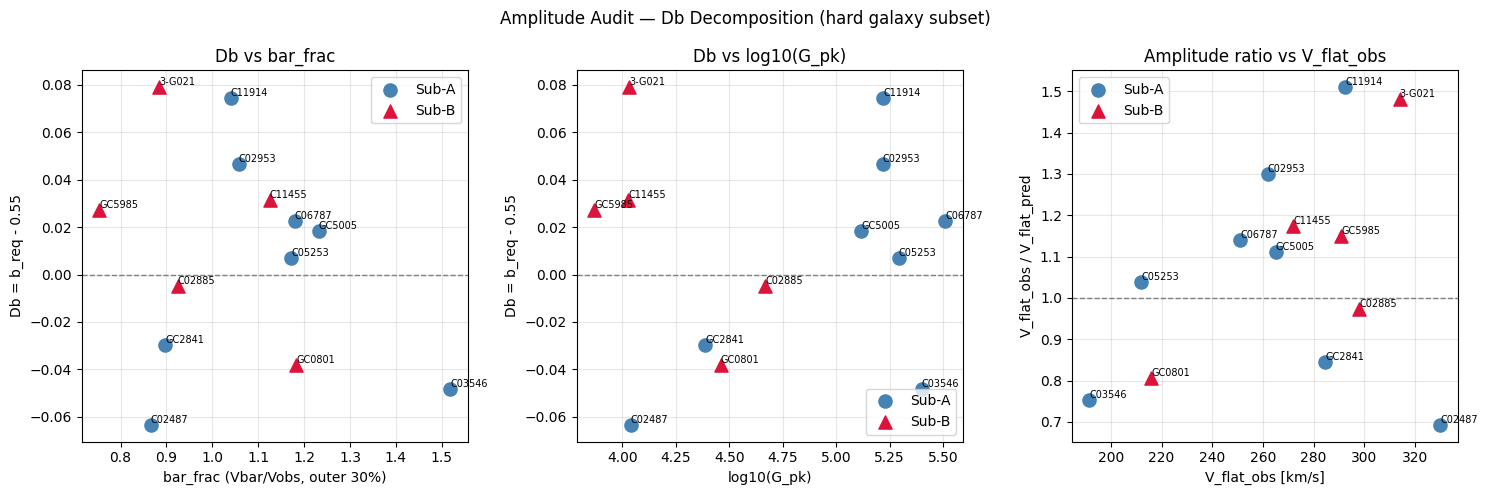


Plot saved: /content/mts_amplitude_audit/amplitude_audit.png
CSV saved:  /content/mts_amplitude_audit/amplitude_audit.csv

DIAGNOSIS

  Sub-B amplitude ratio median: 1.149  (>1 = underpredicted)
  Sub-A amplitude ratio median: 1.076
  Sub-B Db required median:     +0.027
  Sub-B shape_rmse median:      0.1304
  Sub-A shape_rmse median:      0.1670

  >> AMPLITUDE IS NEAR-CORRECT for Sub-B.
     Shape failure dominates (shape_rmse=0.1304 vs Sub-A 0.1670).
     Next: examine shape residuals — where does the curve diverge?


In [15]:
# ============================================================
# MTS AMPLITUDE LAW AUDIT v2 — uses existing loaded dict
# ============================================================

OUTDIR_AUD = "/content/mts_amplitude_audit"
os.makedirs(OUTDIR_AUD, exist_ok=True)

# ----------------------------------------------------------------
# Confirm actual keys before proceeding
# ----------------------------------------------------------------
sample = next(iter(loaded.values()))
print("Confirmed keys:", list(sample.keys()))
print(f"Galaxies in loaded: {len(loaded)}")
print()

# ----------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------
def get_v_flat_obs(rot, outer_frac=0.30):
    r    = rot["r"]
    vobs = rot["vobs"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        return float(np.max(vobs))
    return float(np.median(vobs[mask]))

def get_bar_frac_outer(rot, outer_frac=0.30):
    vbar2 = np.maximum(vbar2_from_rot(rot), 0.0)
    vbar  = np.sqrt(vbar2)
    vobs  = rot["vobs"]
    r     = rot["r"]
    r_cut = r[-1] * (1.0 - outer_frac)
    mask  = r >= r_cut
    if mask.sum() < 2:
        mask = np.ones(len(r), bool)
    ratio = vbar[mask] / np.maximum(vobs[mask], 1.0)
    return float(np.median(ratio))

# ----------------------------------------------------------------
# STEP 1: Fit C_AMP on the loaded galaxies
# ----------------------------------------------------------------
all_carriers = []
all_vmaxes   = []

for name, gdata in loaded.items():
    c = gdata.get("carrier_base")
    v = gdata.get("vmax_obs")
    if c is not None and v is not None and np.isfinite(c) and np.isfinite(v) and c > 0:
        all_carriers.append(c)
        all_vmaxes.append(v)

C_AMP_local = float(np.mean(np.array(all_vmaxes)**2) /
                    np.mean(np.array(all_carriers)))
print(f"C_AMP (fitted on {len(all_carriers)} loaded galaxies): {C_AMP_local:.2f}")
print()

# ----------------------------------------------------------------
# STEP 2: Per-galaxy amplitude decomposition
# ----------------------------------------------------------------
print("="*80)
print("AMPLITUDE LAW AUDIT")
print(f"{'Name':20s} {'Sub':3s} {'Vf_obs':7s} {'Vf_pred':7s} "
      f"{'ratio':6s} {'b_req':6s} {'Db':6s} "
      f"{'log_Gpk':8s} {'bar_frac':9s} {'RMSE':7s}")
print("-"*80)

audit_rows = []
TARGET_NAMES = SUBCLASS_B + SUBCLASS_A

for name in TARGET_NAMES:
    if name not in loaded:
        print(f"  {name:20s}  — NOT IN LOADED")
        continue

    gdata = loaded[name]
    rot   = gdata["rot"]

    carrier_base = gdata["carrier_base"]
    shape        = gdata["shape"]
    vobs         = rot["vobs"]
    vmax_obs     = gdata["vmax_obs"]
    log_Gpk      = gdata["log_Gpk"]
    bar_frac     = gdata.get("bar_frac", get_bar_frac_outer(rot))

    rt    = gdata["rt"]
    u_t   = gdata["u_t"]
    vb2_t = gdata["vbar2_t"]

    carrier_alpha = (rt * u_t) ** ALPHA
    carrier_beta  = vb2_t ** BETA
    carrier_recon = carrier_alpha * carrier_beta
    recon_err = abs(carrier_recon - carrier_base) / max(carrier_base, 1e-30)

    v_flat_pred = float(np.sqrt(max(C_AMP_local * carrier_base, 0.0)))
    v_flat_obs  = get_v_flat_obs(rot)
    ratio       = v_flat_obs / max(v_flat_pred, 1e-3)

    numerator = (v_flat_obs**2) / max(C_AMP_local * carrier_alpha, 1e-30)
    if numerator > 0 and vb2_t > 1.0:
        beta_req   = float(np.log(numerator) / np.log(vb2_t))
        beta_delta = beta_req - BETA
    else:
        beta_req   = np.nan
        beta_delta = np.nan

    v_pred     = v_flat_pred * np.asarray(shape)
    full_rmse  = safe_rmse(vobs, v_pred)
    vobs_n     = vobs / max(float(np.max(vobs)), 1.0)
    vpred_n    = v_pred / max(float(np.max(v_pred)), 1.0)
    shape_rmse = safe_rmse(vobs_n, vpred_n)

    subclass = "B" if name in SUBCLASS_B else "A"
    flag     = " ***" if subclass == "B" else ""

    row = {
        "name":           name,
        "subclass":       subclass,
        "v_flat_obs":     v_flat_obs,
        "v_flat_pred":    v_flat_pred,
        "ratio":          ratio,
        "carrier_alpha":  carrier_alpha,
        "carrier_beta":   carrier_beta,
        "vb2_t":          vb2_t,
        "rt":             rt,
        "u_t":            u_t,
        "beta_req":       beta_req,
        "beta_delta":     beta_delta,
        "bar_frac":       bar_frac,
        "log_Gpk":        log_Gpk,
        "shape_rmse":     shape_rmse,
        "full_rmse":      full_rmse,
        "recon_err":      recon_err,
    }
    audit_rows.append(row)

    print(f"{name:20s} {subclass:3s} "
          f"{v_flat_obs:7.1f} {v_flat_pred:7.1f} "
          f"{ratio:6.3f} "
          f"{beta_req:6.3f} {beta_delta:+6.3f} "
          f"{log_Gpk:8.3f} {bar_frac:9.4f} "
          f"{full_rmse:7.2f}{flag}")

df_audit = pd.DataFrame(audit_rows)

# ----------------------------------------------------------------
# STEP 3: Carrier decomposition table
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CARRIER DECOMPOSITION")
print(f"{'Name':20s} {'Sub':3s} {'(rt*u_t)^a':12s} {'Vb2(rt)^b':12s} "
      f"{'carrier':10s} {'rt[kpc]':8s} {'u_t':8s} {'vb2_t':10s} {'recon_err':9s}")
print("-"*80)

for row in audit_rows:
    print(f"{row['name']:20s} {row['subclass']:3s} "
          f"{row['carrier_alpha']:12.4e} {row['carrier_beta']:12.4e} "
          f"{row['carrier_alpha']*row['carrier_beta']:10.4e} "
          f"{row['rt']:8.3f} {row['u_t']:8.4e} {row['vb2_t']:10.2f} "
          f"{row['recon_err']:9.4f}")

# ----------------------------------------------------------------
# STEP 4: Summary by subclass
# ----------------------------------------------------------------
print("\n" + "="*80)
print("SUMMARY BY SUBCLASS")
print("="*80)

for sc in ["B", "A"]:
    d = df_audit[df_audit["subclass"] == sc]
    if len(d) == 0:
        continue
    print(f"\nSub-{sc} (n={len(d)}):")
    print(f"  ratio (obs/pred):   median={d['ratio'].median():.3f}  "
          f"range=[{d['ratio'].min():.3f}, {d['ratio'].max():.3f}]")
    print(f"  Db required:        median={d['beta_delta'].median():+.3f}  "
          f"range=[{d['beta_delta'].min():+.3f}, {d['beta_delta'].max():+.3f}]")
    print(f"  carrier_alpha:      median={d['carrier_alpha'].median():.4e}")
    print(f"  carrier_beta:       median={d['carrier_beta'].median():.4e}")
    print(f"  vb2_t [km2/s2]:     median={d['vb2_t'].median():.1f}")
    print(f"  bar_frac:           median={d['bar_frac'].median():.3f}")
    print(f"  log_Gpk:            median={d['log_Gpk'].median():.3f}")
    print(f"  full_rmse:          median={d['full_rmse'].median():.2f}")
    print(f"  shape_rmse:         median={d['shape_rmse'].median():.4f}")

# ----------------------------------------------------------------
# STEP 5: Correlation analysis
# ----------------------------------------------------------------
print("\n" + "="*80)
print("CORRELATION: Db vs bar_frac, log_Gpk")
print("="*80)

from scipy.stats import pearsonr, spearmanr

for label, dfc in [
    ("Sub-B only",       df_audit[df_audit["subclass"]=="B"]),
    ("Sub-A+B combined", df_audit),
]:
    dfc = dfc.dropna(subset=["beta_delta", "bar_frac", "log_Gpk"])
    print(f"\n  {label} (n={len(dfc)}):")
    if len(dfc) >= 3:
        r_bf, p_bf  = pearsonr( dfc["bar_frac"], dfc["beta_delta"])
        r_gp, p_gp  = pearsonr( dfc["log_Gpk"],  dfc["beta_delta"])
        s_bf, ps_bf = spearmanr(dfc["bar_frac"], dfc["beta_delta"])
        s_gp, ps_gp = spearmanr(dfc["log_Gpk"],  dfc["beta_delta"])
        print(f"    Db vs bar_frac:  Pearson r={r_bf:+.3f} (p={p_bf:.3f})  "
              f"Spearman rho={s_bf:+.3f} (p={ps_bf:.3f})")
        print(f"    Db vs log_Gpk:   Pearson r={r_gp:+.3f} (p={p_gp:.3f})  "
              f"Spearman rho={s_gp:+.3f} (p={ps_gp:.3f})")
    else:
        print("    Too few points.")

# ----------------------------------------------------------------
# STEP 6: Diagnostic plots
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Amplitude Audit — Db Decomposition (hard galaxy subset)", fontsize=12)

colors  = {"A": "steelblue", "B": "crimson"}
markers = {"A": "o",         "B": "^"}

ax = axes[0]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["bar_frac","beta_delta"])
    ax.scatter(d["bar_frac"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["bar_frac"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("bar_frac (Vbar/Vobs, outer 30%)")
ax.set_ylabel("Db = b_req - 0.55")
ax.set_title("Db vs bar_frac")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["log_Gpk","beta_delta"])
    ax.scatter(d["log_Gpk"], d["beta_delta"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["log_Gpk"], row["beta_delta"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("log10(G_pk)")
ax.set_ylabel("Db = b_req - 0.55")
ax.set_title("Db vs log10(G_pk)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
for sc in ["A", "B"]:
    d = df_audit[df_audit["subclass"]==sc].dropna(subset=["v_flat_obs","ratio"])
    ax.scatter(d["v_flat_obs"], d["ratio"],
               c=colors[sc], marker=markers[sc], s=90, label=f"Sub-{sc}", zorder=3)
    for _, row in d.iterrows():
        ax.annotate(row["name"][-6:], (row["v_flat_obs"], row["ratio"]),
                    fontsize=7, ha="left", va="bottom")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_xlabel("V_flat_obs [km/s]")
ax.set_ylabel("V_flat_obs / V_flat_pred")
ax.set_title("Amplitude ratio vs V_flat_obs")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTDIR_AUD, "amplitude_audit.png")
plt.savefig(plot_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"\nPlot saved: {plot_path}")

csv_path = os.path.join(OUTDIR_AUD, "amplitude_audit.csv")
df_audit.to_csv(csv_path, index=False)
print(f"CSV saved:  {csv_path}")

# ----------------------------------------------------------------
# STEP 7: Decision
# ----------------------------------------------------------------
print("\n" + "="*80)
print("DIAGNOSIS")
print("="*80)

b = df_audit[df_audit["subclass"]=="B"]
a = df_audit[df_audit["subclass"]=="A"]

b_ratio = b["ratio"].median()
a_ratio = a["ratio"].median()
b_db    = b["beta_delta"].median()
b_shape = b["shape_rmse"].median()
a_shape = a["shape_rmse"].median()

print(f"\n  Sub-B amplitude ratio median: {b_ratio:.3f}  (>1 = underpredicted)")
print(f"  Sub-A amplitude ratio median: {a_ratio:.3f}")
print(f"  Sub-B Db required median:     {b_db:+.3f}")
print(f"  Sub-B shape_rmse median:      {b_shape:.4f}")
print(f"  Sub-A shape_rmse median:      {a_shape:.4f}")
print()

if b_ratio > 1.15:
    print("  >> AMPLITUDE FAILURE: Sub-B velocities are underpredicted.")
    if abs(b_db) > 0.08:
        print(f"     BETA correction of ~{b_db:+.2f} needed for Sub-B.")
        print("     Suggested next: BETA_eff = 0.55 + delta * (1 - bar_frac)")
    else:
        print("     But Db is small — BETA is not the lever.")
        print("     Failure is in carrier_alpha = (rt*u_t)^ALPHA.")
        print("     Next: examine rt and u_t values for Sub-B vs Sub-A.")
elif b_ratio < 0.85:
    print("  >> AMPLITUDE OVERPREDICTION for Sub-B.")
    print("     Check source normalisation or Rs scaling.")
else:
    print("  >> AMPLITUDE IS NEAR-CORRECT for Sub-B.")
    print(f"     Shape failure dominates (shape_rmse={b_shape:.4f} vs Sub-A {a_shape:.4f}).")
    print("     Next: examine shape residuals — where does the curve diverge?")